# **Konfigurasi Penelitian**

## **0.1 Import Library**

In [1]:
# ------------------------------------------------------------
# A. Library standar Python
# ------------------------------------------------------------

import os
import sys
import gc
import math
import time
import json
import random
import warnings
import subprocess

from pathlib import Path
from datetime import datetime
from itertools import product
from collections import defaultdict
from typing import (
    Any,
    Dict,
    Iterable,
    List,
    Mapping,
    Optional,
    Sequence,
    Tuple,
    Union
)


# ------------------------------------------------------------
# B. Pengolahan data
# ------------------------------------------------------------

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# C. Visualisasi
# ------------------------------------------------------------

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# D. Matrix factorization dan operasi matriks sparse
# ------------------------------------------------------------

import scipy

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds


# ------------------------------------------------------------
# E. Pembagian data dan evaluasi model
# ------------------------------------------------------------

import sklearn

from sklearn.model_selection import (
    train_test_split,
    KFold
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)


# ------------------------------------------------------------
# F. Kompilasi numerik untuk optimasi CPU
# ------------------------------------------------------------

# Numba digunakan oleh fungsi SGD pada Funk SVD dan SVD++.
# Apabila belum tersedia di runtime Colab, library akan
# diinstal secara otomatis.

try:
    import numba
    from numba import njit

except ImportError:
    print(
        "Library Numba belum tersedia. "
        "Instalasi otomatis sedang dijalankan..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "numba"
        ]
    )

    import numba
    from numba import njit


# ------------------------------------------------------------
# G. Progress bar
# ------------------------------------------------------------

from tqdm.auto import tqdm


# ------------------------------------------------------------
# H. Tampilan notebook
# ------------------------------------------------------------

from IPython.display import (
    display,
    Markdown
)


# ------------------------------------------------------------
# I. Operasi file Google Colab
# ------------------------------------------------------------

from google.colab import files


# ------------------------------------------------------------
# J. Pengaturan file Excel
# ------------------------------------------------------------

import openpyxl

from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)

from openpyxl.utils import (
    get_column_letter
)


# ------------------------------------------------------------
# K. Pengaturan warning
# ------------------------------------------------------------

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning
)


# ------------------------------------------------------------
# L. Pengujian Numba
# ------------------------------------------------------------

@njit
def _test_numba_compilation(value):
    """
    Fungsi sederhana untuk memastikan Numba dan njit
    dapat digunakan pada runtime.
    """
    return value * 2.0


numba_test_result = _test_numba_compilation(
    5.0
)

if numba_test_result != 10.0:
    raise RuntimeError(
        "Numba berhasil diimpor, tetapi pengujian "
        "kompilasi tidak menghasilkan nilai yang sesuai."
    )


# ------------------------------------------------------------
# M. Informasi versi library
# ------------------------------------------------------------

print("=" * 80)
print("SELURUH LIBRARY BERHASIL DIIMPOR")
print("=" * 80)

print(
    f"Python version      : "
    f"{sys.version.split()[0]}"
)

print(
    f"NumPy version       : "
    f"{np.__version__}"
)

print(
    f"Pandas version      : "
    f"{pd.__version__}"
)

print(
    f"Matplotlib version  : "
    f"{matplotlib.__version__}"
)

print(
    f"Seaborn version     : "
    f"{sns.__version__}"
)

print(
    f"SciPy version       : "
    f"{scipy.__version__}"
)

print(
    f"Scikit-learn version: "
    f"{sklearn.__version__}"
)

print(
    f"Numba version       : "
    f"{numba.__version__}"
)

print(
    f"Openpyxl version    : "
    f"{openpyxl.__version__}"
)

print(
    f"Pengujian njit      : "
    f"BERHASIL ({numba_test_result})"
)

print()
print(
    "Funk SVD dan SVD++ siap menggunakan "
    "fungsi berdekorator @njit."
)

SELURUH LIBRARY BERHASIL DIIMPOR
Python version      : 3.12.13
NumPy version       : 2.0.2
Pandas version      : 2.2.2
Matplotlib version  : 3.10.0
Seaborn version     : 0.13.2
SciPy version       : 1.16.3
Scikit-learn version: 1.6.1
Numba version       : 0.60.0
Openpyxl version    : 3.1.5
Pengujian njit      : BERHASIL (10.0)

Funk SVD dan SVD++ siap menggunakan fungsi berdekorator @njit.


## **0.2 Random Seed dan Reproducibility**

In [2]:
RANDOM_STATE = 42

# Mengatur random seed
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Penelitian menggunakan eksekusi berbasis CPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
EXECUTION_DEVICE = "CPU"

# Menyembunyikan peringatan yang tidak memengaruhi hasil eksperimen
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Pengaturan tampilan tabel pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

print("Konfigurasi reproducibility berhasil diterapkan.")
print(f"Random state    : {RANDOM_STATE}")
print(f"Execution device: {EXECUTION_DEVICE}")

Konfigurasi reproducibility berhasil diterapkan.
Random state    : 42
Execution device: CPU


### **0.3 Path, Warna, dan Konfigurasi Eksperimen**

In [3]:
# ------------------------------------------------------------
# A. Identitas notebook dan dataset
# ------------------------------------------------------------

NOTEBOOK_NAME = "2026_08_05_Implementasi_CPU"

INPUT_FILENAME = "2026_07_17_Praproses_Data.xlsx"
INPUT_PATH = Path("/content/2026_07_17_Praproses_Data.xlsx")

OUTPUT_DIR = Path("/content/Hasil_Implementasi_MF")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# B. Konfigurasi pembagian dan evaluasi data
# ------------------------------------------------------------

DEVELOPMENT_SIZE = 0.80
FINAL_TEST_SIZE = 0.20

N_SPLITS = 5
SHUFFLE_DATA = True

RATING_MIN = 1.0
RATING_MAX = 5.0

PRIMARY_METRIC = "RMSE"
SECONDARY_METRIC = "MAE"


# ------------------------------------------------------------
# C. Konfigurasi output
# ------------------------------------------------------------

AUTO_DOWNLOAD = True

EXCEL_ENGINE = "openpyxl"
FIGURE_FORMAT = "png"
FIGURE_DPI = 300

# Ukuran gambar default
DEFAULT_FIGSIZE = (10, 6)
WIDE_FIGSIZE = (12, 6)
LARGE_FIGSIZE = (14, 8)


# ------------------------------------------------------------
# D. Identitas warna setiap model
# ------------------------------------------------------------

MODEL_COLORS = {
    "SVD": "#1F77B4",       # Biru
    "Funk SVD": "#FF7F0E",  # Oranye
    "SVD++": "#2CA02C"      # Hijau
}

METRIC_COLORS = {
    "RMSE": "#D62728",      # Merah
    "MAE": "#9467BD"        # Ungu
}

FALLBACK_COLOR = "#7F7F7F"


# ------------------------------------------------------------
# E. Kategori user berdasarkan jumlah interaksi di training
# ------------------------------------------------------------

USER_CATEGORY_ORDER = [
    "Unseen User",
    "Single-Interaction User",
    "Low-History User",
    "Higher-History User"
]

USER_CATEGORY_LABELS = {
    "Unseen User": "0 interaksi",
    "Single-Interaction User": "1 interaksi",
    "Low-History User": "2–5 interaksi",
    "Higher-History User": ">5 interaksi"
}

USER_CATEGORY_COLORS = {
    "Unseen User": "#D62728",
    "Single-Interaction User": "#FF9896",
    "Low-History User": "#FFBB78",
    "Higher-History User": "#2CA02C"
}


# ------------------------------------------------------------
# F. Konfigurasi tampilan grafik
# ------------------------------------------------------------

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": DEFAULT_FIGSIZE,
    "figure.dpi": 120,
    "savefig.dpi": FIGURE_DPI,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True
})


print("Konfigurasi eksperimen berhasil dibuat.")
print(f"Notebook       : {NOTEBOOK_NAME}")
print(f"Input dataset  : {INPUT_FILENAME}")
print(f"Output folder  : {OUTPUT_DIR}")
print(f"Development    : {DEVELOPMENT_SIZE:.0%}")
print(f"Final test     : {FINAL_TEST_SIZE:.0%}")
print(f"Cross-validation: {N_SPLITS}-Fold")
print(f"Primary metric : {PRIMARY_METRIC}")
print(f"Secondary metric: {SECONDARY_METRIC}")

Konfigurasi eksperimen berhasil dibuat.
Notebook       : 2026_08_05_Implementasi_CPU
Input dataset  : 2026_07_17_Praproses_Data.xlsx
Output folder  : /content/Hasil_Implementasi_MF
Development    : 80%
Final test     : 20%
Cross-validation: 5-Fold
Primary metric : RMSE
Secondary metric: MAE


## **0.4 Fungsi Utilitas Output**

In [4]:
def format_execution_time(seconds: float) -> str:
    """
    Mengubah waktu dalam detik menjadi format yang lebih mudah dibaca.
    """
    seconds = float(seconds)

    if seconds < 60:
        return f"{seconds:.2f} detik"

    minutes, remaining_seconds = divmod(seconds, 60)

    if minutes < 60:
        return f"{int(minutes)} menit {remaining_seconds:.2f} detik"

    hours, remaining_minutes = divmod(minutes, 60)

    return (
        f"{int(hours)} jam "
        f"{int(remaining_minutes)} menit "
        f"{remaining_seconds:.2f} detik"
    )


def clip_rating(
    prediction: Union[float, np.ndarray, pd.Series],
    minimum: float = RATING_MIN,
    maximum: float = RATING_MAX
):
    """
    Membatasi nilai prediksi agar tetap berada pada skala rating.
    """
    return np.clip(prediction, minimum, maximum)


def calculate_rmse(
    actual: Union[np.ndarray, pd.Series, Sequence[float]],
    predicted: Union[np.ndarray, pd.Series, Sequence[float]]
) -> float:
    """
    Menghitung Root Mean Square Error.
    """
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)

    return float(
        np.sqrt(
            mean_squared_error(actual_array, predicted_array)
        )
    )


def calculate_mae(
    actual: Union[np.ndarray, pd.Series, Sequence[float]],
    predicted: Union[np.ndarray, pd.Series, Sequence[float]]
) -> float:
    """
    Menghitung Mean Absolute Error.
    """
    actual_array = np.asarray(actual, dtype=float)
    predicted_array = np.asarray(predicted, dtype=float)

    return float(
        mean_absolute_error(actual_array, predicted_array)
    )


def classify_user_history(interaction_count: int) -> str:
    """
    Mengelompokkan user berdasarkan jumlah interaksi yang tersedia
    pada data training.

    0 interaksi   : Unseen User
    1 interaksi   : Single-Interaction User
    2–5 interaksi : Low-History User
    >5 interaksi  : Higher-History User
    """
    interaction_count = int(interaction_count)

    if interaction_count == 0:
        return "Unseen User"

    if interaction_count == 1:
        return "Single-Interaction User"

    if 2 <= interaction_count <= 5:
        return "Low-History User"

    return "Higher-History User"


def safe_sheet_name(sheet_name: str) -> str:
    """
    Membersihkan nama sheet dan membatasi panjangnya maksimal 31 karakter.
    """
    invalid_characters = ["\\", "/", "*", "?", ":", "[", "]"]

    cleaned_name = str(sheet_name)

    for character in invalid_characters:
        cleaned_name = cleaned_name.replace(character, "_")

    cleaned_name = cleaned_name.strip()

    if not cleaned_name:
        cleaned_name = "Data"

    return cleaned_name[:31]


def safe_filename(
    filename: str,
    expected_extension: Optional[str] = None
) -> str:
    """
    Membersihkan nama file dari karakter yang berpotensi bermasalah.
    """
    filename = str(filename).strip()

    invalid_characters = ['<', '>', ':', '"', '/', '\\', '|', '?', '*']

    for character in invalid_characters:
        filename = filename.replace(character, "_")

    filename = "_".join(filename.split())

    if expected_extension is not None:
        expected_extension = expected_extension.lower()

        if not expected_extension.startswith("."):
            expected_extension = f".{expected_extension}"

        if not filename.lower().endswith(expected_extension):
            filename = f"{filename}{expected_extension}"

    return filename


def format_excel_worksheet(
    worksheet,
    freeze_panes: str = "A2",
    apply_auto_filter: bool = True,
    maximum_column_width: int = 45
) -> None:
    """
    Memberikan format dasar pada worksheet hasil penelitian.
    """
    header_fill = PatternFill(
        fill_type="solid",
        fgColor="1F4E78"
    )

    header_font = Font(
        color="FFFFFF",
        bold=True
    )

    header_alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    data_alignment = Alignment(
        vertical="top",
        wrap_text=True
    )

    thin_border = Border(
        left=Side(style="thin", color="D9E2F3"),
        right=Side(style="thin", color="D9E2F3"),
        top=Side(style="thin", color="D9E2F3"),
        bottom=Side(style="thin", color="D9E2F3")
    )

    # Format baris header
    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = header_alignment
        cell.border = thin_border

    worksheet.row_dimensions[1].height = 30

    # Format seluruh data
    for row in worksheet.iter_rows(
        min_row=2,
        max_row=worksheet.max_row,
        min_col=1,
        max_col=worksheet.max_column
    ):
        for cell in row:
            cell.alignment = data_alignment
            cell.border = thin_border

    # Menentukan lebar kolom secara otomatis
    for column_cells in worksheet.columns:
        column_index = column_cells[0].column
        column_letter = get_column_letter(column_index)

        maximum_length = 0

        for cell in column_cells:
            cell_value = "" if cell.value is None else str(cell.value)
            maximum_length = max(maximum_length, len(cell_value))

        adjusted_width = min(
            maximum_length + 3,
            maximum_column_width
        )

        worksheet.column_dimensions[column_letter].width = max(
            adjusted_width,
            12
        )

    worksheet.freeze_panes = freeze_panes

    if apply_auto_filter and worksheet.max_row >= 2:
        worksheet.auto_filter.ref = worksheet.dimensions


def download_output_file(file_path: Union[str, Path]) -> None:
    """
    Mengunduh file output secara otomatis di Google Colab.
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"File tidak ditemukan: {file_path}"
        )

    if AUTO_DOWNLOAD:
        files.download(str(file_path))


def save_excel_output(
    data: Union[
        pd.DataFrame,
        Mapping[str, pd.DataFrame]
    ],
    filename: str,
    index: bool = False,
    auto_download: Optional[bool] = None
) -> Path:
    """
    Menyimpan satu atau beberapa DataFrame ke file Excel.

    Parameters
    ----------
    data:
        DataFrame tunggal atau dictionary dengan format:
        {
            "Nama Sheet": dataframe,
            ...
        }

    filename:
        Nama file output, misalnya:
        "00_Ringkasan_Dataset.xlsx"

    index:
        Menentukan apakah index DataFrame disimpan.

    auto_download:
        Menentukan apakah file langsung diunduh.
    """
    if auto_download is None:
        auto_download = AUTO_DOWNLOAD

    filename = safe_filename(
        filename,
        expected_extension=".xlsx"
    )

    output_path = OUTPUT_DIR / filename

    if isinstance(data, pd.DataFrame):
        sheets = {"Data": data.copy()}

    elif isinstance(data, Mapping):
        sheets = {}

        for sheet_name, dataframe in data.items():
            if not isinstance(dataframe, pd.DataFrame):
                raise TypeError(
                    f"Isi sheet '{sheet_name}' bukan DataFrame."
                )

            sheets[safe_sheet_name(sheet_name)] = dataframe.copy()

    else:
        raise TypeError(
            "Parameter 'data' harus berupa DataFrame "
            "atau dictionary berisi DataFrame."
        )

    with pd.ExcelWriter(
        output_path,
        engine=EXCEL_ENGINE
    ) as writer:

        for sheet_name, dataframe in sheets.items():
            dataframe.to_excel(
                writer,
                sheet_name=sheet_name,
                index=index
            )

            worksheet = writer.sheets[sheet_name]

            format_excel_worksheet(
                worksheet=worksheet,
                freeze_panes="A2",
                apply_auto_filter=True
            )

    if not output_path.exists():
        raise IOError(
            f"Gagal menyimpan file Excel: {output_path}"
        )

    file_size_kb = output_path.stat().st_size / 1024

    print(
        f"Excel berhasil disimpan: {output_path.name} "
        f"({file_size_kb:.2f} KB)"
    )

    if auto_download:
        files.download(str(output_path))

    return output_path


def save_figure_output(
    figure: plt.Figure,
    filename: str,
    dpi: int = FIGURE_DPI,
    auto_download: Optional[bool] = None,
    close_figure: bool = True
) -> Path:
    """
    Menyimpan visualisasi dalam format PNG dan mengunduhnya.
    """
    if auto_download is None:
        auto_download = AUTO_DOWNLOAD

    filename = safe_filename(
        filename,
        expected_extension=f".{FIGURE_FORMAT}"
    )

    output_path = OUTPUT_DIR / filename

    figure.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    if not output_path.exists():
        raise IOError(
            f"Gagal menyimpan gambar: {output_path}"
        )

    file_size_kb = output_path.stat().st_size / 1024

    print(
        f"Gambar berhasil disimpan: {output_path.name} "
        f"({file_size_kb:.2f} KB)"
    )

    if auto_download:
        files.download(str(output_path))

    if close_figure:
        plt.close(figure)

    return output_path


def show_dataframe_summary(
    dataframe: pd.DataFrame,
    title: str,
    maximum_rows: int = 10
) -> None:
    """
    Menampilkan judul, dimensi data, dan beberapa baris awal DataFrame.
    """
    print("=" * 80)
    print(title.upper())
    print("=" * 80)
    print(f"Jumlah baris : {dataframe.shape[0]:,}")
    print(f"Jumlah kolom : {dataframe.shape[1]:,}")
    print()

    display(dataframe.head(maximum_rows))


print("Seluruh fungsi utilitas berhasil dibuat.")

Seluruh fungsi utilitas berhasil dibuat.


## **0.5 Pemeriksaan Konfigurasi**

In [5]:
configuration_summary = pd.DataFrame({
    "Komponen": [
        "Nama Notebook",
        "Nama Dataset",
        "Direktori Output",
        "Perangkat Eksekusi",
        "Random State",
        "Proporsi Development Data",
        "Proporsi Final Test Data",
        "Jumlah Fold",
        "Metrik Utama",
        "Metrik Pendamping",
        "Skala Rating",
        "Format Tabel",
        "Format Gambar",
        "Auto Download"
    ],
    "Nilai": [
        NOTEBOOK_NAME,
        INPUT_FILENAME,
        str(OUTPUT_DIR),
        EXECUTION_DEVICE,
        RANDOM_STATE,
        f"{DEVELOPMENT_SIZE:.0%}",
        f"{FINAL_TEST_SIZE:.0%}",
        f"{N_SPLITS}-Fold Cross Validation",
        PRIMARY_METRIC,
        SECONDARY_METRIC,
        f"{RATING_MIN:.0f}–{RATING_MAX:.0f}",
        ".xlsx",
        f".{FIGURE_FORMAT}",
        AUTO_DOWNLOAD
    ]
})

display(configuration_summary)

assert math.isclose(
    DEVELOPMENT_SIZE + FINAL_TEST_SIZE,
    1.0,
    rel_tol=1e-9
), "Total proporsi development dan final test harus sama dengan 1."

assert N_SPLITS >= 2, (
    "Jumlah fold minimal adalah 2."
)

assert RATING_MIN < RATING_MAX, (
    "Nilai rating minimum harus lebih kecil dari maksimum."
)

assert OUTPUT_DIR.exists(), (
    "Direktori output gagal dibuat."
)

print()
print("STEP 0 SELESAI")
print("Seluruh konfigurasi penelitian telah tervalidasi.")
print(f"Output akan disimpan di: {OUTPUT_DIR}")

,Komponen,Nilai
0,Nama Notebook,2026_08_05_Implementasi_CPU
1,Nama Dataset,2026_07_17_Praproses_Data.xlsx
2,Direktori Output,/content/Hasil_Implementasi_MF
3,Perangkat Eksekusi,CPU
4,Random State,42
5,Proporsi Development Data,80%
6,Proporsi Final Test Data,20%
7,Jumlah Fold,5-Fold Cross Validation
8,Metrik Utama,RMSE
9,Metrik Pendamping,MAE



STEP 0 SELESAI
Seluruh konfigurasi penelitian telah tervalidasi.
Output akan disimpan di: /content/Hasil_Implementasi_MF


# **Persiapan Data Modeling**

## **1.1 Memuat Dataset Hasil Praproses**

In [6]:
# ============================================================
# 1.1 MEMUAT DATASET HASIL PRAPROSES
# ============================================================

# Lokasi dataset sudah ditentukan secara langsung
INPUT_PATH = Path(
    "/content/2026_07_17_Praproses_Data.xlsx"
)

# ------------------------------------------------------------
# A. Memastikan file tersedia
# ------------------------------------------------------------

if not INPUT_PATH.is_file():
    raise FileNotFoundError(
        "Dataset tidak ditemukan.\n"
        f"Lokasi yang diperiksa: {INPUT_PATH}\n\n"
        "Pastikan file sudah tersedia di direktori /content "
        "dengan nama:\n"
        "2026_07_17_Praproses_Data.xlsx"
    )

# ------------------------------------------------------------
# B. Membaca informasi workbook
# ------------------------------------------------------------

with pd.ExcelFile(
    INPUT_PATH,
    engine="openpyxl"
) as excel_file:

    sheet_names = excel_file.sheet_names

    if not sheet_names:
        raise ValueError(
            "File Excel tidak memiliki worksheet."
        )

    # Menggunakan worksheet pertama
    DATA_SHEET_NAME = sheet_names[0]

    # Membaca dataset
    dataset_raw = pd.read_excel(
        excel_file,
        sheet_name=DATA_SHEET_NAME
    )

# ------------------------------------------------------------
# C. Membersihkan nama kolom
# ------------------------------------------------------------

dataset_raw.columns = [
    str(column).strip()
    for column in dataset_raw.columns
]

# ------------------------------------------------------------
# D. Memastikan dataset tidak kosong
# ------------------------------------------------------------

if dataset_raw.empty:
    raise ValueError(
        f"Worksheet '{DATA_SHEET_NAME}' tidak memiliki data."
    )

# ------------------------------------------------------------
# E. Menampilkan informasi dataset
# ------------------------------------------------------------

print("=" * 80)
print("INFORMASI FILE DATASET")
print("=" * 80)

print(f"Nama file        : {INPUT_PATH.name}")
print(f"Lokasi file      : {INPUT_PATH}")
print(
    f"Ukuran file      : "
    f"{INPUT_PATH.stat().st_size / 1024:.2f} KB"
)
print(f"Jumlah worksheet : {len(sheet_names)}")
print(f"Daftar worksheet : {sheet_names}")
print(f"Worksheet aktif  : {DATA_SHEET_NAME}")

print()
print("=" * 80)
print("DATASET BERHASIL DIMUAT")
print("=" * 80)

print(
    f"Jumlah baris awal : "
    f"{dataset_raw.shape[0]:,}"
)
print(
    f"Jumlah kolom awal : "
    f"{dataset_raw.shape[1]:,}"
)
print(
    f"Daftar kolom      : "
    f"{dataset_raw.columns.tolist()}"
)

print()
print("Preview 10 baris pertama:")

display(
    dataset_raw.head(10)
)

INFORMASI FILE DATASET
Nama file        : 2026_07_17_Praproses_Data.xlsx
Lokasi file      : /content/2026_07_17_Praproses_Data.xlsx
Ukuran file      : 1095.06 KB
Jumlah worksheet : 1
Daftar worksheet : ['Sheet1']
Worksheet aktif  : Sheet1

DATASET BERHASIL DIMUAT
Jumlah baris awal : 21,886
Jumlah kolom awal : 6
Daftar kolom      : ['user_id', 'place_id', 'rating', 'place_name', 'review_date', 'source']

Preview 10 baris pertama:


,user_id,place_id,rating,place_name,review_date,source
0,269E34905434FF14CF8D57361A334763,1912575,5,Tirta Empul Temple,2026-03-01,Tripadvisor
1,3F715883F8E07AC8E859C1CB739AB349,379340,4,Tanah Lot,2026-02-28,Tripadvisor
2,3F715883F8E07AC8E859C1CB739AB349,12396108,4,Kelingking Beach,2026-02-28,Tripadvisor
3,8EF878BEE1C146976972BED37294BF4F,1793975,5,Bali Zoo,2026-02-27,Tripadvisor
4,ACFC17D66E6EF539E7EB81B8174BD7B9,12396108,5,Kelingking Beach,2026-02-27,Tripadvisor
5,2CE963D0E6A9E4C88E2F0C5269DDB769,378969,3,Sacred Monkey Forest Sanctuary,2026-02-27,Tripadvisor
6,7E5C77AC5B26D50A00FA63340D00133E,1793975,5,Bali Zoo,2026-02-26,Tripadvisor
7,385CC87A7F7C33A38C479533D5FF2CCB,1793975,5,Bali Zoo,2026-02-26,Tripadvisor
8,B4AEA803D376A2018AFAC01F38CAC8BF,7047720,5,Atuh Beach,2026-02-26,Tripadvisor
9,E8955E4CA610C1A97160FD6B951033F0,447061,4,Ulun Danu Bratan,2026-02-26,Tripadvisor


## **1.2 Validasi Struktur dan Kualitas Dataset**

In [7]:
REQUIRED_COLUMNS = [
    "user_id",
    "place_id",
    "rating",
    "place_name",
    "review_date",
    "source"
]

# ------------------------------------------------------------
# A. Pemeriksaan keberadaan kolom
# ------------------------------------------------------------

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in dataset_raw.columns
]

if missing_columns:
    raise ValueError(
        "Dataset tidak memiliki kolom wajib berikut: "
        f"{missing_columns}"
    )

# Hanya menggunakan atribut yang telah ditetapkan dalam penelitian
dataset = dataset_raw[REQUIRED_COLUMNS].copy()


# ------------------------------------------------------------
# B. Fungsi normalisasi identifier
# ------------------------------------------------------------

def normalize_identifier(value):
    """
    Mengubah identifier menjadi string secara konsisten tanpa
    menghasilkan akhiran '.0' pada identifier numerik bulat.
    """
    if pd.isna(value):
        return pd.NA

    if isinstance(value, (int, np.integer)):
        return str(int(value))

    if isinstance(value, (float, np.floating)):
        if float(value).is_integer():
            return str(int(value))

        return str(value).strip()

    return str(value).strip()


# ------------------------------------------------------------
# C. Normalisasi tipe data
# ------------------------------------------------------------

dataset["user_id"] = (
    dataset["user_id"]
    .map(normalize_identifier)
    .astype("string")
)

dataset["place_id"] = (
    dataset["place_id"]
    .map(normalize_identifier)
    .astype("string")
)

dataset["place_name"] = (
    dataset["place_name"]
    .astype("string")
    .str.strip()
)

dataset["source"] = (
    dataset["source"]
    .astype("string")
    .str.strip()
)

dataset["rating"] = pd.to_numeric(
    dataset["rating"],
    errors="coerce"
)

dataset["review_date"] = pd.to_datetime(
    dataset["review_date"],
    errors="coerce"
)


# ------------------------------------------------------------
# D. Pemeriksaan kualitas data
# ------------------------------------------------------------

missing_value_summary = (
    dataset
    .isna()
    .sum()
    .rename("jumlah_missing")
    .reset_index()
    .rename(columns={"index": "atribut"})
)

missing_value_summary["persentase_missing"] = (
    missing_value_summary["jumlah_missing"]
    / len(dataset)
    * 100
)

duplicate_full_rows = int(
    dataset.duplicated(keep="first").sum()
)

duplicate_user_item = int(
    dataset.duplicated(
        subset=["user_id", "place_id"],
        keep="first"
    ).sum()
)

rating_below_minimum = int(
    (dataset["rating"] < RATING_MIN).sum()
)

rating_above_maximum = int(
    (dataset["rating"] > RATING_MAX).sum()
)

invalid_review_date = int(
    dataset["review_date"].isna().sum()
)

# Memeriksa apakah satu place_id memiliki lebih dari satu place_name
place_id_name_count = (
    dataset
    .groupby("place_id", dropna=False)["place_name"]
    .nunique(dropna=True)
)

place_id_name_conflicts = int(
    (place_id_name_count > 1).sum()
)

# Memeriksa jumlah nama destinasi yang mempunyai lebih dari satu ID
place_name_id_count = (
    dataset
    .groupby("place_name", dropna=False)["place_id"]
    .nunique(dropna=True)
)

place_name_id_conflicts = int(
    (place_name_id_count > 1).sum()
)


# ------------------------------------------------------------
# E. Tabel hasil validasi
# ------------------------------------------------------------

validation_results = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah baris dataset",
        "Jumlah kolom yang digunakan",
        "Nilai kosong seluruh atribut utama",
        "Duplikasi seluruh baris",
        "Duplikasi pasangan user-item",
        "Rating di bawah skala minimum",
        "Rating di atas skala maksimum",
        "Tanggal ulasan tidak valid/kosong",
        "Place ID dengan lebih dari satu nama",
        "Place name dengan lebih dari satu ID"
    ],
    "Hasil": [
        len(dataset),
        len(REQUIRED_COLUMNS),
        int(dataset[REQUIRED_COLUMNS].isna().sum().sum()),
        duplicate_full_rows,
        duplicate_user_item,
        rating_below_minimum,
        rating_above_maximum,
        invalid_review_date,
        place_id_name_conflicts,
        place_name_id_conflicts
    ],
    "Status": [
        "Informasi",
        "Sesuai" if len(REQUIRED_COLUMNS) == 6 else "Periksa",
        (
            "Sesuai"
            if int(dataset[REQUIRED_COLUMNS].isna().sum().sum()) == 0
            else "Tidak Sesuai"
        ),
        (
            "Sesuai"
            if duplicate_full_rows == 0
            else "Tidak Sesuai"
        ),
        (
            "Sesuai"
            if duplicate_user_item == 0
            else "Tidak Sesuai"
        ),
        (
            "Sesuai"
            if rating_below_minimum == 0
            else "Tidak Sesuai"
        ),
        (
            "Sesuai"
            if rating_above_maximum == 0
            else "Tidak Sesuai"
        ),
        (
            "Sesuai"
            if invalid_review_date == 0
            else "Periksa"
        ),
        (
            "Sesuai"
            if place_id_name_conflicts == 0
            else "Tidak Sesuai"
        ),
        (
            "Sesuai"
            if place_name_id_conflicts == 0
            else "Periksa"
        )
    ]
})

display(validation_results)
display(missing_value_summary)


# ------------------------------------------------------------
# F. Menghentikan proses apabila terdapat masalah kritis
# ------------------------------------------------------------

critical_issues = []

critical_missing_columns = [
    "user_id",
    "place_id",
    "rating",
    "place_name"
]

critical_missing_count = int(
    dataset[critical_missing_columns]
    .isna()
    .sum()
    .sum()
)

if critical_missing_count > 0:
    critical_issues.append(
        f"Terdapat {critical_missing_count} nilai kosong "
        "pada atribut utama."
    )

if duplicate_full_rows > 0:
    critical_issues.append(
        f"Terdapat {duplicate_full_rows} duplikasi baris."
    )

if duplicate_user_item > 0:
    critical_issues.append(
        f"Terdapat {duplicate_user_item} duplikasi "
        "pasangan user-item."
    )

if rating_below_minimum > 0 or rating_above_maximum > 0:
    critical_issues.append(
        "Terdapat rating di luar skala "
        f"{RATING_MIN:.0f}–{RATING_MAX:.0f}."
    )

if place_id_name_conflicts > 0:
    critical_issues.append(
        f"Terdapat {place_id_name_conflicts} place_id "
        "yang memiliki lebih dari satu place_name."
    )

if critical_issues:
    print("\nMASALAH KRITIS DITEMUKAN:")

    for issue_number, issue in enumerate(
        critical_issues,
        start=1
    ):
        print(f"{issue_number}. {issue}")

    raise ValueError(
        "Validasi dataset gagal. "
        "Periksa kembali file hasil praproses."
    )

# Memberikan identitas unik pada setiap interaksi
dataset.insert(
    0,
    "interaction_id",
    np.arange(len(dataset), dtype=int)
)

print()
print("Validasi dataset selesai.")
print("Tidak ditemukan masalah kritis pada dataset.")

,Pemeriksaan,Hasil,Status
0,Jumlah baris dataset,21886,Informasi
1,Jumlah kolom yang digunakan,6,Sesuai
2,Nilai kosong seluruh atribut utama,0,Sesuai
3,Duplikasi seluruh baris,0,Sesuai
4,Duplikasi pasangan user-item,0,Sesuai
5,Rating di bawah skala minimum,0,Sesuai
6,Rating di atas skala maksimum,0,Sesuai
7,Tanggal ulasan tidak valid/kosong,0,Sesuai
8,Place ID dengan lebih dari satu nama,0,Sesuai
9,Place name dengan lebih dari satu ID,0,Sesuai


,atribut,jumlah_missing,persentase_missing
0,user_id,0,0.000000
1,place_id,0,0.000000
2,rating,0,0.000000
3,place_name,0,0.000000
4,review_date,0,0.000000
5,source,0,0.000000



Validasi dataset selesai.
Tidak ditemukan masalah kritis pada dataset.


## **1.3 Analisis Karakteristik Dataset**

In [8]:
# ------------------------------------------------------------
# A. Statistik utama dataset
# ------------------------------------------------------------

number_of_interactions = len(dataset)
number_of_users = dataset["user_id"].nunique()
number_of_items = dataset["place_id"].nunique()

possible_interactions = number_of_users * number_of_items

matrix_density = (
    number_of_interactions
    / possible_interactions
    * 100
)

matrix_sparsity = 100 - matrix_density

rating_mean = dataset["rating"].mean()
rating_median = dataset["rating"].median()
rating_standard_deviation = dataset["rating"].std()
rating_minimum = dataset["rating"].min()
rating_maximum = dataset["rating"].max()


# ------------------------------------------------------------
# B. Distribusi interaksi user
# ------------------------------------------------------------

full_user_counts = (
    dataset
    .groupby("user_id")
    .size()
    .rename("jumlah_interaksi")
)

user_profile_full = (
    full_user_counts
    .reset_index()
)

user_profile_full["kategori_user"] = (
    user_profile_full["jumlah_interaksi"]
    .apply(classify_user_history)
)

# Pada dataset penuh tidak terdapat unseen user
FULL_DATASET_CATEGORY_ORDER = [
    "Single-Interaction User",
    "Low-History User",
    "Higher-History User"
]

user_profile_full["kategori_user"] = pd.Categorical(
    user_profile_full["kategori_user"],
    categories=FULL_DATASET_CATEGORY_ORDER,
    ordered=True
)

user_exact_distribution = (
    user_profile_full
    .groupby(
        "jumlah_interaksi",
        observed=True
    )
    .agg(
        jumlah_user=("user_id", "nunique")
    )
    .reset_index()
    .sort_values("jumlah_interaksi")
)

user_exact_distribution["persentase_user"] = (
    user_exact_distribution["jumlah_user"]
    / number_of_users
    * 100
)

user_exact_distribution["total_interaksi"] = (
    user_exact_distribution["jumlah_interaksi"]
    * user_exact_distribution["jumlah_user"]
)

user_category_distribution_full = (
    user_profile_full
    .groupby(
        "kategori_user",
        observed=False
    )
    .agg(
        jumlah_user=("user_id", "nunique"),
        total_interaksi=("jumlah_interaksi", "sum"),
        minimum_interaksi=("jumlah_interaksi", "min"),
        maksimum_interaksi=("jumlah_interaksi", "max")
    )
    .reset_index()
)

user_category_distribution_full["persentase_user"] = (
    user_category_distribution_full["jumlah_user"]
    / number_of_users
    * 100
)

user_category_distribution_full[
    "persentase_interaksi"
] = (
    user_category_distribution_full["total_interaksi"]
    / number_of_interactions
    * 100
)

user_category_distribution_full[
    "deskripsi_kategori"
] = (
    user_category_distribution_full["kategori_user"]
    .astype("string")
    .map(USER_CATEGORY_LABELS)
)


# ------------------------------------------------------------
# C. Distribusi interaksi item
# ------------------------------------------------------------

full_item_counts = (
    dataset
    .groupby(["place_id", "place_name"])
    .size()
    .rename("jumlah_interaksi")
    .reset_index()
    .sort_values(
        "jumlah_interaksi",
        ascending=False
    )
)

item_interaction_summary = pd.DataFrame({
    "Statistik": [
        "Jumlah item",
        "Minimum interaksi per item",
        "Maksimum interaksi per item",
        "Rata-rata interaksi per item",
        "Median interaksi per item",
        "Standar deviasi interaksi per item",
        "Item dengan 1 interaksi",
        "Item dengan maksimal 5 interaksi"
    ],
    "Nilai": [
        number_of_items,
        full_item_counts["jumlah_interaksi"].min(),
        full_item_counts["jumlah_interaksi"].max(),
        full_item_counts["jumlah_interaksi"].mean(),
        full_item_counts["jumlah_interaksi"].median(),
        full_item_counts["jumlah_interaksi"].std(),
        int(
            (
                full_item_counts["jumlah_interaksi"] == 1
            ).sum()
        ),
        int(
            (
                full_item_counts["jumlah_interaksi"] <= 5
            ).sum()
        )
    ]
})


# ------------------------------------------------------------
# D. Distribusi rating
# ------------------------------------------------------------

rating_distribution = (
    dataset
    .groupby("rating")
    .size()
    .rename("jumlah_interaksi")
    .reset_index()
    .sort_values("rating")
)

rating_distribution["persentase_interaksi"] = (
    rating_distribution["jumlah_interaksi"]
    / number_of_interactions
    * 100
)


# ------------------------------------------------------------
# E. Ringkasan dataset
# ------------------------------------------------------------

dataset_summary = pd.DataFrame({
    "Metrik": [
        "Jumlah interaksi",
        "Jumlah user unik",
        "Jumlah item unik",
        "Jumlah kemungkinan pasangan user-item",
        "Matrix density (%)",
        "Matrix sparsity (%)",
        "Rata-rata rating",
        "Median rating",
        "Standar deviasi rating",
        "Rating minimum",
        "Rating maksimum",
        "Rata-rata interaksi per user",
        "Median interaksi per user",
        "Rata-rata interaksi per item",
        "Median interaksi per item"
    ],
    "Nilai": [
        number_of_interactions,
        number_of_users,
        number_of_items,
        possible_interactions,
        matrix_density,
        matrix_sparsity,
        rating_mean,
        rating_median,
        rating_standard_deviation,
        rating_minimum,
        rating_maximum,
        full_user_counts.mean(),
        full_user_counts.median(),
        full_item_counts["jumlah_interaksi"].mean(),
        full_item_counts["jumlah_interaksi"].median()
    ]
})

column_summary = pd.DataFrame({
    "Atribut": dataset.columns,
    "Tipe_Data": [
        str(dataset[column].dtype)
        for column in dataset.columns
    ],
    "Jumlah_Missing": [
        int(dataset[column].isna().sum())
        for column in dataset.columns
    ],
    "Jumlah_Nilai_Unik": [
        int(dataset[column].nunique(dropna=True))
        for column in dataset.columns
    ]
})


# ------------------------------------------------------------
# F. Menampilkan hasil analisis
# ------------------------------------------------------------

print("=" * 80)
print("RINGKASAN DATASET HASIL PRAPROSES")
print("=" * 80)

display(dataset_summary)
display(user_category_distribution_full)
display(rating_distribution)

print(
    f"Sparsity matriks user-item: "
    f"{matrix_sparsity:.6f}%"
)

print(
    f"Density matriks user-item : "
    f"{matrix_density:.6f}%"
)


# ------------------------------------------------------------
# G. Menyimpan ringkasan dataset
# ------------------------------------------------------------

save_excel_output(
    data={
        "Ringkasan Dataset": dataset_summary,
        "Hasil Validasi": validation_results,
        "Missing Value": missing_value_summary,
        "Ringkasan Kolom": column_summary,
        "Profil User": user_profile_full,
        "Frekuensi User": user_exact_distribution,
        "Kategori User": user_category_distribution_full,
        "Profil Item": full_item_counts,
        "Ringkasan Item": item_interaction_summary,
        "Distribusi Rating": rating_distribution
    },
    filename="00_Ringkasan_Dataset.xlsx",
    index=False
)

RINGKASAN DATASET HASIL PRAPROSES


,Metrik,Nilai
0,Jumlah interaksi,21886.000000
1,Jumlah user unik,18524.000000
2,Jumlah item unik,300.000000
3,Jumlah kemungkinan pasangan user-item,5557200.000000
4,Matrix density (%),0.393831
5,Matrix sparsity (%),99.606169
6,Rata-rata rating,4.350178
7,Median rating,5.000000
8,Standar deviasi rating,1.161846
9,Rating minimum,1.000000


,kategori_user,jumlah_user,total_interaksi,minimum_interaksi,maksimum_interaksi,persentase_user,persentase_interaksi,deskripsi_kategori
0,Single-Interaction User,16650,16650,1,1,89.883395,76.076030,1 interaksi
1,Low-History User,1759,4269,2,5,9.495789,19.505620,2–5 interaksi
2,Higher-History User,115,967,6,33,0.620816,4.418350,>5 interaksi


,rating,jumlah_interaksi,persentase_interaksi
0,1,1463,6.684639
1,2,693,3.166408
2,3,1424,6.506442
3,4,3443,15.731518
4,5,14863,67.910993


Sparsity matriks user-item: 99.606169%
Density matriks user-item : 0.393831%
Excel berhasil disimpan: 00_Ringkasan_Dataset.xlsx (517.96 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/00_Ringkasan_Dataset.xlsx')

Gambar berhasil disimpan: 01_Distribusi_Interaksi_User_Dataset.png (180.90 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

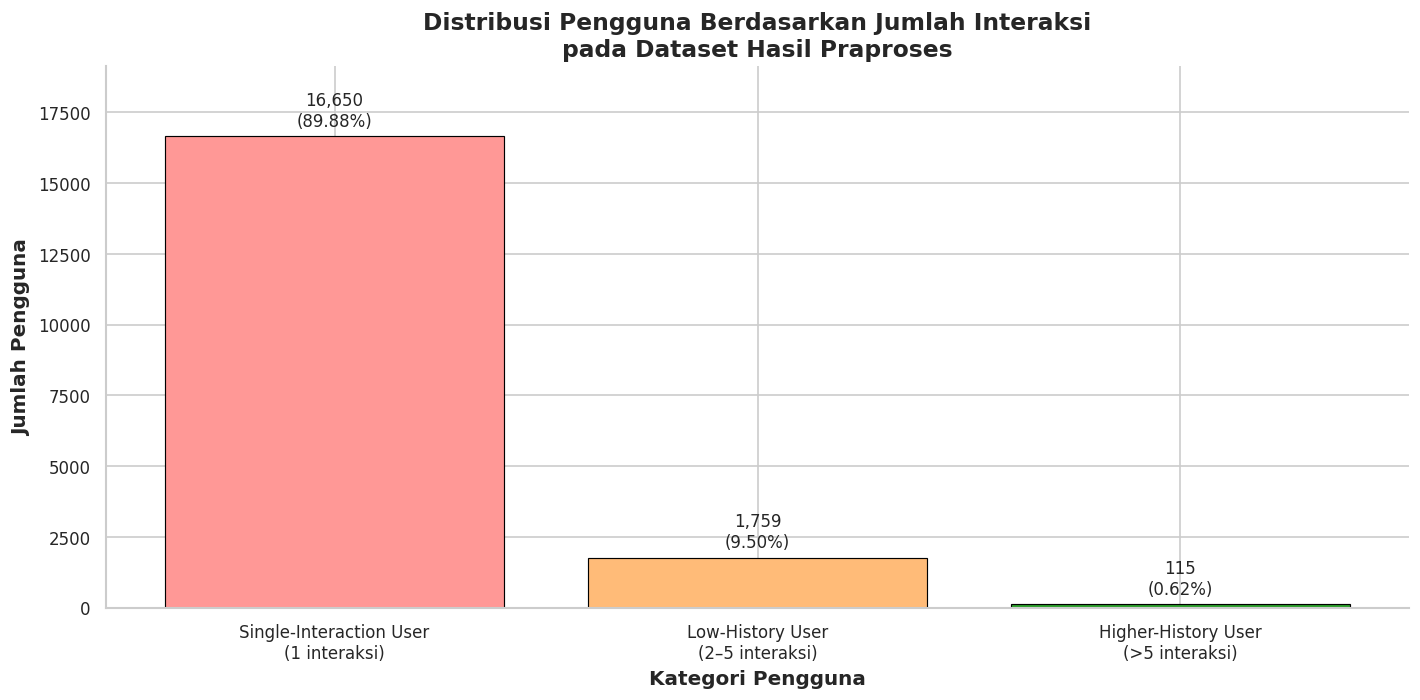

In [9]:
# ============================================================
# VISUALISASI DISTRIBUSI KATEGORI USER PADA DATASET PENUH
# ============================================================

plot_data_user_category = (
    user_category_distribution_full
    .copy()
)

plot_labels_user_category = [
    (
        f"{category}\n"
        f"({USER_CATEGORY_LABELS[str(category)]})"
    )
    for category in plot_data_user_category["kategori_user"]
]

plot_colors_user_category = [
    USER_CATEGORY_COLORS[str(category)]
    for category in plot_data_user_category["kategori_user"]
]

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    plot_labels_user_category,
    plot_data_user_category["jumlah_user"],
    color=plot_colors_user_category,
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Distribusi Pengguna Berdasarkan Jumlah Interaksi\n"
    "pada Dataset Hasil Praproses"
)

ax.set_xlabel("Kategori Pengguna")
ax.set_ylabel("Jumlah Pengguna")

ax.bar_label(
    bars,
    labels=[
        (
            f"{int(count):,}\n"
            f"({percentage:.2f}%)"
        )
        for count, percentage in zip(
            plot_data_user_category["jumlah_user"],
            plot_data_user_category["persentase_user"]
        )
    ],
    padding=4,
    fontsize=10
)

ax.set_ylim(
    0,
    plot_data_user_category["jumlah_user"].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="01_Distribusi_Interaksi_User_Dataset.png",
    close_figure=False
)

plt.show()
plt.close(fig)

Gambar berhasil disimpan: 02_Distribusi_Interaksi_Item.png (127.97 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

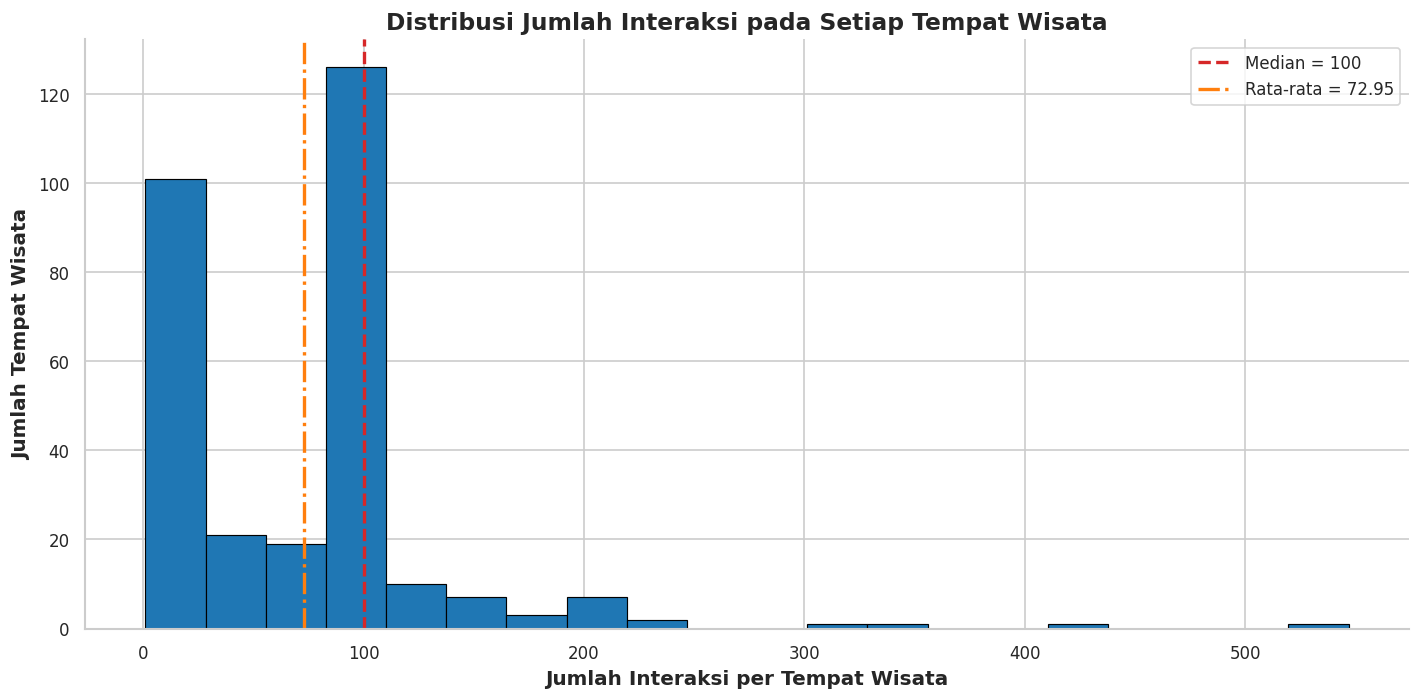

In [10]:
# ============================================================
# VISUALISASI DISTRIBUSI INTERAKSI ITEM
# ============================================================

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.hist(
    full_item_counts["jumlah_interaksi"],
    bins=20,
    color=MODEL_COLORS["SVD"],
    edgecolor="black",
    linewidth=0.7
)

ax.axvline(
    full_item_counts["jumlah_interaksi"].median(),
    color=METRIC_COLORS["RMSE"],
    linestyle="--",
    linewidth=2,
    label=(
        "Median = "
        f"{full_item_counts['jumlah_interaksi'].median():.0f}"
    )
)

ax.axvline(
    full_item_counts["jumlah_interaksi"].mean(),
    color=MODEL_COLORS["Funk SVD"],
    linestyle="-.",
    linewidth=2,
    label=(
        "Rata-rata = "
        f"{full_item_counts['jumlah_interaksi'].mean():.2f}"
    )
)

ax.set_title(
    "Distribusi Jumlah Interaksi pada Setiap Tempat Wisata"
)

ax.set_xlabel("Jumlah Interaksi per Tempat Wisata")
ax.set_ylabel("Jumlah Tempat Wisata")
ax.legend()

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="02_Distribusi_Interaksi_Item.png",
    close_figure=False
)

plt.show()
plt.close(fig)

Gambar berhasil disimpan: 03_Distribusi_Rating.png (130.76 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

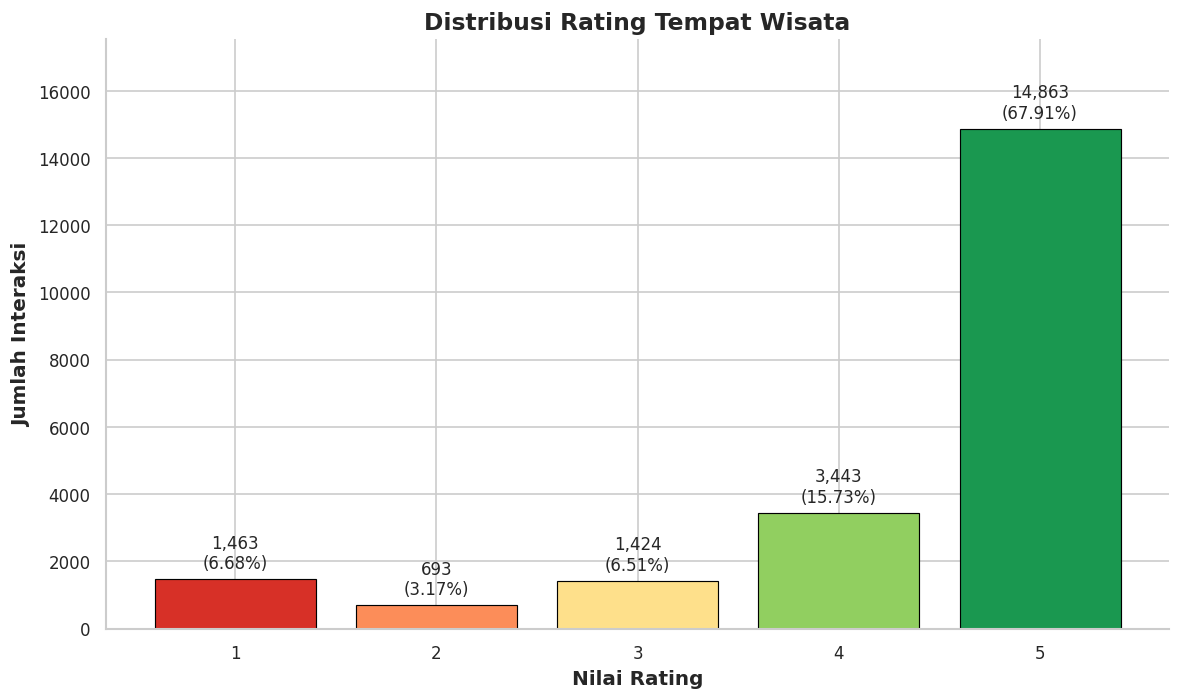

In [11]:
# ============================================================
# VISUALISASI DISTRIBUSI RATING
# ============================================================

fig, ax = plt.subplots(
    figsize=DEFAULT_FIGSIZE
)

rating_colors = [
    "#D73027",
    "#FC8D59",
    "#FEE08B",
    "#91CF60",
    "#1A9850"
]

bars = ax.bar(
    rating_distribution["rating"].astype(str),
    rating_distribution["jumlah_interaksi"],
    color=rating_colors[:len(rating_distribution)],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Distribusi Rating Tempat Wisata"
)

ax.set_xlabel("Nilai Rating")
ax.set_ylabel("Jumlah Interaksi")

ax.bar_label(
    bars,
    labels=[
        (
            f"{int(count):,}\n"
            f"({percentage:.2f}%)"
        )
        for count, percentage in zip(
            rating_distribution["jumlah_interaksi"],
            rating_distribution["persentase_interaksi"]
        )
    ],
    padding=4,
    fontsize=10
)

ax.set_ylim(
    0,
    rating_distribution["jumlah_interaksi"].max() * 1.18
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="03_Distribusi_Rating.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **1.4 Pembentukan Indeks Numerik User dan Item**

In [12]:
# ------------------------------------------------------------
# A. Membentuk mapping user
# ------------------------------------------------------------

unique_users = sorted(
    dataset["user_id"].dropna().unique().tolist()
)

user_mapping = pd.DataFrame({
    "user_id": unique_users,
    "user_idx_global": np.arange(
        len(unique_users),
        dtype=int
    )
})

user_to_global_idx = dict(
    zip(
        user_mapping["user_id"],
        user_mapping["user_idx_global"]
    )
)


# ------------------------------------------------------------
# B. Membentuk mapping item
# ------------------------------------------------------------

item_metadata = (
    dataset[
        [
            "place_id",
            "place_name",
            "review_date"
        ]
    ]
    .sort_values(
        "review_date",
        ascending=True
    )
    .drop_duplicates(
        subset=["place_id"],
        keep="last"
    )
    .sort_values("place_id")
    .reset_index(drop=True)
)

item_mapping = item_metadata[
    [
        "place_id",
        "place_name"
    ]
].copy()

item_mapping.insert(
    1,
    "item_idx_global",
    np.arange(
        len(item_mapping),
        dtype=int
    )
)

item_to_global_idx = dict(
    zip(
        item_mapping["place_id"],
        item_mapping["item_idx_global"]
    )
)


# ------------------------------------------------------------
# C. Menambahkan indeks ke dataset
# ------------------------------------------------------------

dataset["user_idx_global"] = (
    dataset["user_id"]
    .map(user_to_global_idx)
    .astype(int)
)

dataset["item_idx_global"] = (
    dataset["place_id"]
    .map(item_to_global_idx)
    .astype(int)
)

# Menata kembali urutan kolom
dataset = dataset[
    [
        "interaction_id",
        "user_id",
        "user_idx_global",
        "place_id",
        "item_idx_global",
        "place_name",
        "rating",
        "review_date",
        "source"
    ]
].copy()


# ------------------------------------------------------------
# D. Validasi mapping
# ------------------------------------------------------------

assert dataset["user_idx_global"].isna().sum() == 0, (
    "Terdapat user yang gagal memperoleh indeks global."
)

assert dataset["item_idx_global"].isna().sum() == 0, (
    "Terdapat item yang gagal memperoleh indeks global."
)

assert user_mapping["user_idx_global"].is_unique, (
    "Indeks global user tidak unik."
)

assert item_mapping["item_idx_global"].is_unique, (
    "Indeks global item tidak unik."
)

print("Pembentukan indeks numerik berhasil.")
print(f"Jumlah mapping user: {len(user_mapping):,}")
print(f"Jumlah mapping item: {len(item_mapping):,}")

display(user_mapping.head())
display(item_mapping.head())


# ------------------------------------------------------------
# E. Menyimpan mapping
# ------------------------------------------------------------

save_excel_output(
    data={
        "Mapping User": user_mapping,
        "Mapping Item": item_mapping
    },
    filename="04_Mapping_User_Item.xlsx",
    index=False
)

Pembentukan indeks numerik berhasil.
Jumlah mapping user: 18,524
Jumlah mapping item: 300


,user_id,user_idx_global
0,001AF9FD70E918DB9FA979578B66D880,0
1,001E93074CA44478EA8893438D4EE678,1
2,0020A45BBDF9BBF65690664334DB1822,2
3,0022E7EF8B7B77530FEE377D8CEA9BA2,3
4,002BF02DCDDE836C1E6370366A3233C6,4


,place_id,item_idx_global,place_name
0,10161841,0,Pasih Uug Beach
1,1020688,1,Medewi Beach
2,1024228,2,Bali Safari & Marine Park
3,1028742,3,Don Antonio Blanco Museum
4,10391715,4,I AM Bali - 3D Museum & Upside Down


Excel berhasil disimpan: 04_Mapping_User_Item.xlsx (489.16 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/04_Mapping_User_Item.xlsx')

## **1.5 Pembagian Development Data dan Final Test Data**

In [13]:
# ------------------------------------------------------------
# A. Membagi data pada tingkat interaksi
# ------------------------------------------------------------

development_data, final_test_data = train_test_split(
    dataset,
    test_size=FINAL_TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=SHUFFLE_DATA
)

development_data = (
    development_data
    .sort_values("interaction_id")
    .reset_index(drop=True)
    .copy()
)

final_test_data = (
    final_test_data
    .sort_values("interaction_id")
    .reset_index(drop=True)
    .copy()
)


# ------------------------------------------------------------
# B. Menghitung informasi yang tersedia pada development data
# ------------------------------------------------------------

development_user_counts = (
    development_data
    .groupby("user_id")
    .size()
    .rename("jumlah_interaksi_user_development")
)

development_item_counts = (
    development_data
    .groupby("place_id")
    .size()
    .rename("jumlah_interaksi_item_development")
)

development_user_mean = (
    development_data
    .groupby("user_id")["rating"]
    .mean()
    .rename("rata_rata_rating_user_development")
)

development_item_mean = (
    development_data
    .groupby("place_id")["rating"]
    .mean()
    .rename("rata_rata_rating_item_development")
)

development_global_mean = float(
    development_data["rating"].mean()
)


# ------------------------------------------------------------
# C. Menambahkan kondisi user dan item pada final test
# ------------------------------------------------------------

final_test_data[
    "jumlah_interaksi_user_development"
] = (
    final_test_data["user_id"]
    .map(development_user_counts)
    .fillna(0)
    .astype(int)
)

final_test_data[
    "jumlah_interaksi_item_development"
] = (
    final_test_data["place_id"]
    .map(development_item_counts)
    .fillna(0)
    .astype(int)
)

final_test_data[
    "user_seen_in_development"
] = (
    final_test_data[
        "jumlah_interaksi_user_development"
    ] > 0
)

final_test_data[
    "item_seen_in_development"
] = (
    final_test_data[
        "jumlah_interaksi_item_development"
    ] > 0
)

final_test_data["kategori_user"] = (
    final_test_data[
        "jumlah_interaksi_user_development"
    ]
    .apply(classify_user_history)
)

final_test_data["kategori_user"] = pd.Categorical(
    final_test_data["kategori_user"],
    categories=USER_CATEGORY_ORDER,
    ordered=True
)


# ------------------------------------------------------------
# D. Menentukan sumber prediksi yang nantinya digunakan
# ------------------------------------------------------------

prediction_source_conditions = [
    (
        final_test_data["user_seen_in_development"]
        & final_test_data["item_seen_in_development"]
    ),
    (
        ~final_test_data["user_seen_in_development"]
        & final_test_data["item_seen_in_development"]
    ),
    (
        final_test_data["user_seen_in_development"]
        & ~final_test_data["item_seen_in_development"]
    ),
    (
        ~final_test_data["user_seen_in_development"]
        & ~final_test_data["item_seen_in_development"]
    )
]

prediction_source_choices = [
    "Model Prediction",
    "Item Mean Fallback",
    "User Mean Fallback",
    "Global Mean Fallback"
]

final_test_data["expected_prediction_source"] = np.select(
    prediction_source_conditions,
    prediction_source_choices,
    default="Tidak Teridentifikasi"
)


# ------------------------------------------------------------
# E. Menambahkan nilai fallback referensi
# ------------------------------------------------------------

final_test_data[
    "rata_rata_rating_user_development"
] = (
    final_test_data["user_id"]
    .map(development_user_mean)
)

final_test_data[
    "rata_rata_rating_item_development"
] = (
    final_test_data["place_id"]
    .map(development_item_mean)
)

final_test_data[
    "global_mean_development"
] = development_global_mean


# ------------------------------------------------------------
# F. Ringkasan pembagian data
# ------------------------------------------------------------

development_users = set(
    development_data["user_id"].unique()
)

development_items = set(
    development_data["place_id"].unique()
)

final_test_users = set(
    final_test_data["user_id"].unique()
)

final_test_items = set(
    final_test_data["place_id"].unique()
)

unseen_final_test_users = (
    final_test_users - development_users
)

unseen_final_test_items = (
    final_test_items - development_items
)

split_summary = pd.DataFrame({
    "Metrik": [
        "Jumlah interaksi dataset penuh",
        "Jumlah interaksi development",
        "Jumlah interaksi final test",
        "Persentase development",
        "Persentase final test",
        "Jumlah user dataset penuh",
        "Jumlah user development",
        "Jumlah user final test",
        "User final test yang tidak muncul di development",
        "Jumlah item dataset penuh",
        "Jumlah item development",
        "Jumlah item final test",
        "Item final test yang tidak muncul di development",
        "Global mean development"
    ],
    "Nilai": [
        len(dataset),
        len(development_data),
        len(final_test_data),
        len(development_data) / len(dataset) * 100,
        len(final_test_data) / len(dataset) * 100,
        dataset["user_id"].nunique(),
        development_data["user_id"].nunique(),
        final_test_data["user_id"].nunique(),
        len(unseen_final_test_users),
        dataset["place_id"].nunique(),
        development_data["place_id"].nunique(),
        final_test_data["place_id"].nunique(),
        len(unseen_final_test_items),
        development_global_mean
    ]
})


# ------------------------------------------------------------
# G. Distribusi kategori user pada final test
# ------------------------------------------------------------

final_test_category_distribution = (
    final_test_data
    .groupby(
        "kategori_user",
        observed=False
    )
    .agg(
        jumlah_interaksi_final_test=(
            "interaction_id",
            "count"
        ),
        jumlah_user_unik=(
            "user_id",
            "nunique"
        ),
        rata_rata_rating_aktual=(
            "rating",
            "mean"
        )
    )
    .reset_index()
)

final_test_category_distribution[
    "persentase_interaksi_final_test"
] = (
    final_test_category_distribution[
        "jumlah_interaksi_final_test"
    ]
    / len(final_test_data)
    * 100
)

final_test_category_distribution[
    "deskripsi_kategori"
] = (
    final_test_category_distribution["kategori_user"]
    .astype("string")
    .map(USER_CATEGORY_LABELS)
)


# ------------------------------------------------------------
# H. Distribusi sumber prediksi/fallback
# ------------------------------------------------------------

EXPECTED_PREDICTION_SOURCE_ORDER = [
    "Model Prediction",
    "Item Mean Fallback",
    "User Mean Fallback",
    "Global Mean Fallback"
]

fallback_distribution = (
    final_test_data
    .groupby(
        "expected_prediction_source"
    )
    .agg(
        jumlah_interaksi=("interaction_id", "count"),
        jumlah_user_unik=("user_id", "nunique"),
        jumlah_item_unik=("place_id", "nunique")
    )
    .reindex(
        EXPECTED_PREDICTION_SOURCE_ORDER,
        fill_value=0
    )
    .reset_index()
)

fallback_distribution[
    "persentase_interaksi"
] = (
    fallback_distribution["jumlah_interaksi"]
    / len(final_test_data)
    * 100
)


# ------------------------------------------------------------
# I. Informasi overlap entitas
# ------------------------------------------------------------

entity_overlap_summary = pd.DataFrame({
    "Entitas": [
        "User",
        "Item"
    ],
    "Unik_Dataset_Penuh": [
        dataset["user_id"].nunique(),
        dataset["place_id"].nunique()
    ],
    "Unik_Development": [
        development_data["user_id"].nunique(),
        development_data["place_id"].nunique()
    ],
    "Unik_Final_Test": [
        final_test_data["user_id"].nunique(),
        final_test_data["place_id"].nunique()
    ],
    "Muncul_di_Keduanya": [
        len(development_users & final_test_users),
        len(development_items & final_test_items)
    ],
    "Hanya_di_Final_Test": [
        len(unseen_final_test_users),
        len(unseen_final_test_items)
    ]
})


# ------------------------------------------------------------
# J. Menampilkan hasil pembagian
# ------------------------------------------------------------

print("=" * 80)
print("RINGKASAN PEMBAGIAN DATA")
print("=" * 80)

display(split_summary)
display(final_test_category_distribution)
display(fallback_distribution)

print(
    f"Development data : "
    f"{len(development_data):,} interaksi"
)

print(
    f"Final test data  : "
    f"{len(final_test_data):,} interaksi"
)

print(
    f"Unseen user pada final test: "
    f"{len(unseen_final_test_users):,} user"
)

print(
    f"Unseen item pada final test: "
    f"{len(unseen_final_test_items):,} item"
)


# ------------------------------------------------------------
# K. Menyimpan ringkasan pembagian data
# ------------------------------------------------------------

save_excel_output(
    data={
        "Ringkasan Split": split_summary,
        "Overlap Entitas": entity_overlap_summary,
        "Kategori User Final Test": (
            final_test_category_distribution
        ),
        "Distribusi Fallback": fallback_distribution
    },
    filename="05_Ringkasan_Pembagian_Data.xlsx",
    index=False
)

RINGKASAN PEMBAGIAN DATA


,Metrik,Nilai
0,Jumlah interaksi dataset penuh,21886.000000
1,Jumlah interaksi development,17508.000000
2,Jumlah interaksi final test,4378.000000
3,Persentase development,79.996345
4,Persentase final test,20.003655
5,Jumlah user dataset penuh,18524.000000
6,Jumlah user development,15126.000000
7,Jumlah user final test,4147.000000
8,User final test yang tidak muncul di development,3398.000000
9,Jumlah item dataset penuh,300.000000


,kategori_user,jumlah_interaksi_final_test,jumlah_user_unik,rata_rata_rating_aktual,persentase_interaksi_final_test,deskripsi_kategori
0,Unseen User,3454,3398,4.337869,78.894472,0 interaksi
1,Single-Interaction User,463,427,4.390929,10.575605,1 interaksi
2,Low-History User,373,282,4.418231,8.519872,2–5 interaksi
3,Higher-History User,88,40,4.193182,2.010050,>5 interaksi


,expected_prediction_source,jumlah_interaksi,jumlah_user_unik,jumlah_item_unik,persentase_interaksi
0,Model Prediction,921,746,206,21.037003
1,Item Mean Fallback,3453,3397,251,78.871631
2,User Mean Fallback,3,3,3,0.068524
3,Global Mean Fallback,1,1,1,0.022841


Development data : 17,508 interaksi
Final test data  : 4,378 interaksi
Unseen user pada final test: 3,398 user
Unseen item pada final test: 4 item
Excel berhasil disimpan: 05_Ringkasan_Pembagian_Data.xlsx (8.08 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/05_Ringkasan_Pembagian_Data.xlsx')

Gambar berhasil disimpan: 06_Distribusi_Kategori_User_Final_Test.png (284.58 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

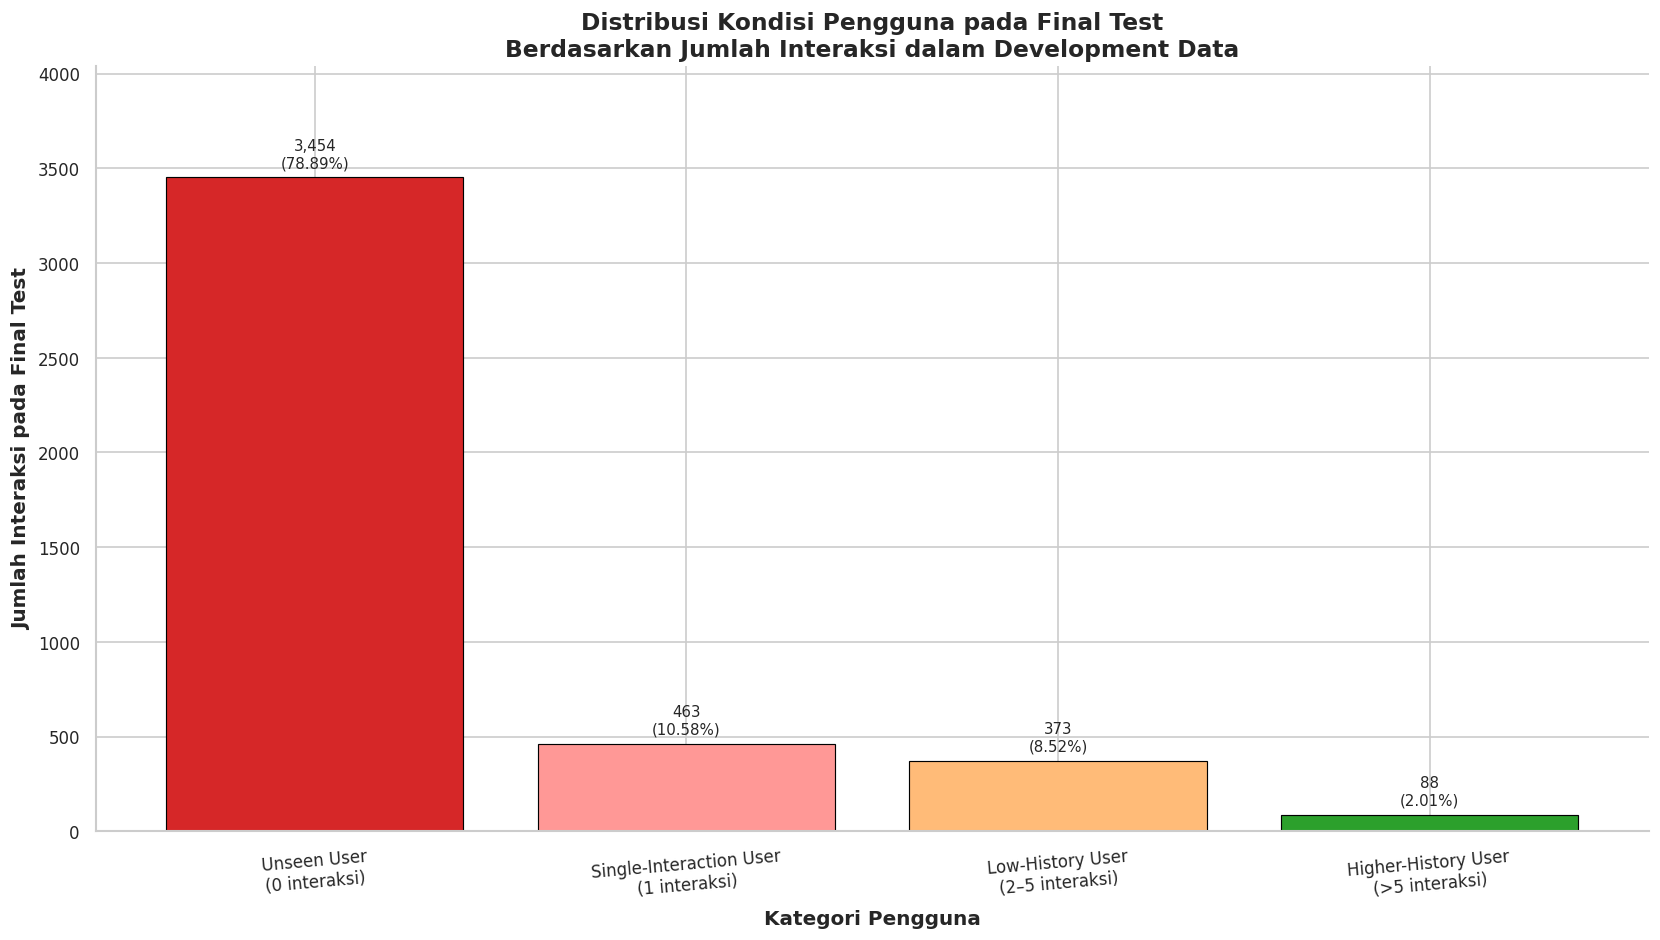

In [14]:
# ============================================================
# VISUALISASI KATEGORI USER PADA FINAL TEST
# ============================================================

plot_category_final_test = (
    final_test_category_distribution
    .copy()
)

plot_labels_final_test = [
    (
        f"{category}\n"
        f"({USER_CATEGORY_LABELS[str(category)]})"
    )
    for category in plot_category_final_test["kategori_user"]
]

plot_colors_final_test = [
    USER_CATEGORY_COLORS[str(category)]
    for category in plot_category_final_test["kategori_user"]
]

fig, ax = plt.subplots(
    figsize=LARGE_FIGSIZE
)

bars = ax.bar(
    plot_labels_final_test,
    plot_category_final_test[
        "jumlah_interaksi_final_test"
    ],
    color=plot_colors_final_test,
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Distribusi Kondisi Pengguna pada Final Test\n"
    "Berdasarkan Jumlah Interaksi dalam Development Data"
)

ax.set_xlabel("Kategori Pengguna")
ax.set_ylabel("Jumlah Interaksi pada Final Test")

ax.bar_label(
    bars,
    labels=[
        (
            f"{int(count):,}\n"
            f"({percentage:.2f}%)"
        )
        for count, percentage in zip(
            plot_category_final_test[
                "jumlah_interaksi_final_test"
            ],
            plot_category_final_test[
                "persentase_interaksi_final_test"
            ]
        )
    ],
    padding=4,
    fontsize=9
)

maximum_count = plot_category_final_test[
    "jumlah_interaksi_final_test"
].max()

ax.set_ylim(
    0,
    maximum_count * 1.17
)

plt.xticks(
    rotation=5,
    ha="center"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="06_Distribusi_Kategori_User_Final_Test.png",
    close_figure=False
)

plt.show()
plt.close(fig)

Gambar berhasil disimpan: 07_Distribusi_Fallback_Final_Test.png (205.84 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

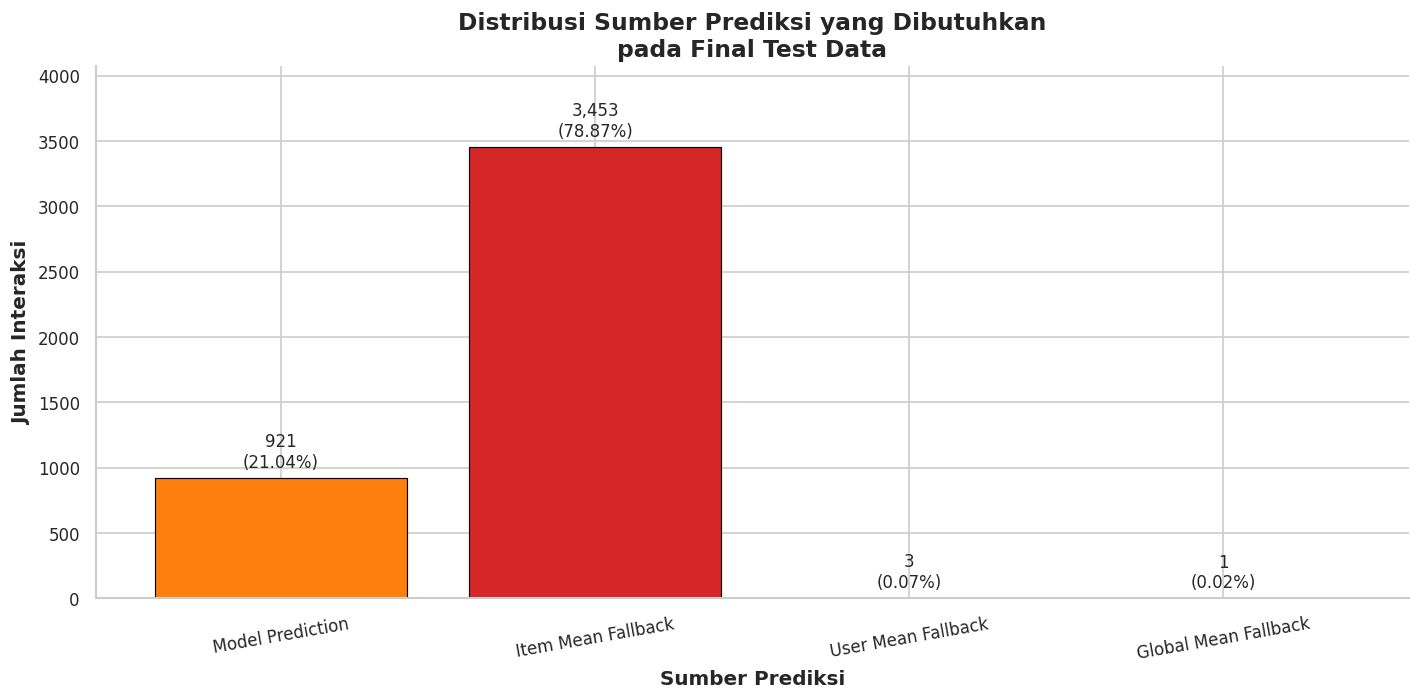

In [15]:
# ============================================================
# VISUALISASI DISTRIBUSI FALLBACK PADA FINAL TEST
# ============================================================

prediction_source_colors = {
    "Model Prediction": MODEL_COLORS["Funk SVD"],
    "Item Mean Fallback": USER_CATEGORY_COLORS["Unseen User"],
    "User Mean Fallback": USER_CATEGORY_COLORS["Low-History User"],
    "Global Mean Fallback": FALLBACK_COLOR
}

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    fallback_distribution[
        "expected_prediction_source"
    ],
    fallback_distribution[
        "jumlah_interaksi"
    ],
    color=[
        prediction_source_colors[source]
        for source in fallback_distribution[
            "expected_prediction_source"
        ]
    ],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Distribusi Sumber Prediksi yang Dibutuhkan\n"
    "pada Final Test Data"
)

ax.set_xlabel("Sumber Prediksi")
ax.set_ylabel("Jumlah Interaksi")

ax.bar_label(
    bars,
    labels=[
        (
            f"{int(count):,}\n"
            f"({percentage:.2f}%)"
        )
        for count, percentage in zip(
            fallback_distribution["jumlah_interaksi"],
            fallback_distribution[
                "persentase_interaksi"
            ]
        )
    ],
    padding=4,
    fontsize=10
)

maximum_fallback_count = fallback_distribution[
    "jumlah_interaksi"
].max()

if maximum_fallback_count > 0:
    ax.set_ylim(
        0,
        maximum_fallback_count * 1.18
    )

plt.xticks(
    rotation=10,
    ha="center"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="07_Distribusi_Fallback_Final_Test.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **1.6 Penyimpanan Development Data dan Final Test Data**

In [16]:
# ============================================================
# 1.6 PENYIMPANAN DEVELOPMENT DATA DAN FINAL TEST DATA
# ============================================================

# Menyimpan development data
save_excel_output(
    data=development_data,
    filename="08_Data_Development.xlsx",
    index=False
)

# Menyimpan final test data beserta kondisi user dan item
save_excel_output(
    data=final_test_data,
    filename="09_Data_Final_Test.xlsx",
    index=False
)

print("Development data dan final test data berhasil disimpan.")

Excel berhasil disimpan: 08_Data_Development.xlsx (1252.73 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 09_Data_Final_Test.xlsx (522.92 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Development data dan final test data berhasil disimpan.


## **1.7 Pemeriksaan Akhir Persiapan Data**

In [17]:
development_interaction_ids = set(
    development_data["interaction_id"]
)

final_test_interaction_ids = set(
    final_test_data["interaction_id"]
)

interaction_overlap = (
    development_interaction_ids
    & final_test_interaction_ids
)

# ------------------------------------------------------------
# A. Assertion pemeriksaan akhir
# ------------------------------------------------------------

assert len(interaction_overlap) == 0, (
    "Terdapat interaction_id yang muncul pada development "
    "dan final test secara bersamaan."
)

assert (
    len(development_data)
    + len(final_test_data)
    == len(dataset)
), (
    "Jumlah development dan final test tidak sama "
    "dengan jumlah dataset penuh."
)

assert development_data["interaction_id"].is_unique, (
    "Interaction ID pada development data tidak unik."
)

assert final_test_data["interaction_id"].is_unique, (
    "Interaction ID pada final test data tidak unik."
)

assert development_data[
    [
        "user_idx_global",
        "item_idx_global"
    ]
].isna().sum().sum() == 0, (
    "Terdapat indeks numerik kosong pada development data."
)

assert final_test_data[
    [
        "user_idx_global",
        "item_idx_global"
    ]
].isna().sum().sum() == 0, (
    "Terdapat indeks numerik kosong pada final test data."
)

assert (
    final_test_category_distribution[
        "jumlah_interaksi_final_test"
    ].sum()
    == len(final_test_data)
), (
    "Total interaksi pada kategori user tidak sesuai "
    "dengan jumlah final test."
)

assert (
    fallback_distribution["jumlah_interaksi"].sum()
    == len(final_test_data)
), (
    "Total distribusi fallback tidak sesuai "
    "dengan jumlah final test."
)


# ------------------------------------------------------------
# B. Ringkasan objek yang tersedia untuk tahap modeling
# ------------------------------------------------------------

modeling_objects = pd.DataFrame({
    "Nama Objek": [
        "dataset",
        "development_data",
        "final_test_data",
        "user_mapping",
        "item_mapping",
        "development_user_counts",
        "development_item_counts",
        "development_user_mean",
        "development_item_mean",
        "development_global_mean"
    ],
    "Keterangan": [
        "Dataset penuh setelah validasi dan encoding",
        "Data untuk Grid Search dan 5-Fold CV",
        "Data untuk evaluasi final model",
        "Mapping user ke indeks global",
        "Mapping item ke indeks global",
        "Jumlah interaksi user pada development",
        "Jumlah interaksi item pada development",
        "Rata-rata rating user pada development",
        "Rata-rata rating item pada development",
        "Rata-rata seluruh rating development"
    ]
})

print("=" * 80)
print("STEP 1 SELESAI")
print("=" * 80)

print(
    f"Dataset penuh    : "
    f"{len(dataset):,} interaksi"
)

print(
    f"Development data : "
    f"{len(development_data):,} interaksi "
    f"({len(development_data) / len(dataset) * 100:.2f}%)"
)

print(
    f"Final test data  : "
    f"{len(final_test_data):,} interaksi "
    f"({len(final_test_data) / len(dataset) * 100:.2f}%)"
)

print(
    f"Jumlah user      : "
    f"{dataset['user_id'].nunique():,}"
)

print(
    f"Jumlah item      : "
    f"{dataset['place_id'].nunique():,}"
)

print(
    f"Matrix sparsity  : "
    f"{matrix_sparsity:.6f}%"
)

print(
    f"Global mean development: "
    f"{development_global_mean:.6f}"
)

print()
print(
    "Dataset telah siap digunakan pada tahap "
    "optimasi hyperparameter."
)

display(modeling_objects)
display(development_data.head())
display(final_test_data.head())

STEP 1 SELESAI
Dataset penuh    : 21,886 interaksi
Development data : 17,508 interaksi (80.00%)
Final test data  : 4,378 interaksi (20.00%)
Jumlah user      : 18,524
Jumlah item      : 300
Matrix sparsity  : 99.606169%
Global mean development: 4.350868

Dataset telah siap digunakan pada tahap optimasi hyperparameter.


,Nama Objek,Keterangan
0,dataset,Dataset penuh setelah validasi dan encoding
1,development_data,Data untuk Grid Search dan 5-Fold CV
2,final_test_data,Data untuk evaluasi final model
3,user_mapping,Mapping user ke indeks global
4,item_mapping,Mapping item ke indeks global
5,development_user_counts,Jumlah interaksi user pada development
6,development_item_counts,Jumlah interaksi item pada development
7,development_user_mean,Rata-rata rating user pada development
8,development_item_mean,Rata-rata rating item pada development
9,development_global_mean,Rata-rata seluruh rating development


,interaction_id,user_id,user_idx_global,place_id,item_idx_global,place_name,rating,review_date,source
0,0,269E34905434FF14CF8D57361A334763,14538,1912575,42,Tirta Empul Temple,5,2026-03-01,Tripadvisor
1,1,3F715883F8E07AC8E859C1CB739AB349,15014,379340,81,Tanah Lot,4,2026-02-28,Tripadvisor
2,2,3F715883F8E07AC8E859C1CB739AB349,15014,12396108,12,Kelingking Beach,4,2026-02-28,Tripadvisor
3,4,ACFC17D66E6EF539E7EB81B8174BD7B9,16983,12396108,12,Kelingking Beach,5,2026-02-27,Tripadvisor
4,5,2CE963D0E6A9E4C88E2F0C5269DDB769,14674,378969,76,Sacred Monkey Forest Sanctuary,3,2026-02-27,Tripadvisor


,interaction_id,user_id,user_idx_global,place_id,item_idx_global,place_name,rating,review_date,source,jumlah_interaksi_user_development,jumlah_interaksi_item_development,user_seen_in_development,item_seen_in_development,kategori_user,expected_prediction_source,rata_rata_rating_user_development,rata_rata_rating_item_development,global_mean_development
0,3,8EF878BEE1C146976972BED37294BF4F,16474,1793975,40,Bali Zoo,5,2026-02-27,Tripadvisor,0,120,False,True,Unseen User,Item Mean Fallback,NaN,4.958333,4.350868
1,6,7E5C77AC5B26D50A00FA63340D00133E,16152,1793975,40,Bali Zoo,5,2026-02-26,Tripadvisor,0,120,False,True,Unseen User,Item Mean Fallback,NaN,4.958333,4.350868
2,17,A07FBA109BCFD4CCC26F739F11D947B9,16769,1912575,42,Tirta Empul Temple,3,2026-02-25,Tripadvisor,0,34,False,True,Unseen User,Item Mean Fallback,NaN,4.441176,4.350868
3,31,100000109853106649694,307,ChIJgZvtEpU_0i0RjpCO5_jZSUI,247,Duta Orchid Garden,5,2026-02-24,Google Review,0,110,False,True,Unseen User,Item Mean Fallback,NaN,4.672727,4.350868
4,34,103706239272595809611,3128,ChIJ0Zo39DZH0i0R0acI0bADr2U,136,Tirta Gangga,5,2026-02-24,Google Review,0,80,False,True,Unseen User,Item Mean Fallback,NaN,4.662500,4.350868


# **Optimasi Hyperparameter**

## **SVD**

### **2.1.1 Konfigurasi Hyperparameter dan Fold**

In [18]:
SVD_K_VALUES = [5, 20, 50]

# Memastikan kandidat tersusun dari nilai terkecil
SVD_K_VALUES = sorted(set(SVD_K_VALUES))

# Membentuk susunan fold yang akan digunakan bersama
# oleh SVD, Funk SVD, dan SVD++
if "CV_SPLITS" not in globals():

    cv_splitter = KFold(
        n_splits=N_SPLITS,
        shuffle=SHUFFLE_DATA,
        random_state=RANDOM_STATE
    )

    CV_SPLITS = list(
        cv_splitter.split(development_data)
    )

    print(
        "CV_SPLITS berhasil dibuat dan akan digunakan "
        "oleh seluruh model."
    )

else:
    print(
        "CV_SPLITS sudah tersedia dan digunakan kembali."
    )


# ------------------------------------------------------------
# Validasi kandidat k
# ------------------------------------------------------------

minimum_fold_train_size = min(
    len(train_indices)
    for train_indices, _ in CV_SPLITS
)

minimum_fold_user_count = min(
    development_data
    .iloc[train_indices]["user_id"]
    .nunique()
    for train_indices, _ in CV_SPLITS
)

minimum_fold_item_count = min(
    development_data
    .iloc[train_indices]["place_id"]
    .nunique()
    for train_indices, _ in CV_SPLITS
)

maximum_valid_k = min(
    minimum_fold_user_count,
    minimum_fold_item_count
) - 1

invalid_k_values = [
    k
    for k in SVD_K_VALUES
    if k <= 0 or k > maximum_valid_k
]

if invalid_k_values:
    raise ValueError(
        "Kandidat k berikut tidak valid untuk ukuran "
        f"matriks fold: {invalid_k_values}. "
        f"Nilai maksimum yang diperbolehkan adalah "
        f"{maximum_valid_k}."
    )


# ------------------------------------------------------------
# Ringkasan konfigurasi
# ------------------------------------------------------------

svd_configuration = pd.DataFrame({
    "Komponen": [
        "Model",
        "Pendekatan",
        "Metode imputasi",
        "Metode centering",
        "Kandidat komponen laten",
        "Jumlah kandidat",
        "Cross-validation",
        "Metrik utama",
        "Metrik pendamping",
        "Skala prediksi"
    ],
    "Nilai": [
        "SVD",
        "Classical Singular Value Decomposition",
        "Global Mean Imputation",
        "Training Global Mean Centering",
        str(SVD_K_VALUES),
        len(SVD_K_VALUES),
        f"{N_SPLITS}-Fold Cross Validation",
        PRIMARY_METRIC,
        SECONDARY_METRIC,
        f"{RATING_MIN:.0f}–{RATING_MAX:.0f}"
    ]
})

display(svd_configuration)

print(f"Jumlah development data : {len(development_data):,}")
print(f"Jumlah fold             : {len(CV_SPLITS)}")
print(f"Kandidat k              : {SVD_K_VALUES}")
print(f"Maksimum k valid        : {maximum_valid_k}")

CV_SPLITS berhasil dibuat dan akan digunakan oleh seluruh model.


,Komponen,Nilai
0,Model,SVD
1,Pendekatan,Classical Singular Value Decomposition
2,Metode imputasi,Global Mean Imputation
3,Metode centering,Training Global Mean Centering
4,Kandidat komponen laten,"[5, 20, 50]"
5,Jumlah kandidat,3
6,Cross-validation,5-Fold Cross Validation
7,Metrik utama,RMSE
8,Metrik pendamping,MAE
9,Skala prediksi,1–5


Jumlah development data : 17,508
Jumlah fold             : 5
Kandidat k              : [5, 20, 50]
Maksimum k valid        : 288


### **2.1.2 Dokumentasi Pembagian Fold**

In [19]:
cv_fold_assignment_array = np.zeros(
    len(development_data),
    dtype=int
)

cv_fold_summary_records = []

for fold_number, (train_indices, validation_indices) in enumerate(
    CV_SPLITS,
    start=1
):
    cv_fold_assignment_array[
        validation_indices
    ] = fold_number

    fold_train = (
        development_data
        .iloc[train_indices]
    )

    fold_validation = (
        development_data
        .iloc[validation_indices]
    )

    train_users = set(
        fold_train["user_id"].unique()
    )

    validation_users = set(
        fold_validation["user_id"].unique()
    )

    train_items = set(
        fold_train["place_id"].unique()
    )

    validation_items = set(
        fold_validation["place_id"].unique()
    )

    cv_fold_summary_records.append({
        "fold": fold_number,
        "jumlah_data_training": len(fold_train),
        "jumlah_data_validasi": len(fold_validation),
        "jumlah_user_training": (
            fold_train["user_id"].nunique()
        ),
        "jumlah_user_validasi": (
            fold_validation["user_id"].nunique()
        ),
        "jumlah_unseen_user_validasi": len(
            validation_users - train_users
        ),
        "jumlah_item_training": (
            fold_train["place_id"].nunique()
        ),
        "jumlah_item_validasi": (
            fold_validation["place_id"].nunique()
        ),
        "jumlah_unseen_item_validasi": len(
            validation_items - train_items
        )
    })


cv_fold_assignment = (
    development_data[
        [
            "interaction_id",
            "user_id",
            "place_id",
            "place_name",
            "rating"
        ]
    ]
    .copy()
)

cv_fold_assignment["validation_fold"] = (
    cv_fold_assignment_array
)

cv_fold_assignment = (
    cv_fold_assignment
    .sort_values(
        [
            "validation_fold",
            "interaction_id"
        ]
    )
    .reset_index(drop=True)
)

cv_fold_summary = pd.DataFrame(
    cv_fold_summary_records
)


# ------------------------------------------------------------
# Validasi fold
# ------------------------------------------------------------

assert (
    cv_fold_assignment["validation_fold"] > 0
).all(), (
    "Terdapat development data yang belum memperoleh fold."
)

assert (
    cv_fold_assignment["interaction_id"].nunique()
    == len(development_data)
), (
    "Terdapat interaction_id yang muncul lebih dari satu kali "
    "dalam dokumentasi fold."
)

assert (
    cv_fold_summary["jumlah_data_validasi"].sum()
    == len(development_data)
), (
    "Total data validasi seluruh fold tidak sesuai dengan "
    "jumlah development data."
)

display(cv_fold_summary)


# ------------------------------------------------------------
# Menyimpan dokumentasi fold
# ------------------------------------------------------------

save_excel_output(
    data={
        "Ringkasan Fold": cv_fold_summary,
        "Assignment Fold": cv_fold_assignment
    },
    filename="10_CV_Fold_Assignment.xlsx",
    index=False
)

,fold,jumlah_data_training,jumlah_data_validasi,jumlah_user_training,jumlah_user_validasi,jumlah_unseen_user_validasi,jumlah_item_training,jumlah_item_validasi,jumlah_unseen_item_validasi
0,1,14006,3502,12335,3334,2791,292,265,4
1,2,14006,3502,12360,3330,2766,290,262,6
2,3,14006,3502,12335,3341,2791,294,256,2
3,4,14007,3501,12323,3367,2803,294,254,2
4,5,14007,3501,12339,3359,2787,289,268,7


Excel berhasil disimpan: 10_CV_Fold_Assignment.xlsx (957.31 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/10_CV_Fold_Assignment.xlsx')

### **2.1.3 Fungsi Training SVD**

In [20]:
def train_classical_svd(
    train_data: pd.DataFrame,
    n_components: int
) -> Dict[str, Any]:
    """
    Melatih classical SVD menggunakan data training.

    Tahapan:
    1. Membentuk indeks lokal user dan item dari training.
    2. Menghitung global mean, user mean, dan item mean.
    3. Melakukan global mean centering.
    4. Membentuk sparse matrix rating centered.
    5. Melakukan truncated SVD menjadi U, Sigma, dan Vt.

    Parameters
    ----------
    train_data:
        DataFrame training yang memuat user_id, place_id,
        dan rating.

    n_components:
        Jumlah komponen singular yang dipertahankan.

    Returns
    -------
    Dictionary yang memuat komponen model dan statistik
    data training.
    """

    required_columns = {
        "user_id",
        "place_id",
        "rating"
    }

    missing_columns = (
        required_columns - set(train_data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Kolom training SVD tidak lengkap: "
            f"{sorted(missing_columns)}"
        )

    if train_data.empty:
        raise ValueError(
            "Data training SVD tidak boleh kosong."
        )

    training_start_time = time.perf_counter()

    # --------------------------------------------------------
    # A. Membentuk identitas lokal berdasarkan training
    # --------------------------------------------------------

    train_users = sorted(
        train_data["user_id"]
        .dropna()
        .unique()
        .tolist()
    )

    train_items = sorted(
        train_data["place_id"]
        .dropna()
        .unique()
        .tolist()
    )

    user_to_local_index = {
        user_id: index
        for index, user_id in enumerate(train_users)
    }

    item_to_local_index = {
        place_id: index
        for index, place_id in enumerate(train_items)
    }

    number_of_train_users = len(train_users)
    number_of_train_items = len(train_items)

    maximum_components = min(
        number_of_train_users,
        number_of_train_items
    ) - 1

    if n_components > maximum_components:
        raise ValueError(
            f"n_components={n_components} melebihi "
            f"batas maksimum {maximum_components}."
        )


    # --------------------------------------------------------
    # B. Statistik training untuk model dan fallback
    # --------------------------------------------------------

    global_mean = float(
        train_data["rating"].mean()
    )

    user_mean = (
        train_data
        .groupby("user_id")["rating"]
        .mean()
    )

    item_mean = (
        train_data
        .groupby("place_id")["rating"]
        .mean()
    )

    user_interaction_count = (
        train_data
        .groupby("user_id")
        .size()
    )

    item_interaction_count = (
        train_data
        .groupby("place_id")
        .size()
    )


    # --------------------------------------------------------
    # C. Membentuk matriks rating centered
    # --------------------------------------------------------

    row_indices = (
        train_data["user_id"]
        .map(user_to_local_index)
        .to_numpy(dtype=int)
    )

    column_indices = (
        train_data["place_id"]
        .map(item_to_local_index)
        .to_numpy(dtype=int)
    )

    centered_ratings = (
        train_data["rating"]
        .to_numpy(dtype=float)
        - global_mean
    )

    centered_matrix = csr_matrix(
        (
            centered_ratings,
            (
                row_indices,
                column_indices
            )
        ),
        shape=(
            number_of_train_users,
            number_of_train_items
        ),
        dtype=np.float64
    )


    # --------------------------------------------------------
    # D. Truncated Singular Value Decomposition
    # --------------------------------------------------------

    # v0 dibuat deterministik untuk membantu reproducibility.
    initial_vector = np.ones(
        min(centered_matrix.shape),
        dtype=np.float64
    )

    U, singular_values, Vt = svds(
        centered_matrix,
        k=n_components,
        which="LM",
        v0=initial_vector,
        return_singular_vectors=True
    )

    # scipy.sparse.linalg.svds mengembalikan singular value
    # dalam urutan menaik. Urutan dibalik menjadi menurun.
    descending_order = np.argsort(
        singular_values
    )[::-1]

    singular_values = singular_values[
        descending_order
    ]

    U = U[:, descending_order]
    Vt = Vt[descending_order, :]

    training_time_seconds = (
        time.perf_counter()
        - training_start_time
    )


    # --------------------------------------------------------
    # E. Objek model
    # --------------------------------------------------------

    model = {
        "model_name": "SVD",
        "n_components": int(n_components),
        "global_mean": global_mean,
        "user_mean": user_mean,
        "item_mean": item_mean,
        "user_interaction_count": (
            user_interaction_count
        ),
        "item_interaction_count": (
            item_interaction_count
        ),
        "user_to_local_index": (
            user_to_local_index
        ),
        "item_to_local_index": (
            item_to_local_index
        ),
        "local_index_to_user": train_users,
        "local_index_to_item": train_items,
        "U": U,
        "singular_values": singular_values,
        "Vt": Vt,
        "number_of_train_users": (
            number_of_train_users
        ),
        "number_of_train_items": (
            number_of_train_items
        ),
        "number_of_train_interactions": (
            len(train_data)
        ),
        "training_time_seconds": (
            training_time_seconds
        )
    }

    return model

### **2.1.4 Fungsi Prediksi dan Fallback SVD**

In [21]:
def predict_classical_svd(
    model: Dict[str, Any],
    test_data: pd.DataFrame
) -> pd.DataFrame:
    """
    Menghasilkan prediksi rating menggunakan classical SVD
    dan fallback prediction.

    Returns
    -------
    DataFrame berisi rating aktual, rating prediksi,
    sumber prediksi, kategori user, dan prediction error.
    """

    required_columns = {
        "interaction_id",
        "user_id",
        "place_id",
        "rating"
    }

    missing_columns = (
        required_columns - set(test_data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Kolom test SVD tidak lengkap: "
            f"{sorted(missing_columns)}"
        )

    prediction_start_time = time.perf_counter()

    prediction_result = (
        test_data
        .copy()
        .reset_index(drop=True)
    )

    user_to_local_index = (
        model["user_to_local_index"]
    )

    item_to_local_index = (
        model["item_to_local_index"]
    )

    global_mean = model["global_mean"]

    user_seen = (
        prediction_result["user_id"]
        .isin(user_to_local_index)
    )

    item_seen = (
        prediction_result["place_id"]
        .isin(item_to_local_index)
    )


    # --------------------------------------------------------
    # A. Jumlah interaksi user dan item pada training
    # --------------------------------------------------------

    prediction_result[
        "jumlah_interaksi_user_training"
    ] = (
        prediction_result["user_id"]
        .map(model["user_interaction_count"])
        .fillna(0)
        .astype(int)
    )

    prediction_result[
        "jumlah_interaksi_item_training"
    ] = (
        prediction_result["place_id"]
        .map(model["item_interaction_count"])
        .fillna(0)
        .astype(int)
    )

    prediction_result["kategori_user"] = (
        prediction_result[
            "jumlah_interaksi_user_training"
        ]
        .apply(classify_user_history)
    )

    prediction_result["kategori_user"] = (
        pd.Categorical(
            prediction_result["kategori_user"],
            categories=USER_CATEGORY_ORDER,
            ordered=True
        )
    )

    prediction_result[
        "user_seen_in_training"
    ] = user_seen

    prediction_result[
        "item_seen_in_training"
    ] = item_seen


    # --------------------------------------------------------
    # B. Inisialisasi prediksi menggunakan global mean
    # --------------------------------------------------------

    predicted_ratings = np.full(
        len(prediction_result),
        global_mean,
        dtype=np.float64
    )

    prediction_sources = np.full(
        len(prediction_result),
        "Global Mean Fallback",
        dtype=object
    )


    # --------------------------------------------------------
    # C. Seen user dan seen item: model prediction
    # --------------------------------------------------------

    model_prediction_mask = (
        user_seen & item_seen
    )

    if model_prediction_mask.any():

        model_rows = prediction_result.loc[
            model_prediction_mask
        ]

        local_user_indices = (
            model_rows["user_id"]
            .map(user_to_local_index)
            .to_numpy(dtype=int)
        )

        local_item_indices = (
            model_rows["place_id"]
            .map(item_to_local_index)
            .to_numpy(dtype=int)
        )

        U_selected = (
            model["U"][local_user_indices, :]
            * model["singular_values"]
        )

        V_selected = (
            model["Vt"][
                :,
                local_item_indices
            ]
            .T
        )

        model_predictions = (
            global_mean
            + np.sum(
                U_selected * V_selected,
                axis=1
            )
        )

        predicted_ratings[
            model_prediction_mask.to_numpy()
        ] = model_predictions

        prediction_sources[
            model_prediction_mask.to_numpy()
        ] = "Model Prediction"


    # --------------------------------------------------------
    # D. Unseen user dan seen item: item mean
    # --------------------------------------------------------

    item_mean_fallback_mask = (
        ~user_seen & item_seen
    )

    if item_mean_fallback_mask.any():

        item_mean_predictions = (
            prediction_result.loc[
                item_mean_fallback_mask,
                "place_id"
            ]
            .map(model["item_mean"])
            .fillna(global_mean)
            .to_numpy(dtype=float)
        )

        predicted_ratings[
            item_mean_fallback_mask.to_numpy()
        ] = item_mean_predictions

        prediction_sources[
            item_mean_fallback_mask.to_numpy()
        ] = "Item Mean Fallback"


    # --------------------------------------------------------
    # E. Seen user dan unseen item: user mean
    # --------------------------------------------------------

    user_mean_fallback_mask = (
        user_seen & ~item_seen
    )

    if user_mean_fallback_mask.any():

        user_mean_predictions = (
            prediction_result.loc[
                user_mean_fallback_mask,
                "user_id"
            ]
            .map(model["user_mean"])
            .fillna(global_mean)
            .to_numpy(dtype=float)
        )

        predicted_ratings[
            user_mean_fallback_mask.to_numpy()
        ] = user_mean_predictions

        prediction_sources[
            user_mean_fallback_mask.to_numpy()
        ] = "User Mean Fallback"


    # --------------------------------------------------------
    # F. Membatasi prediksi pada skala rating
    # --------------------------------------------------------

    predicted_ratings = clip_rating(
        predicted_ratings
    )

    prediction_result[
        "rating_prediction"
    ] = predicted_ratings

    prediction_result[
        "prediction_source"
    ] = prediction_sources


    # --------------------------------------------------------
    # G. Menghitung prediction error
    # --------------------------------------------------------

    prediction_result["prediction_error"] = (
        prediction_result["rating"]
        - prediction_result["rating_prediction"]
    )

    prediction_result["absolute_error"] = (
        prediction_result[
            "prediction_error"
        ].abs()
    )

    prediction_result["squared_error"] = (
        prediction_result[
            "prediction_error"
        ] ** 2
    )

    prediction_time_seconds = (
        time.perf_counter()
        - prediction_start_time
    )

    prediction_result[
        "prediction_time_seconds"
    ] = prediction_time_seconds

    return prediction_result

### **2.1.5 Fungsi Evaluasi per Kelompok**

In [22]:
def evaluate_prediction_dataframe(
    prediction_data: pd.DataFrame
) -> Dict[str, float]:
    """
    Menghitung RMSE dan MAE keseluruhan dari hasil prediksi.
    """

    if prediction_data.empty:
        return {
            "rmse": np.nan,
            "mae": np.nan,
            "jumlah_prediksi": 0
        }

    actual = prediction_data[
        "rating"
    ].to_numpy(dtype=float)

    predicted = prediction_data[
        "rating_prediction"
    ].to_numpy(dtype=float)

    return {
        "rmse": calculate_rmse(
            actual,
            predicted
        ),
        "mae": calculate_mae(
            actual,
            predicted
        ),
        "jumlah_prediksi": len(
            prediction_data
        )
    }


def evaluate_by_group(
    prediction_data: pd.DataFrame,
    group_column: str,
    group_order: Optional[Sequence[str]] = None
) -> pd.DataFrame:
    """
    Menghitung RMSE, MAE, dan jumlah prediksi berdasarkan
    kolom kelompok tertentu.
    """

    records = []

    if group_order is None:
        group_values = (
            prediction_data[group_column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    else:
        group_values = list(group_order)

    for group_value in group_values:

        group_data = prediction_data[
            prediction_data[group_column].astype(str)
            == str(group_value)
        ]

        metrics = evaluate_prediction_dataframe(
            group_data
        )

        records.append({
            group_column: group_value,
            "jumlah_prediksi": (
                metrics["jumlah_prediksi"]
            ),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"]
        })

    return pd.DataFrame(records)

### **2.1.6 Grid Search dan 5-Fold Cross Validation SVD**

In [23]:
svd_fold_result_records = []
svd_prediction_records = []
svd_category_result_records = []
svd_source_result_records = []

svd_grid_search_start_time = time.perf_counter()

total_svd_experiments = (
    len(SVD_K_VALUES)
    * len(CV_SPLITS)
)

svd_progress_bar = tqdm(
    total=total_svd_experiments,
    desc="Grid Search SVD",
    unit="eksperimen"
)


for n_components in SVD_K_VALUES:

    for fold_number, (
        train_indices,
        validation_indices
    ) in enumerate(
        CV_SPLITS,
        start=1
    ):

        fold_train_data = (
            development_data
            .iloc[train_indices]
            .copy()
            .reset_index(drop=True)
        )

        fold_validation_data = (
            development_data
            .iloc[validation_indices]
            .copy()
            .reset_index(drop=True)
        )


        # ----------------------------------------------------
        # A. Training model
        # ----------------------------------------------------

        svd_model_fold = train_classical_svd(
            train_data=fold_train_data,
            n_components=n_components
        )


        # ----------------------------------------------------
        # B. Prediksi data validasi
        # ----------------------------------------------------

        prediction_start_time = time.perf_counter()

        svd_prediction_fold = (
            predict_classical_svd(
                model=svd_model_fold,
                test_data=fold_validation_data
            )
        )

        fold_prediction_time = (
            time.perf_counter()
            - prediction_start_time
        )


        # ----------------------------------------------------
        # C. Evaluasi keseluruhan
        # ----------------------------------------------------

        overall_metrics = (
            evaluate_prediction_dataframe(
                svd_prediction_fold
            )
        )

        svd_fold_result_records.append({
            "model": "SVD",
            "n_components": n_components,
            "fold": fold_number,
            "jumlah_data_training": (
                len(fold_train_data)
            ),
            "jumlah_data_validasi": (
                len(fold_validation_data)
            ),
            "jumlah_user_training": (
                fold_train_data[
                    "user_id"
                ].nunique()
            ),
            "jumlah_item_training": (
                fold_train_data[
                    "place_id"
                ].nunique()
            ),
            "jumlah_user_validasi": (
                fold_validation_data[
                    "user_id"
                ].nunique()
            ),
            "jumlah_item_validasi": (
                fold_validation_data[
                    "place_id"
                ].nunique()
            ),
            "rmse": overall_metrics["rmse"],
            "mae": overall_metrics["mae"],
            "training_time_seconds": (
                svd_model_fold[
                    "training_time_seconds"
                ]
            ),
            "prediction_time_seconds": (
                fold_prediction_time
            ),
            "total_time_seconds": (
                svd_model_fold[
                    "training_time_seconds"
                ]
                + fold_prediction_time
            ),
            "global_mean_training": (
                svd_model_fold["global_mean"]
            )
        })


        # ----------------------------------------------------
        # D. Evaluasi berdasarkan kategori user
        # ----------------------------------------------------

        category_metrics = evaluate_by_group(
            prediction_data=svd_prediction_fold,
            group_column="kategori_user",
            group_order=USER_CATEGORY_ORDER
        )

        category_metrics.insert(
            0,
            "fold",
            fold_number
        )

        category_metrics.insert(
            0,
            "n_components",
            n_components
        )

        category_metrics.insert(
            0,
            "model",
            "SVD"
        )

        svd_category_result_records.extend(
            category_metrics.to_dict(
                orient="records"
            )
        )


        # ----------------------------------------------------
        # E. Evaluasi berdasarkan sumber prediksi
        # ----------------------------------------------------

        source_metrics = evaluate_by_group(
            prediction_data=svd_prediction_fold,
            group_column="prediction_source",
            group_order=(
                EXPECTED_PREDICTION_SOURCE_ORDER
            )
        )

        source_metrics.insert(
            0,
            "fold",
            fold_number
        )

        source_metrics.insert(
            0,
            "n_components",
            n_components
        )

        source_metrics.insert(
            0,
            "model",
            "SVD"
        )

        svd_source_result_records.extend(
            source_metrics.to_dict(
                orient="records"
            )
        )


        # ----------------------------------------------------
        # F. Menyimpan detail prediksi
        # ----------------------------------------------------

        svd_prediction_fold.insert(
            0,
            "fold",
            fold_number
        )

        svd_prediction_fold.insert(
            0,
            "n_components",
            n_components
        )

        svd_prediction_fold.insert(
            0,
            "model",
            "SVD"
        )

        svd_prediction_records.append(
            svd_prediction_fold
        )


        # ----------------------------------------------------
        # G. Membersihkan objek model fold
        # ----------------------------------------------------

        del svd_model_fold
        gc.collect()

        svd_progress_bar.update(1)


svd_progress_bar.close()

svd_grid_search_total_time = (
    time.perf_counter()
    - svd_grid_search_start_time
)


# ------------------------------------------------------------
# H. Menggabungkan hasil
# ------------------------------------------------------------

svd_fold_results = pd.DataFrame(
    svd_fold_result_records
)

svd_prediction_results = pd.concat(
    svd_prediction_records,
    ignore_index=True
)

svd_category_results = pd.DataFrame(
    svd_category_result_records
)

svd_source_results = pd.DataFrame(
    svd_source_result_records
)


print("Grid Search SVD selesai.")
print(
    f"Jumlah eksperimen : "
    f"{total_svd_experiments}"
)

print(
    f"Total waktu       : "
    f"{format_execution_time(svd_grid_search_total_time)}"
)

display(svd_fold_results)

Grid Search SVD:   0%|          | 0/15 [00:00<?, ?eksperimen/s]

Grid Search SVD selesai.
Jumlah eksperimen : 15
Total waktu       : 6.19 detik


,model,n_components,fold,jumlah_data_training,jumlah_data_validasi,jumlah_user_training,jumlah_item_training,jumlah_user_validasi,jumlah_item_validasi,rmse,mae,training_time_seconds,prediction_time_seconds,total_time_seconds,global_mean_training
0,SVD,5,1,14006,3502,12335,292,3334,265,1.080415,0.778044,0.103344,0.022578,0.125922,4.346423
1,SVD,5,2,14006,3502,12360,290,3330,262,1.082051,0.781841,0.063263,0.021180,0.084443,4.356347
2,SVD,5,3,14006,3502,12335,294,3341,256,1.103289,0.797267,0.066541,0.021202,0.087744,4.353491
3,SVD,5,4,14007,3501,12323,294,3367,254,1.071128,0.776471,0.062407,0.021116,0.083523,4.346827
4,SVD,5,5,14007,3501,12339,289,3359,268,1.097087,0.800943,0.060597,0.021124,0.081721,4.351253
5,SVD,20,1,14006,3502,12335,292,3334,265,1.080450,0.778306,0.076285,0.031110,0.107394,4.346423
6,SVD,20,2,14006,3502,12360,290,3330,262,1.082389,0.782308,0.077872,0.032721,0.110593,4.356347
7,SVD,20,3,14006,3502,12335,294,3341,256,1.103557,0.797556,0.075849,0.032604,0.108453,4.353491
8,SVD,20,4,14007,3501,12323,294,3367,254,1.070695,0.776233,0.074821,0.032639,0.107461,4.346827
9,SVD,20,5,14007,3501,12339,289,3359,268,1.097103,0.800930,0.076214,0.032888,0.109102,4.351253


### **2.1.7 Ringkasan Hasil Grid Search**

In [24]:
svd_grid_summary = (
    svd_fold_results
    .groupby(
        "n_components",
        as_index=False
    )
    .agg(
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        min_rmse=("rmse", "min"),
        max_rmse=("rmse", "max"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        min_mae=("mae", "min"),
        max_mae=("mae", "max"),
        mean_training_time_seconds=(
            "training_time_seconds",
            "mean"
        ),
        mean_prediction_time_seconds=(
            "prediction_time_seconds",
            "mean"
        ),
        mean_total_time_seconds=(
            "total_time_seconds",
            "mean"
        ),
        total_training_time_seconds=(
            "training_time_seconds",
            "sum"
        ),
        total_prediction_time_seconds=(
            "prediction_time_seconds",
            "sum"
        )
    )
)

svd_grid_summary[
    "coefficient_of_variation_rmse"
] = (
    svd_grid_summary["std_rmse"]
    / svd_grid_summary["mean_rmse"]
)

svd_grid_summary[
    "coefficient_of_variation_mae"
] = (
    svd_grid_summary["std_mae"]
    / svd_grid_summary["mean_mae"]
)

svd_grid_summary = (
    svd_grid_summary
    .sort_values(
        by=[
            "mean_rmse",
            "mean_mae",
            "n_components"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

svd_grid_summary.insert(
    0,
    "ranking",
    np.arange(
        1,
        len(svd_grid_summary) + 1
    )
)

display(svd_grid_summary)

,ranking,n_components,mean_rmse,std_rmse,min_rmse,max_rmse,mean_mae,std_mae,min_mae,max_mae,mean_training_time_seconds,mean_prediction_time_seconds,mean_total_time_seconds,total_training_time_seconds,total_prediction_time_seconds,coefficient_of_variation_rmse,coefficient_of_variation_mae
0,1,5,1.086794,0.013102,1.071128,1.103289,0.786913,0.011374,0.776471,0.800943,0.071231,0.021440,0.092671,0.356153,0.107201,0.012056,0.014454
1,2,20,1.086839,0.013286,1.070695,1.103557,0.787066,0.011391,0.776233,0.800930,0.076208,0.032392,0.108601,0.381041,0.161962,0.012225,0.014472
2,3,50,1.087107,0.013218,1.071180,1.103600,0.787186,0.011381,0.776466,0.801213,0.428715,0.061879,0.490593,2.143573,0.309393,0.012159,0.014458


### **2.1.8 Pemilihan Hyperparameter Terbaik**

In [25]:
best_svd_result = (
    svd_grid_summary
    .iloc[0]
    .copy()
)

best_svd_k = int(
    best_svd_result["n_components"]
)

best_svd_parameter = pd.DataFrame({
    "Komponen": [
        "Model",
        "Hyperparameter",
        "Nilai terbaik",
        "Mean RMSE",
        "Standar deviasi RMSE",
        "Mean MAE",
        "Standar deviasi MAE",
        "Mean waktu training",
        "Mean waktu prediksi",
        "Aturan pemilihan",
        "Status penggunaan"
    ],
    "Nilai": [
        "SVD",
        "Jumlah komponen laten (k)",
        best_svd_k,
        best_svd_result["mean_rmse"],
        best_svd_result["std_rmse"],
        best_svd_result["mean_mae"],
        best_svd_result["std_mae"],
        best_svd_result[
            "mean_training_time_seconds"
        ],
        best_svd_result[
            "mean_prediction_time_seconds"
        ],
        (
            "Mean RMSE terendah; "
            "Mean MAE sebagai kriteria kedua"
        ),
        (
            "Digunakan pada evaluasi final "
            "setelah seluruh model selesai dituning"
        )
    ]
})

print("=" * 80)
print("HYPERPARAMETER SVD TERBAIK")
print("=" * 80)
print(f"Jumlah komponen laten : {best_svd_k}")
print(
    f"Mean RMSE             : "
    f"{best_svd_result['mean_rmse']:.6f}"
)
print(
    f"Mean MAE              : "
    f"{best_svd_result['mean_mae']:.6f}"
)
print(
    f"Standar deviasi RMSE  : "
    f"{best_svd_result['std_rmse']:.6f}"
)
print(
    f"Standar deviasi MAE   : "
    f"{best_svd_result['std_mae']:.6f}"
)

display(best_svd_parameter)

HYPERPARAMETER SVD TERBAIK
Jumlah komponen laten : 5
Mean RMSE             : 1.086794
Mean MAE              : 0.786913
Standar deviasi RMSE  : 0.013102
Standar deviasi MAE   : 0.011374


,Komponen,Nilai
0,Model,SVD
1,Hyperparameter,Jumlah komponen laten (k)
2,Nilai terbaik,5
3,Mean RMSE,1.086794
4,Standar deviasi RMSE,0.013102
5,Mean MAE,0.786913
6,Standar deviasi MAE,0.011374
7,Mean waktu training,0.071231
8,Mean waktu prediksi,0.021440
9,Aturan pemilihan,Mean RMSE terendah; Mean MAE sebagai kriteria kedua


### **2.1.9 Ringkasan Kategori User dan Sumber Prediksi**

In [26]:
best_svd_category_results = (
    svd_category_results[
        svd_category_results[
            "n_components"
        ] == best_svd_k
    ]
    .copy()
)

best_svd_category_summary = (
    best_svd_category_results
    .groupby(
        "kategori_user",
        as_index=False
    )
    .agg(
        total_prediksi=(
            "jumlah_prediksi",
            "sum"
        ),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std")
    )
)

best_svd_category_summary[
    "persentase_prediksi"
] = (
    best_svd_category_summary[
        "total_prediksi"
    ]
    / best_svd_category_summary[
        "total_prediksi"
    ].sum()
    * 100
)

best_svd_category_summary[
    "deskripsi_kategori"
] = (
    best_svd_category_summary[
        "kategori_user"
    ]
    .map(USER_CATEGORY_LABELS)
)


best_svd_source_results = (
    svd_source_results[
        svd_source_results[
            "n_components"
        ] == best_svd_k
    ]
    .copy()
)

best_svd_source_summary = (
    best_svd_source_results
    .groupby(
        "prediction_source",
        as_index=False
    )
    .agg(
        total_prediksi=(
            "jumlah_prediksi",
            "sum"
        ),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std")
    )
)

best_svd_source_summary[
    "persentase_prediksi"
] = (
    best_svd_source_summary[
        "total_prediksi"
    ]
    / best_svd_source_summary[
        "total_prediksi"
    ].sum()
    * 100
)

display(best_svd_category_summary)
display(best_svd_source_summary)

,kategori_user,total_prediksi,mean_rmse,std_rmse,mean_mae,std_mae,persentase_prediksi,deskripsi_kategori
0,Higher-History User,289,0.773837,0.075481,0.638766,0.019735,1.650674,>5 interaksi
1,Low-History User,1293,0.873129,0.047877,0.713818,0.031764,7.385195,2–5 interaksi
2,Single-Interaction User,1777,0.971929,0.056898,0.778738,0.030302,10.149646,1 interaksi
3,Unseen User,14149,1.122585,0.019730,0.797599,0.015624,80.814485,0 interaksi


,prediction_source,total_prediksi,mean_rmse,std_rmse,mean_mae,std_mae,persentase_prediksi
0,Global Mean Fallback,16,0.836947,0.358737,0.725294,0.165481,0.091387
1,Item Mean Fallback,14133,1.122663,0.019574,0.797613,0.015458,80.723098
2,Model Prediction,3349,0.921126,0.027749,0.742979,0.009538,19.128398
3,User Mean Fallback,10,0.461440,0.316526,0.361130,0.255060,0.057117


### **2.1.10 Penyimpanan Hasil SVD**

In [27]:
save_excel_output(
    data={
        "Konfigurasi": svd_configuration,
        "Ringkasan Grid Search": svd_grid_summary,
        "Hasil Per Fold": svd_fold_results,
        "Metrik Kategori User": svd_category_results,
        "Metrik Sumber Prediksi": svd_source_results,
        "Kategori Best K": (
            best_svd_category_summary
        ),
        "Sumber Prediksi Best K": (
            best_svd_source_summary
        ),
        "Detail Prediksi Validasi": (
            svd_prediction_results
        )
    },
    filename="11_SVD_Hasil_Grid_Search.xlsx",
    index=False
)

save_excel_output(
    data={
        "Parameter Terbaik": best_svd_parameter,
        "Ranking Kandidat": svd_grid_summary,
        "Kategori User": (
            best_svd_category_summary
        ),
        "Sumber Prediksi": (
            best_svd_source_summary
        )
    },
    filename="16_SVD_Parameter_Terbaik.xlsx",
    index=False
)

Excel berhasil disimpan: 11_SVD_Hasil_Grid_Search.xlsx (8151.62 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 16_SVD_Parameter_Terbaik.xlsx (9.23 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/16_SVD_Parameter_Terbaik.xlsx')

### **2.1.11 Visualisasi RMSE SVD**

Gambar berhasil disimpan: 12_SVD_RMSE_By_Latent_Factor.png (156.76 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

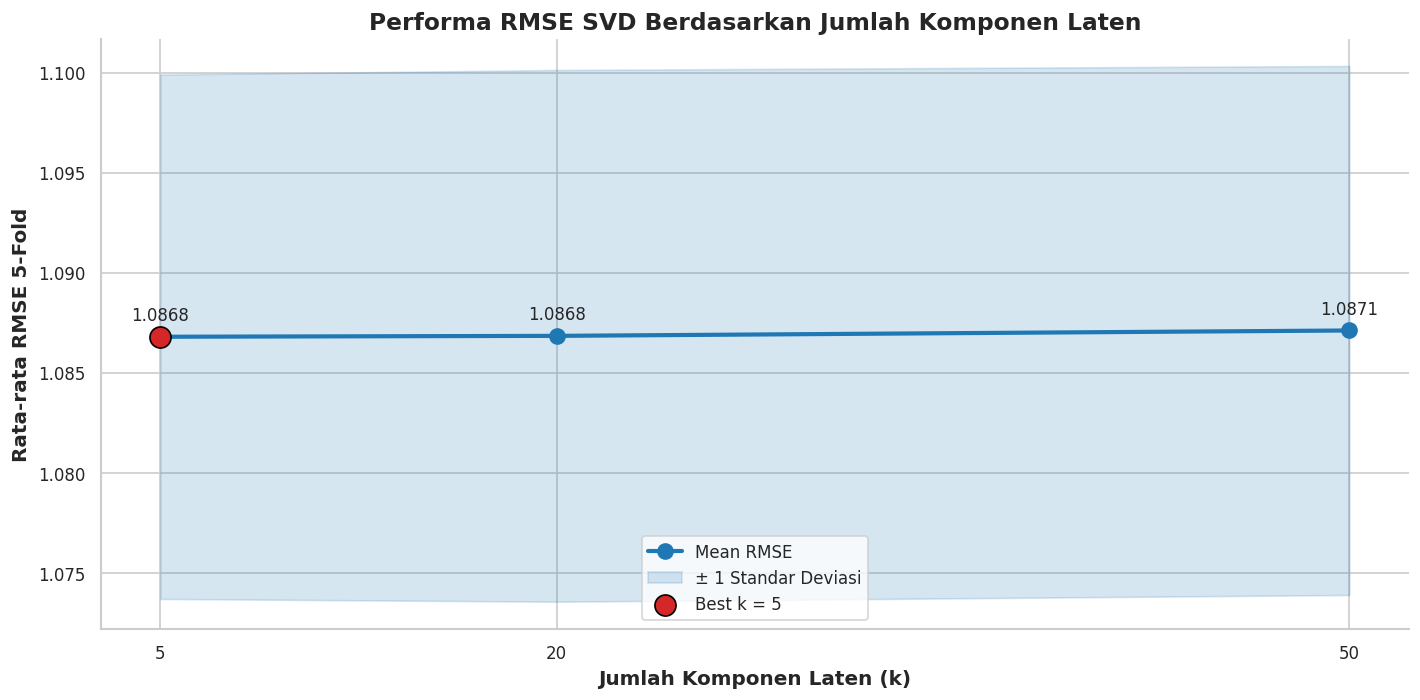

In [28]:
svd_plot_data = (
    svd_grid_summary
    .sort_values("n_components")
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.plot(
    svd_plot_data["n_components"],
    svd_plot_data["mean_rmse"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=MODEL_COLORS["SVD"],
    label="Mean RMSE"
)

ax.fill_between(
    svd_plot_data["n_components"],
    (
        svd_plot_data["mean_rmse"]
        - svd_plot_data["std_rmse"]
    ),
    (
        svd_plot_data["mean_rmse"]
        + svd_plot_data["std_rmse"]
    ),
    color=MODEL_COLORS["SVD"],
    alpha=0.18,
    label="± 1 Standar Deviasi"
)

ax.scatter(
    [best_svd_k],
    [best_svd_result["mean_rmse"]],
    s=160,
    color=METRIC_COLORS["RMSE"],
    edgecolor="black",
    linewidth=1,
    zorder=5,
    label=f"Best k = {best_svd_k}"
)

for _, row in svd_plot_data.iterrows():
    ax.annotate(
        f"{row['mean_rmse']:.4f}",
        (
            row["n_components"],
            row["mean_rmse"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Performa RMSE SVD Berdasarkan Jumlah Komponen Laten"
)

ax.set_xlabel(
    "Jumlah Komponen Laten (k)"
)

ax.set_ylabel(
    "Rata-rata RMSE 5-Fold"
)

ax.set_xticks(
    svd_plot_data["n_components"]
)

ax.legend()

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="12_SVD_RMSE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.1.12 Visualisasi MAE SVD**

Gambar berhasil disimpan: 13_SVD_MAE_By_Latent_Factor.png (151.53 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

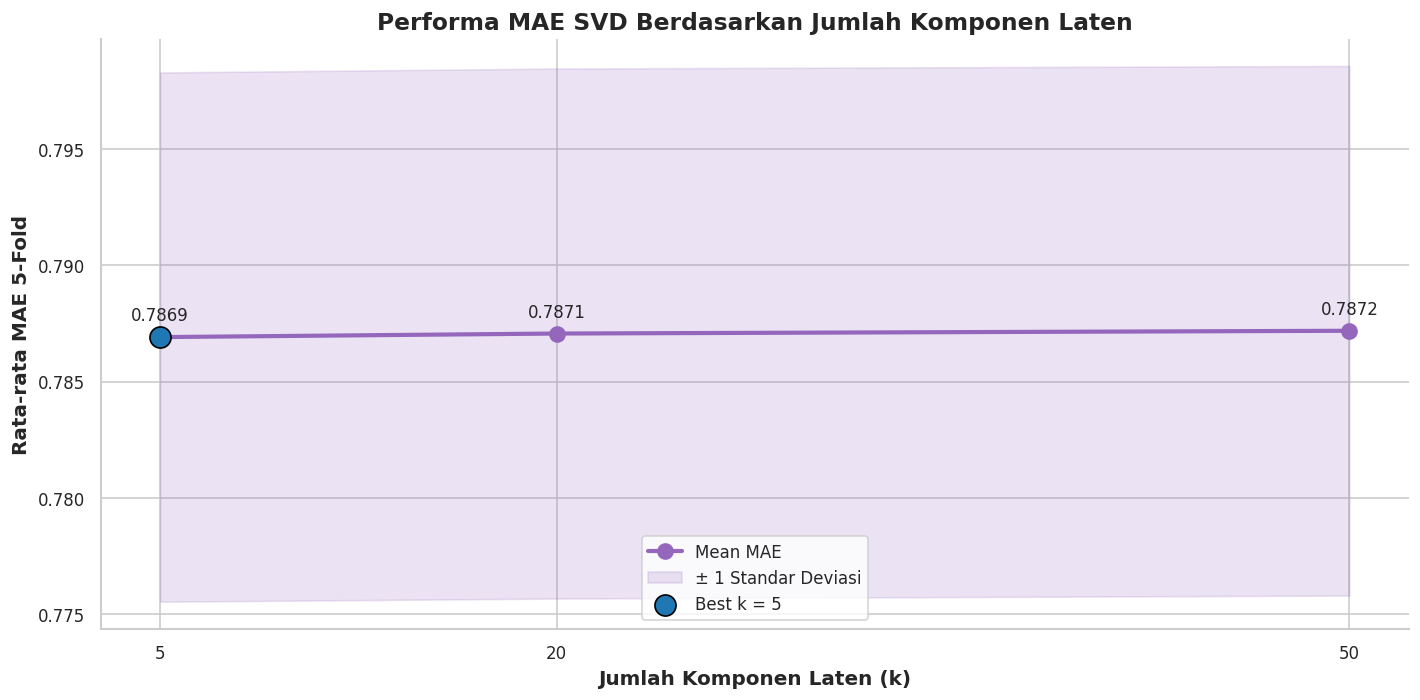

In [29]:
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.plot(
    svd_plot_data["n_components"],
    svd_plot_data["mean_mae"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=METRIC_COLORS["MAE"],
    label="Mean MAE"
)

ax.fill_between(
    svd_plot_data["n_components"],
    (
        svd_plot_data["mean_mae"]
        - svd_plot_data["std_mae"]
    ),
    (
        svd_plot_data["mean_mae"]
        + svd_plot_data["std_mae"]
    ),
    color=METRIC_COLORS["MAE"],
    alpha=0.18,
    label="± 1 Standar Deviasi"
)

ax.scatter(
    [best_svd_k],
    [best_svd_result["mean_mae"]],
    s=160,
    color=MODEL_COLORS["SVD"],
    edgecolor="black",
    linewidth=1,
    zorder=5,
    label=f"Best k = {best_svd_k}"
)

for _, row in svd_plot_data.iterrows():
    ax.annotate(
        f"{row['mean_mae']:.4f}",
        (
            row["n_components"],
            row["mean_mae"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Performa MAE SVD Berdasarkan Jumlah Komponen Laten"
)

ax.set_xlabel(
    "Jumlah Komponen Laten (k)"
)

ax.set_ylabel(
    "Rata-rata MAE 5-Fold"
)

ax.set_xticks(
    svd_plot_data["n_components"]
)

ax.legend()

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="13_SVD_MAE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.1.13 Boxplot RMSE Antarfold**

Gambar berhasil disimpan: 14_SVD_Boxplot_RMSE_By_Latent_Factor.png (104.58 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

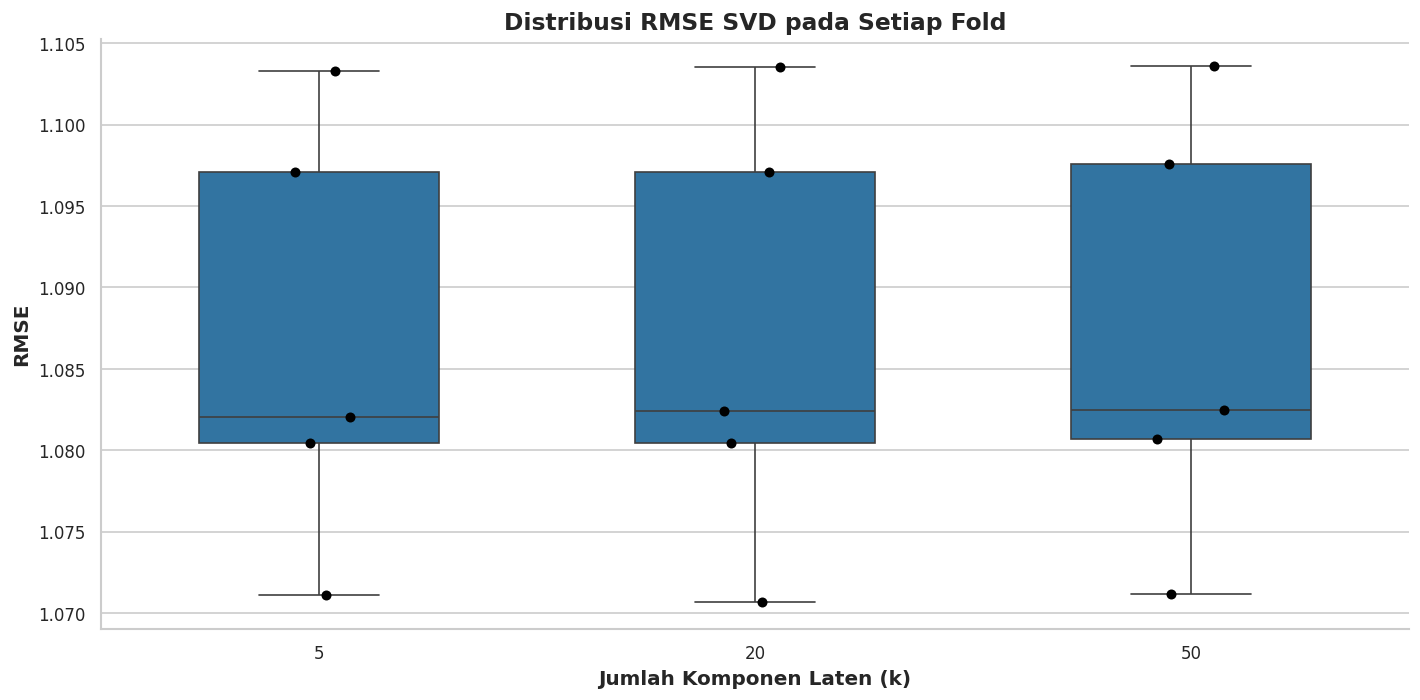

In [30]:
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

sns.boxplot(
    data=svd_fold_results,
    x="n_components",
    y="rmse",
    color=MODEL_COLORS["SVD"],
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=svd_fold_results,
    x="n_components",
    y="rmse",
    color="black",
    size=6,
    jitter=0.08,
    ax=ax
)

ax.set_title(
    "Distribusi RMSE SVD pada Setiap Fold"
)

ax.set_xlabel(
    "Jumlah Komponen Laten (k)"
)

ax.set_ylabel(
    "RMSE"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="14_SVD_Boxplot_RMSE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.1.14 Boxplot MAE Antarfold**

Gambar berhasil disimpan: 15_SVD_Boxplot_MAE_By_Latent_Factor.png (100.62 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

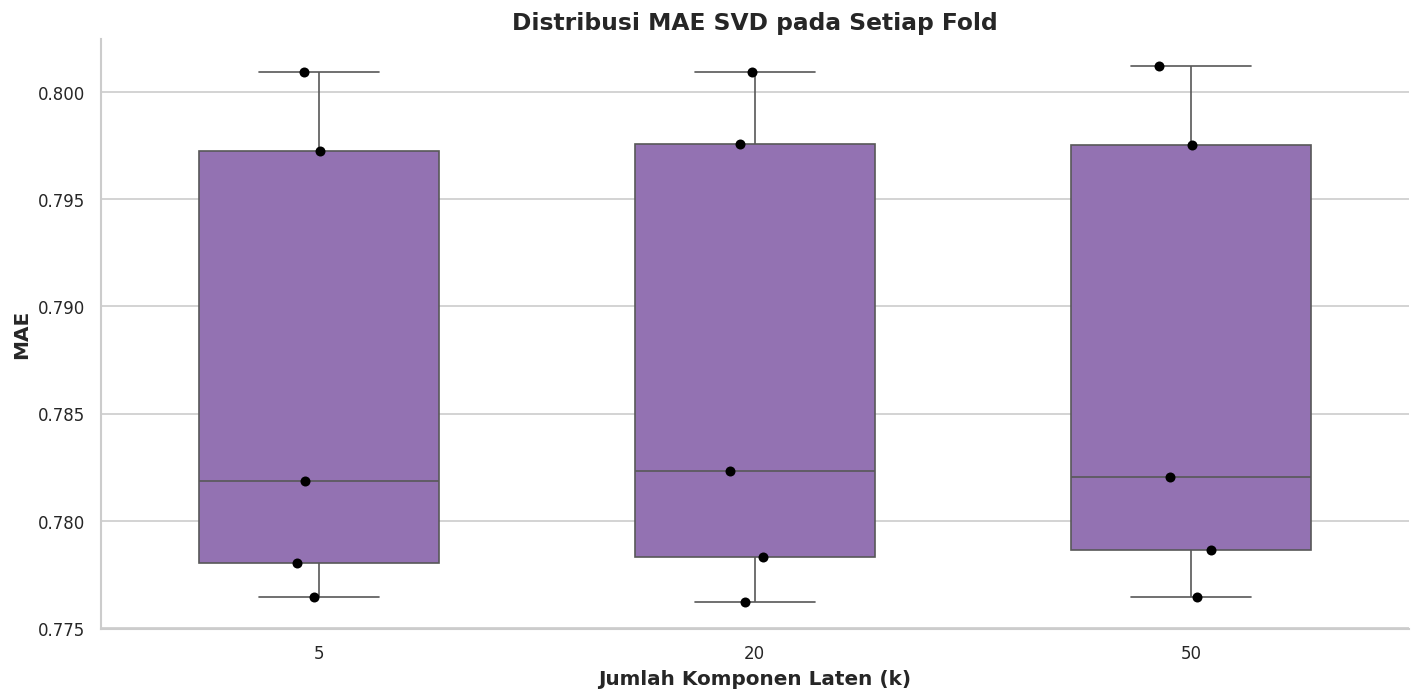

In [31]:
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

sns.boxplot(
    data=svd_fold_results,
    x="n_components",
    y="mae",
    color=METRIC_COLORS["MAE"],
    width=0.55,
    ax=ax
)

sns.stripplot(
    data=svd_fold_results,
    x="n_components",
    y="mae",
    color="black",
    size=6,
    jitter=0.08,
    ax=ax
)

ax.set_title(
    "Distribusi MAE SVD pada Setiap Fold"
)

ax.set_xlabel(
    "Jumlah Komponen Laten (k)"
)

ax.set_ylabel(
    "MAE"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="15_SVD_Boxplot_MAE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.1.15 Pemeriksaan Akhir Optimasi SVD**

In [32]:
expected_number_of_results = (
    len(SVD_K_VALUES)
    * N_SPLITS
)

assert len(svd_fold_results) == (
    expected_number_of_results
), (
    "Jumlah hasil eksperimen SVD tidak sesuai."
)

assert (
    svd_fold_results[
        [
            "rmse",
            "mae"
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
), (
    "Terdapat nilai RMSE atau MAE SVD yang kosong."
)

assert best_svd_k in SVD_K_VALUES, (
    "Hyperparameter SVD terbaik tidak terdapat "
    "dalam kandidat nilai."
)

assert (
    svd_prediction_results[
        "rating_prediction"
    ]
    .between(
        RATING_MIN,
        RATING_MAX
    )
    .all()
), (
    "Terdapat prediksi SVD di luar skala rating."
)

assert (
    svd_prediction_results[
        "prediction_source"
    ]
    .isin(
        EXPECTED_PREDICTION_SOURCE_ORDER
    )
    .all()
), (
    "Terdapat sumber prediksi SVD yang tidak valid."
)


print("=" * 80)
print("STEP 2.1 SELESAI")
print("=" * 80)

print(
    f"Jumlah eksperimen       : "
    f"{len(svd_fold_results)}"
)

print(
    f"Hyperparameter terbaik  : "
    f"k = {best_svd_k}"
)

print(
    f"Mean RMSE terbaik       : "
    f"{best_svd_result['mean_rmse']:.6f}"
)

print(
    f"Mean MAE terbaik        : "
    f"{best_svd_result['mean_mae']:.6f}"
)

print(
    f"Total waktu Grid Search : "
    f"{format_execution_time(svd_grid_search_total_time)}"
)

print()
print(
    "Hyperparameter terbaik SVD siap digunakan "
    "pada evaluasi final setelah optimasi seluruh model."
)

STEP 2.1 SELESAI
Jumlah eksperimen       : 15
Hyperparameter terbaik  : k = 5
Mean RMSE terbaik       : 1.086794
Mean MAE terbaik        : 0.786913
Total waktu Grid Search : 6.19 detik

Hyperparameter terbaik SVD siap digunakan pada evaluasi final setelah optimasi seluruh model.


## **Funk SVD**

### **2.2.1 Konfigurasi Hyperparameter Funk SVD**

In [33]:
FUNK_N_FACTORS_VALUES = [5, 20, 50]

FUNK_LEARNING_RATE_VALUES = [
    0.0025,
    0.005,
    0.01
]

FUNK_REGULARIZATION_VALUES = [
    0.02,
    0.05,
    0.10
]

FUNK_EPOCH_VALUES = [
    25,
    50,
    100
]

# Memastikan kandidat unik dan berurutan
FUNK_N_FACTORS_VALUES = sorted(
    set(FUNK_N_FACTORS_VALUES)
)

FUNK_LEARNING_RATE_VALUES = sorted(
    set(FUNK_LEARNING_RATE_VALUES)
)

FUNK_REGULARIZATION_VALUES = sorted(
    set(FUNK_REGULARIZATION_VALUES)
)

FUNK_EPOCH_VALUES = sorted(
    set(FUNK_EPOCH_VALUES)
)

FUNK_MAX_EPOCHS = max(
    FUNK_EPOCH_VALUES
)

FUNK_INITIALIZATION_STD = 0.10


# ------------------------------------------------------------
# Jumlah konfigurasi eksperimen
# ------------------------------------------------------------

FUNK_PARAMETER_COMBINATIONS = list(
    product(
        FUNK_N_FACTORS_VALUES,
        FUNK_LEARNING_RATE_VALUES,
        FUNK_REGULARIZATION_VALUES,
        FUNK_EPOCH_VALUES
    )
)

FUNK_BASE_TRAINING_COMBINATIONS = list(
    product(
        FUNK_N_FACTORS_VALUES,
        FUNK_LEARNING_RATE_VALUES,
        FUNK_REGULARIZATION_VALUES
    )
)

number_of_funk_parameter_combinations = len(
    FUNK_PARAMETER_COMBINATIONS
)

number_of_funk_cv_evaluations = (
    number_of_funk_parameter_combinations
    * N_SPLITS
)

number_of_funk_base_training_runs = (
    len(FUNK_BASE_TRAINING_COMBINATIONS)
    * N_SPLITS
)


# ------------------------------------------------------------
# Ringkasan konfigurasi
# ------------------------------------------------------------

funk_svd_configuration = pd.DataFrame({
    "Komponen": [
        "Model",
        "Pendekatan",
        "Metode optimasi",
        "Prediksi dasar",
        "Kandidat jumlah faktor laten",
        "Kandidat learning rate",
        "Kandidat regularization",
        "Kandidat epoch",
        "Jumlah kombinasi hyperparameter",
        "Jumlah evaluasi Cross Validation",
        "Jumlah proses training aktual",
        "Cross-validation",
        "Metrik utama",
        "Metrik pendamping",
        "Skala prediksi"
    ],
    "Nilai": [
        "Funk SVD",
        "Bias-Aware Matrix Factorization",
        "Stochastic Gradient Descent",
        "Global mean + user bias + item bias + dot product",
        str(FUNK_N_FACTORS_VALUES),
        str(FUNK_LEARNING_RATE_VALUES),
        str(FUNK_REGULARIZATION_VALUES),
        str(FUNK_EPOCH_VALUES),
        number_of_funk_parameter_combinations,
        number_of_funk_cv_evaluations,
        number_of_funk_base_training_runs,
        f"{N_SPLITS}-Fold Cross Validation",
        PRIMARY_METRIC,
        SECONDARY_METRIC,
        f"{RATING_MIN:.0f}–{RATING_MAX:.0f}"
    ]
})

display(funk_svd_configuration)

print(
    f"Jumlah kombinasi hyperparameter : "
    f"{number_of_funk_parameter_combinations}"
)

print(
    f"Jumlah evaluasi 5-Fold          : "
    f"{number_of_funk_cv_evaluations}"
)

print(
    f"Jumlah training aktual          : "
    f"{number_of_funk_base_training_runs}"
)

print(
    "Checkpoint optimization       : "
    f"{FUNK_EPOCH_VALUES}"
)

,Komponen,Nilai
0,Model,Funk SVD
1,Pendekatan,Bias-Aware Matrix Factorization
2,Metode optimasi,Stochastic Gradient Descent
3,Prediksi dasar,Global mean + user bias + item bias + dot product
4,Kandidat jumlah faktor laten,"[5, 20, 50]"
5,Kandidat learning rate,"[0.0025, 0.005, 0.01]"
6,Kandidat regularization,"[0.02, 0.05, 0.1]"
7,Kandidat epoch,"[25, 50, 100]"
8,Jumlah kombinasi hyperparameter,81
9,Jumlah evaluasi Cross Validation,405


Jumlah kombinasi hyperparameter : 81
Jumlah evaluasi 5-Fold          : 405
Jumlah training aktual          : 135
Checkpoint optimization       : [25, 50, 100]


### **2.2.2 Persiapan Data Fold Funk SVD**

In [34]:
def prepare_funk_svd_fold(
    train_data: pd.DataFrame,
    validation_data: pd.DataFrame,
    fold_number: int
) -> Dict[str, Any]:
    """
    Menyiapkan data training dan validasi untuk Funk SVD.

    Indeks lokal hanya dibentuk dari user dan item yang
    terdapat pada data training fold.
    """

    train_data = (
        train_data
        .copy()
        .reset_index(drop=True)
    )

    validation_data = (
        validation_data
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # A. Membentuk identitas lokal
    # --------------------------------------------------------

    train_users = sorted(
        train_data["user_id"]
        .dropna()
        .unique()
        .tolist()
    )

    train_items = sorted(
        train_data["place_id"]
        .dropna()
        .unique()
        .tolist()
    )

    user_to_local_index = {
        user_id: index
        for index, user_id in enumerate(train_users)
    }

    item_to_local_index = {
        place_id: index
        for index, place_id in enumerate(train_items)
    }


    # --------------------------------------------------------
    # B. Membentuk array training
    # --------------------------------------------------------

    train_user_indices = (
        train_data["user_id"]
        .map(user_to_local_index)
        .to_numpy(dtype=np.int64)
    )

    train_item_indices = (
        train_data["place_id"]
        .map(item_to_local_index)
        .to_numpy(dtype=np.int64)
    )

    train_ratings = (
        train_data["rating"]
        .to_numpy(dtype=np.float64)
    )


    # --------------------------------------------------------
    # C. Statistik training dan fallback
    # --------------------------------------------------------

    global_mean = float(
        train_data["rating"].mean()
    )

    user_mean = (
        train_data
        .groupby("user_id")["rating"]
        .mean()
    )

    item_mean = (
        train_data
        .groupby("place_id")["rating"]
        .mean()
    )

    user_interaction_count = (
        train_data
        .groupby("user_id")
        .size()
    )

    item_interaction_count = (
        train_data
        .groupby("place_id")
        .size()
    )


    # --------------------------------------------------------
    # D. Objek data fold
    # --------------------------------------------------------

    prepared_fold = {
        "fold": int(fold_number),
        "train_data": train_data,
        "validation_data": validation_data,
        "train_users": train_users,
        "train_items": train_items,
        "user_to_local_index": user_to_local_index,
        "item_to_local_index": item_to_local_index,
        "train_user_indices": train_user_indices,
        "train_item_indices": train_item_indices,
        "train_ratings": train_ratings,
        "global_mean": global_mean,
        "user_mean": user_mean,
        "item_mean": item_mean,
        "user_interaction_count": user_interaction_count,
        "item_interaction_count": item_interaction_count,
        "number_of_train_users": len(train_users),
        "number_of_train_items": len(train_items),
        "number_of_train_interactions": len(train_data),
        "number_of_validation_interactions": (
            len(validation_data)
        )
    }

    return prepared_fold


# ------------------------------------------------------------
# Menyiapkan seluruh fold satu kali
# ------------------------------------------------------------

funk_svd_prepared_folds = []

for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    CV_SPLITS,
    start=1
):

    fold_train_data = (
        development_data
        .iloc[train_indices]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_data = (
        development_data
        .iloc[validation_indices]
        .copy()
        .reset_index(drop=True)
    )

    prepared_fold = prepare_funk_svd_fold(
        train_data=fold_train_data,
        validation_data=fold_validation_data,
        fold_number=fold_number
    )

    funk_svd_prepared_folds.append(
        prepared_fold
    )


# ------------------------------------------------------------
# Ringkasan fold Funk SVD
# ------------------------------------------------------------

funk_svd_fold_preparation_summary = pd.DataFrame([
    {
        "fold": fold_data["fold"],
        "jumlah_training": (
            fold_data[
                "number_of_train_interactions"
            ]
        ),
        "jumlah_validasi": (
            fold_data[
                "number_of_validation_interactions"
            ]
        ),
        "jumlah_user_training": (
            fold_data[
                "number_of_train_users"
            ]
        ),
        "jumlah_item_training": (
            fold_data[
                "number_of_train_items"
            ]
        ),
        "global_mean_training": (
            fold_data["global_mean"]
        )
    }
    for fold_data in funk_svd_prepared_folds
])

display(funk_svd_fold_preparation_summary)

print(
    "Seluruh data fold Funk SVD berhasil disiapkan."
)

,fold,jumlah_training,jumlah_validasi,jumlah_user_training,jumlah_item_training,global_mean_training
0,1,14006,3502,12335,292,4.346423
1,2,14006,3502,12360,290,4.356347
2,3,14006,3502,12335,294,4.353491
3,4,14007,3501,12323,294,4.346827
4,5,14007,3501,12339,289,4.351253


Seluruh data fold Funk SVD berhasil disiapkan.


### **2.2.3 Fungsi SGD Funk SVD**

In [35]:
@njit
def _funk_svd_sgd_epoch(
    user_indices,
    item_indices,
    ratings,
    processing_order,
    global_mean,
    user_bias,
    item_bias,
    user_factors,
    item_factors,
    learning_rate,
    regularization
):
    """
    Menjalankan satu epoch SGD Funk SVD.

    Seluruh array model diperbarui secara in-place.
    """

    sum_squared_error = 0.0
    sum_absolute_error = 0.0

    number_of_interactions = len(
        processing_order
    )

    number_of_factors = (
        user_factors.shape[1]
    )

    for position in processing_order:

        user_index = user_indices[position]
        item_index = item_indices[position]
        actual_rating = ratings[position]

        dot_product = 0.0

        for factor_index in range(
            number_of_factors
        ):
            dot_product += (
                user_factors[
                    user_index,
                    factor_index
                ]
                * item_factors[
                    item_index,
                    factor_index
                ]
            )

        predicted_rating = (
            global_mean
            + user_bias[user_index]
            + item_bias[item_index]
            + dot_product
        )

        prediction_error = (
            actual_rating
            - predicted_rating
        )

        sum_squared_error += (
            prediction_error
            * prediction_error
        )

        sum_absolute_error += abs(
            prediction_error
        )


        # ----------------------------------------------------
        # Pembaruan bias
        # ----------------------------------------------------

        user_bias[user_index] += (
            learning_rate
            * (
                prediction_error
                - regularization
                * user_bias[user_index]
            )
        )

        item_bias[item_index] += (
            learning_rate
            * (
                prediction_error
                - regularization
                * item_bias[item_index]
            )
        )


        # ----------------------------------------------------
        # Pembaruan faktor laten
        # ----------------------------------------------------

        for factor_index in range(
            number_of_factors
        ):

            old_user_factor = (
                user_factors[
                    user_index,
                    factor_index
                ]
            )

            old_item_factor = (
                item_factors[
                    item_index,
                    factor_index
                ]
            )

            user_factors[
                user_index,
                factor_index
            ] = (
                old_user_factor
                + learning_rate
                * (
                    prediction_error
                    * old_item_factor
                    - regularization
                    * old_user_factor
                )
            )

            item_factors[
                item_index,
                factor_index
            ] = (
                old_item_factor
                + learning_rate
                * (
                    prediction_error
                    * old_user_factor
                    - regularization
                    * old_item_factor
                )
            )


    training_rmse = math.sqrt(
        sum_squared_error
        / number_of_interactions
    )

    training_mae = (
        sum_absolute_error
        / number_of_interactions
    )

    return training_rmse, training_mae

### **2.2.4 Inisialisasi dan Training Funk SVD**

In [36]:
def initialize_funk_svd_state(
    prepared_fold: Dict[str, Any],
    n_factors: int,
    random_seed: int
) -> Dict[str, Any]:
    """
    Menginisialisasi parameter Funk SVD.
    """

    random_generator = np.random.default_rng(
        random_seed
    )

    user_bias = np.zeros(
        prepared_fold["number_of_train_users"],
        dtype=np.float64
    )

    item_bias = np.zeros(
        prepared_fold["number_of_train_items"],
        dtype=np.float64
    )

    user_factors = random_generator.normal(
        loc=0.0,
        scale=FUNK_INITIALIZATION_STD,
        size=(
            prepared_fold[
                "number_of_train_users"
            ],
            n_factors
        )
    ).astype(np.float64)

    item_factors = random_generator.normal(
        loc=0.0,
        scale=FUNK_INITIALIZATION_STD,
        size=(
            prepared_fold[
                "number_of_train_items"
            ],
            n_factors
        )
    ).astype(np.float64)

    state = {
        "user_bias": user_bias,
        "item_bias": item_bias,
        "user_factors": user_factors,
        "item_factors": item_factors
    }

    return state


def build_funk_svd_model(
    prepared_fold: Dict[str, Any],
    state: Dict[str, Any],
    n_factors: int,
    learning_rate: float,
    regularization: float,
    n_epochs: int,
    training_time_seconds: float
) -> Dict[str, Any]:
    """
    Menggabungkan parameter hasil training dan metadata
    menjadi objek model Funk SVD.
    """

    model = {
        "model_name": "Funk SVD",
        "n_factors": int(n_factors),
        "learning_rate": float(
            learning_rate
        ),
        "regularization": float(
            regularization
        ),
        "n_epochs": int(n_epochs),
        "global_mean": (
            prepared_fold["global_mean"]
        ),
        "user_mean": (
            prepared_fold["user_mean"]
        ),
        "item_mean": (
            prepared_fold["item_mean"]
        ),
        "user_interaction_count": (
            prepared_fold[
                "user_interaction_count"
            ]
        ),
        "item_interaction_count": (
            prepared_fold[
                "item_interaction_count"
            ]
        ),
        "user_to_local_index": (
            prepared_fold[
                "user_to_local_index"
            ]
        ),
        "item_to_local_index": (
            prepared_fold[
                "item_to_local_index"
            ]
        ),
        "user_bias": state["user_bias"],
        "item_bias": state["item_bias"],
        "user_factors": state[
            "user_factors"
        ],
        "item_factors": state[
            "item_factors"
        ],
        "number_of_train_users": (
            prepared_fold[
                "number_of_train_users"
            ]
        ),
        "number_of_train_items": (
            prepared_fold[
                "number_of_train_items"
            ]
        ),
        "number_of_train_interactions": (
            prepared_fold[
                "number_of_train_interactions"
            ]
        ),
        "training_time_seconds": float(
            training_time_seconds
        )
    }

    return model


def train_funk_svd_model(
    prepared_fold: Dict[str, Any],
    n_factors: int,
    learning_rate: float,
    regularization: float,
    n_epochs: int,
    random_seed: int
) -> Tuple[
    Dict[str, Any],
    pd.DataFrame
]:
    """
    Melatih Funk SVD sampai jumlah epoch tertentu.

    Fungsi ini digunakan kembali saat evaluasi konfigurasi
    terbaik dan evaluasi final model.
    """

    state = initialize_funk_svd_state(
        prepared_fold=prepared_fold,
        n_factors=n_factors,
        random_seed=random_seed
    )

    random_generator = np.random.default_rng(
        random_seed
    )

    training_history_records = []

    training_start_time = time.perf_counter()

    for epoch in range(
        1,
        n_epochs + 1
    ):

        processing_order = (
            random_generator
            .permutation(
                prepared_fold[
                    "number_of_train_interactions"
                ]
            )
            .astype(np.int64)
        )

        epoch_start_time = time.perf_counter()

        training_rmse, training_mae = (
            _funk_svd_sgd_epoch(
                prepared_fold[
                    "train_user_indices"
                ],
                prepared_fold[
                    "train_item_indices"
                ],
                prepared_fold[
                    "train_ratings"
                ],
                processing_order,
                prepared_fold[
                    "global_mean"
                ],
                state["user_bias"],
                state["item_bias"],
                state["user_factors"],
                state["item_factors"],
                learning_rate,
                regularization
            )
        )

        epoch_time_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        training_history_records.append({
            "epoch": epoch,
            "training_rmse": training_rmse,
            "training_mae": training_mae,
            "epoch_time_seconds": (
                epoch_time_seconds
            )
        })

        if not (
            np.isfinite(training_rmse)
            and np.isfinite(training_mae)
        ):
            raise FloatingPointError(
                "Training Funk SVD menghasilkan "
                "nilai non-finite."
            )

    total_training_time = (
        time.perf_counter()
        - training_start_time
    )

    model = build_funk_svd_model(
        prepared_fold=prepared_fold,
        state=state,
        n_factors=n_factors,
        learning_rate=learning_rate,
        regularization=regularization,
        n_epochs=n_epochs,
        training_time_seconds=(
            total_training_time
        )
    )

    training_history = pd.DataFrame(
        training_history_records
    )

    return model, training_history

### **2.2.5 Fungsi Prediksi dan Fallback Funk SVD**

In [37]:
def predict_funk_svd(
    model: Dict[str, Any],
    test_data: pd.DataFrame
) -> pd.DataFrame:
    """
    Menghasilkan prediksi rating Funk SVD beserta
    mekanisme fallback.
    """

    prediction_result = (
        test_data
        .copy()
        .reset_index(drop=True)
    )

    user_to_local_index = (
        model["user_to_local_index"]
    )

    item_to_local_index = (
        model["item_to_local_index"]
    )

    global_mean = float(
        model["global_mean"]
    )


    # --------------------------------------------------------
    # A. Identifikasi user dan item
    # --------------------------------------------------------

    user_seen = (
        prediction_result["user_id"]
        .isin(user_to_local_index)
    )

    item_seen = (
        prediction_result["place_id"]
        .isin(item_to_local_index)
    )

    prediction_result[
        "jumlah_interaksi_user_training"
    ] = (
        prediction_result["user_id"]
        .map(model["user_interaction_count"])
        .fillna(0)
        .astype(int)
    )

    prediction_result[
        "jumlah_interaksi_item_training"
    ] = (
        prediction_result["place_id"]
        .map(model["item_interaction_count"])
        .fillna(0)
        .astype(int)
    )

    prediction_result["kategori_user"] = (
        prediction_result[
            "jumlah_interaksi_user_training"
        ]
        .apply(classify_user_history)
    )

    prediction_result["kategori_user"] = (
        pd.Categorical(
            prediction_result["kategori_user"],
            categories=USER_CATEGORY_ORDER,
            ordered=True
        )
    )

    prediction_result[
        "user_seen_in_training"
    ] = user_seen

    prediction_result[
        "item_seen_in_training"
    ] = item_seen


    # --------------------------------------------------------
    # B. Inisialisasi global mean
    # --------------------------------------------------------

    predicted_ratings = np.full(
        len(prediction_result),
        global_mean,
        dtype=np.float64
    )

    prediction_sources = np.full(
        len(prediction_result),
        "Global Mean Fallback",
        dtype=object
    )


    # --------------------------------------------------------
    # C. Prediksi model
    # --------------------------------------------------------

    model_prediction_mask = (
        user_seen & item_seen
    )

    if model_prediction_mask.any():

        model_rows = prediction_result.loc[
            model_prediction_mask
        ]

        local_user_indices = (
            model_rows["user_id"]
            .map(user_to_local_index)
            .to_numpy(dtype=np.int64)
        )

        local_item_indices = (
            model_rows["place_id"]
            .map(item_to_local_index)
            .to_numpy(dtype=np.int64)
        )

        latent_interaction = np.sum(
            model["user_factors"][
                local_user_indices
            ]
            * model["item_factors"][
                local_item_indices
            ],
            axis=1
        )

        model_predictions = (
            global_mean
            + model["user_bias"][
                local_user_indices
            ]
            + model["item_bias"][
                local_item_indices
            ]
            + latent_interaction
        )

        predicted_ratings[
            model_prediction_mask.to_numpy()
        ] = model_predictions

        prediction_sources[
            model_prediction_mask.to_numpy()
        ] = "Model Prediction"


    # --------------------------------------------------------
    # D. Unseen user dan seen item
    # --------------------------------------------------------

    item_mean_fallback_mask = (
        ~user_seen & item_seen
    )

    if item_mean_fallback_mask.any():

        item_mean_predictions = (
            prediction_result.loc[
                item_mean_fallback_mask,
                "place_id"
            ]
            .map(model["item_mean"])
            .fillna(global_mean)
            .to_numpy(dtype=float)
        )

        predicted_ratings[
            item_mean_fallback_mask.to_numpy()
        ] = item_mean_predictions

        prediction_sources[
            item_mean_fallback_mask.to_numpy()
        ] = "Item Mean Fallback"


    # --------------------------------------------------------
    # E. Seen user dan unseen item
    # --------------------------------------------------------

    user_mean_fallback_mask = (
        user_seen & ~item_seen
    )

    if user_mean_fallback_mask.any():

        user_mean_predictions = (
            prediction_result.loc[
                user_mean_fallback_mask,
                "user_id"
            ]
            .map(model["user_mean"])
            .fillna(global_mean)
            .to_numpy(dtype=float)
        )

        predicted_ratings[
            user_mean_fallback_mask.to_numpy()
        ] = user_mean_predictions

        prediction_sources[
            user_mean_fallback_mask.to_numpy()
        ] = "User Mean Fallback"


    # --------------------------------------------------------
    # F. Finalisasi hasil
    # --------------------------------------------------------

    predicted_ratings = clip_rating(
        predicted_ratings
    )

    prediction_result[
        "rating_prediction"
    ] = predicted_ratings

    prediction_result[
        "prediction_source"
    ] = prediction_sources

    prediction_result["prediction_error"] = (
        prediction_result["rating"]
        - prediction_result[
            "rating_prediction"
        ]
    )

    prediction_result["absolute_error"] = (
        prediction_result[
            "prediction_error"
        ].abs()
    )

    prediction_result["squared_error"] = (
        prediction_result[
            "prediction_error"
        ] ** 2
    )

    return prediction_result

### **2.2.6 Grid Search dengan Checkpoint Optimization**

In [38]:
funk_svd_fold_result_records = []
funk_svd_training_checkpoint_records = []

funk_svd_grid_start_time = time.perf_counter()

funk_svd_progress_bar = tqdm(
    total=number_of_funk_base_training_runs,
    desc="Grid Search Funk SVD",
    unit="training"
)


for n_factors in FUNK_N_FACTORS_VALUES:

    for learning_rate in (
        FUNK_LEARNING_RATE_VALUES
    ):

        for regularization in (
            FUNK_REGULARIZATION_VALUES
        ):

            for prepared_fold in (
                funk_svd_prepared_folds
            ):

                fold_number = prepared_fold[
                    "fold"
                ]

                # Seed dibuat sama untuk setiap konfigurasi
                # learning rate dan regularization pada fold
                # serta jumlah faktor yang sama.
                experiment_seed = (
                    RANDOM_STATE
                    + fold_number * 10_000
                    + n_factors * 100
                )

                state = initialize_funk_svd_state(
                    prepared_fold=prepared_fold,
                    n_factors=n_factors,
                    random_seed=experiment_seed
                )

                random_generator = (
                    np.random.default_rng(
                        experiment_seed
                    )
                )

                cumulative_training_start = (
                    time.perf_counter()
                )

                for epoch in range(
                    1,
                    FUNK_MAX_EPOCHS + 1
                ):

                    processing_order = (
                        random_generator
                        .permutation(
                            prepared_fold[
                                "number_of_train_interactions"
                            ]
                        )
                        .astype(np.int64)
                    )

                    epoch_start_time = (
                        time.perf_counter()
                    )

                    (
                        training_rmse,
                        training_mae
                    ) = _funk_svd_sgd_epoch(
                        prepared_fold[
                            "train_user_indices"
                        ],
                        prepared_fold[
                            "train_item_indices"
                        ],
                        prepared_fold[
                            "train_ratings"
                        ],
                        processing_order,
                        prepared_fold[
                            "global_mean"
                        ],
                        state["user_bias"],
                        state["item_bias"],
                        state["user_factors"],
                        state["item_factors"],
                        learning_rate,
                        regularization
                    )

                    epoch_time_seconds = (
                        time.perf_counter()
                        - epoch_start_time
                    )

                    if epoch in FUNK_EPOCH_VALUES:

                        cumulative_training_time = (
                            time.perf_counter()
                            - cumulative_training_start
                        )

                        checkpoint_model = (
                            build_funk_svd_model(
                                prepared_fold=(
                                    prepared_fold
                                ),
                                state=state,
                                n_factors=n_factors,
                                learning_rate=(
                                    learning_rate
                                ),
                                regularization=(
                                    regularization
                                ),
                                n_epochs=epoch,
                                training_time_seconds=(
                                    cumulative_training_time
                                )
                            )
                        )

                        prediction_start_time = (
                            time.perf_counter()
                        )

                        checkpoint_predictions = (
                            predict_funk_svd(
                                model=checkpoint_model,
                                test_data=(
                                    prepared_fold[
                                        "validation_data"
                                    ]
                                )
                            )
                        )

                        prediction_time_seconds = (
                            time.perf_counter()
                            - prediction_start_time
                        )

                        checkpoint_metrics = (
                            evaluate_prediction_dataframe(
                                checkpoint_predictions
                            )
                        )

                        funk_svd_fold_result_records.append({
                            "model": "Funk SVD",
                            "n_factors": n_factors,
                            "learning_rate": (
                                learning_rate
                            ),
                            "regularization": (
                                regularization
                            ),
                            "n_epochs": epoch,
                            "fold": fold_number,
                            "jumlah_data_training": (
                                prepared_fold[
                                    "number_of_train_interactions"
                                ]
                            ),
                            "jumlah_data_validasi": (
                                prepared_fold[
                                    "number_of_validation_interactions"
                                ]
                            ),
                            "jumlah_user_training": (
                                prepared_fold[
                                    "number_of_train_users"
                                ]
                            ),
                            "jumlah_item_training": (
                                prepared_fold[
                                    "number_of_train_items"
                                ]
                            ),
                            "training_rmse_epoch": (
                                training_rmse
                            ),
                            "training_mae_epoch": (
                                training_mae
                            ),
                            "validation_rmse": (
                                checkpoint_metrics[
                                    "rmse"
                                ]
                            ),
                            "validation_mae": (
                                checkpoint_metrics[
                                    "mae"
                                ]
                            ),
                            "training_time_seconds": (
                                cumulative_training_time
                            ),
                            "prediction_time_seconds": (
                                prediction_time_seconds
                            ),
                            "total_time_seconds": (
                                cumulative_training_time
                                + prediction_time_seconds
                            )
                        })

                        funk_svd_training_checkpoint_records.append({
                            "n_factors": n_factors,
                            "learning_rate": (
                                learning_rate
                            ),
                            "regularization": (
                                regularization
                            ),
                            "n_epochs": epoch,
                            "fold": fold_number,
                            "training_rmse": (
                                training_rmse
                            ),
                            "training_mae": (
                                training_mae
                            ),
                            "last_epoch_time_seconds": (
                                epoch_time_seconds
                            ),
                            "cumulative_training_time_seconds": (
                                cumulative_training_time
                            )
                        })

                        del checkpoint_model
                        del checkpoint_predictions
                        gc.collect()

                del state
                gc.collect()

                funk_svd_progress_bar.update(1)


funk_svd_progress_bar.close()

funk_svd_grid_total_time = (
    time.perf_counter()
    - funk_svd_grid_start_time
)

funk_svd_fold_results = pd.DataFrame(
    funk_svd_fold_result_records
)

funk_svd_training_checkpoints = (
    pd.DataFrame(
        funk_svd_training_checkpoint_records
    )
)

print("Grid Search Funk SVD selesai.")

print(
    f"Jumlah evaluasi : "
    f"{len(funk_svd_fold_results):,}"
)

print(
    f"Total waktu     : "
    f"{format_execution_time(funk_svd_grid_total_time)}"
)

display(
    funk_svd_fold_results.head(10)
)

Grid Search Funk SVD:   0%|          | 0/135 [00:00<?, ?training/s]

Grid Search Funk SVD selesai.
Jumlah evaluasi : 405
Total waktu     : 1 menit 37.44 detik


,model,n_factors,learning_rate,regularization,n_epochs,fold,jumlah_data_training,jumlah_data_validasi,jumlah_user_training,jumlah_item_training,training_rmse_epoch,training_mae_epoch,validation_rmse,validation_mae,training_time_seconds,prediction_time_seconds,total_time_seconds
0,Funk SVD,5,0.002500,0.020000,25,1,14006,3502,12335,292,0.997895,0.721501,1.075241,0.767224,0.329628,0.022254,0.351882
1,Funk SVD,5,0.002500,0.020000,50,1,14006,3502,12335,292,0.917598,0.661678,1.074127,0.764095,1.594563,0.021079,1.615642
2,Funk SVD,5,0.002500,0.020000,100,1,14006,3502,12335,292,0.696751,0.501449,1.074599,0.760607,1.765673,0.028045,1.793718
3,Funk SVD,5,0.002500,0.020000,25,2,14006,3502,12360,290,0.998860,0.719134,1.076269,0.771085,0.018641,0.023128,0.041769
4,Funk SVD,5,0.002500,0.020000,50,2,14006,3502,12360,290,0.919279,0.660800,1.073084,0.766559,0.165794,0.021335,0.187130
5,Funk SVD,5,0.002500,0.020000,100,2,14006,3502,12360,290,0.697436,0.499579,1.070189,0.760151,0.330860,0.021017,0.351877
6,Funk SVD,5,0.002500,0.020000,25,3,14006,3502,12335,294,0.993273,0.715611,1.091205,0.774736,0.018594,0.022998,0.041591
7,Funk SVD,5,0.002500,0.020000,50,3,14006,3502,12335,294,0.908162,0.652780,1.089924,0.771212,0.163581,0.021318,0.184899
8,Funk SVD,5,0.002500,0.020000,100,3,14006,3502,12335,294,0.684586,0.485916,1.090360,0.767633,0.331843,0.022007,0.353851
9,Funk SVD,5,0.002500,0.020000,25,4,14007,3501,12323,294,1.000807,0.721675,1.061549,0.762638,0.019036,0.023030,0.042066


### **2.2.7 Ringkasan Hasil Grid Search Funk SVD**

In [39]:
funk_svd_grid_summary = (
    funk_svd_fold_results
    .groupby(
        [
            "n_factors",
            "learning_rate",
            "regularization",
            "n_epochs"
        ],
        as_index=False
    )
    .agg(
        mean_rmse=(
            "validation_rmse",
            "mean"
        ),
        std_rmse=(
            "validation_rmse",
            "std"
        ),
        min_rmse=(
            "validation_rmse",
            "min"
        ),
        max_rmse=(
            "validation_rmse",
            "max"
        ),
        mean_mae=(
            "validation_mae",
            "mean"
        ),
        std_mae=(
            "validation_mae",
            "std"
        ),
        min_mae=(
            "validation_mae",
            "min"
        ),
        max_mae=(
            "validation_mae",
            "max"
        ),
        mean_training_rmse=(
            "training_rmse_epoch",
            "mean"
        ),
        mean_training_mae=(
            "training_mae_epoch",
            "mean"
        ),
        mean_training_time_seconds=(
            "training_time_seconds",
            "mean"
        ),
        mean_prediction_time_seconds=(
            "prediction_time_seconds",
            "mean"
        ),
        mean_total_time_seconds=(
            "total_time_seconds",
            "mean"
        )
    )
)

funk_svd_grid_summary[
    "coefficient_of_variation_rmse"
] = (
    funk_svd_grid_summary["std_rmse"]
    / funk_svd_grid_summary["mean_rmse"]
)

funk_svd_grid_summary[
    "coefficient_of_variation_mae"
] = (
    funk_svd_grid_summary["std_mae"]
    / funk_svd_grid_summary["mean_mae"]
)

funk_svd_grid_summary = (
    funk_svd_grid_summary
    .sort_values(
        by=[
            "mean_rmse",
            "mean_mae",
            "n_factors",
            "learning_rate",
            "regularization",
            "n_epochs"
        ],
        ascending=[
            True,
            True,
            True,
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

funk_svd_grid_summary.insert(
    0,
    "ranking",
    np.arange(
        1,
        len(funk_svd_grid_summary) + 1
    )
)

display(
    funk_svd_grid_summary.head(20)
)

,ranking,n_factors,learning_rate,regularization,n_epochs,mean_rmse,std_rmse,min_rmse,max_rmse,mean_mae,std_mae,min_mae,max_mae,mean_training_rmse,mean_training_mae,mean_training_time_seconds,mean_prediction_time_seconds,mean_total_time_seconds,coefficient_of_variation_rmse,coefficient_of_variation_mae
0,1,50,0.010000,0.100000,100,1.072684,0.013301,1.055974,1.088793,0.757695,0.009336,0.748165,0.770952,0.209672,0.155084,0.517161,0.021174,0.538335,0.012400,0.012321
1,2,5,0.010000,0.100000,50,1.073252,0.014176,1.054527,1.089071,0.758472,0.009815,0.748222,0.773472,0.516935,0.376113,0.160415,0.020653,0.181068,0.013208,0.012940
2,3,5,0.005000,0.100000,100,1.073253,0.014195,1.054629,1.089177,0.758504,0.009851,0.748305,0.773510,0.511511,0.372019,0.319921,0.021735,0.341656,0.013226,0.012987
3,4,50,0.010000,0.100000,50,1.073440,0.013124,1.056390,1.089001,0.760895,0.008983,0.751610,0.773840,0.346275,0.253845,0.259854,0.022414,0.282267,0.012226,0.011806
4,5,50,0.005000,0.100000,100,1.073442,0.013062,1.056444,1.088864,0.760963,0.008913,0.751737,0.773912,0.343887,0.252391,0.517435,0.021393,0.538829,0.012169,0.011713
5,6,20,0.010000,0.100000,100,1.073632,0.013644,1.056771,1.089685,0.756651,0.010036,0.746471,0.770896,0.232192,0.170384,0.413679,0.021118,0.434797,0.012709,0.013263
6,7,20,0.005000,0.100000,100,1.073723,0.013415,1.056528,1.089041,0.759842,0.009309,0.750338,0.773462,0.408660,0.298270,0.472116,0.027091,0.499207,0.012494,0.012252
7,8,20,0.010000,0.100000,50,1.073744,0.013400,1.056556,1.089079,0.759823,0.009268,0.750250,0.773305,0.412418,0.300687,0.204181,0.021457,0.225638,0.012479,0.012198
8,9,5,0.002500,0.100000,100,1.073924,0.013546,1.055535,1.088516,0.763407,0.009174,0.753601,0.777527,0.783492,0.569578,0.406757,0.026853,0.433610,0.012614,0.012017
9,10,5,0.005000,0.100000,50,1.073927,0.013546,1.055476,1.088465,0.763420,0.009154,0.753587,0.777525,0.787462,0.572465,0.166524,0.020380,0.186905,0.012613,0.011990


### **2.2.8 Pemilihan Hyperparameter Terbaik Funk SVD**

In [40]:
best_funk_svd_result = (
    funk_svd_grid_summary
    .iloc[0]
    .copy()
)

best_funk_n_factors = int(
    best_funk_svd_result["n_factors"]
)

best_funk_learning_rate = float(
    best_funk_svd_result["learning_rate"]
)

best_funk_regularization = float(
    best_funk_svd_result["regularization"]
)

best_funk_n_epochs = int(
    best_funk_svd_result["n_epochs"]
)


best_funk_svd_parameter = pd.DataFrame({
    "Komponen": [
        "Model",
        "Jumlah faktor laten",
        "Learning rate",
        "Regularization",
        "Jumlah epoch",
        "Mean RMSE",
        "Standar deviasi RMSE",
        "Mean MAE",
        "Standar deviasi MAE",
        "Mean waktu training",
        "Mean waktu prediksi",
        "Aturan pemilihan",
        "Status penggunaan"
    ],
    "Nilai": [
        "Funk SVD",
        best_funk_n_factors,
        best_funk_learning_rate,
        best_funk_regularization,
        best_funk_n_epochs,
        best_funk_svd_result["mean_rmse"],
        best_funk_svd_result["std_rmse"],
        best_funk_svd_result["mean_mae"],
        best_funk_svd_result["std_mae"],
        best_funk_svd_result[
            "mean_training_time_seconds"
        ],
        best_funk_svd_result[
            "mean_prediction_time_seconds"
        ],
        (
            "Mean RMSE terendah; "
            "Mean MAE sebagai kriteria kedua"
        ),
        (
            "Digunakan pada evaluasi final setelah "
            "seluruh model selesai dituning"
        )
    ]
})


print("=" * 80)
print("HYPERPARAMETER FUNK SVD TERBAIK")
print("=" * 80)

print(
    f"Jumlah faktor laten : "
    f"{best_funk_n_factors}"
)

print(
    f"Learning rate       : "
    f"{best_funk_learning_rate}"
)

print(
    f"Regularization      : "
    f"{best_funk_regularization}"
)

print(
    f"Jumlah epoch        : "
    f"{best_funk_n_epochs}"
)

print(
    f"Mean RMSE           : "
    f"{best_funk_svd_result['mean_rmse']:.6f}"
)

print(
    f"Mean MAE            : "
    f"{best_funk_svd_result['mean_mae']:.6f}"
)

display(best_funk_svd_parameter)

HYPERPARAMETER FUNK SVD TERBAIK
Jumlah faktor laten : 50
Learning rate       : 0.01
Regularization      : 0.1
Jumlah epoch        : 100
Mean RMSE           : 1.072684
Mean MAE            : 0.757695


,Komponen,Nilai
0,Model,Funk SVD
1,Jumlah faktor laten,50
2,Learning rate,0.010000
3,Regularization,0.100000
4,Jumlah epoch,100
5,Mean RMSE,1.072684
6,Standar deviasi RMSE,0.013301
7,Mean MAE,0.757695
8,Standar deviasi MAE,0.009336
9,Mean waktu training,0.517161


### **2.2.9 Out-of-Fold Prediction Konfigurasi Terbaik**

In [41]:
funk_svd_best_oof_prediction_records = []
funk_svd_best_training_history_records = []

for prepared_fold in tqdm(
    funk_svd_prepared_folds,
    desc="Best Funk SVD OOF",
    unit="fold"
):

    fold_number = prepared_fold["fold"]

    best_experiment_seed = (
        RANDOM_STATE
        + fold_number * 10_000
        + best_funk_n_factors * 100
    )

    best_fold_model, fold_history = (
        train_funk_svd_model(
            prepared_fold=prepared_fold,
            n_factors=best_funk_n_factors,
            learning_rate=(
                best_funk_learning_rate
            ),
            regularization=(
                best_funk_regularization
            ),
            n_epochs=best_funk_n_epochs,
            random_seed=best_experiment_seed
        )
    )

    best_fold_predictions = (
        predict_funk_svd(
            model=best_fold_model,
            test_data=(
                prepared_fold[
                    "validation_data"
                ]
            )
        )
    )

    best_fold_predictions.insert(
        0,
        "fold",
        fold_number
    )

    best_fold_predictions.insert(
        0,
        "model",
        "Funk SVD"
    )

    funk_svd_best_oof_prediction_records.append(
        best_fold_predictions
    )

    fold_history.insert(
        0,
        "fold",
        fold_number
    )

    fold_history.insert(
        0,
        "model",
        "Funk SVD"
    )

    funk_svd_best_training_history_records.append(
        fold_history
    )

    del best_fold_model
    gc.collect()


funk_svd_best_oof_predictions = pd.concat(
    funk_svd_best_oof_prediction_records,
    ignore_index=True
)

funk_svd_best_training_history = pd.concat(
    funk_svd_best_training_history_records,
    ignore_index=True
)


# ------------------------------------------------------------
# Evaluasi OOF keseluruhan
# ------------------------------------------------------------

funk_svd_best_oof_metrics = (
    evaluate_prediction_dataframe(
        funk_svd_best_oof_predictions
    )
)

print(
    f"OOF RMSE konfigurasi terbaik: "
    f"{funk_svd_best_oof_metrics['rmse']:.6f}"
)

print(
    f"OOF MAE konfigurasi terbaik : "
    f"{funk_svd_best_oof_metrics['mae']:.6f}"
)

Best Funk SVD OOF:   0%|          | 0/5 [00:00<?, ?fold/s]

OOF RMSE konfigurasi terbaik: 1.072750
OOF MAE konfigurasi terbaik : 0.757695


### **2.2.10 Analisis Kategori User dan Sumber Prediksi**

In [42]:
best_funk_category_summary = evaluate_by_group(
    prediction_data=(
        funk_svd_best_oof_predictions
    ),
    group_column="kategori_user",
    group_order=USER_CATEGORY_ORDER
)

best_funk_category_summary[
    "persentase_prediksi"
] = (
    best_funk_category_summary[
        "jumlah_prediksi"
    ]
    / len(funk_svd_best_oof_predictions)
    * 100
)

best_funk_category_summary[
    "deskripsi_kategori"
] = (
    best_funk_category_summary[
        "kategori_user"
    ]
    .map(USER_CATEGORY_LABELS)
)


best_funk_source_summary = evaluate_by_group(
    prediction_data=(
        funk_svd_best_oof_predictions
    ),
    group_column="prediction_source",
    group_order=(
        EXPECTED_PREDICTION_SOURCE_ORDER
    )
)

best_funk_source_summary[
    "persentase_prediksi"
] = (
    best_funk_source_summary[
        "jumlah_prediksi"
    ]
    / len(funk_svd_best_oof_predictions)
    * 100
)


display(best_funk_category_summary)
display(best_funk_source_summary)

,kategori_user,jumlah_prediksi,rmse,mae,persentase_prediksi,deskripsi_kategori
0,Unseen User,14149,1.122718,0.797591,80.814485,0 interaksi
1,Single-Interaction User,1777,0.856389,0.603440,10.149646,1 interaksi
2,Low-History User,1293,0.818666,0.586720,7.385195,2–5 interaksi
3,Higher-History User,289,0.704660,0.517882,1.650674,>5 interaksi


,prediction_source,jumlah_prediksi,rmse,mae,persentase_prediksi
0,Model Prediction,3349,0.830524,0.590209,19.128398
1,Item Mean Fallback,14133,1.122793,0.797602,80.723098
2,User Mean Fallback,10,0.574811,0.399906,0.057117
3,Global Mean Fallback,16,1.054206,0.787927,0.091387


### **2.2.11 Penyimpanan Hasil Funk SVD**

In [43]:
save_excel_output(
    data={
        "Konfigurasi": (
            funk_svd_configuration
        ),
        "Ringkasan Grid Search": (
            funk_svd_grid_summary
        ),
        "Hasil Per Fold": (
            funk_svd_fold_results
        ),
        "Checkpoint Training": (
            funk_svd_training_checkpoints
        ),
        "Best OOF Prediction": (
            funk_svd_best_oof_predictions
        ),
        "Best Training History": (
            funk_svd_best_training_history
        ),
        "Kategori User": (
            best_funk_category_summary
        ),
        "Sumber Prediksi": (
            best_funk_source_summary
        )
    },
    filename="17_Funk_SVD_Hasil_Grid_Search.xlsx",
    index=False
)

save_excel_output(
    data={
        "Parameter Terbaik": (
            best_funk_svd_parameter
        ),
        "Ranking Kandidat": (
            funk_svd_grid_summary
        ),
        "Kategori User": (
            best_funk_category_summary
        ),
        "Sumber Prediksi": (
            best_funk_source_summary
        )
    },
    filename="24_Funk_SVD_Parameter_Terbaik.xlsx",
    index=False
)

Excel berhasil disimpan: 17_Funk_SVD_Hasil_Grid_Search.xlsx (2702.77 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 24_Funk_SVD_Parameter_Terbaik.xlsx (25.78 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/24_Funk_SVD_Parameter_Terbaik.xlsx')

### **2.2.12 Visualisasi RMSE Berdasarkan Epoch**

Gambar berhasil disimpan: 18_Funk_SVD_RMSE_By_Epoch.png (160.23 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

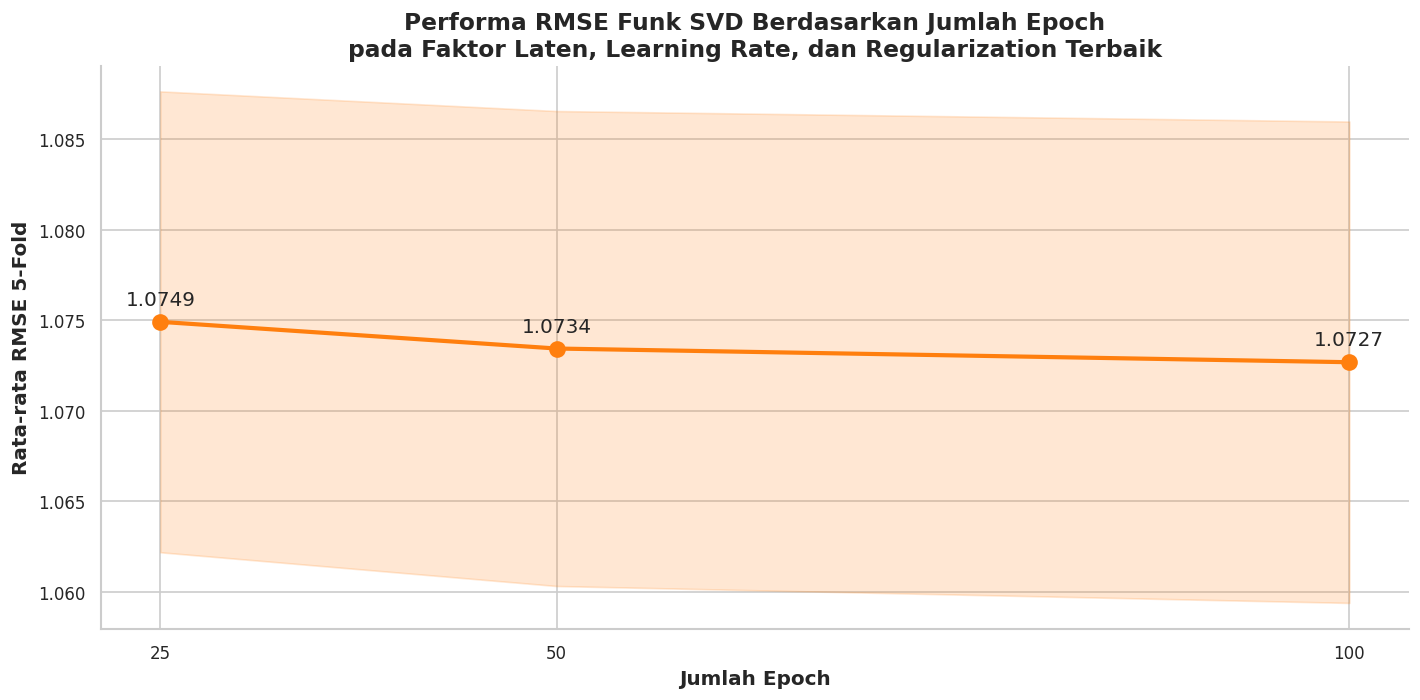

In [44]:
best_funk_epoch_plot = (
    funk_svd_grid_summary[
        (
            funk_svd_grid_summary[
                "n_factors"
            ] == best_funk_n_factors
        )
        & (
            funk_svd_grid_summary[
                "learning_rate"
            ] == best_funk_learning_rate
        )
        & (
            funk_svd_grid_summary[
                "regularization"
            ] == best_funk_regularization
        )
    ]
    .sort_values("n_epochs")
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.plot(
    best_funk_epoch_plot["n_epochs"],
    best_funk_epoch_plot["mean_rmse"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=MODEL_COLORS["Funk SVD"]
)

ax.fill_between(
    best_funk_epoch_plot["n_epochs"],
    (
        best_funk_epoch_plot["mean_rmse"]
        - best_funk_epoch_plot["std_rmse"]
    ),
    (
        best_funk_epoch_plot["mean_rmse"]
        + best_funk_epoch_plot["std_rmse"]
    ),
    color=MODEL_COLORS["Funk SVD"],
    alpha=0.18
)

for _, row in best_funk_epoch_plot.iterrows():
    ax.annotate(
        f"{row['mean_rmse']:.4f}",
        (
            row["n_epochs"],
            row["mean_rmse"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_title(
    "Performa RMSE Funk SVD Berdasarkan Jumlah Epoch\n"
    "pada Faktor Laten, Learning Rate, dan Regularization Terbaik"
)

ax.set_xlabel("Jumlah Epoch")
ax.set_ylabel("Rata-rata RMSE 5-Fold")

ax.set_xticks(
    FUNK_EPOCH_VALUES
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="18_Funk_SVD_RMSE_By_Epoch.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.2.13 Visualisasi MAE Berdasarkan Epoch**

Gambar berhasil disimpan: 19_Funk_SVD_MAE_By_Epoch.png (208.25 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

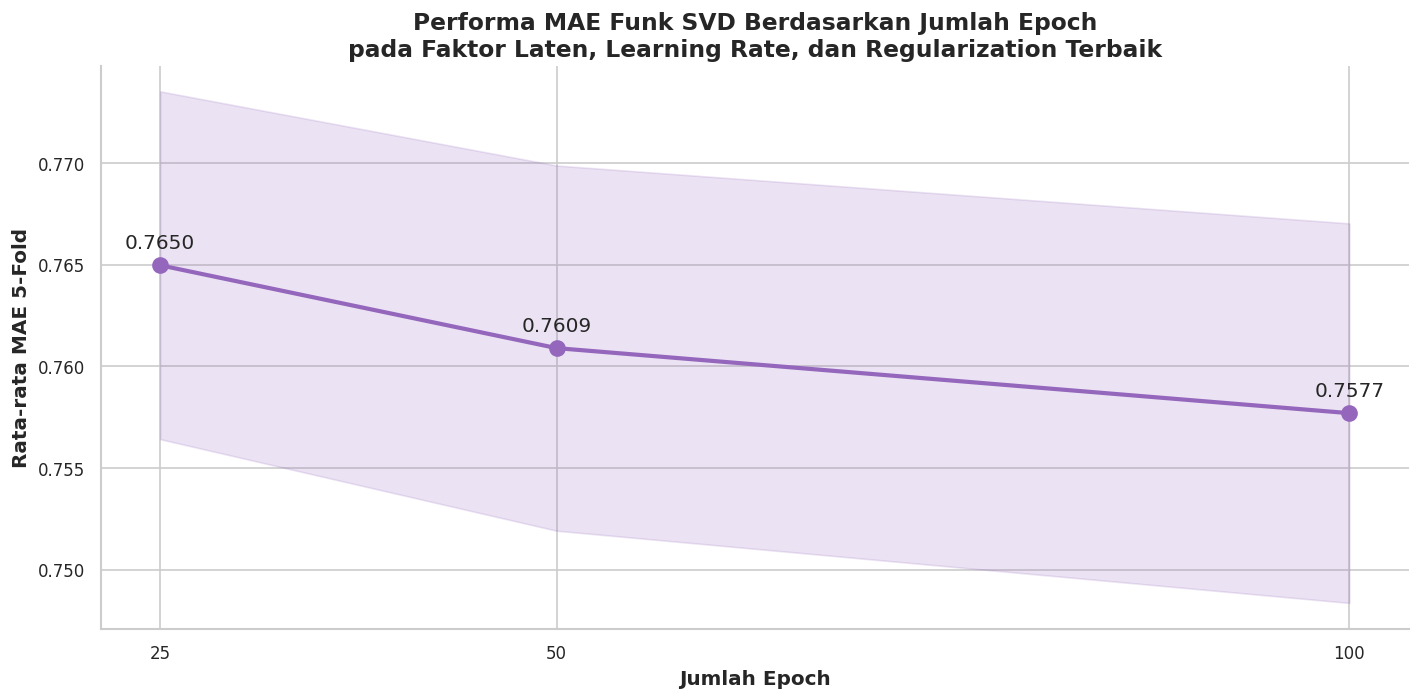

In [45]:
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.plot(
    best_funk_epoch_plot["n_epochs"],
    best_funk_epoch_plot["mean_mae"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=METRIC_COLORS["MAE"]
)

ax.fill_between(
    best_funk_epoch_plot["n_epochs"],
    (
        best_funk_epoch_plot["mean_mae"]
        - best_funk_epoch_plot["std_mae"]
    ),
    (
        best_funk_epoch_plot["mean_mae"]
        + best_funk_epoch_plot["std_mae"]
    ),
    color=METRIC_COLORS["MAE"],
    alpha=0.18
)

for _, row in best_funk_epoch_plot.iterrows():
    ax.annotate(
        f"{row['mean_mae']:.4f}",
        (
            row["n_epochs"],
            row["mean_mae"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_title(
    "Performa MAE Funk SVD Berdasarkan Jumlah Epoch\n"
    "pada Faktor Laten, Learning Rate, dan Regularization Terbaik"
)

ax.set_xlabel("Jumlah Epoch")
ax.set_ylabel("Rata-rata MAE 5-Fold")

ax.set_xticks(
    FUNK_EPOCH_VALUES
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="19_Funk_SVD_MAE_By_Epoch.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.2.14 Heatmap Learning Rate dan Regularization**

Gambar berhasil disimpan: 20_Funk_SVD_Heatmap_RMSE.png (147.15 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

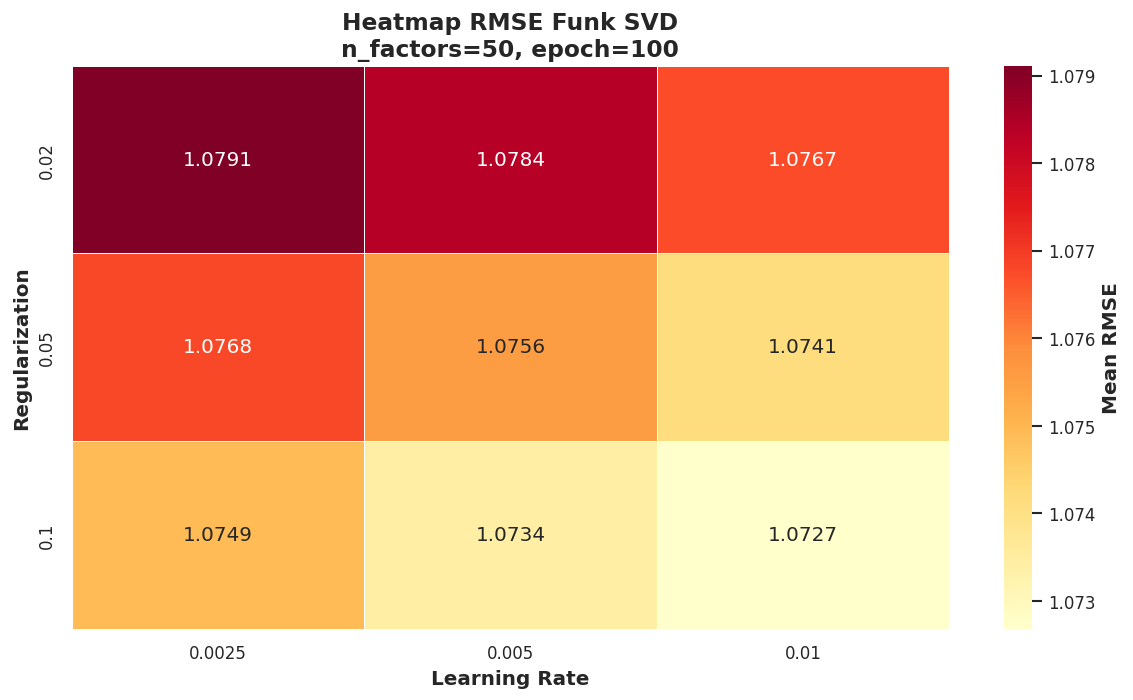

Gambar berhasil disimpan: 21_Funk_SVD_Heatmap_MAE.png (155.57 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

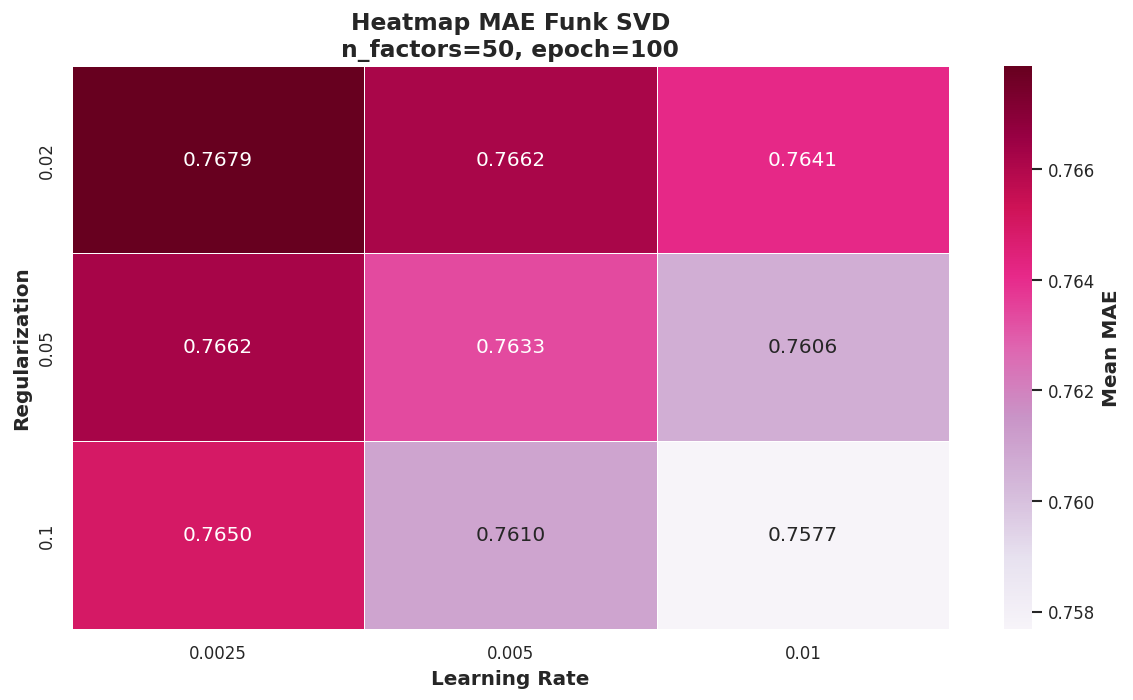

In [46]:
funk_heatmap_data = (
    funk_svd_grid_summary[
        (
            funk_svd_grid_summary[
                "n_factors"
            ] == best_funk_n_factors
        )
        & (
            funk_svd_grid_summary[
                "n_epochs"
            ] == best_funk_n_epochs
        )
    ]
    .copy()
)

rmse_heatmap_table = (
    funk_heatmap_data
    .pivot(
        index="regularization",
        columns="learning_rate",
        values="mean_rmse"
    )
)

mae_heatmap_table = (
    funk_heatmap_data
    .pivot(
        index="regularization",
        columns="learning_rate",
        values="mean_mae"
    )
)


# RMSE heatmap
fig, ax = plt.subplots(
    figsize=DEFAULT_FIGSIZE
)

sns.heatmap(
    rmse_heatmap_table,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Mean RMSE"
    },
    ax=ax
)

ax.set_title(
    "Heatmap RMSE Funk SVD\n"
    f"n_factors={best_funk_n_factors}, "
    f"epoch={best_funk_n_epochs}"
)

ax.set_xlabel("Learning Rate")
ax.set_ylabel("Regularization")

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="20_Funk_SVD_Heatmap_RMSE.png",
    close_figure=False
)

plt.show()
plt.close(fig)


# MAE heatmap
fig, ax = plt.subplots(
    figsize=DEFAULT_FIGSIZE
)

sns.heatmap(
    mae_heatmap_table,
    annot=True,
    fmt=".4f",
    cmap="PuRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Mean MAE"
    },
    ax=ax
)

ax.set_title(
    "Heatmap MAE Funk SVD\n"
    f"n_factors={best_funk_n_factors}, "
    f"epoch={best_funk_n_epochs}"
)

ax.set_xlabel("Learning Rate")
ax.set_ylabel("Regularization")

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="21_Funk_SVD_Heatmap_MAE.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.2.15 Performa Terbaik per Faktor Laten**

Gambar berhasil disimpan: 22_Funk_SVD_RMSE_By_Latent_Factor.png (101.95 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

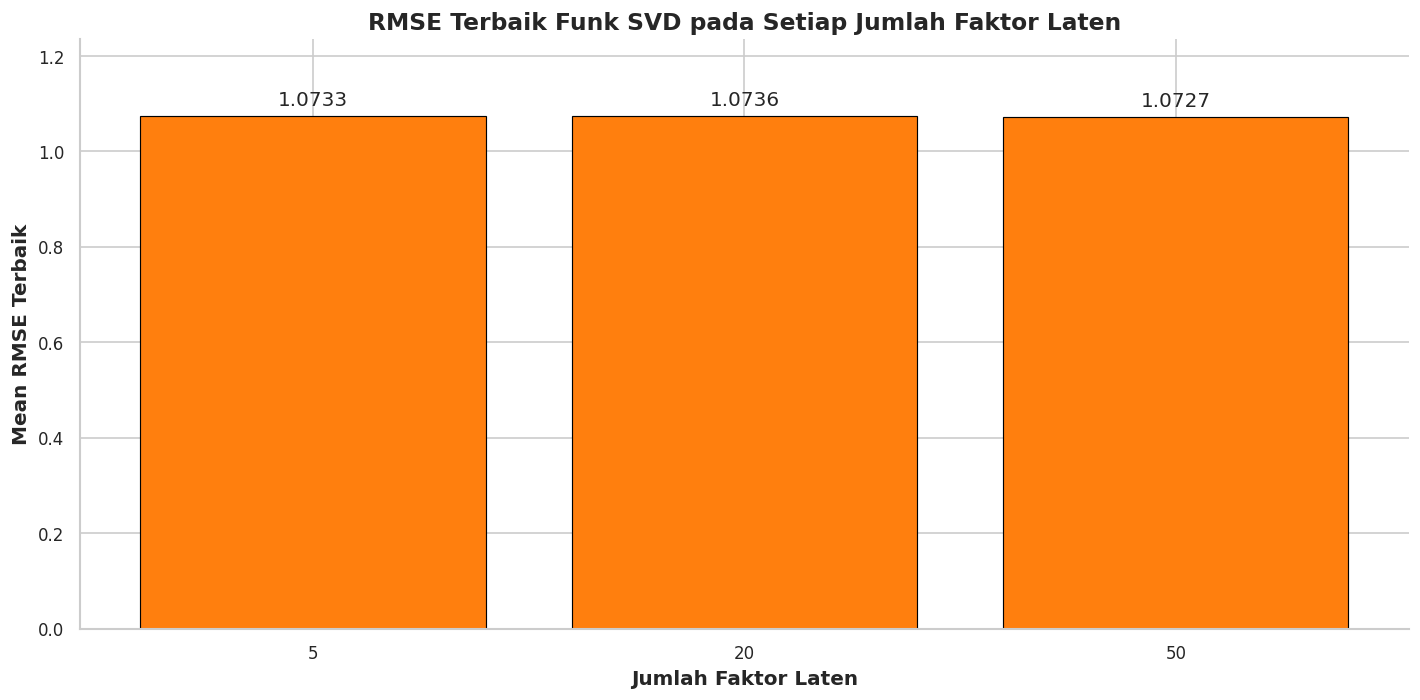

Gambar berhasil disimpan: 23_Funk_SVD_MAE_By_Latent_Factor.png (105.83 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

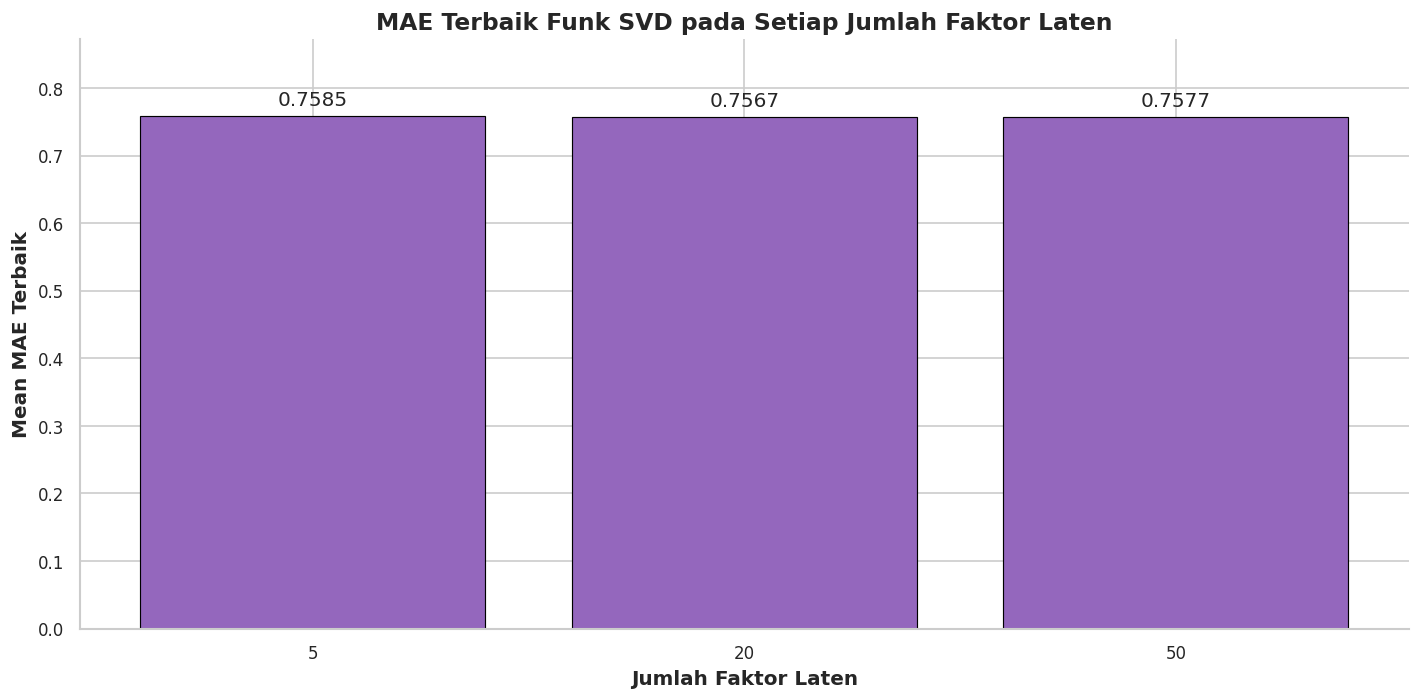

In [47]:
best_per_funk_factor = (
    funk_svd_grid_summary
    .sort_values(
        [
            "n_factors",
            "mean_rmse",
            "mean_mae"
        ]
    )
    .groupby(
        "n_factors",
        as_index=False
    )
    .first()
    .sort_values("n_factors")
)


# RMSE
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    best_per_funk_factor[
        "n_factors"
    ].astype(str),
    best_per_funk_factor[
        "mean_rmse"
    ],
    color=MODEL_COLORS["Funk SVD"],
    edgecolor="black",
    linewidth=0.7
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in best_per_funk_factor[
            "mean_rmse"
        ]
    ],
    padding=4
)

ax.set_title(
    "RMSE Terbaik Funk SVD pada Setiap Jumlah Faktor Laten"
)

ax.set_xlabel("Jumlah Faktor Laten")
ax.set_ylabel("Mean RMSE Terbaik")

ax.set_ylim(
    0,
    best_per_funk_factor[
        "mean_rmse"
    ].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="22_Funk_SVD_RMSE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)


# MAE
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    best_per_funk_factor[
        "n_factors"
    ].astype(str),
    best_per_funk_factor[
        "mean_mae"
    ],
    color=METRIC_COLORS["MAE"],
    edgecolor="black",
    linewidth=0.7
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in best_per_funk_factor[
            "mean_mae"
        ]
    ],
    padding=4
)

ax.set_title(
    "MAE Terbaik Funk SVD pada Setiap Jumlah Faktor Laten"
)

ax.set_xlabel("Jumlah Faktor Laten")
ax.set_ylabel("Mean MAE Terbaik")

ax.set_ylim(
    0,
    best_per_funk_factor[
        "mean_mae"
    ].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="23_Funk_SVD_MAE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.2.16 Pemeriksaan Akhir Optimasi Funk SVD**

In [48]:
assert len(funk_svd_fold_results) == (
    number_of_funk_cv_evaluations
), (
    "Jumlah evaluasi Funk SVD tidak sesuai."
)

assert len(funk_svd_grid_summary) == (
    number_of_funk_parameter_combinations
), (
    "Jumlah kombinasi ringkasan Funk SVD tidak sesuai."
)

assert (
    funk_svd_fold_results[
        [
            "validation_rmse",
            "validation_mae"
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
), (
    "Terdapat RMSE atau MAE Funk SVD yang kosong."
)

assert best_funk_n_factors in (
    FUNK_N_FACTORS_VALUES
), (
    "Jumlah faktor terbaik tidak valid."
)

assert best_funk_learning_rate in (
    FUNK_LEARNING_RATE_VALUES
), (
    "Learning rate terbaik tidak valid."
)

assert best_funk_regularization in (
    FUNK_REGULARIZATION_VALUES
), (
    "Regularization terbaik tidak valid."
)

assert best_funk_n_epochs in (
    FUNK_EPOCH_VALUES
), (
    "Jumlah epoch terbaik tidak valid."
)

assert (
    funk_svd_best_oof_predictions[
        "interaction_id"
    ].nunique()
    == len(development_data)
), (
    "OOF prediction belum mencakup seluruh "
    "development data."
)

assert (
    funk_svd_best_oof_predictions[
        "rating_prediction"
    ]
    .between(
        RATING_MIN,
        RATING_MAX
    )
    .all()
), (
    "Terdapat prediksi Funk SVD di luar skala."
)


print("=" * 80)
print("STEP 2.2 SELESAI")
print("=" * 80)

print(
    f"Jumlah kombinasi       : "
    f"{number_of_funk_parameter_combinations}"
)

print(
    f"Jumlah evaluasi        : "
    f"{len(funk_svd_fold_results)}"
)

print(
    f"Best n_factors         : "
    f"{best_funk_n_factors}"
)

print(
    f"Best learning rate     : "
    f"{best_funk_learning_rate}"
)

print(
    f"Best regularization    : "
    f"{best_funk_regularization}"
)

print(
    f"Best epoch             : "
    f"{best_funk_n_epochs}"
)

print(
    f"Best mean RMSE         : "
    f"{best_funk_svd_result['mean_rmse']:.6f}"
)

print(
    f"Best mean MAE          : "
    f"{best_funk_svd_result['mean_mae']:.6f}"
)

print(
    f"Total Grid Search time : "
    f"{format_execution_time(funk_svd_grid_total_time)}"
)

print()
print(
    "Hyperparameter terbaik Funk SVD siap digunakan "
    "pada tahap evaluasi final."
)

STEP 2.2 SELESAI
Jumlah kombinasi       : 81
Jumlah evaluasi        : 405
Best n_factors         : 50
Best learning rate     : 0.01
Best regularization    : 0.1
Best epoch             : 100
Best mean RMSE         : 1.072684
Best mean MAE          : 0.757695
Total Grid Search time : 1 menit 37.44 detik

Hyperparameter terbaik Funk SVD siap digunakan pada tahap evaluasi final.


## **SVD++**

### **2.3.1 Konfigurasi Hyperparameter SVD++**

In [49]:
SVDPP_N_FACTORS_VALUES = [5, 20, 50]

SVDPP_LEARNING_RATE_VALUES = [
    0.0025,
    0.005,
    0.01
]

SVDPP_REGULARIZATION_VALUES = [
    0.02,
    0.05,
    0.10
]

SVDPP_EPOCH_VALUES = [
    25,
    50,
    100
]

# Menjamin kandidat unik dan berurutan
SVDPP_N_FACTORS_VALUES = sorted(
    set(SVDPP_N_FACTORS_VALUES)
)

SVDPP_LEARNING_RATE_VALUES = sorted(
    set(SVDPP_LEARNING_RATE_VALUES)
)

SVDPP_REGULARIZATION_VALUES = sorted(
    set(SVDPP_REGULARIZATION_VALUES)
)

SVDPP_EPOCH_VALUES = sorted(
    set(SVDPP_EPOCH_VALUES)
)

SVDPP_MAX_EPOCHS = max(
    SVDPP_EPOCH_VALUES
)

SVDPP_INITIALIZATION_STD = 0.10


# ------------------------------------------------------------
# Jumlah kombinasi eksperimen
# ------------------------------------------------------------

SVDPP_PARAMETER_COMBINATIONS = list(
    product(
        SVDPP_N_FACTORS_VALUES,
        SVDPP_LEARNING_RATE_VALUES,
        SVDPP_REGULARIZATION_VALUES,
        SVDPP_EPOCH_VALUES
    )
)

SVDPP_BASE_TRAINING_COMBINATIONS = list(
    product(
        SVDPP_N_FACTORS_VALUES,
        SVDPP_LEARNING_RATE_VALUES,
        SVDPP_REGULARIZATION_VALUES
    )
)

number_of_svdpp_parameter_combinations = len(
    SVDPP_PARAMETER_COMBINATIONS
)

number_of_svdpp_cv_evaluations = (
    number_of_svdpp_parameter_combinations
    * N_SPLITS
)

number_of_svdpp_base_training_runs = (
    len(SVDPP_BASE_TRAINING_COMBINATIONS)
    * N_SPLITS
)


# ------------------------------------------------------------
# Ringkasan konfigurasi
# ------------------------------------------------------------

svdpp_configuration = pd.DataFrame({
    "Komponen": [
        "Model",
        "Pendekatan",
        "Metode optimasi",
        "Explicit feedback",
        "Implicit feedback",
        "Normalisasi implicit feedback",
        "Kandidat jumlah faktor laten",
        "Kandidat learning rate",
        "Kandidat regularization",
        "Kandidat epoch",
        "Jumlah kombinasi hyperparameter",
        "Jumlah evaluasi Cross Validation",
        "Jumlah proses training aktual",
        "Cross-validation",
        "Metrik utama",
        "Metrik pendamping",
        "Skala prediksi"
    ],
    "Nilai": [
        "SVD++",
        "Bias-Aware Matrix Factorization with Implicit Feedback",
        "Stochastic Gradient Descent",
        "Nilai rating pengguna",
        "Keberadaan item yang pernah diberi rating",
        "1 / sqrt(jumlah item yang pernah diberi rating)",
        str(SVDPP_N_FACTORS_VALUES),
        str(SVDPP_LEARNING_RATE_VALUES),
        str(SVDPP_REGULARIZATION_VALUES),
        str(SVDPP_EPOCH_VALUES),
        number_of_svdpp_parameter_combinations,
        number_of_svdpp_cv_evaluations,
        number_of_svdpp_base_training_runs,
        f"{N_SPLITS}-Fold Cross Validation",
        PRIMARY_METRIC,
        SECONDARY_METRIC,
        f"{RATING_MIN:.0f}–{RATING_MAX:.0f}"
    ]
})

display(svdpp_configuration)

print(
    f"Jumlah kombinasi hyperparameter : "
    f"{number_of_svdpp_parameter_combinations}"
)

print(
    f"Jumlah evaluasi 5-Fold          : "
    f"{number_of_svdpp_cv_evaluations}"
)

print(
    f"Jumlah training aktual          : "
    f"{number_of_svdpp_base_training_runs}"
)

print(
    f"Checkpoint epoch                : "
    f"{SVDPP_EPOCH_VALUES}"
)

,Komponen,Nilai
0,Model,SVD++
1,Pendekatan,Bias-Aware Matrix Factorization with Implicit Feedback
2,Metode optimasi,Stochastic Gradient Descent
3,Explicit feedback,Nilai rating pengguna
4,Implicit feedback,Keberadaan item yang pernah diberi rating
5,Normalisasi implicit feedback,1 / sqrt(jumlah item yang pernah diberi rating)
6,Kandidat jumlah faktor laten,"[5, 20, 50]"
7,Kandidat learning rate,"[0.0025, 0.005, 0.01]"
8,Kandidat regularization,"[0.02, 0.05, 0.1]"
9,Kandidat epoch,"[25, 50, 100]"


Jumlah kombinasi hyperparameter : 81
Jumlah evaluasi 5-Fold          : 405
Jumlah training aktual          : 135
Checkpoint epoch                : [25, 50, 100]


### **2.3.2 Persiapan Data dan Implicit Feedback**

In [50]:
def prepare_svdpp_fold(
    train_data: pd.DataFrame,
    validation_data: pd.DataFrame,
    fold_number: int
) -> Dict[str, Any]:
    """
    Menyiapkan data training dan validasi SVD++.

    Selain indeks lokal dan statistik training, fungsi ini
    membentuk struktur implicit feedback N(u) untuk setiap user.
    """

    # Menggunakan persiapan dasar yang sama dengan Funk SVD
    prepared_fold = prepare_funk_svd_fold(
        train_data=train_data,
        validation_data=validation_data,
        fold_number=fold_number
    )

    train_data_local = (
        prepared_fold["train_data"]
        .copy()
    )

    train_data_local["user_local_idx"] = (
        train_data_local["user_id"]
        .map(
            prepared_fold[
                "user_to_local_index"
            ]
        )
        .astype(np.int64)
    )

    train_data_local["item_local_idx"] = (
        train_data_local["place_id"]
        .map(
            prepared_fold[
                "item_to_local_index"
            ]
        )
        .astype(np.int64)
    )


    # --------------------------------------------------------
    # A. Membentuk daftar item unik untuk setiap user
    # --------------------------------------------------------

    number_of_users = prepared_fold[
        "number_of_train_users"
    ]

    user_history_lists = [
        np.empty(0, dtype=np.int64)
        for _ in range(number_of_users)
    ]

    grouped_user_history = (
        train_data_local
        .groupby(
            "user_local_idx"
        )["item_local_idx"]
    )

    for user_local_index, item_series in (
        grouped_user_history
    ):

        unique_item_indices = np.unique(
            item_series.to_numpy(
                dtype=np.int64
            )
        )

        user_history_lists[
            int(user_local_index)
        ] = unique_item_indices


    # --------------------------------------------------------
    # B. Membentuk CSR-like history structure
    # --------------------------------------------------------

    user_history_indptr = np.zeros(
        number_of_users + 1,
        dtype=np.int64
    )

    total_history_entries = 0

    for user_index in range(
        number_of_users
    ):
        total_history_entries += len(
            user_history_lists[user_index]
        )

        user_history_indptr[
            user_index + 1
        ] = total_history_entries

    user_history_item_indices = np.empty(
        total_history_entries,
        dtype=np.int64
    )

    current_position = 0

    for user_index in range(
        number_of_users
    ):
        user_items = user_history_lists[
            user_index
        ]

        next_position = (
            current_position
            + len(user_items)
        )

        user_history_item_indices[
            current_position:next_position
        ] = user_items

        current_position = next_position


    # --------------------------------------------------------
    # C. Ringkasan implicit feedback
    # --------------------------------------------------------

    user_history_lengths = np.diff(
        user_history_indptr
    )

    if (user_history_lengths <= 0).any():
        raise ValueError(
            "Terdapat user training tanpa implicit history."
        )

    prepared_fold[
        "user_history_indptr"
    ] = user_history_indptr

    prepared_fold[
        "user_history_item_indices"
    ] = user_history_item_indices

    prepared_fold[
        "user_history_lengths"
    ] = user_history_lengths

    prepared_fold[
        "mean_history_length"
    ] = float(
        user_history_lengths.mean()
    )

    prepared_fold[
        "median_history_length"
    ] = float(
        np.median(user_history_lengths)
    )

    prepared_fold[
        "maximum_history_length"
    ] = int(
        user_history_lengths.max()
    )

    return prepared_fold


# ------------------------------------------------------------
# Menyiapkan seluruh fold SVD++
# ------------------------------------------------------------

svdpp_prepared_folds = []

for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    CV_SPLITS,
    start=1
):

    fold_train_data = (
        development_data
        .iloc[train_indices]
        .copy()
        .reset_index(drop=True)
    )

    fold_validation_data = (
        development_data
        .iloc[validation_indices]
        .copy()
        .reset_index(drop=True)
    )

    prepared_fold = prepare_svdpp_fold(
        train_data=fold_train_data,
        validation_data=fold_validation_data,
        fold_number=fold_number
    )

    svdpp_prepared_folds.append(
        prepared_fold
    )


# ------------------------------------------------------------
# Ringkasan persiapan fold
# ------------------------------------------------------------

svdpp_fold_preparation_summary = pd.DataFrame([
    {
        "fold": fold_data["fold"],
        "jumlah_training": (
            fold_data[
                "number_of_train_interactions"
            ]
        ),
        "jumlah_validasi": (
            fold_data[
                "number_of_validation_interactions"
            ]
        ),
        "jumlah_user_training": (
            fold_data[
                "number_of_train_users"
            ]
        ),
        "jumlah_item_training": (
            fold_data[
                "number_of_train_items"
            ]
        ),
        "rata_rata_history_user": (
            fold_data[
                "mean_history_length"
            ]
        ),
        "median_history_user": (
            fold_data[
                "median_history_length"
            ]
        ),
        "maksimum_history_user": (
            fold_data[
                "maximum_history_length"
            ]
        ),
        "global_mean_training": (
            fold_data["global_mean"]
        )
    }
    for fold_data in svdpp_prepared_folds
])

display(svdpp_fold_preparation_summary)

print(
    "Seluruh data fold dan implicit feedback "
    "SVD++ berhasil disiapkan."
)

,fold,jumlah_training,jumlah_validasi,jumlah_user_training,jumlah_item_training,rata_rata_history_user,median_history_user,maksimum_history_user,global_mean_training
0,1,14006,3502,12335,292,1.135468,1.000000,23,4.346423
1,2,14006,3502,12360,290,1.133172,1.000000,23,4.356347
2,3,14006,3502,12335,294,1.135468,1.000000,19,4.353491
3,4,14007,3501,12323,294,1.136655,1.000000,23,4.346827
4,5,14007,3501,12339,289,1.135181,1.000000,20,4.351253


Seluruh data fold dan implicit feedback SVD++ berhasil disiapkan.


### **2.3.3 Fungsi Training SGD SVD++**

In [51]:
@njit
def _svdpp_sgd_epoch(
    user_indices,
    item_indices,
    ratings,
    processing_order,
    user_history_indptr,
    user_history_item_indices,
    global_mean,
    user_bias,
    item_bias,
    user_factors,
    item_factors,
    implicit_item_factors,
    learning_rate,
    regularization
):
    """
    Menjalankan satu epoch SGD SVD++.

    Seluruh parameter model diperbarui secara in-place.
    """

    sum_squared_error = 0.0
    sum_absolute_error = 0.0

    number_of_interactions = len(
        processing_order
    )

    number_of_factors = (
        user_factors.shape[1]
    )

    # Digunakan ulang untuk menghindari alokasi pada
    # setiap interaksi.
    extended_user_vector = np.empty(
        number_of_factors,
        dtype=np.float64
    )

    for position in processing_order:

        user_index = user_indices[
            position
        ]

        item_index = item_indices[
            position
        ]

        actual_rating = ratings[
            position
        ]

        history_start = (
            user_history_indptr[
                user_index
            ]
        )

        history_end = (
            user_history_indptr[
                user_index + 1
            ]
        )

        history_length = (
            history_end
            - history_start
        )

        normalization = (
            1.0
            / math.sqrt(history_length)
        )


        # ----------------------------------------------------
        # A. Representasi user eksplisit + implicit
        # ----------------------------------------------------

        predicted_latent_interaction = 0.0

        for factor_index in range(
            number_of_factors
        ):

            implicit_sum = 0.0

            for history_position in range(
                history_start,
                history_end
            ):

                history_item_index = (
                    user_history_item_indices[
                        history_position
                    ]
                )

                implicit_sum += (
                    implicit_item_factors[
                        history_item_index,
                        factor_index
                    ]
                )

            extended_user_vector[
                factor_index
            ] = (
                user_factors[
                    user_index,
                    factor_index
                ]
                + normalization
                * implicit_sum
            )

            predicted_latent_interaction += (
                item_factors[
                    item_index,
                    factor_index
                ]
                * extended_user_vector[
                    factor_index
                ]
            )


        # ----------------------------------------------------
        # B. Prediksi dan error
        # ----------------------------------------------------

        predicted_rating = (
            global_mean
            + user_bias[user_index]
            + item_bias[item_index]
            + predicted_latent_interaction
        )

        prediction_error = (
            actual_rating
            - predicted_rating
        )

        sum_squared_error += (
            prediction_error
            * prediction_error
        )

        sum_absolute_error += abs(
            prediction_error
        )


        # ----------------------------------------------------
        # C. Pembaruan bias
        # ----------------------------------------------------

        user_bias[user_index] += (
            learning_rate
            * (
                prediction_error
                - regularization
                * user_bias[user_index]
            )
        )

        item_bias[item_index] += (
            learning_rate
            * (
                prediction_error
                - regularization
                * item_bias[item_index]
            )
        )


        # ----------------------------------------------------
        # D. Pembaruan faktor laten
        # ----------------------------------------------------

        for factor_index in range(
            number_of_factors
        ):

            old_user_factor = (
                user_factors[
                    user_index,
                    factor_index
                ]
            )

            old_item_factor = (
                item_factors[
                    item_index,
                    factor_index
                ]
            )

            user_factors[
                user_index,
                factor_index
            ] = (
                old_user_factor
                + learning_rate
                * (
                    prediction_error
                    * old_item_factor
                    - regularization
                    * old_user_factor
                )
            )

            item_factors[
                item_index,
                factor_index
            ] = (
                old_item_factor
                + learning_rate
                * (
                    prediction_error
                    * extended_user_vector[
                        factor_index
                    ]
                    - regularization
                    * old_item_factor
                )
            )


            # ------------------------------------------------
            # Pembaruan faktor implicit seluruh item N(u)
            # ------------------------------------------------

            for history_position in range(
                history_start,
                history_end
            ):

                history_item_index = (
                    user_history_item_indices[
                        history_position
                    ]
                )

                old_implicit_factor = (
                    implicit_item_factors[
                        history_item_index,
                        factor_index
                    ]
                )

                implicit_item_factors[
                    history_item_index,
                    factor_index
                ] = (
                    old_implicit_factor
                    + learning_rate
                    * (
                        prediction_error
                        * normalization
                        * old_item_factor
                        - regularization
                        * old_implicit_factor
                    )
                )


    training_rmse = math.sqrt(
        sum_squared_error
        / number_of_interactions
    )

    training_mae = (
        sum_absolute_error
        / number_of_interactions
    )

    return training_rmse, training_mae

### **2.3.4 Fungsi Perhitungan Representasi Implicit User**

In [52]:
@njit
def _compute_svdpp_implicit_user_vectors(
    user_history_indptr,
    user_history_item_indices,
    implicit_item_factors
):
    """
    Menghitung normalized implicit-feedback vector
    untuk seluruh user training.
    """

    number_of_users = (
        len(user_history_indptr) - 1
    )

    number_of_factors = (
        implicit_item_factors.shape[1]
    )

    implicit_user_vectors = np.zeros(
        (
            number_of_users,
            number_of_factors
        ),
        dtype=np.float64
    )

    for user_index in range(
        number_of_users
    ):

        history_start = (
            user_history_indptr[
                user_index
            ]
        )

        history_end = (
            user_history_indptr[
                user_index + 1
            ]
        )

        history_length = (
            history_end
            - history_start
        )

        if history_length <= 0:
            continue

        normalization = (
            1.0
            / math.sqrt(history_length)
        )

        for history_position in range(
            history_start,
            history_end
        ):

            history_item_index = (
                user_history_item_indices[
                    history_position
                ]
            )

            for factor_index in range(
                number_of_factors
            ):

                implicit_user_vectors[
                    user_index,
                    factor_index
                ] += (
                    normalization
                    * implicit_item_factors[
                        history_item_index,
                        factor_index
                    ]
                )

    return implicit_user_vectors

### **2.3.5 Inisialisasi dan Training SVD++**

In [53]:
def initialize_svdpp_state(
    prepared_fold: Dict[str, Any],
    n_factors: int,
    random_seed: int
) -> Dict[str, Any]:
    """
    Menginisialisasi seluruh parameter SVD++.
    """

    random_generator = np.random.default_rng(
        random_seed
    )

    number_of_users = prepared_fold[
        "number_of_train_users"
    ]

    number_of_items = prepared_fold[
        "number_of_train_items"
    ]

    user_bias = np.zeros(
        number_of_users,
        dtype=np.float64
    )

    item_bias = np.zeros(
        number_of_items,
        dtype=np.float64
    )

    user_factors = random_generator.normal(
        loc=0.0,
        scale=SVDPP_INITIALIZATION_STD,
        size=(
            number_of_users,
            n_factors
        )
    ).astype(np.float64)

    item_factors = random_generator.normal(
        loc=0.0,
        scale=SVDPP_INITIALIZATION_STD,
        size=(
            number_of_items,
            n_factors
        )
    ).astype(np.float64)

    implicit_item_factors = (
        random_generator.normal(
            loc=0.0,
            scale=SVDPP_INITIALIZATION_STD,
            size=(
                number_of_items,
                n_factors
            )
        )
        .astype(np.float64)
    )

    state = {
        "user_bias": user_bias,
        "item_bias": item_bias,
        "user_factors": user_factors,
        "item_factors": item_factors,
        "implicit_item_factors": (
            implicit_item_factors
        )
    }

    return state


def build_svdpp_model(
    prepared_fold: Dict[str, Any],
    state: Dict[str, Any],
    n_factors: int,
    learning_rate: float,
    regularization: float,
    n_epochs: int,
    training_time_seconds: float
) -> Dict[str, Any]:
    """
    Membentuk objek model SVD++ dari state hasil training.
    """

    implicit_user_vectors = (
        _compute_svdpp_implicit_user_vectors(
            prepared_fold[
                "user_history_indptr"
            ],
            prepared_fold[
                "user_history_item_indices"
            ],
            state[
                "implicit_item_factors"
            ]
        )
    )

    model = {
        "model_name": "SVD++",
        "n_factors": int(n_factors),
        "learning_rate": float(
            learning_rate
        ),
        "regularization": float(
            regularization
        ),
        "n_epochs": int(n_epochs),
        "global_mean": (
            prepared_fold["global_mean"]
        ),
        "user_mean": (
            prepared_fold["user_mean"]
        ),
        "item_mean": (
            prepared_fold["item_mean"]
        ),
        "user_interaction_count": (
            prepared_fold[
                "user_interaction_count"
            ]
        ),
        "item_interaction_count": (
            prepared_fold[
                "item_interaction_count"
            ]
        ),
        "user_to_local_index": (
            prepared_fold[
                "user_to_local_index"
            ]
        ),
        "item_to_local_index": (
            prepared_fold[
                "item_to_local_index"
            ]
        ),
        "user_bias": (
            state["user_bias"]
        ),
        "item_bias": (
            state["item_bias"]
        ),
        "user_factors": (
            state["user_factors"]
        ),
        "item_factors": (
            state["item_factors"]
        ),
        "implicit_item_factors": (
            state[
                "implicit_item_factors"
            ]
        ),
        "implicit_user_vectors": (
            implicit_user_vectors
        ),
        "user_history_indptr": (
            prepared_fold[
                "user_history_indptr"
            ]
        ),
        "user_history_item_indices": (
            prepared_fold[
                "user_history_item_indices"
            ]
        ),
        "number_of_train_users": (
            prepared_fold[
                "number_of_train_users"
            ]
        ),
        "number_of_train_items": (
            prepared_fold[
                "number_of_train_items"
            ]
        ),
        "number_of_train_interactions": (
            prepared_fold[
                "number_of_train_interactions"
            ]
        ),
        "training_time_seconds": float(
            training_time_seconds
        )
    }

    return model


def train_svdpp_model(
    prepared_fold: Dict[str, Any],
    n_factors: int,
    learning_rate: float,
    regularization: float,
    n_epochs: int,
    random_seed: int
) -> Tuple[
    Dict[str, Any],
    pd.DataFrame
]:
    """
    Melatih model SVD++ sampai jumlah epoch tertentu.
    """

    state = initialize_svdpp_state(
        prepared_fold=prepared_fold,
        n_factors=n_factors,
        random_seed=random_seed
    )

    random_generator = np.random.default_rng(
        random_seed
    )

    training_history_records = []

    training_start_time = (
        time.perf_counter()
    )

    for epoch in range(
        1,
        n_epochs + 1
    ):

        processing_order = (
            random_generator
            .permutation(
                prepared_fold[
                    "number_of_train_interactions"
                ]
            )
            .astype(np.int64)
        )

        epoch_start_time = (
            time.perf_counter()
        )

        (
            training_rmse,
            training_mae
        ) = _svdpp_sgd_epoch(
            prepared_fold[
                "train_user_indices"
            ],
            prepared_fold[
                "train_item_indices"
            ],
            prepared_fold[
                "train_ratings"
            ],
            processing_order,
            prepared_fold[
                "user_history_indptr"
            ],
            prepared_fold[
                "user_history_item_indices"
            ],
            prepared_fold[
                "global_mean"
            ],
            state["user_bias"],
            state["item_bias"],
            state["user_factors"],
            state["item_factors"],
            state[
                "implicit_item_factors"
            ],
            learning_rate,
            regularization
        )

        epoch_time_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        training_history_records.append({
            "epoch": epoch,
            "training_rmse": (
                training_rmse
            ),
            "training_mae": (
                training_mae
            ),
            "epoch_time_seconds": (
                epoch_time_seconds
            )
        })

        if not (
            np.isfinite(training_rmse)
            and np.isfinite(training_mae)
        ):
            raise FloatingPointError(
                "Training SVD++ menghasilkan "
                "nilai non-finite."
            )

    total_training_time = (
        time.perf_counter()
        - training_start_time
    )

    model = build_svdpp_model(
        prepared_fold=prepared_fold,
        state=state,
        n_factors=n_factors,
        learning_rate=learning_rate,
        regularization=regularization,
        n_epochs=n_epochs,
        training_time_seconds=(
            total_training_time
        )
    )

    training_history = pd.DataFrame(
        training_history_records
    )

    return model, training_history

### **2.3.6 Fungsi Prediksi dan Fallback SVD++**

In [54]:
def predict_svdpp(
    model: Dict[str, Any],
    test_data: pd.DataFrame
) -> pd.DataFrame:
    """
    Menghasilkan prediksi rating SVD++ beserta fallback.
    """

    prediction_result = (
        test_data
        .copy()
        .reset_index(drop=True)
    )

    user_to_local_index = (
        model["user_to_local_index"]
    )

    item_to_local_index = (
        model["item_to_local_index"]
    )

    global_mean = float(
        model["global_mean"]
    )


    # --------------------------------------------------------
    # A. Identifikasi seen dan unseen entity
    # --------------------------------------------------------

    user_seen = (
        prediction_result["user_id"]
        .isin(user_to_local_index)
    )

    item_seen = (
        prediction_result["place_id"]
        .isin(item_to_local_index)
    )

    prediction_result[
        "jumlah_interaksi_user_training"
    ] = (
        prediction_result["user_id"]
        .map(model["user_interaction_count"])
        .fillna(0)
        .astype(int)
    )

    prediction_result[
        "jumlah_interaksi_item_training"
    ] = (
        prediction_result["place_id"]
        .map(model["item_interaction_count"])
        .fillna(0)
        .astype(int)
    )

    prediction_result["kategori_user"] = (
        prediction_result[
            "jumlah_interaksi_user_training"
        ]
        .apply(classify_user_history)
    )

    prediction_result["kategori_user"] = (
        pd.Categorical(
            prediction_result["kategori_user"],
            categories=USER_CATEGORY_ORDER,
            ordered=True
        )
    )

    prediction_result[
        "user_seen_in_training"
    ] = user_seen

    prediction_result[
        "item_seen_in_training"
    ] = item_seen


    # --------------------------------------------------------
    # B. Inisialisasi global mean
    # --------------------------------------------------------

    predicted_ratings = np.full(
        len(prediction_result),
        global_mean,
        dtype=np.float64
    )

    prediction_sources = np.full(
        len(prediction_result),
        "Global Mean Fallback",
        dtype=object
    )


    # --------------------------------------------------------
    # C. Seen user dan seen item
    # --------------------------------------------------------

    model_prediction_mask = (
        user_seen & item_seen
    )

    if model_prediction_mask.any():

        model_rows = prediction_result.loc[
            model_prediction_mask
        ]

        local_user_indices = (
            model_rows["user_id"]
            .map(user_to_local_index)
            .to_numpy(dtype=np.int64)
        )

        local_item_indices = (
            model_rows["place_id"]
            .map(item_to_local_index)
            .to_numpy(dtype=np.int64)
        )

        extended_user_factors = (
            model["user_factors"][
                local_user_indices
            ]
            + model[
                "implicit_user_vectors"
            ][
                local_user_indices
            ]
        )

        latent_interaction = np.sum(
            extended_user_factors
            * model["item_factors"][
                local_item_indices
            ],
            axis=1
        )

        model_predictions = (
            global_mean
            + model["user_bias"][
                local_user_indices
            ]
            + model["item_bias"][
                local_item_indices
            ]
            + latent_interaction
        )

        predicted_ratings[
            model_prediction_mask.to_numpy()
        ] = model_predictions

        prediction_sources[
            model_prediction_mask.to_numpy()
        ] = "Model Prediction"


    # --------------------------------------------------------
    # D. Unseen user dan seen item
    # --------------------------------------------------------

    item_mean_fallback_mask = (
        ~user_seen & item_seen
    )

    if item_mean_fallback_mask.any():

        item_mean_predictions = (
            prediction_result.loc[
                item_mean_fallback_mask,
                "place_id"
            ]
            .map(model["item_mean"])
            .fillna(global_mean)
            .to_numpy(dtype=float)
        )

        predicted_ratings[
            item_mean_fallback_mask.to_numpy()
        ] = item_mean_predictions

        prediction_sources[
            item_mean_fallback_mask.to_numpy()
        ] = "Item Mean Fallback"


    # --------------------------------------------------------
    # E. Seen user dan unseen item
    # --------------------------------------------------------

    user_mean_fallback_mask = (
        user_seen & ~item_seen
    )

    if user_mean_fallback_mask.any():

        user_mean_predictions = (
            prediction_result.loc[
                user_mean_fallback_mask,
                "user_id"
            ]
            .map(model["user_mean"])
            .fillna(global_mean)
            .to_numpy(dtype=float)
        )

        predicted_ratings[
            user_mean_fallback_mask.to_numpy()
        ] = user_mean_predictions

        prediction_sources[
            user_mean_fallback_mask.to_numpy()
        ] = "User Mean Fallback"


    # --------------------------------------------------------
    # F. Finalisasi hasil
    # --------------------------------------------------------

    predicted_ratings = clip_rating(
        predicted_ratings
    )

    prediction_result[
        "rating_prediction"
    ] = predicted_ratings

    prediction_result[
        "prediction_source"
    ] = prediction_sources

    prediction_result[
        "prediction_error"
    ] = (
        prediction_result["rating"]
        - prediction_result[
            "rating_prediction"
        ]
    )

    prediction_result[
        "absolute_error"
    ] = (
        prediction_result[
            "prediction_error"
        ].abs()
    )

    prediction_result[
        "squared_error"
    ] = (
        prediction_result[
            "prediction_error"
        ] ** 2
    )

    return prediction_result

### **2.3.7 Grid Search dengan Checkpoint Optimization**

In [55]:
svdpp_fold_result_records = []
svdpp_training_checkpoint_records = []

svdpp_grid_start_time = (
    time.perf_counter()
)

svdpp_progress_bar = tqdm(
    total=number_of_svdpp_base_training_runs,
    desc="Grid Search SVD++",
    unit="training"
)


for n_factors in SVDPP_N_FACTORS_VALUES:

    for learning_rate in (
        SVDPP_LEARNING_RATE_VALUES
    ):

        for regularization in (
            SVDPP_REGULARIZATION_VALUES
        ):

            for prepared_fold in (
                svdpp_prepared_folds
            ):

                fold_number = (
                    prepared_fold["fold"]
                )

                experiment_seed = (
                    RANDOM_STATE
                    + fold_number * 10_000
                    + n_factors * 100
                )

                state = initialize_svdpp_state(
                    prepared_fold=prepared_fold,
                    n_factors=n_factors,
                    random_seed=experiment_seed
                )

                random_generator = (
                    np.random.default_rng(
                        experiment_seed
                    )
                )

                cumulative_training_start = (
                    time.perf_counter()
                )

                for epoch in range(
                    1,
                    SVDPP_MAX_EPOCHS + 1
                ):

                    processing_order = (
                        random_generator
                        .permutation(
                            prepared_fold[
                                "number_of_train_interactions"
                            ]
                        )
                        .astype(np.int64)
                    )

                    epoch_start_time = (
                        time.perf_counter()
                    )

                    (
                        training_rmse,
                        training_mae
                    ) = _svdpp_sgd_epoch(
                        prepared_fold[
                            "train_user_indices"
                        ],
                        prepared_fold[
                            "train_item_indices"
                        ],
                        prepared_fold[
                            "train_ratings"
                        ],
                        processing_order,
                        prepared_fold[
                            "user_history_indptr"
                        ],
                        prepared_fold[
                            "user_history_item_indices"
                        ],
                        prepared_fold[
                            "global_mean"
                        ],
                        state["user_bias"],
                        state["item_bias"],
                        state["user_factors"],
                        state["item_factors"],
                        state[
                            "implicit_item_factors"
                        ],
                        learning_rate,
                        regularization
                    )

                    epoch_time_seconds = (
                        time.perf_counter()
                        - epoch_start_time
                    )

                    if epoch in (
                        SVDPP_EPOCH_VALUES
                    ):

                        cumulative_training_time = (
                            time.perf_counter()
                            - cumulative_training_start
                        )

                        checkpoint_model = (
                            build_svdpp_model(
                                prepared_fold=(
                                    prepared_fold
                                ),
                                state=state,
                                n_factors=n_factors,
                                learning_rate=(
                                    learning_rate
                                ),
                                regularization=(
                                    regularization
                                ),
                                n_epochs=epoch,
                                training_time_seconds=(
                                    cumulative_training_time
                                )
                            )
                        )

                        prediction_start_time = (
                            time.perf_counter()
                        )

                        checkpoint_predictions = (
                            predict_svdpp(
                                model=checkpoint_model,
                                test_data=(
                                    prepared_fold[
                                        "validation_data"
                                    ]
                                )
                            )
                        )

                        prediction_time_seconds = (
                            time.perf_counter()
                            - prediction_start_time
                        )

                        checkpoint_metrics = (
                            evaluate_prediction_dataframe(
                                checkpoint_predictions
                            )
                        )

                        svdpp_fold_result_records.append({
                            "model": "SVD++",
                            "n_factors": n_factors,
                            "learning_rate": (
                                learning_rate
                            ),
                            "regularization": (
                                regularization
                            ),
                            "n_epochs": epoch,
                            "fold": fold_number,
                            "jumlah_data_training": (
                                prepared_fold[
                                    "number_of_train_interactions"
                                ]
                            ),
                            "jumlah_data_validasi": (
                                prepared_fold[
                                    "number_of_validation_interactions"
                                ]
                            ),
                            "jumlah_user_training": (
                                prepared_fold[
                                    "number_of_train_users"
                                ]
                            ),
                            "jumlah_item_training": (
                                prepared_fold[
                                    "number_of_train_items"
                                ]
                            ),
                            "rata_rata_history_user": (
                                prepared_fold[
                                    "mean_history_length"
                                ]
                            ),
                            "training_rmse_epoch": (
                                training_rmse
                            ),
                            "training_mae_epoch": (
                                training_mae
                            ),
                            "validation_rmse": (
                                checkpoint_metrics[
                                    "rmse"
                                ]
                            ),
                            "validation_mae": (
                                checkpoint_metrics[
                                    "mae"
                                ]
                            ),
                            "training_time_seconds": (
                                cumulative_training_time
                            ),
                            "prediction_time_seconds": (
                                prediction_time_seconds
                            ),
                            "total_time_seconds": (
                                cumulative_training_time
                                + prediction_time_seconds
                            )
                        })

                        svdpp_training_checkpoint_records.append({
                            "n_factors": n_factors,
                            "learning_rate": (
                                learning_rate
                            ),
                            "regularization": (
                                regularization
                            ),
                            "n_epochs": epoch,
                            "fold": fold_number,
                            "training_rmse": (
                                training_rmse
                            ),
                            "training_mae": (
                                training_mae
                            ),
                            "last_epoch_time_seconds": (
                                epoch_time_seconds
                            ),
                            "cumulative_training_time_seconds": (
                                cumulative_training_time
                            )
                        })

                        del checkpoint_model
                        del checkpoint_predictions
                        gc.collect()

                del state
                gc.collect()

                svdpp_progress_bar.update(1)


svdpp_progress_bar.close()

svdpp_grid_total_time = (
    time.perf_counter()
    - svdpp_grid_start_time
)

svdpp_fold_results = pd.DataFrame(
    svdpp_fold_result_records
)

svdpp_training_checkpoints = (
    pd.DataFrame(
        svdpp_training_checkpoint_records
    )
)

print("Grid Search SVD++ selesai.")

print(
    f"Jumlah evaluasi : "
    f"{len(svdpp_fold_results):,}"
)

print(
    f"Total waktu     : "
    f"{format_execution_time(svdpp_grid_total_time)}"
)

display(
    svdpp_fold_results.head(10)
)

Grid Search SVD++:   0%|          | 0/135 [00:00<?, ?training/s]

Grid Search SVD++ selesai.
Jumlah evaluasi : 405
Total waktu     : 2 menit 30.56 detik


,model,n_factors,learning_rate,regularization,n_epochs,fold,jumlah_data_training,jumlah_data_validasi,jumlah_user_training,jumlah_item_training,rata_rata_history_user,training_rmse_epoch,training_mae_epoch,validation_rmse,validation_mae,training_time_seconds,prediction_time_seconds,total_time_seconds
0,SVD++,5,0.002500,0.020000,25,1,14006,3502,12335,292,1.135468,0.992050,0.717388,1.073091,0.765568,0.603658,0.022448,0.626106
1,SVD++,5,0.002500,0.020000,50,1,14006,3502,12335,292,1.135468,0.899026,0.648294,1.071741,0.760724,1.521606,0.020979,1.542585
2,SVD++,5,0.002500,0.020000,100,1,14006,3502,12335,292,1.135468,0.666983,0.472972,1.072469,0.755449,1.747291,0.020628,1.767919
3,SVD++,5,0.002500,0.020000,25,2,14006,3502,12360,290,1.133172,0.994845,0.715941,1.075004,0.770199,0.045433,0.023261,0.068693
4,SVD++,5,0.002500,0.020000,50,2,14006,3502,12360,290,1.133172,0.905413,0.650781,1.072903,0.764028,0.223686,0.021316,0.245002
5,SVD++,5,0.002500,0.020000,100,2,14006,3502,12360,290,1.133172,0.676883,0.479611,1.070989,0.757231,0.452493,0.021277,0.473769
6,SVD++,5,0.002500,0.020000,25,3,14006,3502,12335,294,1.135468,0.987391,0.710988,1.090525,0.775137,0.043751,0.023125,0.066876
7,SVD++,5,0.002500,0.020000,50,3,14006,3502,12335,294,1.135468,0.893300,0.640926,1.089688,0.771493,0.221208,0.020685,0.241894
8,SVD++,5,0.002500,0.020000,100,3,14006,3502,12335,294,1.135468,0.666956,0.470292,1.091217,0.768031,0.442143,0.022479,0.464622
9,SVD++,5,0.002500,0.020000,25,4,14007,3501,12323,294,1.136655,0.995363,0.717378,1.060714,0.761889,0.048590,0.023090,0.071680


### **2.3.8 Ringkasan Hasil Grid Search SVD++**

In [56]:
svdpp_grid_summary = (
    svdpp_fold_results
    .groupby(
        [
            "n_factors",
            "learning_rate",
            "regularization",
            "n_epochs"
        ],
        as_index=False
    )
    .agg(
        mean_rmse=(
            "validation_rmse",
            "mean"
        ),
        std_rmse=(
            "validation_rmse",
            "std"
        ),
        min_rmse=(
            "validation_rmse",
            "min"
        ),
        max_rmse=(
            "validation_rmse",
            "max"
        ),
        mean_mae=(
            "validation_mae",
            "mean"
        ),
        std_mae=(
            "validation_mae",
            "std"
        ),
        min_mae=(
            "validation_mae",
            "min"
        ),
        max_mae=(
            "validation_mae",
            "max"
        ),
        mean_training_rmse=(
            "training_rmse_epoch",
            "mean"
        ),
        mean_training_mae=(
            "training_mae_epoch",
            "mean"
        ),
        mean_training_time_seconds=(
            "training_time_seconds",
            "mean"
        ),
        mean_prediction_time_seconds=(
            "prediction_time_seconds",
            "mean"
        ),
        mean_total_time_seconds=(
            "total_time_seconds",
            "mean"
        )
    )
)

svdpp_grid_summary[
    "coefficient_of_variation_rmse"
] = (
    svdpp_grid_summary["std_rmse"]
    / svdpp_grid_summary["mean_rmse"]
)

svdpp_grid_summary[
    "coefficient_of_variation_mae"
] = (
    svdpp_grid_summary["std_mae"]
    / svdpp_grid_summary["mean_mae"]
)

svdpp_grid_summary = (
    svdpp_grid_summary
    .sort_values(
        by=[
            "mean_rmse",
            "mean_mae",
            "n_factors",
            "learning_rate",
            "regularization",
            "n_epochs"
        ],
        ascending=[
            True,
            True,
            True,
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

svdpp_grid_summary.insert(
    0,
    "ranking",
    np.arange(
        1,
        len(svdpp_grid_summary) + 1
    )
)

display(
    svdpp_grid_summary.head(20)
)

,ranking,n_factors,learning_rate,regularization,n_epochs,mean_rmse,std_rmse,min_rmse,max_rmse,mean_mae,std_mae,min_mae,max_mae,mean_training_rmse,mean_training_mae,mean_training_time_seconds,mean_prediction_time_seconds,mean_total_time_seconds,coefficient_of_variation_rmse,coefficient_of_variation_mae
0,1,50,0.010000,0.100000,100,1.072643,0.013989,1.056101,1.089824,0.757095,0.010364,0.747221,0.770886,0.204510,0.151093,1.129649,0.021632,1.151281,0.013041,0.013689
1,2,5,0.010000,0.100000,50,1.072751,0.014321,1.055382,1.090146,0.756079,0.010899,0.746087,0.771659,0.503392,0.364528,0.298641,0.029677,0.328318,0.013350,0.014415
2,3,5,0.005000,0.100000,100,1.072831,0.014333,1.055557,1.090282,0.756160,0.010974,0.746167,0.771759,0.495311,0.358574,0.576848,0.027859,0.604707,0.013360,0.014513
3,4,50,0.010000,0.100000,50,1.073144,0.013853,1.056938,1.090366,0.759758,0.010336,0.750589,0.773370,0.337967,0.246585,0.563246,0.022225,0.585471,0.012909,0.013604
4,5,50,0.005000,0.100000,100,1.073174,0.013806,1.056979,1.090279,0.759814,0.010268,0.750680,0.773467,0.334101,0.244126,1.358118,0.024081,1.382199,0.012865,0.013514
5,6,20,0.005000,0.100000,100,1.073229,0.014303,1.057060,1.090551,0.758031,0.010908,0.748760,0.772819,0.395775,0.287657,0.734298,0.023992,0.758290,0.013327,0.014390
6,7,20,0.010000,0.100000,50,1.073256,0.014277,1.057071,1.090552,0.758041,0.010895,0.748649,0.772759,0.401691,0.291455,0.341930,0.022330,0.364261,0.013303,0.014372
7,8,5,0.005000,0.100000,50,1.073365,0.013469,1.056319,1.089376,0.761570,0.010037,0.752136,0.776286,0.764594,0.554471,0.291218,0.029120,0.320337,0.012548,0.013179
8,9,20,0.010000,0.100000,100,1.073404,0.014507,1.057024,1.091021,0.755631,0.011325,0.745491,0.770837,0.225395,0.165295,0.682767,0.023024,0.705791,0.013515,0.014987
9,10,5,0.010000,0.100000,25,1.073415,0.013477,1.056431,1.089450,0.761679,0.009999,0.752341,0.776384,0.774449,0.561443,0.066751,0.030235,0.096986,0.012555,0.013128


### **2.3.9 Pemilihan Hyperparameter Terbaik SVD++**

In [57]:
best_svdpp_result = (
    svdpp_grid_summary
    .iloc[0]
    .copy()
)

best_svdpp_n_factors = int(
    best_svdpp_result["n_factors"]
)

best_svdpp_learning_rate = float(
    best_svdpp_result["learning_rate"]
)

best_svdpp_regularization = float(
    best_svdpp_result["regularization"]
)

best_svdpp_n_epochs = int(
    best_svdpp_result["n_epochs"]
)


best_svdpp_parameter = pd.DataFrame({
    "Komponen": [
        "Model",
        "Jumlah faktor laten",
        "Learning rate",
        "Regularization",
        "Jumlah epoch",
        "Mean RMSE",
        "Standar deviasi RMSE",
        "Mean MAE",
        "Standar deviasi MAE",
        "Mean waktu training",
        "Mean waktu prediksi",
        "Aturan pemilihan",
        "Status penggunaan"
    ],
    "Nilai": [
        "SVD++",
        best_svdpp_n_factors,
        best_svdpp_learning_rate,
        best_svdpp_regularization,
        best_svdpp_n_epochs,
        best_svdpp_result["mean_rmse"],
        best_svdpp_result["std_rmse"],
        best_svdpp_result["mean_mae"],
        best_svdpp_result["std_mae"],
        best_svdpp_result[
            "mean_training_time_seconds"
        ],
        best_svdpp_result[
            "mean_prediction_time_seconds"
        ],
        (
            "Mean RMSE terendah; "
            "Mean MAE sebagai kriteria kedua"
        ),
        (
            "Digunakan pada evaluasi final setelah "
            "seluruh model selesai dituning"
        )
    ]
})


print("=" * 80)
print("HYPERPARAMETER SVD++ TERBAIK")
print("=" * 80)

print(
    f"Jumlah faktor laten : "
    f"{best_svdpp_n_factors}"
)

print(
    f"Learning rate       : "
    f"{best_svdpp_learning_rate}"
)

print(
    f"Regularization      : "
    f"{best_svdpp_regularization}"
)

print(
    f"Jumlah epoch        : "
    f"{best_svdpp_n_epochs}"
)

print(
    f"Mean RMSE           : "
    f"{best_svdpp_result['mean_rmse']:.6f}"
)

print(
    f"Mean MAE            : "
    f"{best_svdpp_result['mean_mae']:.6f}"
)

display(best_svdpp_parameter)

HYPERPARAMETER SVD++ TERBAIK
Jumlah faktor laten : 50
Learning rate       : 0.01
Regularization      : 0.1
Jumlah epoch        : 100
Mean RMSE           : 1.072643
Mean MAE            : 0.757095


,Komponen,Nilai
0,Model,SVD++
1,Jumlah faktor laten,50
2,Learning rate,0.010000
3,Regularization,0.100000
4,Jumlah epoch,100
5,Mean RMSE,1.072643
6,Standar deviasi RMSE,0.013989
7,Mean MAE,0.757095
8,Standar deviasi MAE,0.010364
9,Mean waktu training,1.129649


### **2.3.10 Out-of-Fold Prediction Konfigurasi Terbaik**

In [58]:
svdpp_best_oof_prediction_records = []
svdpp_best_training_history_records = []

for prepared_fold in tqdm(
    svdpp_prepared_folds,
    desc="Best SVD++ OOF",
    unit="fold"
):

    fold_number = prepared_fold[
        "fold"
    ]

    best_experiment_seed = (
        RANDOM_STATE
        + fold_number * 10_000
        + best_svdpp_n_factors * 100
    )

    best_fold_model, fold_history = (
        train_svdpp_model(
            prepared_fold=prepared_fold,
            n_factors=(
                best_svdpp_n_factors
            ),
            learning_rate=(
                best_svdpp_learning_rate
            ),
            regularization=(
                best_svdpp_regularization
            ),
            n_epochs=(
                best_svdpp_n_epochs
            ),
            random_seed=(
                best_experiment_seed
            )
        )
    )

    best_fold_predictions = (
        predict_svdpp(
            model=best_fold_model,
            test_data=(
                prepared_fold[
                    "validation_data"
                ]
            )
        )
    )

    best_fold_predictions.insert(
        0,
        "fold",
        fold_number
    )

    best_fold_predictions.insert(
        0,
        "model",
        "SVD++"
    )

    svdpp_best_oof_prediction_records.append(
        best_fold_predictions
    )

    fold_history.insert(
        0,
        "fold",
        fold_number
    )

    fold_history.insert(
        0,
        "model",
        "SVD++"
    )

    svdpp_best_training_history_records.append(
        fold_history
    )

    del best_fold_model
    gc.collect()


svdpp_best_oof_predictions = pd.concat(
    svdpp_best_oof_prediction_records,
    ignore_index=True
)

svdpp_best_training_history = pd.concat(
    svdpp_best_training_history_records,
    ignore_index=True
)


# ------------------------------------------------------------
# Evaluasi OOF keseluruhan
# ------------------------------------------------------------

svdpp_best_oof_metrics = (
    evaluate_prediction_dataframe(
        svdpp_best_oof_predictions
    )
)

print(
    f"OOF RMSE konfigurasi terbaik: "
    f"{svdpp_best_oof_metrics['rmse']:.6f}"
)

print(
    f"OOF MAE konfigurasi terbaik : "
    f"{svdpp_best_oof_metrics['mae']:.6f}"
)

Best SVD++ OOF:   0%|          | 0/5 [00:00<?, ?fold/s]

OOF RMSE konfigurasi terbaik: 1.072716
OOF MAE konfigurasi terbaik : 0.757095


### **2.3.11 Analisis Kategori User dan Sumber Prediksi**

In [59]:
best_svdpp_category_summary = (
    evaluate_by_group(
        prediction_data=(
            svdpp_best_oof_predictions
        ),
        group_column="kategori_user",
        group_order=USER_CATEGORY_ORDER
    )
)

best_svdpp_category_summary[
    "persentase_prediksi"
] = (
    best_svdpp_category_summary[
        "jumlah_prediksi"
    ]
    / len(svdpp_best_oof_predictions)
    * 100
)

best_svdpp_category_summary[
    "deskripsi_kategori"
] = (
    best_svdpp_category_summary[
        "kategori_user"
    ]
    .map(USER_CATEGORY_LABELS)
)


best_svdpp_source_summary = (
    evaluate_by_group(
        prediction_data=(
            svdpp_best_oof_predictions
        ),
        group_column="prediction_source",
        group_order=(
            EXPECTED_PREDICTION_SOURCE_ORDER
        )
    )
)

best_svdpp_source_summary[
    "persentase_prediksi"
] = (
    best_svdpp_source_summary[
        "jumlah_prediksi"
    ]
    / len(svdpp_best_oof_predictions)
    * 100
)

display(best_svdpp_category_summary)
display(best_svdpp_source_summary)

,kategori_user,jumlah_prediksi,rmse,mae,persentase_prediksi,deskripsi_kategori
0,Unseen User,14149,1.122718,0.797591,80.814485,0 interaksi
1,Single-Interaction User,1777,0.865324,0.608808,10.149646,1 interaksi
2,Low-History User,1293,0.810671,0.577027,7.385195,2–5 interaksi
3,Higher-History User,289,0.675163,0.491876,1.650674,>5 interaksi


,prediction_source,jumlah_prediksi,rmse,mae,persentase_prediksi
0,Model Prediction,3349,0.830295,0.587071,19.128398
1,Item Mean Fallback,14133,1.122793,0.797602,80.723098
2,User Mean Fallback,10,0.574811,0.399906,0.057117
3,Global Mean Fallback,16,1.054206,0.787927,0.091387


### **2.3.12 Penyimpanan Hasil SVD++**

In [60]:
save_excel_output(
    data={
        "Konfigurasi": (
            svdpp_configuration
        ),
        "Ringkasan Persiapan Fold": (
            svdpp_fold_preparation_summary
        ),
        "Ringkasan Grid Search": (
            svdpp_grid_summary
        ),
        "Hasil Per Fold": (
            svdpp_fold_results
        ),
        "Checkpoint Training": (
            svdpp_training_checkpoints
        ),
        "Best OOF Prediction": (
            svdpp_best_oof_predictions
        ),
        "Best Training History": (
            svdpp_best_training_history
        ),
        "Kategori User": (
            best_svdpp_category_summary
        ),
        "Sumber Prediksi": (
            best_svdpp_source_summary
        )
    },
    filename="25_SVDpp_Hasil_Grid_Search.xlsx",
    index=False
)

save_excel_output(
    data={
        "Parameter Terbaik": (
            best_svdpp_parameter
        ),
        "Ranking Kandidat": (
            svdpp_grid_summary
        ),
        "Kategori User": (
            best_svdpp_category_summary
        ),
        "Sumber Prediksi": (
            best_svdpp_source_summary
        )
    },
    filename="32_SVDpp_Parameter_Terbaik.xlsx",
    index=False
)

Excel berhasil disimpan: 25_SVDpp_Hasil_Grid_Search.xlsx (2707.16 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 32_SVDpp_Parameter_Terbaik.xlsx (25.78 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/32_SVDpp_Parameter_Terbaik.xlsx')

### **2.3.13 Visualisasi RMSE Berdasarkan Epoch**

Gambar berhasil disimpan: 26_SVDpp_RMSE_By_Epoch.png (152.36 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

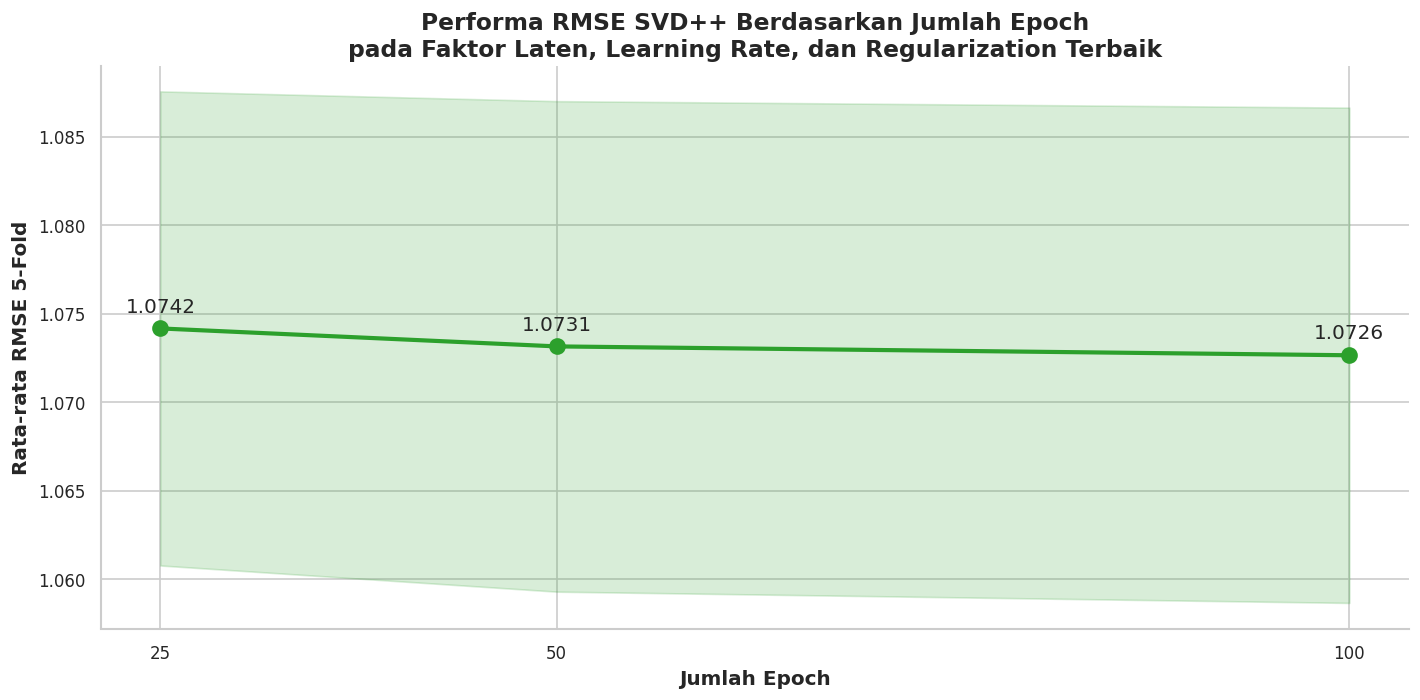

In [61]:
best_svdpp_epoch_plot = (
    svdpp_grid_summary[
        (
            svdpp_grid_summary[
                "n_factors"
            ] == best_svdpp_n_factors
        )
        & (
            svdpp_grid_summary[
                "learning_rate"
            ] == best_svdpp_learning_rate
        )
        & (
            svdpp_grid_summary[
                "regularization"
            ] == best_svdpp_regularization
        )
    ]
    .sort_values("n_epochs")
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.plot(
    best_svdpp_epoch_plot[
        "n_epochs"
    ],
    best_svdpp_epoch_plot[
        "mean_rmse"
    ],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=MODEL_COLORS["SVD++"]
)

ax.fill_between(
    best_svdpp_epoch_plot[
        "n_epochs"
    ],
    (
        best_svdpp_epoch_plot[
            "mean_rmse"
        ]
        - best_svdpp_epoch_plot[
            "std_rmse"
        ]
    ),
    (
        best_svdpp_epoch_plot[
            "mean_rmse"
        ]
        + best_svdpp_epoch_plot[
            "std_rmse"
        ]
    ),
    color=MODEL_COLORS["SVD++"],
    alpha=0.18
)

for _, row in (
    best_svdpp_epoch_plot.iterrows()
):
    ax.annotate(
        f"{row['mean_rmse']:.4f}",
        (
            row["n_epochs"],
            row["mean_rmse"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_title(
    "Performa RMSE SVD++ Berdasarkan Jumlah Epoch\n"
    "pada Faktor Laten, Learning Rate, dan Regularization Terbaik"
)

ax.set_xlabel("Jumlah Epoch")
ax.set_ylabel("Rata-rata RMSE 5-Fold")

ax.set_xticks(
    SVDPP_EPOCH_VALUES
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="26_SVDpp_RMSE_By_Epoch.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.3.14 Visualisasi MAE Berdasarkan Epoch**

Gambar berhasil disimpan: 27_SVDpp_MAE_By_Epoch.png (195.18 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

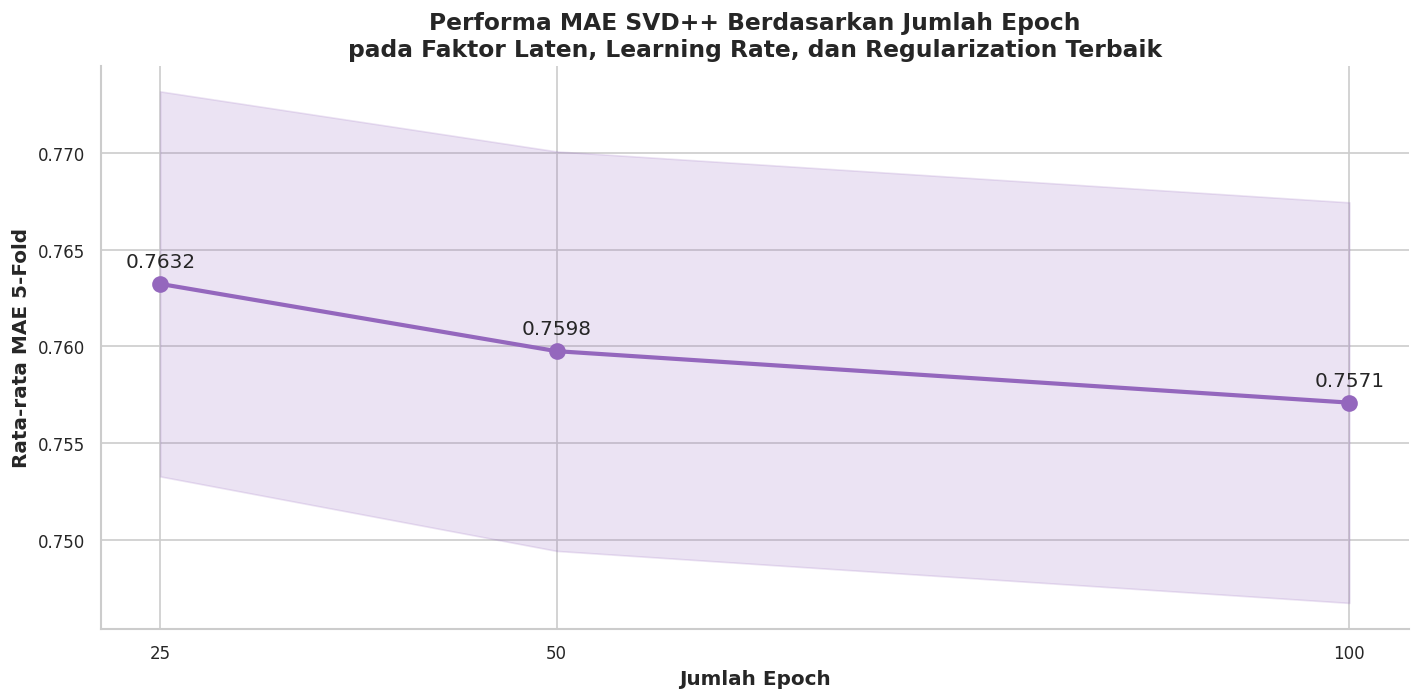

In [62]:
fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

ax.plot(
    best_svdpp_epoch_plot[
        "n_epochs"
    ],
    best_svdpp_epoch_plot[
        "mean_mae"
    ],
    marker="o",
    markersize=9,
    linewidth=2.5,
    color=METRIC_COLORS["MAE"]
)

ax.fill_between(
    best_svdpp_epoch_plot[
        "n_epochs"
    ],
    (
        best_svdpp_epoch_plot[
            "mean_mae"
        ]
        - best_svdpp_epoch_plot[
            "std_mae"
        ]
    ),
    (
        best_svdpp_epoch_plot[
            "mean_mae"
        ]
        + best_svdpp_epoch_plot[
            "std_mae"
        ]
    ),
    color=METRIC_COLORS["MAE"],
    alpha=0.18
)

for _, row in (
    best_svdpp_epoch_plot.iterrows()
):
    ax.annotate(
        f"{row['mean_mae']:.4f}",
        (
            row["n_epochs"],
            row["mean_mae"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_title(
    "Performa MAE SVD++ Berdasarkan Jumlah Epoch\n"
    "pada Faktor Laten, Learning Rate, dan Regularization Terbaik"
)

ax.set_xlabel("Jumlah Epoch")
ax.set_ylabel("Rata-rata MAE 5-Fold")

ax.set_xticks(
    SVDPP_EPOCH_VALUES
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="27_SVDpp_MAE_By_Epoch.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.3.15 Heatmap Learning Rate dan Regularization**

Gambar berhasil disimpan: 28_SVDpp_Heatmap_RMSE.png (154.29 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

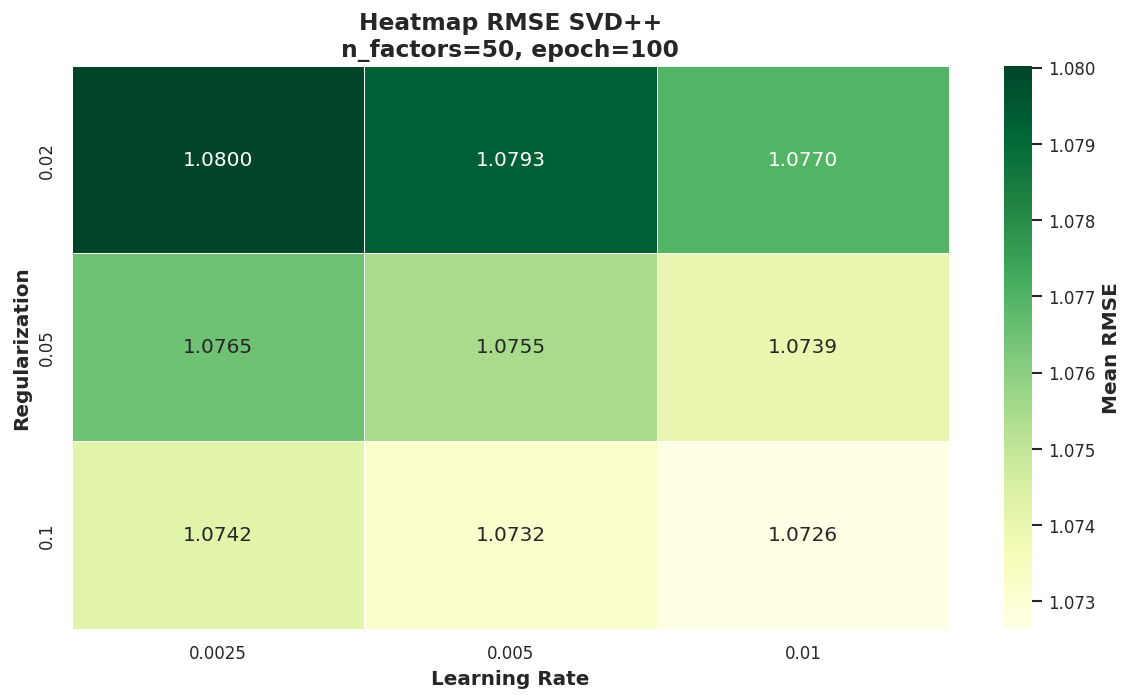

Gambar berhasil disimpan: 29_SVDpp_Heatmap_MAE.png (154.83 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

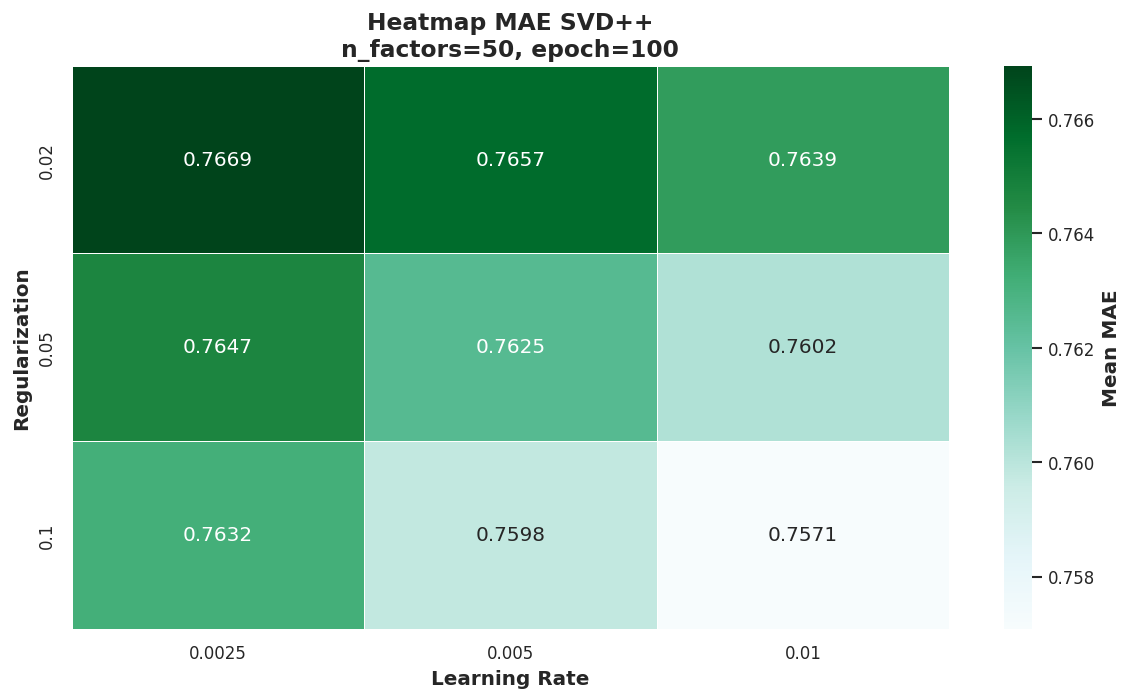

In [63]:
svdpp_heatmap_data = (
    svdpp_grid_summary[
        (
            svdpp_grid_summary[
                "n_factors"
            ] == best_svdpp_n_factors
        )
        & (
            svdpp_grid_summary[
                "n_epochs"
            ] == best_svdpp_n_epochs
        )
    ]
    .copy()
)

svdpp_rmse_heatmap_table = (
    svdpp_heatmap_data
    .pivot(
        index="regularization",
        columns="learning_rate",
        values="mean_rmse"
    )
)

svdpp_mae_heatmap_table = (
    svdpp_heatmap_data
    .pivot(
        index="regularization",
        columns="learning_rate",
        values="mean_mae"
    )
)


# ------------------------------------------------------------
# RMSE heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=DEFAULT_FIGSIZE
)

sns.heatmap(
    svdpp_rmse_heatmap_table,
    annot=True,
    fmt=".4f",
    cmap="YlGn",
    linewidths=0.5,
    cbar_kws={
        "label": "Mean RMSE"
    },
    ax=ax
)

ax.set_title(
    "Heatmap RMSE SVD++\n"
    f"n_factors={best_svdpp_n_factors}, "
    f"epoch={best_svdpp_n_epochs}"
)

ax.set_xlabel("Learning Rate")
ax.set_ylabel("Regularization")

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="28_SVDpp_Heatmap_RMSE.png",
    close_figure=False
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# MAE heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=DEFAULT_FIGSIZE
)

sns.heatmap(
    svdpp_mae_heatmap_table,
    annot=True,
    fmt=".4f",
    cmap="BuGn",
    linewidths=0.5,
    cbar_kws={
        "label": "Mean MAE"
    },
    ax=ax
)

ax.set_title(
    "Heatmap MAE SVD++\n"
    f"n_factors={best_svdpp_n_factors}, "
    f"epoch={best_svdpp_n_epochs}"
)

ax.set_xlabel("Learning Rate")
ax.set_ylabel("Regularization")

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="29_SVDpp_Heatmap_MAE.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.3.16 Performa Terbaik per Faktor Laten**

Gambar berhasil disimpan: 30_SVDpp_RMSE_By_Latent_Factor.png (101.26 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

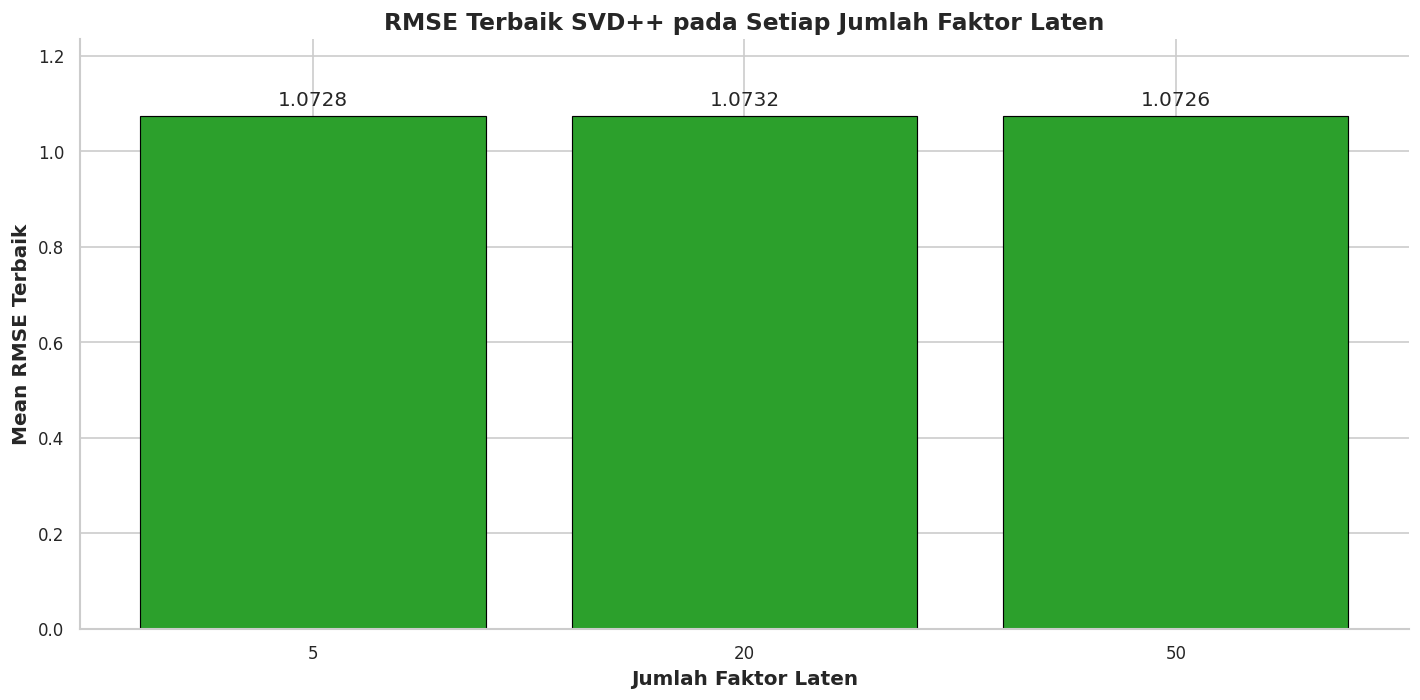

Gambar berhasil disimpan: 31_SVDpp_MAE_By_Latent_Factor.png (104.14 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

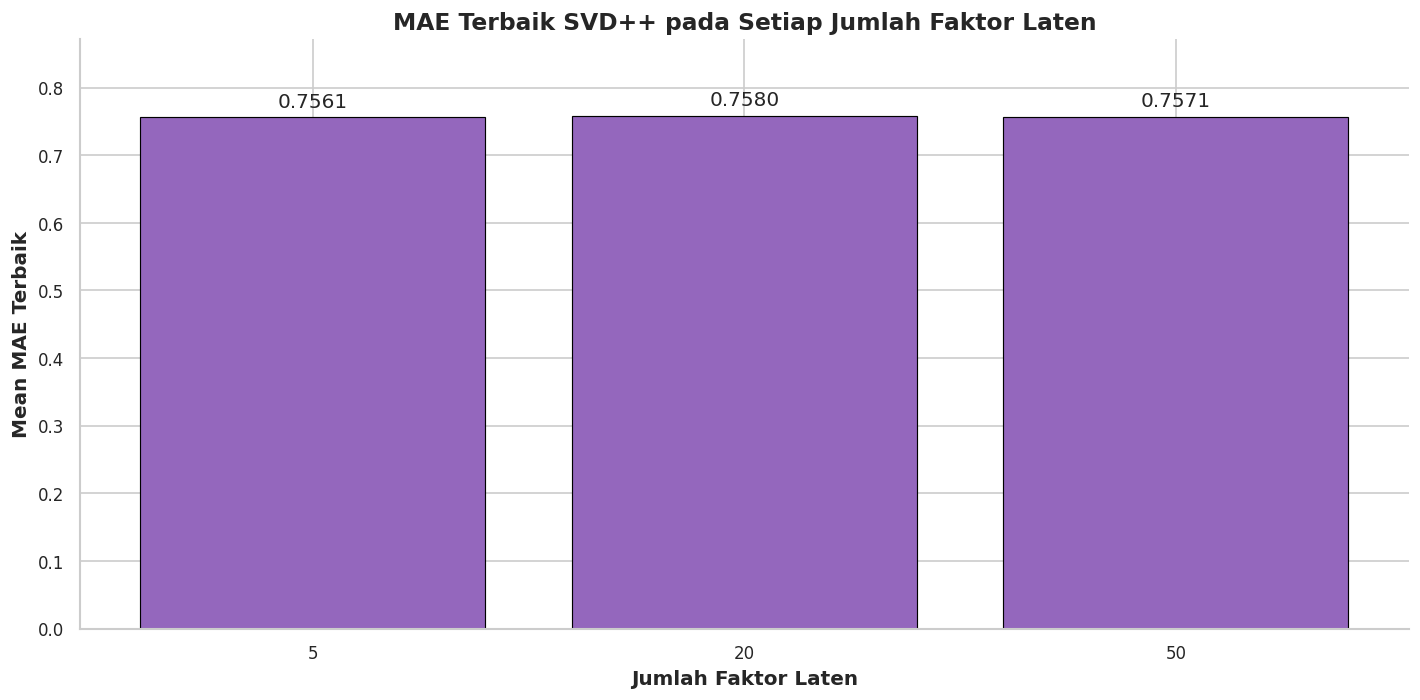

In [64]:
best_per_svdpp_factor = (
    svdpp_grid_summary
    .sort_values(
        [
            "n_factors",
            "mean_rmse",
            "mean_mae"
        ]
    )
    .groupby(
        "n_factors",
        as_index=False
    )
    .first()
    .sort_values("n_factors")
)


# ------------------------------------------------------------
# RMSE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    best_per_svdpp_factor[
        "n_factors"
    ].astype(str),
    best_per_svdpp_factor[
        "mean_rmse"
    ],
    color=MODEL_COLORS["SVD++"],
    edgecolor="black",
    linewidth=0.7
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in best_per_svdpp_factor[
            "mean_rmse"
        ]
    ],
    padding=4
)

ax.set_title(
    "RMSE Terbaik SVD++ pada Setiap Jumlah Faktor Laten"
)

ax.set_xlabel("Jumlah Faktor Laten")
ax.set_ylabel("Mean RMSE Terbaik")

ax.set_ylim(
    0,
    best_per_svdpp_factor[
        "mean_rmse"
    ].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="30_SVDpp_RMSE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)


# ------------------------------------------------------------
# MAE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    best_per_svdpp_factor[
        "n_factors"
    ].astype(str),
    best_per_svdpp_factor[
        "mean_mae"
    ],
    color=METRIC_COLORS["MAE"],
    edgecolor="black",
    linewidth=0.7
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in best_per_svdpp_factor[
            "mean_mae"
        ]
    ],
    padding=4
)

ax.set_title(
    "MAE Terbaik SVD++ pada Setiap Jumlah Faktor Laten"
)

ax.set_xlabel("Jumlah Faktor Laten")
ax.set_ylabel("Mean MAE Terbaik")

ax.set_ylim(
    0,
    best_per_svdpp_factor[
        "mean_mae"
    ].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="31_SVDpp_MAE_By_Latent_Factor.png",
    close_figure=False
)

plt.show()
plt.close(fig)

### **2.3.17 Pemeriksaan Akhir Optimasi SVD++**

In [65]:
assert len(svdpp_fold_results) == (
    number_of_svdpp_cv_evaluations
), (
    "Jumlah evaluasi SVD++ tidak sesuai."
)

assert len(svdpp_grid_summary) == (
    number_of_svdpp_parameter_combinations
), (
    "Jumlah kombinasi ringkasan SVD++ tidak sesuai."
)

assert (
    svdpp_fold_results[
        [
            "validation_rmse",
            "validation_mae"
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
), (
    "Terdapat RMSE atau MAE SVD++ yang kosong."
)

assert best_svdpp_n_factors in (
    SVDPP_N_FACTORS_VALUES
), (
    "Jumlah faktor terbaik SVD++ tidak valid."
)

assert best_svdpp_learning_rate in (
    SVDPP_LEARNING_RATE_VALUES
), (
    "Learning rate terbaik SVD++ tidak valid."
)

assert best_svdpp_regularization in (
    SVDPP_REGULARIZATION_VALUES
), (
    "Regularization terbaik SVD++ tidak valid."
)

assert best_svdpp_n_epochs in (
    SVDPP_EPOCH_VALUES
), (
    "Jumlah epoch terbaik SVD++ tidak valid."
)

assert (
    svdpp_best_oof_predictions[
        "interaction_id"
    ].nunique()
    == len(development_data)
), (
    "OOF prediction SVD++ belum mencakup "
    "seluruh development data."
)

assert (
    svdpp_best_oof_predictions[
        "rating_prediction"
    ]
    .between(
        RATING_MIN,
        RATING_MAX
    )
    .all()
), (
    "Terdapat prediksi SVD++ di luar skala rating."
)

assert (
    svdpp_best_oof_predictions[
        "prediction_source"
    ]
    .isin(
        EXPECTED_PREDICTION_SOURCE_ORDER
    )
    .all()
), (
    "Terdapat sumber prediksi SVD++ yang tidak valid."
)


print("=" * 80)
print("STEP 2.3 SELESAI")
print("=" * 80)

print(
    f"Jumlah kombinasi       : "
    f"{number_of_svdpp_parameter_combinations}"
)

print(
    f"Jumlah evaluasi        : "
    f"{len(svdpp_fold_results)}"
)

print(
    f"Best n_factors         : "
    f"{best_svdpp_n_factors}"
)

print(
    f"Best learning rate     : "
    f"{best_svdpp_learning_rate}"
)

print(
    f"Best regularization    : "
    f"{best_svdpp_regularization}"
)

print(
    f"Best epoch             : "
    f"{best_svdpp_n_epochs}"
)

print(
    f"Best mean RMSE         : "
    f"{best_svdpp_result['mean_rmse']:.6f}"
)

print(
    f"Best mean MAE          : "
    f"{best_svdpp_result['mean_mae']:.6f}"
)

print(
    f"Total Grid Search time : "
    f"{format_execution_time(svdpp_grid_total_time)}"
)

print()
print(
    "Seluruh proses optimasi hyperparameter "
    "SVD, Funk SVD, dan SVD++ telah selesai."
)

STEP 2.3 SELESAI
Jumlah kombinasi       : 81
Jumlah evaluasi        : 405
Best n_factors         : 50
Best learning rate     : 0.01
Best regularization    : 0.1
Best epoch             : 100
Best mean RMSE         : 1.072643
Best mean MAE          : 0.757095
Total Grid Search time : 2 menit 30.56 detik

Seluruh proses optimasi hyperparameter SVD, Funk SVD, dan SVD++ telah selesai.


# **Evaluasi Final Model**

## **3.1 Persiapan Evaluasi Final**

In [66]:
# Seed khusus untuk training final.
# Nilai tetap agar hasil dapat direproduksi.
FINAL_FUNK_RANDOM_SEED = RANDOM_STATE + 500_001
FINAL_SVDPP_RANDOM_SEED = RANDOM_STATE + 500_002

# Memastikan objek utama tersedia
required_final_objects = [
    "development_data",
    "final_test_data",
    "best_svd_k",
    "best_funk_n_factors",
    "best_funk_learning_rate",
    "best_funk_regularization",
    "best_funk_n_epochs",
    "best_svdpp_n_factors",
    "best_svdpp_learning_rate",
    "best_svdpp_regularization",
    "best_svdpp_n_epochs"
]

missing_final_objects = [
    object_name
    for object_name in required_final_objects
    if object_name not in globals()
]

if missing_final_objects:
    raise NameError(
        "Objek berikut belum tersedia: "
        f"{missing_final_objects}. "
        "Pastikan Step 0 sampai Step 2.3 telah dijalankan."
    )


# ------------------------------------------------------------
# Ringkasan hyperparameter terbaik
# ------------------------------------------------------------

final_hyperparameter_summary = pd.DataFrame([
    {
        "model": "SVD",
        "jumlah_komponen_atau_faktor": best_svd_k,
        "learning_rate": np.nan,
        "regularization": np.nan,
        "jumlah_epoch": np.nan,
        "random_seed_training_final": np.nan
    },
    {
        "model": "Funk SVD",
        "jumlah_komponen_atau_faktor": best_funk_n_factors,
        "learning_rate": best_funk_learning_rate,
        "regularization": best_funk_regularization,
        "jumlah_epoch": best_funk_n_epochs,
        "random_seed_training_final": FINAL_FUNK_RANDOM_SEED
    },
    {
        "model": "SVD++",
        "jumlah_komponen_atau_faktor": best_svdpp_n_factors,
        "learning_rate": best_svdpp_learning_rate,
        "regularization": best_svdpp_regularization,
        "jumlah_epoch": best_svdpp_n_epochs,
        "random_seed_training_final": FINAL_SVDPP_RANDOM_SEED
    }
])

print("=" * 80)
print("KONFIGURASI EVALUASI FINAL")
print("=" * 80)

print(
    f"Development data : "
    f"{len(development_data):,} interaksi"
)

print(
    f"Final test data  : "
    f"{len(final_test_data):,} interaksi"
)

print(
    "Kriteria model terbaik: "
    "RMSE final terendah, kemudian MAE final terendah."
)

display(final_hyperparameter_summary)

KONFIGURASI EVALUASI FINAL
Development data : 17,508 interaksi
Final test data  : 4,378 interaksi
Kriteria model terbaik: RMSE final terendah, kemudian MAE final terendah.


,model,jumlah_komponen_atau_faktor,learning_rate,regularization,jumlah_epoch,random_seed_training_final
0,SVD,5,NaN,NaN,NaN,NaN
1,Funk SVD,50,0.010000,0.100000,100.000000,500043.000000
2,SVD++,50,0.010000,0.100000,100.000000,500044.000000


## **3.2 Persiapan Data Training Final**

In [67]:
# Data siap training untuk Funk SVD
final_funk_prepared_data = prepare_funk_svd_fold(
    train_data=development_data,
    validation_data=final_test_data,
    fold_number=0
)

# Data siap training untuk SVD++
final_svdpp_prepared_data = prepare_svdpp_fold(
    train_data=development_data,
    validation_data=final_test_data,
    fold_number=0
)


# ------------------------------------------------------------
# Ringkasan data training final
# ------------------------------------------------------------

final_training_data_summary = pd.DataFrame({
    "Metrik": [
        "Jumlah interaksi development",
        "Jumlah user development",
        "Jumlah item development",
        "Jumlah interaksi final test",
        "Jumlah user final test",
        "Jumlah item final test",
        "Global mean development",
        "Rata-rata implicit history SVD++",
        "Median implicit history SVD++",
        "Maksimum implicit history SVD++"
    ],
    "Nilai": [
        len(development_data),
        development_data["user_id"].nunique(),
        development_data["place_id"].nunique(),
        len(final_test_data),
        final_test_data["user_id"].nunique(),
        final_test_data["place_id"].nunique(),
        final_funk_prepared_data["global_mean"],
        final_svdpp_prepared_data["mean_history_length"],
        final_svdpp_prepared_data["median_history_length"],
        final_svdpp_prepared_data["maximum_history_length"]
    ]
})

display(final_training_data_summary)

print(
    "Data training final Funk SVD dan SVD++ "
    "berhasil disiapkan."
)

,Metrik,Nilai
0,Jumlah interaksi development,17508.000000
1,Jumlah user development,15126.000000
2,Jumlah item development,296.000000
3,Jumlah interaksi final test,4378.000000
4,Jumlah user final test,4147.000000
5,Jumlah item final test,272.000000
6,Global mean development,4.350868
7,Rata-rata implicit history SVD++,1.157477
8,Median implicit history SVD++,1.000000
9,Maksimum implicit history SVD++,27.000000


Data training final Funk SVD dan SVD++ berhasil disiapkan.


## **3.3 Training Ulang Model dengan Hyperparameter Terbaik**

### **3.3.1 Training Final SVD**

In [68]:
final_svd_training_start = time.perf_counter()

final_svd_model = train_classical_svd(
    train_data=development_data,
    n_components=best_svd_k
)

final_svd_training_time = (
    time.perf_counter()
    - final_svd_training_start
)

print("Training final SVD selesai.")

print(
    f"Jumlah komponen laten : "
    f"{best_svd_k}"
)

print(
    f"Waktu training        : "
    f"{format_execution_time(final_svd_training_time)}"
)

Training final SVD selesai.
Jumlah komponen laten : 5
Waktu training        : 0.08 detik


### **3.3.2 Training Final Funk SVD**

In [69]:
final_funk_training_start = time.perf_counter()

(
    final_funk_svd_model,
    final_funk_svd_training_history
) = train_funk_svd_model(
    prepared_fold=final_funk_prepared_data,
    n_factors=best_funk_n_factors,
    learning_rate=best_funk_learning_rate,
    regularization=best_funk_regularization,
    n_epochs=best_funk_n_epochs,
    random_seed=FINAL_FUNK_RANDOM_SEED
)

final_funk_training_time = (
    time.perf_counter()
    - final_funk_training_start
)

final_funk_svd_training_history.insert(
    0,
    "model",
    "Funk SVD"
)

print("Training final Funk SVD selesai.")

print(
    f"Jumlah faktor laten : "
    f"{best_funk_n_factors}"
)

print(
    f"Learning rate       : "
    f"{best_funk_learning_rate}"
)

print(
    f"Regularization      : "
    f"{best_funk_regularization}"
)

print(
    f"Jumlah epoch        : "
    f"{best_funk_n_epochs}"
)

print(
    f"Waktu training      : "
    f"{format_execution_time(final_funk_training_time)}"
)

Training final Funk SVD selesai.
Jumlah faktor laten : 50
Learning rate       : 0.01
Regularization      : 0.1
Jumlah epoch        : 100
Waktu training      : 0.34 detik


### **3.3.3 Training Final SVD++**

In [70]:
final_svdpp_training_start = time.perf_counter()

(
    final_svdpp_model,
    final_svdpp_training_history
) = train_svdpp_model(
    prepared_fold=final_svdpp_prepared_data,
    n_factors=best_svdpp_n_factors,
    learning_rate=best_svdpp_learning_rate,
    regularization=best_svdpp_regularization,
    n_epochs=best_svdpp_n_epochs,
    random_seed=FINAL_SVDPP_RANDOM_SEED
)

final_svdpp_training_time = (
    time.perf_counter()
    - final_svdpp_training_start
)

final_svdpp_training_history.insert(
    0,
    "model",
    "SVD++"
)

print("Training final SVD++ selesai.")

print(
    f"Jumlah faktor laten : "
    f"{best_svdpp_n_factors}"
)

print(
    f"Learning rate       : "
    f"{best_svdpp_learning_rate}"
)

print(
    f"Regularization      : "
    f"{best_svdpp_regularization}"
)

print(
    f"Jumlah epoch        : "
    f"{best_svdpp_n_epochs}"
)

print(
    f"Waktu training      : "
    f"{format_execution_time(final_svdpp_training_time)}"
)

Training final SVD++ selesai.
Jumlah faktor laten : 50
Learning rate       : 0.01
Regularization      : 0.1
Jumlah epoch        : 100
Waktu training      : 1.12 detik


### **3.3.4 Ringkasan Waktu Training Final**

In [71]:
final_training_time_summary = pd.DataFrame({
    "model": [
        "SVD",
        "Funk SVD",
        "SVD++"
    ],
    "training_time_seconds": [
        final_svd_training_time,
        final_funk_training_time,
        final_svdpp_training_time
    ]
})

final_training_time_summary[
    "training_time_formatted"
] = (
    final_training_time_summary[
        "training_time_seconds"
    ]
    .apply(format_execution_time)
)

display(final_training_time_summary)

,model,training_time_seconds,training_time_formatted
0,SVD,0.076777,0.08 detik
1,Funk SVD,0.341532,0.34 detik
2,SVD++,1.116357,1.12 detik


## **3.4 Prediksi Final Test Data**

In [72]:
# ------------------------------------------------------------
# A. Prediksi SVD
# ------------------------------------------------------------

final_svd_prediction_start = time.perf_counter()

final_svd_predictions = predict_classical_svd(
    model=final_svd_model,
    test_data=final_test_data
)

final_svd_prediction_time = (
    time.perf_counter()
    - final_svd_prediction_start
)

final_svd_predictions.insert(
    0,
    "model",
    "SVD"
)

final_svd_predictions[
    "model_training_time_seconds"
] = final_svd_training_time

final_svd_predictions[
    "total_prediction_time_seconds"
] = final_svd_prediction_time


# ------------------------------------------------------------
# B. Prediksi Funk SVD
# ------------------------------------------------------------

final_funk_prediction_start = time.perf_counter()

final_funk_svd_predictions = predict_funk_svd(
    model=final_funk_svd_model,
    test_data=final_test_data
)

final_funk_prediction_time = (
    time.perf_counter()
    - final_funk_prediction_start
)

final_funk_svd_predictions.insert(
    0,
    "model",
    "Funk SVD"
)

final_funk_svd_predictions[
    "model_training_time_seconds"
] = final_funk_training_time

final_funk_svd_predictions[
    "total_prediction_time_seconds"
] = final_funk_prediction_time


# ------------------------------------------------------------
# C. Prediksi SVD++
# ------------------------------------------------------------

final_svdpp_prediction_start = time.perf_counter()

final_svdpp_predictions = predict_svdpp(
    model=final_svdpp_model,
    test_data=final_test_data
)

final_svdpp_prediction_time = (
    time.perf_counter()
    - final_svdpp_prediction_start
)

final_svdpp_predictions.insert(
    0,
    "model",
    "SVD++"
)

final_svdpp_predictions[
    "model_training_time_seconds"
] = final_svdpp_training_time

final_svdpp_predictions[
    "total_prediction_time_seconds"
] = final_svdpp_prediction_time


# ------------------------------------------------------------
# D. Menggabungkan seluruh prediksi
# ------------------------------------------------------------

final_prediction_results = pd.concat(
    [
        final_svd_predictions,
        final_funk_svd_predictions,
        final_svdpp_predictions
    ],
    ignore_index=True,
    sort=False
)

print("Prediksi final test seluruh model selesai.")

print(
    f"Waktu prediksi SVD      : "
    f"{format_execution_time(final_svd_prediction_time)}"
)

print(
    f"Waktu prediksi Funk SVD : "
    f"{format_execution_time(final_funk_prediction_time)}"
)

print(
    f"Waktu prediksi SVD++    : "
    f"{format_execution_time(final_svdpp_prediction_time)}"
)

display(
    final_prediction_results[
        [
            "model",
            "interaction_id",
            "user_id",
            "place_id",
            "rating",
            "rating_prediction",
            "prediction_source",
            "kategori_user"
        ]
    ].head(15)
)

Prediksi final test seluruh model selesai.
Waktu prediksi SVD      : 0.03 detik
Waktu prediksi Funk SVD : 0.02 detik
Waktu prediksi SVD++    : 0.02 detik


,model,interaction_id,user_id,place_id,rating,rating_prediction,prediction_source,kategori_user
0,SVD,3,8EF878BEE1C146976972BED37294BF4F,1793975,5,4.958333,Item Mean Fallback,Unseen User
1,SVD,6,7E5C77AC5B26D50A00FA63340D00133E,1793975,5,4.958333,Item Mean Fallback,Unseen User
2,SVD,17,A07FBA109BCFD4CCC26F739F11D947B9,1912575,3,4.441176,Item Mean Fallback,Unseen User
3,SVD,31,100000109853106649694,ChIJgZvtEpU_0i0RjpCO5_jZSUI,5,4.672727,Item Mean Fallback,Unseen User
4,SVD,34,103706239272595809611,ChIJ0Zo39DZH0i0R0acI0bADr2U,5,4.662500,Item Mean Fallback,Unseen User
5,SVD,35,113114228333464946123,ChIJ0Zo39DZH0i0R0acI0bADr2U,5,4.662500,Item Mean Fallback,Unseen User
6,SVD,41,103577620323938402961,ChIJMa53HxZ30i0RjT02sEeHrQ0,5,4.797468,Item Mean Fallback,Unseen User
7,SVD,42,105776259418688087511,ChIJMa53HxZ30i0RjT02sEeHrQ0,5,4.797468,Item Mean Fallback,Unseen User
8,SVD,44,113127736802671901291,ChIJMa53HxZ30i0RjT02sEeHrQ0,5,4.797468,Item Mean Fallback,Unseen User
9,SVD,46,108749583041974995848,ChIJMa53HxZ30i0RjT02sEeHrQ0,5,4.797468,Item Mean Fallback,Unseen User


## **3.5 Evaluasi RMSE dan MAE Keseluruhan**

In [73]:
def create_final_overall_record(
    model_name: str,
    prediction_data: pd.DataFrame,
    training_time_seconds: float,
    prediction_time_seconds: float
) -> Dict[str, Any]:
    """
    Membentuk ringkasan evaluasi final keseluruhan.
    """

    metrics = evaluate_prediction_dataframe(
        prediction_data
    )

    prediction_source_counts = (
        prediction_data[
            "prediction_source"
        ]
        .value_counts()
    )

    model_prediction_count = int(
        prediction_source_counts.get(
            "Model Prediction",
            0
        )
    )

    fallback_prediction_count = (
        len(prediction_data)
        - model_prediction_count
    )

    return {
        "model": model_name,
        "jumlah_final_test": len(
            prediction_data
        ),
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "jumlah_model_prediction": (
            model_prediction_count
        ),
        "persentase_model_prediction": (
            model_prediction_count
            / len(prediction_data)
            * 100
        ),
        "jumlah_fallback_prediction": (
            fallback_prediction_count
        ),
        "persentase_fallback_prediction": (
            fallback_prediction_count
            / len(prediction_data)
            * 100
        ),
        "training_time_seconds": (
            training_time_seconds
        ),
        "prediction_time_seconds": (
            prediction_time_seconds
        ),
        "total_execution_time_seconds": (
            training_time_seconds
            + prediction_time_seconds
        )
    }


final_overall_results = pd.DataFrame([
    create_final_overall_record(
        model_name="SVD",
        prediction_data=final_svd_predictions,
        training_time_seconds=final_svd_training_time,
        prediction_time_seconds=final_svd_prediction_time
    ),
    create_final_overall_record(
        model_name="Funk SVD",
        prediction_data=final_funk_svd_predictions,
        training_time_seconds=final_funk_training_time,
        prediction_time_seconds=final_funk_prediction_time
    ),
    create_final_overall_record(
        model_name="SVD++",
        prediction_data=final_svdpp_predictions,
        training_time_seconds=final_svdpp_training_time,
        prediction_time_seconds=final_svdpp_prediction_time
    )
])

final_overall_results = (
    final_overall_results
    .sort_values(
        by=[
            "rmse",
            "mae",
            "model"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

final_overall_results.insert(
    0,
    "ranking",
    np.arange(
        1,
        len(final_overall_results) + 1
    )
)

display(final_overall_results)

,ranking,model,jumlah_final_test,rmse,mae,jumlah_model_prediction,persentase_model_prediction,jumlah_fallback_prediction,persentase_fallback_prediction,training_time_seconds,prediction_time_seconds,total_execution_time_seconds
0,1,Funk SVD,4378,1.043333,0.743444,921,21.037003,3457,78.962997,0.341532,0.024690,0.366223
1,2,SVD++,4378,1.045791,0.744687,921,21.037003,3457,78.962997,1.116357,0.024588,1.140946
2,3,SVD,4378,1.063348,0.777104,921,21.037003,3457,78.962997,0.076777,0.029335,0.106112


## **3.6 Evaluasi Berdasarkan Kategori User**

In [74]:
def summarize_final_by_group(
    prediction_data: pd.DataFrame,
    model_name: str,
    group_column: str,
    group_order: Sequence[str]
) -> pd.DataFrame:
    """
    Menghitung statistik evaluasi berdasarkan kelompok.
    """

    records = []

    for group_value in group_order:

        group_mask = (
            prediction_data[
                group_column
            ].astype(str)
            == str(group_value)
        )

        group_data = (
            prediction_data[
                group_mask
            ]
        )

        if group_data.empty:
            records.append({
                "model": model_name,
                group_column: group_value,
                "jumlah_prediksi": 0,
                "persentase_prediksi": 0.0,
                "jumlah_user_unik": 0,
                "jumlah_item_unik": 0,
                "rata_rata_rating_aktual": np.nan,
                "rata_rata_rating_prediksi": np.nan,
                "rmse": np.nan,
                "mae": np.nan
            })

            continue

        metrics = evaluate_prediction_dataframe(
            group_data
        )

        records.append({
            "model": model_name,
            group_column: group_value,
            "jumlah_prediksi": len(group_data),
            "persentase_prediksi": (
                len(group_data)
                / len(prediction_data)
                * 100
            ),
            "jumlah_user_unik": (
                group_data["user_id"].nunique()
            ),
            "jumlah_item_unik": (
                group_data["place_id"].nunique()
            ),
            "rata_rata_rating_aktual": (
                group_data["rating"].mean()
            ),
            "rata_rata_rating_prediksi": (
                group_data[
                    "rating_prediction"
                ].mean()
            ),
            "rmse": metrics["rmse"],
            "mae": metrics["mae"]
        })

    return pd.DataFrame(records)


final_user_category_results = pd.concat(
    [
        summarize_final_by_group(
            prediction_data=final_svd_predictions,
            model_name="SVD",
            group_column="kategori_user",
            group_order=USER_CATEGORY_ORDER
        ),
        summarize_final_by_group(
            prediction_data=final_funk_svd_predictions,
            model_name="Funk SVD",
            group_column="kategori_user",
            group_order=USER_CATEGORY_ORDER
        ),
        summarize_final_by_group(
            prediction_data=final_svdpp_predictions,
            model_name="SVD++",
            group_column="kategori_user",
            group_order=USER_CATEGORY_ORDER
        )
    ],
    ignore_index=True
)

final_user_category_results[
    "deskripsi_kategori"
] = (
    final_user_category_results[
        "kategori_user"
    ]
    .map(USER_CATEGORY_LABELS)
)

display(final_user_category_results)

,model,kategori_user,jumlah_prediksi,persentase_prediksi,jumlah_user_unik,jumlah_item_unik,rata_rata_rating_aktual,rata_rata_rating_prediksi,rmse,mae,deskripsi_kategori
0,SVD,Unseen User,3454,78.894472,3398,252,4.337869,4.365403,1.093894,0.784222,0 interaksi
1,SVD,Single-Interaction User,463,10.575605,427,170,4.390929,4.351101,0.968394,0.773759,1 interaksi
2,SVD,Low-History User,373,8.519872,282,139,4.418231,4.348217,0.908134,0.737675,2–5 interaksi
3,SVD,Higher-History User,88,2.010050,40,56,4.193182,4.356038,0.925430,0.682444,>5 interaksi
4,Funk SVD,Unseen User,3454,78.894472,3398,252,4.337869,4.365403,1.093894,0.784222,0 interaksi
5,Funk SVD,Single-Interaction User,463,10.575605,427,170,4.390929,4.374826,0.860488,0.618862,1 interaksi
6,Funk SVD,Low-History User,373,8.519872,282,139,4.418231,4.352940,0.800095,0.569899,2–5 interaksi
7,Funk SVD,Higher-History User,88,2.010050,40,56,4.193182,4.262425,0.761117,0.533979,>5 interaksi
8,SVD++,Unseen User,3454,78.894472,3398,252,4.337869,4.365403,1.093894,0.784222,0 interaksi
9,SVD++,Single-Interaction User,463,10.575605,427,170,4.390929,4.401839,0.875342,0.631093,1 interaksi


## **3.7 Evaluasi Berdasarkan Sumber Prediksi**

In [75]:
final_prediction_source_results = pd.concat(
    [
        summarize_final_by_group(
            prediction_data=final_svd_predictions,
            model_name="SVD",
            group_column="prediction_source",
            group_order=EXPECTED_PREDICTION_SOURCE_ORDER
        ),
        summarize_final_by_group(
            prediction_data=final_funk_svd_predictions,
            model_name="Funk SVD",
            group_column="prediction_source",
            group_order=EXPECTED_PREDICTION_SOURCE_ORDER
        ),
        summarize_final_by_group(
            prediction_data=final_svdpp_predictions,
            model_name="SVD++",
            group_column="prediction_source",
            group_order=EXPECTED_PREDICTION_SOURCE_ORDER
        )
    ],
    ignore_index=True
)

display(final_prediction_source_results)

,model,prediction_source,jumlah_prediksi,persentase_prediksi,jumlah_user_unik,jumlah_item_unik,rata_rata_rating_aktual,rata_rata_rating_prediksi,rmse,mae
0,SVD,Model Prediction,921,21.037003,746,206,4.381107,4.349105,0.941626,0.752126
1,SVD,Item Mean Fallback,3453,78.871631,3397,251,4.337677,4.365407,1.093996,0.784262
2,SVD,User Mean Fallback,3,0.068524,3,3,5.000000,4.750000,0.433013,0.250000
3,SVD,Global Mean Fallback,1,0.022841,1,1,5.000000,4.350868,0.649132,0.649132
4,Funk SVD,Model Prediction,921,21.037003,746,206,4.381107,4.354000,0.828389,0.592123
5,Funk SVD,Item Mean Fallback,3453,78.871631,3397,251,4.337677,4.365407,1.093996,0.784262
6,Funk SVD,User Mean Fallback,3,0.068524,3,3,5.000000,4.750000,0.433013,0.250000
7,Funk SVD,Global Mean Fallback,1,0.022841,1,1,5.000000,4.350868,0.649132,0.649132
8,SVD++,Model Prediction,921,21.037003,746,206,4.381107,4.392047,0.842994,0.598032
9,SVD++,Item Mean Fallback,3453,78.871631,3397,251,4.337677,4.365407,1.093996,0.784262


## **3.8 Evaluasi Khusus Model Prediction**

In [76]:
final_model_prediction_only_records = []

final_prediction_dictionary = {
    "SVD": final_svd_predictions,
    "Funk SVD": final_funk_svd_predictions,
    "SVD++": final_svdpp_predictions
}

for model_name, prediction_data in (
    final_prediction_dictionary.items()
):

    model_only_data = prediction_data[
        prediction_data[
            "prediction_source"
        ] == "Model Prediction"
    ].copy()

    model_only_metrics = (
        evaluate_prediction_dataframe(
            model_only_data
        )
    )

    final_model_prediction_only_records.append({
        "model": model_name,
        "jumlah_prediksi_model": (
            len(model_only_data)
        ),
        "persentase_final_test": (
            len(model_only_data)
            / len(prediction_data)
            * 100
        ),
        "rmse_model_prediction": (
            model_only_metrics["rmse"]
        ),
        "mae_model_prediction": (
            model_only_metrics["mae"]
        )
    })


final_model_prediction_only_results = (
    pd.DataFrame(
        final_model_prediction_only_records
    )
    .sort_values(
        by=[
            "rmse_model_prediction",
            "mae_model_prediction",
            "model"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

final_model_prediction_only_results.insert(
    0,
    "ranking_diagnostik",
    np.arange(
        1,
        len(
            final_model_prediction_only_results
        ) + 1
    )
)

display(final_model_prediction_only_results)

,ranking_diagnostik,model,jumlah_prediksi_model,persentase_final_test,rmse_model_prediction,mae_model_prediction
0,1,Funk SVD,921,21.037003,0.828389,0.592123
1,2,SVD++,921,21.037003,0.842994,0.598032
2,3,SVD,921,21.037003,0.941626,0.752126


## **3.9 Pemeriksaan Konsistensi Fallback**

In [77]:
fallback_consistency_check = (
    final_svd_predictions[
        [
            "interaction_id",
            "prediction_source",
            "rating_prediction"
        ]
    ]
    .rename(columns={
        "prediction_source": (
            "prediction_source_svd"
        ),
        "rating_prediction": (
            "rating_prediction_svd"
        )
    })
    .merge(
        final_funk_svd_predictions[
            [
                "interaction_id",
                "prediction_source",
                "rating_prediction"
            ]
        ].rename(columns={
            "prediction_source": (
                "prediction_source_funk"
            ),
            "rating_prediction": (
                "rating_prediction_funk"
            )
        }),
        on="interaction_id",
        how="inner"
    )
    .merge(
        final_svdpp_predictions[
            [
                "interaction_id",
                "prediction_source",
                "rating_prediction"
            ]
        ].rename(columns={
            "prediction_source": (
                "prediction_source_svdpp"
            ),
            "rating_prediction": (
                "rating_prediction_svdpp"
            )
        }),
        on="interaction_id",
        how="inner"
    )
)


# ------------------------------------------------------------
# A. Memastikan sumber prediksi sama
# ------------------------------------------------------------

fallback_consistency_check[
    "prediction_source_consistent"
] = (
    (
        fallback_consistency_check[
            "prediction_source_svd"
        ]
        == fallback_consistency_check[
            "prediction_source_funk"
        ]
    )
    & (
        fallback_consistency_check[
            "prediction_source_svd"
        ]
        == fallback_consistency_check[
            "prediction_source_svdpp"
        ]
    )
)


# ------------------------------------------------------------
# B. Memastikan nilai fallback sama
# ------------------------------------------------------------

fallback_rows = fallback_consistency_check[
    fallback_consistency_check[
        "prediction_source_svd"
    ] != "Model Prediction"
].copy()

if len(fallback_rows) > 0:

    fallback_rows[
        "fallback_value_consistent"
    ] = (
        np.isclose(
            fallback_rows[
                "rating_prediction_svd"
            ],
            fallback_rows[
                "rating_prediction_funk"
            ],
            rtol=1e-10,
            atol=1e-10
        )
        & np.isclose(
            fallback_rows[
                "rating_prediction_svd"
            ],
            fallback_rows[
                "rating_prediction_svdpp"
            ],
            rtol=1e-10,
            atol=1e-10
        )
    )

else:
    fallback_rows[
        "fallback_value_consistent"
    ] = pd.Series(dtype=bool)


fallback_consistency_summary = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah final test",
        "Jumlah baris berhasil dibandingkan",
        "Sumber prediksi konsisten",
        "Jumlah prediksi fallback",
        "Nilai fallback konsisten"
    ],
    "Hasil": [
        len(final_test_data),
        len(fallback_consistency_check),
        int(
            fallback_consistency_check[
                "prediction_source_consistent"
            ].sum()
        ),
        len(fallback_rows),
        int(
            fallback_rows[
                "fallback_value_consistent"
            ].sum()
        )
    ]
})

display(fallback_consistency_summary)

,Pemeriksaan,Hasil
0,Jumlah final test,4378
1,Jumlah baris berhasil dibandingkan,4378
2,Sumber prediksi konsisten,4378
3,Jumlah prediksi fallback,3457
4,Nilai fallback konsisten,3457


## **3.10 Penentuan Model Terbaik**

In [78]:
best_final_result = (
    final_overall_results
    .iloc[0]
    .copy()
)

best_final_model_name = str(
    best_final_result["model"]
)

BEST_MODEL_NAME = best_final_model_name


# ------------------------------------------------------------
# Menghitung perbaikan terhadap baseline SVD
# ------------------------------------------------------------

svd_final_rmse = float(
    final_overall_results.loc[
        final_overall_results["model"] == "SVD",
        "rmse"
    ].iloc[0]
)

svd_final_mae = float(
    final_overall_results.loc[
        final_overall_results["model"] == "SVD",
        "mae"
    ].iloc[0]
)

final_overall_results[
    "perbaikan_rmse_vs_svd_percent"
] = (
    (
        svd_final_rmse
        - final_overall_results["rmse"]
    )
    / svd_final_rmse
    * 100
)

final_overall_results[
    "perbaikan_mae_vs_svd_percent"
] = (
    (
        svd_final_mae
        - final_overall_results["mae"]
    )
    / svd_final_mae
    * 100
)


# ------------------------------------------------------------
# Menghubungkan nama model dengan objek model
# ------------------------------------------------------------

final_model_objects = {
    "SVD": final_svd_model,
    "Funk SVD": final_funk_svd_model,
    "SVD++": final_svdpp_model
}

best_final_model_object = (
    final_model_objects[
        best_final_model_name
    ]
)


# ------------------------------------------------------------
# Mengambil hyperparameter model terbaik
# ------------------------------------------------------------

best_final_hyperparameter = (
    final_hyperparameter_summary[
        final_hyperparameter_summary[
            "model"
        ] == best_final_model_name
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Ringkasan model terbaik
# ------------------------------------------------------------

best_final_model_summary = pd.DataFrame({
    "Komponen": [
        "Model terbaik",
        "Ranking final",
        "RMSE final",
        "MAE final",
        "Jumlah final test",
        "Jumlah model prediction",
        "Persentase model prediction",
        "Jumlah fallback prediction",
        "Persentase fallback prediction",
        "Kriteria utama",
        "Kriteria kedua",
        "Dataset evaluasi"
    ],
    "Nilai": [
        best_final_model_name,
        int(best_final_result["ranking"]),
        float(best_final_result["rmse"]),
        float(best_final_result["mae"]),
        int(
            best_final_result[
                "jumlah_final_test"
            ]
        ),
        int(
            best_final_result[
                "jumlah_model_prediction"
            ]
        ),
        float(
            best_final_result[
                "persentase_model_prediction"
            ]
        ),
        int(
            best_final_result[
                "jumlah_fallback_prediction"
            ]
        ),
        float(
            best_final_result[
                "persentase_fallback_prediction"
            ]
        ),
        "RMSE final terendah",
        "MAE final terendah",
        "Final test data 20%"
    ]
})


print("=" * 80)
print("MODEL TERBAIK BERDASARKAN EVALUASI FINAL")
print("=" * 80)

print(
    f"Model terbaik : "
    f"{best_final_model_name}"
)

print(
    f"RMSE final    : "
    f"{best_final_result['rmse']:.6f}"
)

print(
    f"MAE final     : "
    f"{best_final_result['mae']:.6f}"
)

print(
    f"Model prediction: "
    f"{int(best_final_result['jumlah_model_prediction']):,} "
    f"({best_final_result['persentase_model_prediction']:.2f}%)"
)

print(
    f"Fallback prediction: "
    f"{int(best_final_result['jumlah_fallback_prediction']):,} "
    f"({best_final_result['persentase_fallback_prediction']:.2f}%)"
)

display(final_overall_results)
display(best_final_model_summary)
display(best_final_hyperparameter)

MODEL TERBAIK BERDASARKAN EVALUASI FINAL
Model terbaik : Funk SVD
RMSE final    : 1.043333
MAE final     : 0.743444
Model prediction: 921 (21.04%)
Fallback prediction: 3,457 (78.96%)


,ranking,model,jumlah_final_test,rmse,mae,jumlah_model_prediction,persentase_model_prediction,jumlah_fallback_prediction,persentase_fallback_prediction,training_time_seconds,prediction_time_seconds,total_execution_time_seconds,perbaikan_rmse_vs_svd_percent,perbaikan_mae_vs_svd_percent
0,1,Funk SVD,4378,1.043333,0.743444,921,21.037003,3457,78.962997,0.341532,0.024690,0.366223,1.882240,4.331444
1,2,SVD++,4378,1.045791,0.744687,921,21.037003,3457,78.962997,1.116357,0.024588,1.140946,1.651070,4.171503
2,3,SVD,4378,1.063348,0.777104,921,21.037003,3457,78.962997,0.076777,0.029335,0.106112,0.000000,0.000000


,Komponen,Nilai
0,Model terbaik,Funk SVD
1,Ranking final,1
2,RMSE final,1.043333
3,MAE final,0.743444
4,Jumlah final test,4378
5,Jumlah model prediction,921
6,Persentase model prediction,21.037003
7,Jumlah fallback prediction,3457
8,Persentase fallback prediction,78.962997
9,Kriteria utama,RMSE final terendah


,model,jumlah_komponen_atau_faktor,learning_rate,regularization,jumlah_epoch,random_seed_training_final
0,Funk SVD,50,0.010000,0.100000,100.000000,500043.000000


## **3.11 Penyimpanan Hasil Evaluasi Final**

In [79]:
save_excel_output(
    data={
        "Hyperparameter Terbaik": (
            final_hyperparameter_summary
        ),
        "Ringkasan Training Data": (
            final_training_data_summary
        ),
        "Waktu Training": (
            final_training_time_summary
        ),
        "Evaluasi Keseluruhan": (
            final_overall_results
        ),
        "Model Prediction Only": (
            final_model_prediction_only_results
        ),
        "Kategori User": (
            final_user_category_results
        ),
        "Sumber Prediksi": (
            final_prediction_source_results
        ),
        "Konsistensi Fallback": (
            fallback_consistency_summary
        ),
        "Prediksi SVD": (
            final_svd_predictions
        ),
        "Prediksi Funk SVD": (
            final_funk_svd_predictions
        ),
        "Prediksi SVDpp": (
            final_svdpp_predictions
        ),
        "History Funk SVD": (
            final_funk_svd_training_history
        ),
        "History SVDpp": (
            final_svdpp_training_history
        )
    },
    filename="33_Hasil_Evaluasi_Final.xlsx",
    index=False
)

save_excel_output(
    data={
        "Model Terbaik": (
            best_final_model_summary
        ),
        "Hyperparameter": (
            best_final_hyperparameter
        ),
        "Ranking Model": (
            final_overall_results
        ),
        "Diagnostik Model Only": (
            final_model_prediction_only_results
        )
    },
    filename="41_Model_Terbaik.xlsx",
    index=False
)

Excel berhasil disimpan: 33_Hasil_Evaluasi_Final.xlsx (2467.28 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 41_Model_Terbaik.xlsx (8.35 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/41_Model_Terbaik.xlsx')

## **3.12 Visualisasi Perbandingan RMSE Final**

Gambar berhasil disimpan: 34_Perbandingan_RMSE_Final.png (93.69 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

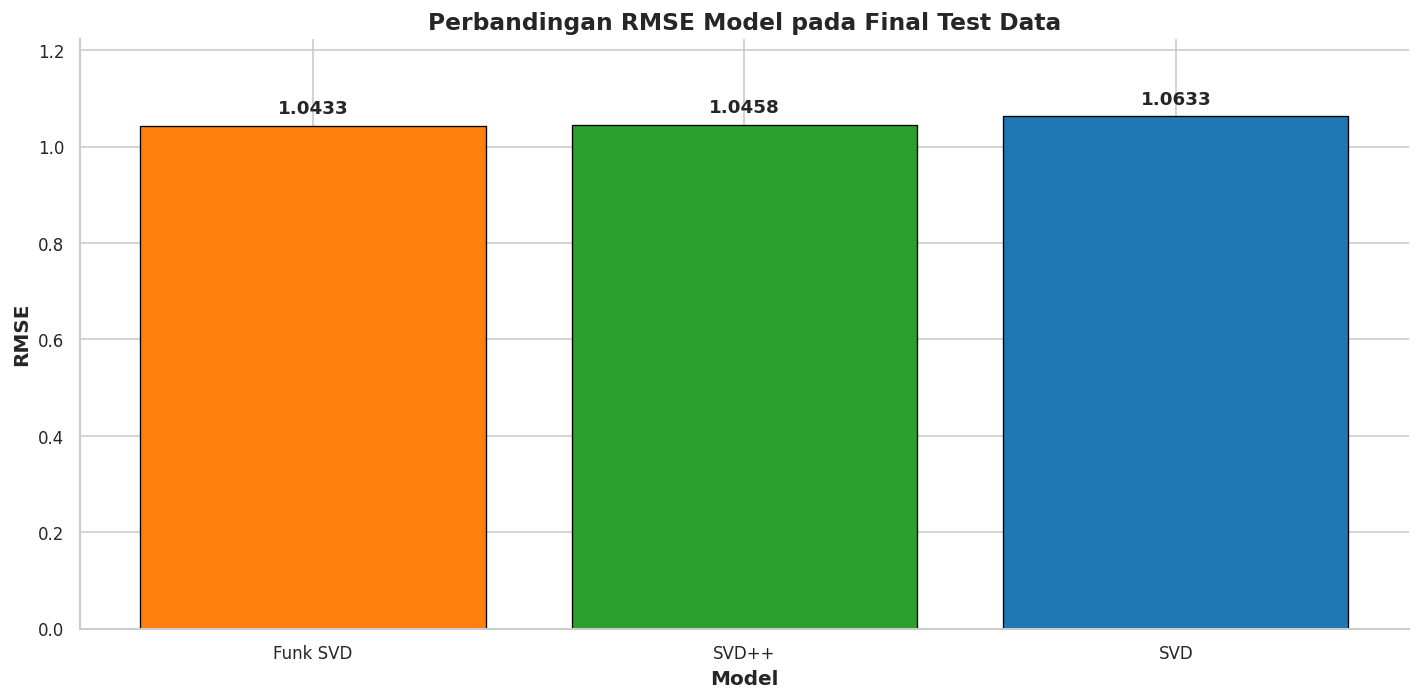

In [80]:
final_rmse_plot_data = (
    final_overall_results
    .sort_values("rmse")
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    final_rmse_plot_data["model"],
    final_rmse_plot_data["rmse"],
    color=[
        MODEL_COLORS[model]
        for model in final_rmse_plot_data[
            "model"
        ]
    ],
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in final_rmse_plot_data[
            "rmse"
        ]
    ],
    padding=5,
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Perbandingan RMSE Model pada Final Test Data"
)

ax.set_xlabel("Model")
ax.set_ylabel("RMSE")

ax.set_ylim(
    0,
    final_rmse_plot_data["rmse"].max()
    * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="34_Perbandingan_RMSE_Final.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.13 Visualisasi Perbandingan MAE Final**

Gambar berhasil disimpan: 35_Perbandingan_MAE_Final.png (91.43 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

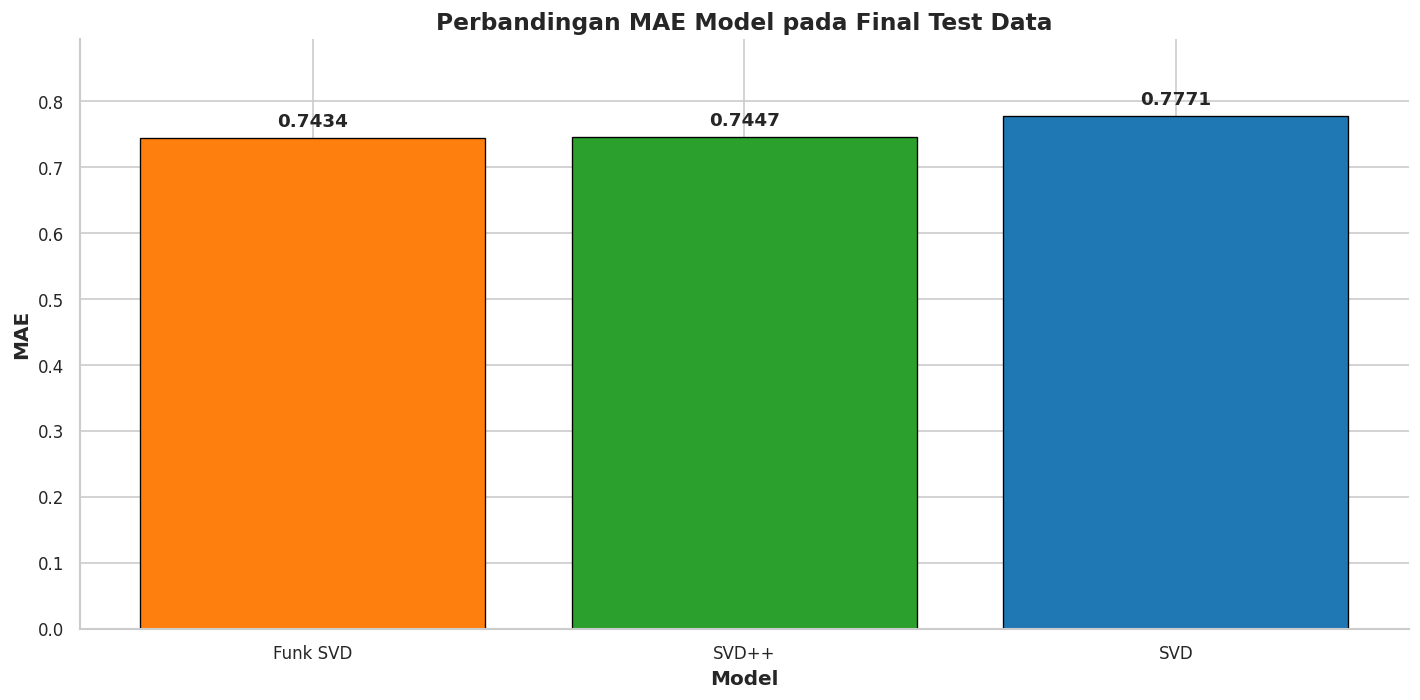

In [81]:
final_mae_plot_data = (
    final_overall_results
    .sort_values("mae")
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    final_mae_plot_data["model"],
    final_mae_plot_data["mae"],
    color=[
        MODEL_COLORS[model]
        for model in final_mae_plot_data[
            "model"
        ]
    ],
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in final_mae_plot_data[
            "mae"
        ]
    ],
    padding=5,
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Perbandingan MAE Model pada Final Test Data"
)

ax.set_xlabel("Model")
ax.set_ylabel("MAE")

ax.set_ylim(
    0,
    final_mae_plot_data["mae"].max()
    * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="35_Perbandingan_MAE_Final.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.14 Visualisasi RMSE Berdasarkan Kategori User**

Gambar berhasil disimpan: 36_RMSE_Berdasarkan_Kategori_User.png (255.29 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

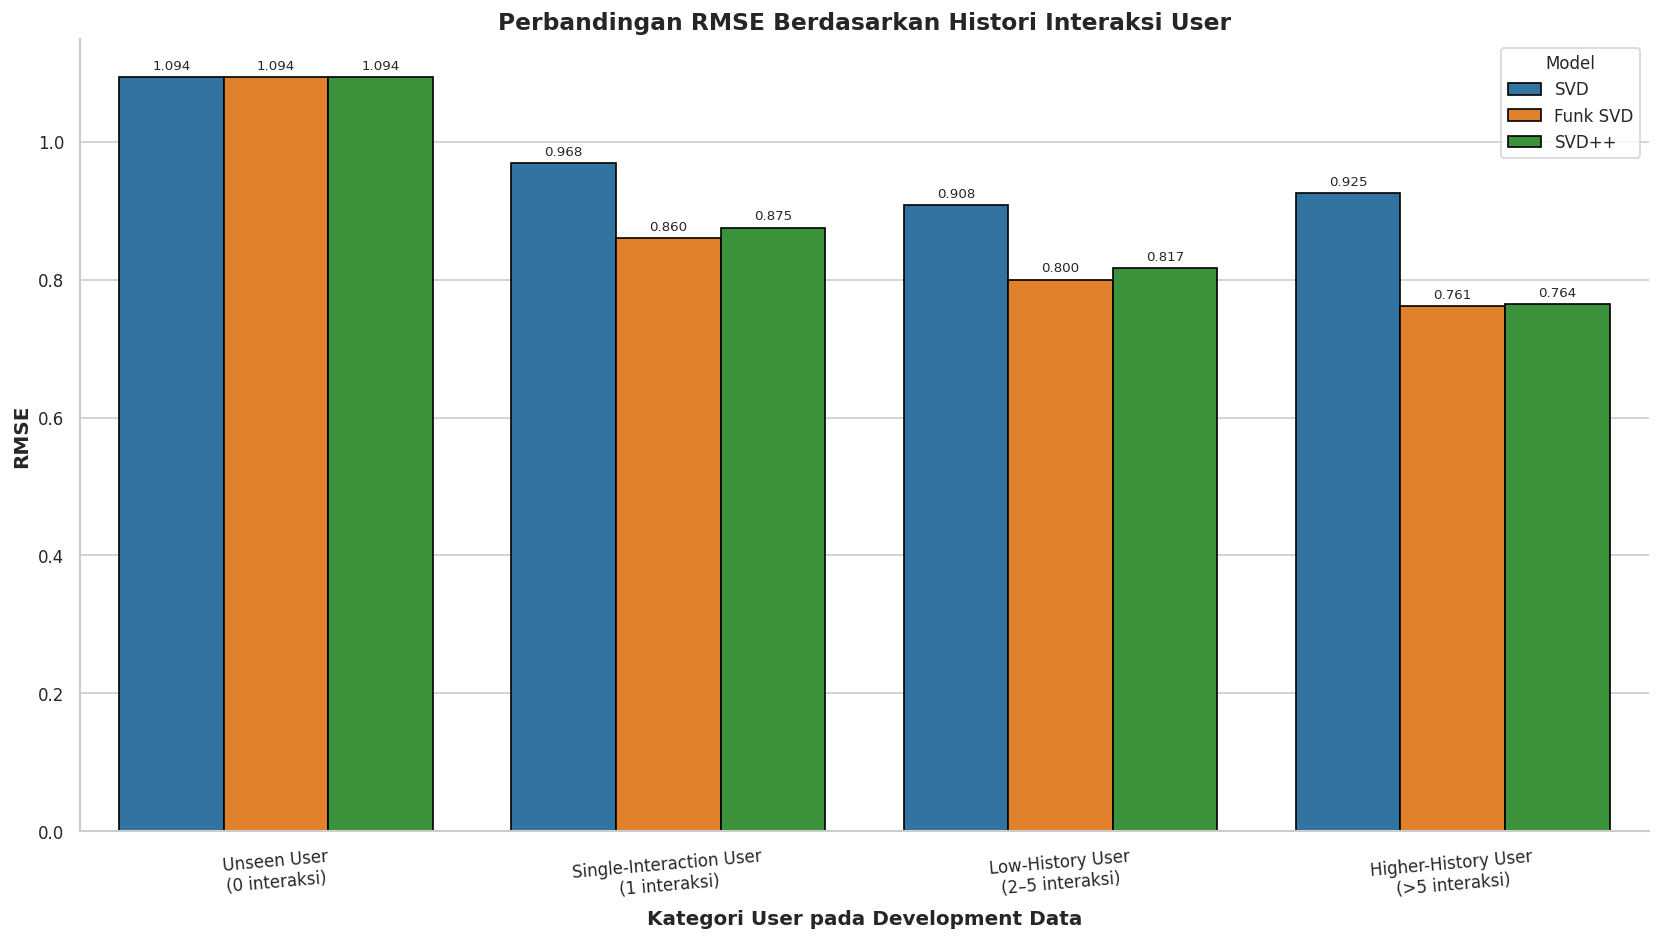

In [82]:
category_plot_data = (
    final_user_category_results
    .copy()
)

category_plot_data[
    "kategori_label"
] = (
    category_plot_data[
        "kategori_user"
    ]
    + "\n("
    + category_plot_data[
        "deskripsi_kategori"
    ].fillna("")
    + ")"
)

category_label_order = [
    (
        f"{category}\n"
        f"({USER_CATEGORY_LABELS[category]})"
    )
    for category in USER_CATEGORY_ORDER
]

fig, ax = plt.subplots(
    figsize=LARGE_FIGSIZE
)

sns.barplot(
    data=category_plot_data,
    x="kategori_label",
    y="rmse",
    hue="model",
    order=category_label_order,
    hue_order=[
        "SVD",
        "Funk SVD",
        "SVD++"
    ],
    palette=MODEL_COLORS,
    edgecolor="black",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8
    )

ax.set_title(
    "Perbandingan RMSE Berdasarkan Histori Interaksi User"
)

ax.set_xlabel("Kategori User pada Development Data")
ax.set_ylabel("RMSE")
ax.legend(title="Model")

plt.xticks(
    rotation=5,
    ha="center"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="36_RMSE_Berdasarkan_Kategori_User.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.15 Visualisasi MAE Berdasarkan Kategori User**

Gambar berhasil disimpan: 37_MAE_Berdasarkan_Kategori_User.png (255.85 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

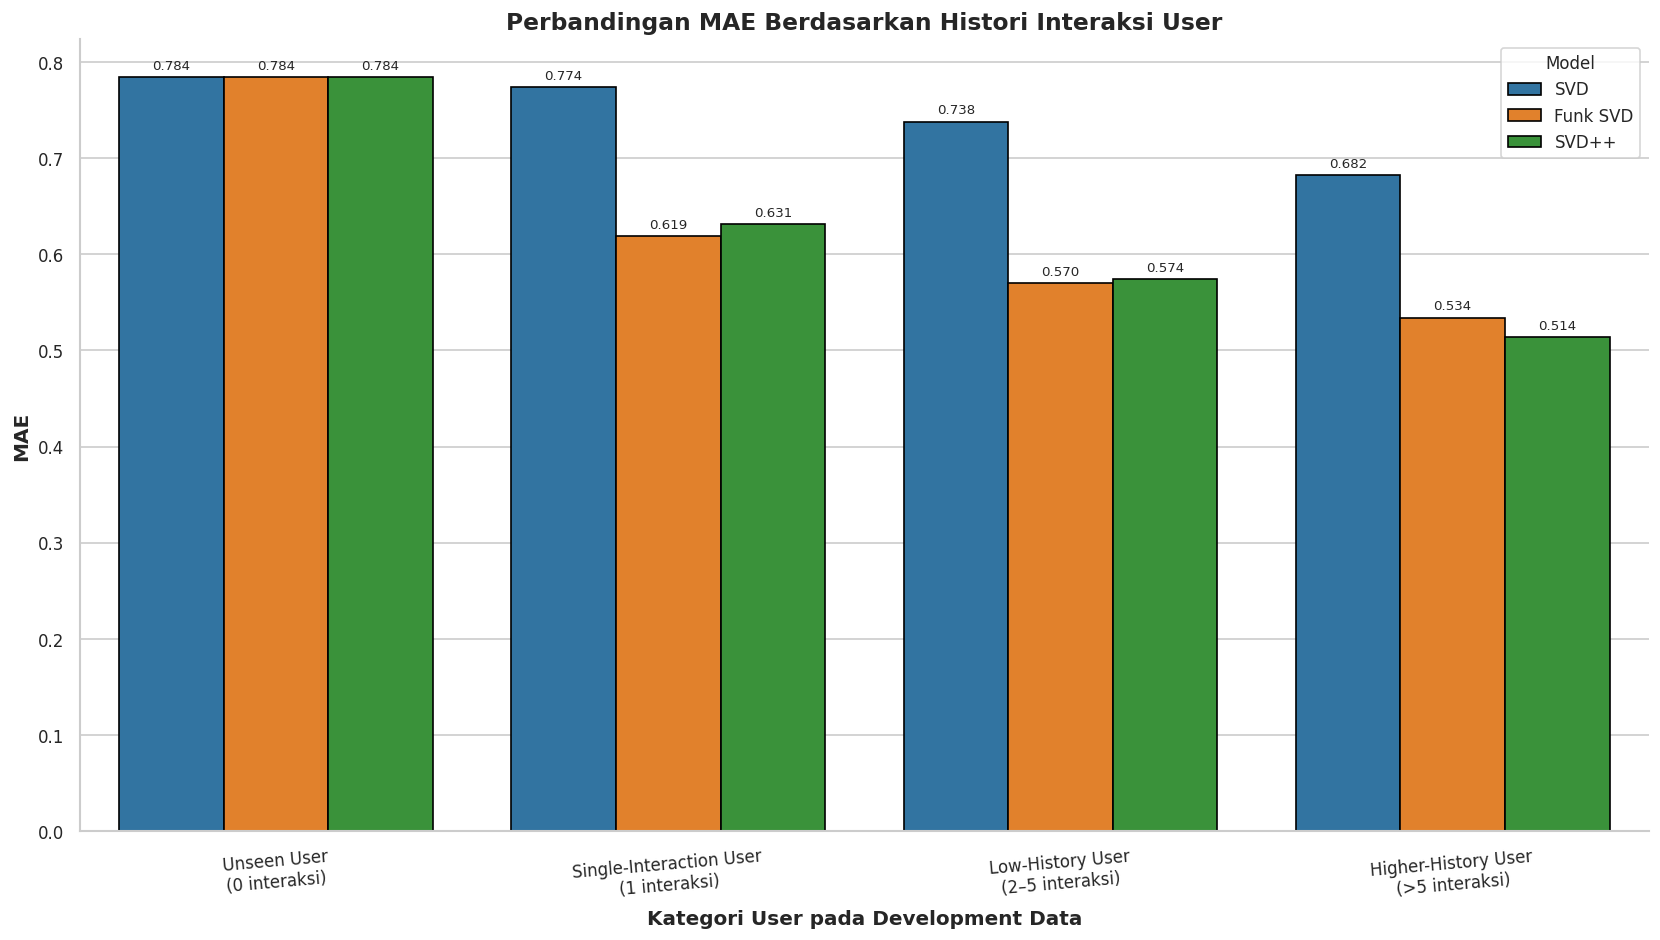

In [83]:
fig, ax = plt.subplots(
    figsize=LARGE_FIGSIZE
)

sns.barplot(
    data=category_plot_data,
    x="kategori_label",
    y="mae",
    hue="model",
    order=category_label_order,
    hue_order=[
        "SVD",
        "Funk SVD",
        "SVD++"
    ],
    palette=MODEL_COLORS,
    edgecolor="black",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=8
    )

ax.set_title(
    "Perbandingan MAE Berdasarkan Histori Interaksi User"
)

ax.set_xlabel("Kategori User pada Development Data")
ax.set_ylabel("MAE")
ax.legend(title="Model")

plt.xticks(
    rotation=5,
    ha="center"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="37_MAE_Berdasarkan_Kategori_User.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.16 Visualisasi Distribusi Sumber Prediksi**

Gambar berhasil disimpan: 38_Distribusi_Sumber_Prediksi_Final.png (194.23 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

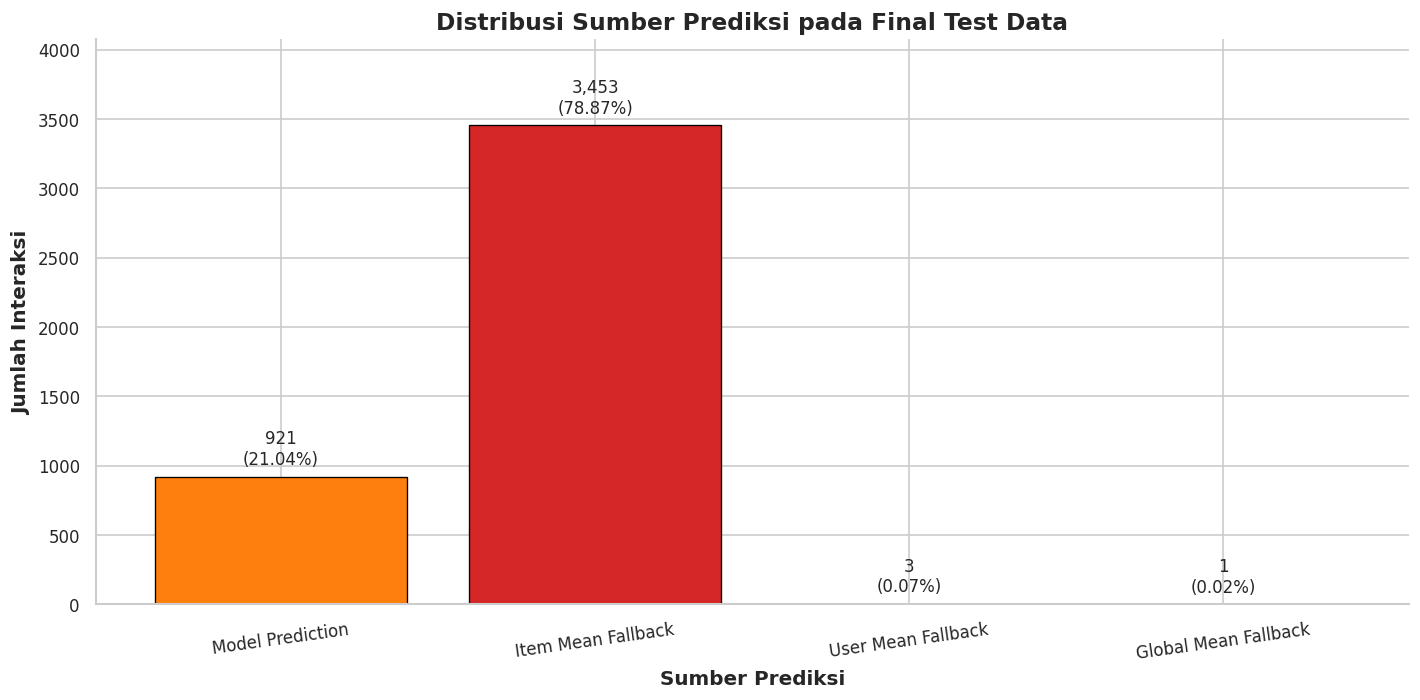

In [84]:
final_source_distribution = (
    final_svd_predictions[
        "prediction_source"
    ]
    .value_counts()
    .reindex(
        EXPECTED_PREDICTION_SOURCE_ORDER,
        fill_value=0
    )
    .rename("jumlah_prediksi")
    .reset_index()
    .rename(columns={
        "index": "prediction_source"
    })
)

final_source_distribution[
    "persentase_prediksi"
] = (
    final_source_distribution[
        "jumlah_prediksi"
    ]
    / len(final_svd_predictions)
    * 100
)

final_source_colors = {
    "Model Prediction": MODEL_COLORS["Funk SVD"],
    "Item Mean Fallback": "#D62728",
    "User Mean Fallback": "#FFBB78",
    "Global Mean Fallback": FALLBACK_COLOR
}

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    final_source_distribution[
        "prediction_source"
    ],
    final_source_distribution[
        "jumlah_prediksi"
    ],
    color=[
        final_source_colors[source]
        for source in final_source_distribution[
            "prediction_source"
        ]
    ],
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    bars,
    labels=[
        (
            f"{int(count):,}\n"
            f"({percentage:.2f}%)"
        )
        for count, percentage in zip(
            final_source_distribution[
                "jumlah_prediksi"
            ],
            final_source_distribution[
                "persentase_prediksi"
            ]
        )
    ],
    padding=5,
    fontsize=10
)

ax.set_title(
    "Distribusi Sumber Prediksi pada Final Test Data"
)

ax.set_xlabel("Sumber Prediksi")
ax.set_ylabel("Jumlah Interaksi")

maximum_source_count = (
    final_source_distribution[
        "jumlah_prediksi"
    ].max()
)

if maximum_source_count > 0:
    ax.set_ylim(
        0,
        maximum_source_count * 1.18
    )

plt.xticks(
    rotation=8,
    ha="center"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="38_Distribusi_Sumber_Prediksi_Final.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.17 Visualisasi RMSE Model Prediction Only**

Gambar berhasil disimpan: 39_RMSE_Model_Prediction_Only.png (104.77 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

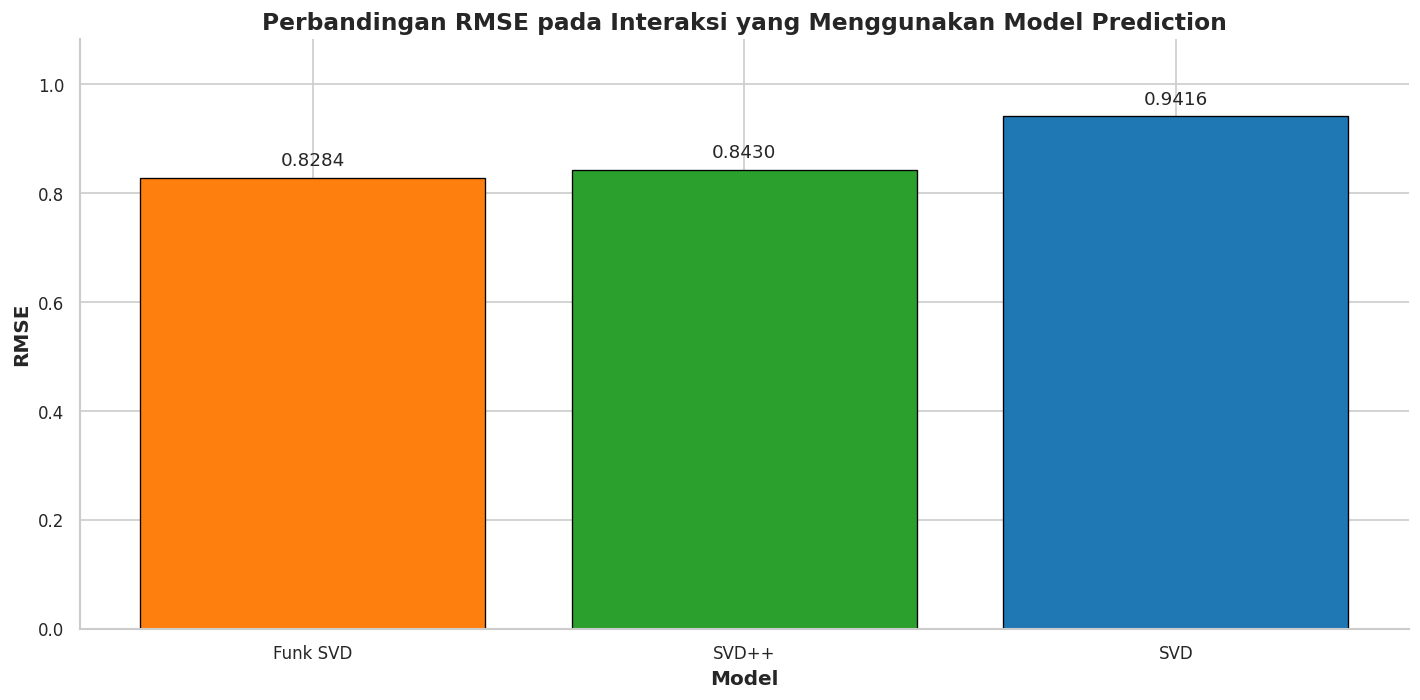

In [85]:
model_only_plot_data = (
    final_model_prediction_only_results
    .sort_values(
        "rmse_model_prediction"
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    model_only_plot_data["model"],
    model_only_plot_data[
        "rmse_model_prediction"
    ],
    color=[
        MODEL_COLORS[model]
        for model in model_only_plot_data[
            "model"
        ]
    ],
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in model_only_plot_data[
            "rmse_model_prediction"
        ]
    ],
    padding=5,
    fontsize=11
)

ax.set_title(
    "Perbandingan RMSE pada Interaksi yang Menggunakan Model Prediction"
)

ax.set_xlabel("Model")
ax.set_ylabel("RMSE")

ax.set_ylim(
    0,
    model_only_plot_data[
        "rmse_model_prediction"
    ].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="39_RMSE_Model_Prediction_Only.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.18 Visualisasi MAE Model Prediction Only**

Gambar berhasil disimpan: 40_MAE_Model_Prediction_Only.png (107.17 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

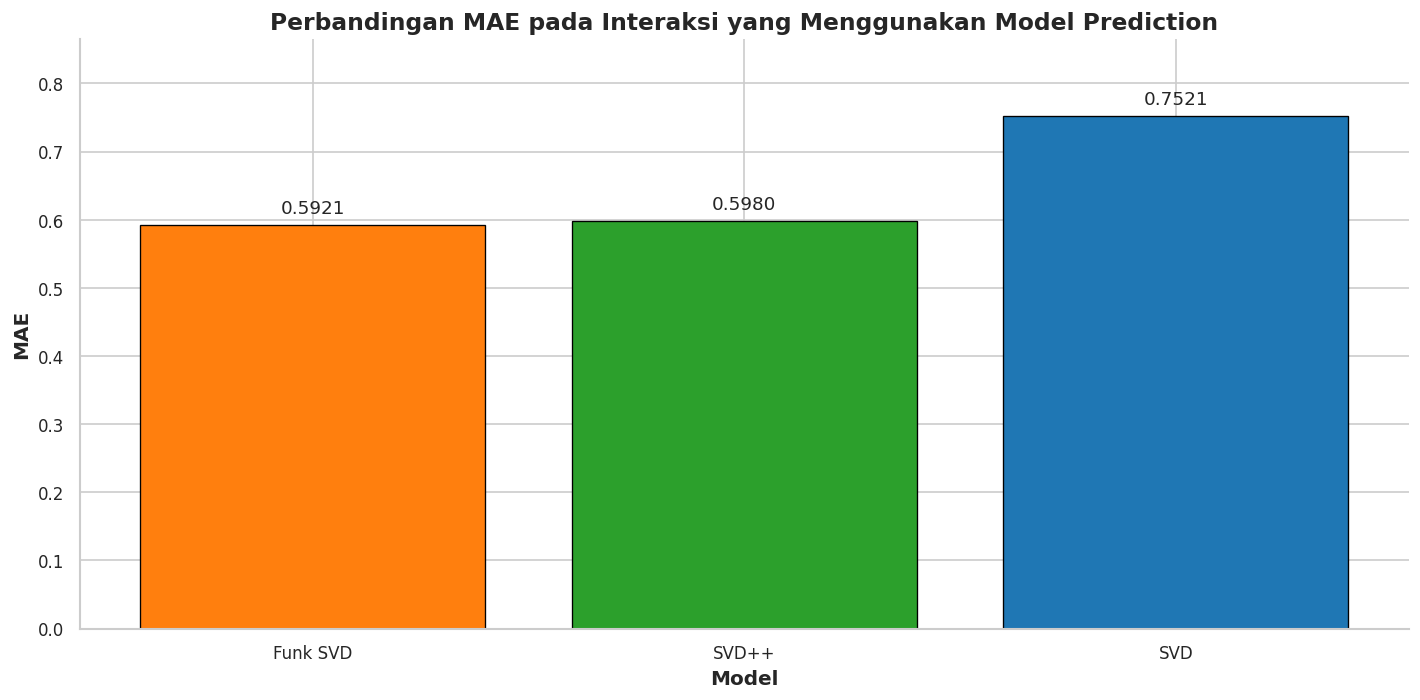

In [86]:
model_only_mae_plot_data = (
    final_model_prediction_only_results
    .sort_values(
        "mae_model_prediction"
    )
    .copy()
)

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

bars = ax.bar(
    model_only_mae_plot_data["model"],
    model_only_mae_plot_data[
        "mae_model_prediction"
    ],
    color=[
        MODEL_COLORS[model]
        for model in model_only_mae_plot_data[
            "model"
        ]
    ],
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in model_only_mae_plot_data[
            "mae_model_prediction"
        ]
    ],
    padding=5,
    fontsize=11
)

ax.set_title(
    "Perbandingan MAE pada Interaksi yang Menggunakan Model Prediction"
)

ax.set_xlabel("Model")
ax.set_ylabel("MAE")

ax.set_ylim(
    0,
    model_only_mae_plot_data[
        "mae_model_prediction"
    ].max() * 1.15
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="40_MAE_Model_Prediction_Only.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **3.19 Pemeriksaan Akhir Evaluasi Final**

In [87]:
# Setiap model harus memprediksi seluruh final test
assert len(final_svd_predictions) == len(
    final_test_data
), (
    "Jumlah prediksi final SVD tidak sesuai."
)

assert len(final_funk_svd_predictions) == len(
    final_test_data
), (
    "Jumlah prediksi final Funk SVD tidak sesuai."
)

assert len(final_svdpp_predictions) == len(
    final_test_data
), (
    "Jumlah prediksi final SVD++ tidak sesuai."
)


# Seluruh interaction ID harus unik pada tiap model
for model_name, prediction_data in (
    final_prediction_dictionary.items()
):

    assert (
        prediction_data[
            "interaction_id"
        ].nunique()
        == len(final_test_data)
    ), (
        f"Interaction ID prediksi {model_name} "
        "tidak lengkap atau tidak unik."
    )

    assert (
        prediction_data[
            "rating_prediction"
        ]
        .between(
            RATING_MIN,
            RATING_MAX
        )
        .all()
    ), (
        f"Terdapat prediksi {model_name} "
        "di luar skala rating."
    )

    assert (
        prediction_data[
            "prediction_source"
        ]
        .isin(
            EXPECTED_PREDICTION_SOURCE_ORDER
        )
        .all()
    ), (
        f"Terdapat sumber prediksi {model_name} "
        "yang tidak valid."
    )


# Memastikan sumber prediksi sama untuk semua model
assert (
    fallback_consistency_check[
        "prediction_source_consistent"
    ].all()
), (
    "Sumber prediksi antarmodel tidak konsisten."
)


# Memastikan nilai fallback sama
if len(fallback_rows) > 0:
    assert (
        fallback_rows[
            "fallback_value_consistent"
        ].all()
    ), (
        "Nilai fallback antarmodel tidak konsisten."
    )


# Memastikan hasil evaluasi lengkap
assert len(final_overall_results) == 3, (
    "Ringkasan final tidak memuat tiga model."
)

assert (
    final_overall_results[
        [
            "rmse",
            "mae"
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
), (
    "Terdapat nilai RMSE atau MAE final yang kosong."
)

assert BEST_MODEL_NAME in [
    "SVD",
    "Funk SVD",
    "SVD++"
], (
    "Model terbaik tidak valid."
)


print("=" * 80)
print("STEP 3 SELESAI")
print("=" * 80)

print(
    f"Model terbaik : "
    f"{BEST_MODEL_NAME}"
)

print(
    f"RMSE final    : "
    f"{best_final_result['rmse']:.6f}"
)

print(
    f"MAE final     : "
    f"{best_final_result['mae']:.6f}"
)

print(
    f"Jumlah final test: "
    f"{len(final_test_data):,}"
)

print(
    f"Prediksi menggunakan model: "
    f"{int(best_final_result['jumlah_model_prediction']):,} "
    f"({best_final_result['persentase_model_prediction']:.2f}%)"
)

print(
    f"Prediksi menggunakan fallback: "
    f"{int(best_final_result['jumlah_fallback_prediction']):,} "
    f"({best_final_result['persentase_fallback_prediction']:.2f}%)"
)

print()
print(
    "Model terbaik siap digunakan pada Step 4 "
    "untuk implementasi sistem rekomendasi."
)

STEP 3 SELESAI
Model terbaik : Funk SVD
RMSE final    : 1.043333
MAE final     : 0.743444
Jumlah final test: 4,378
Prediksi menggunakan model: 921 (21.04%)
Prediksi menggunakan fallback: 3,457 (78.96%)

Model terbaik siap digunakan pada Step 4 untuk implementasi sistem rekomendasi.


# **Implementasi Sistem Rekomendasi**

## **4.1 Konfigurasi Implementasi Sistem**

In [88]:
TOP_N_VALUES = [5, 10, 15, 20]
TOP_N_VALUES = sorted(set(TOP_N_VALUES))

MAX_TOP_N = max(TOP_N_VALUES)

IMPLEMENTATION_RANDOM_SEED = (
    RANDOM_STATE + 900_001
)

IMPLEMENTATION_USER_CATEGORY_ORDER = [
    "Single-Interaction User",
    "Low-History User",
    "Higher-History User"
]

IMPLEMENTATION_CATEGORY_DESCRIPTIONS = {
    "Single-Interaction User": "1 interaksi",
    "Low-History User": "2–5 interaksi",
    "Higher-History User": ">5 interaksi"
}

IMPLEMENTATION_CATEGORY_FILE_LABELS = {
    "Single-Interaction User": "Single_Interaction_User",
    "Low-History User": "Low_History_User",
    "Higher-History User": "Higher_History_User"
}

# Pengguna dapat diisi secara manual apabila diperlukan.
# Gunakan None agar sistem memilih user secara otomatis.
MANUAL_SAMPLE_USERS = {
    "Single-Interaction User": None,
    "Low-History User": None,
    "Higher-History User": None
}


# ------------------------------------------------------------
# Pemeriksaan model terbaik
# ------------------------------------------------------------

if "BEST_MODEL_NAME" not in globals():
    raise NameError(
        "BEST_MODEL_NAME belum tersedia. "
        "Pastikan Step 3 telah dijalankan."
    )

if BEST_MODEL_NAME not in [
    "SVD",
    "Funk SVD",
    "SVD++"
]:
    raise ValueError(
        f"Nama model terbaik tidak valid: {BEST_MODEL_NAME}"
    )


# ------------------------------------------------------------
# Menyusun konfigurasi model implementasi
# ------------------------------------------------------------

if BEST_MODEL_NAME == "SVD":

    implementation_hyperparameter = {
        "jumlah_komponen_atau_faktor": best_svd_k,
        "learning_rate": np.nan,
        "regularization": np.nan,
        "jumlah_epoch": np.nan
    }

elif BEST_MODEL_NAME == "Funk SVD":

    implementation_hyperparameter = {
        "jumlah_komponen_atau_faktor": (
            best_funk_n_factors
        ),
        "learning_rate": (
            best_funk_learning_rate
        ),
        "regularization": (
            best_funk_regularization
        ),
        "jumlah_epoch": (
            best_funk_n_epochs
        )
    }

else:

    implementation_hyperparameter = {
        "jumlah_komponen_atau_faktor": (
            best_svdpp_n_factors
        ),
        "learning_rate": (
            best_svdpp_learning_rate
        ),
        "regularization": (
            best_svdpp_regularization
        ),
        "jumlah_epoch": (
            best_svdpp_n_epochs
        )
    }


implementation_configuration = pd.DataFrame({
    "Komponen": [
        "Model implementasi",
        "Dataset training",
        "Jumlah interaksi training",
        "Jumlah user training",
        "Jumlah item training",
        "Jumlah komponen/faktor laten",
        "Learning rate",
        "Regularization",
        "Jumlah epoch",
        "Random seed",
        "Nilai Top-N",
        "Maksimum rekomendasi",
        "Kriteria item kandidat"
    ],
    "Nilai": [
        BEST_MODEL_NAME,
        "Seluruh dataset hasil praproses",
        len(dataset),
        dataset["user_id"].nunique(),
        dataset["place_id"].nunique(),
        implementation_hyperparameter[
            "jumlah_komponen_atau_faktor"
        ],
        implementation_hyperparameter[
            "learning_rate"
        ],
        implementation_hyperparameter[
            "regularization"
        ],
        implementation_hyperparameter[
            "jumlah_epoch"
        ],
        IMPLEMENTATION_RANDOM_SEED,
        str(TOP_N_VALUES),
        MAX_TOP_N,
        (
            "Tempat wisata yang belum pernah "
            "diberi rating oleh user"
        )
    ]
})

print("=" * 80)
print("KONFIGURASI IMPLEMENTASI SISTEM REKOMENDASI")
print("=" * 80)

print(f"Model terbaik : {BEST_MODEL_NAME}")
print(f"Top-N         : {TOP_N_VALUES}")
print(f"Training data : {len(dataset):,} interaksi")

display(implementation_configuration)

KONFIGURASI IMPLEMENTASI SISTEM REKOMENDASI
Model terbaik : Funk SVD
Top-N         : [5, 10, 15, 20]
Training data : 21,886 interaksi


,Komponen,Nilai
0,Model implementasi,Funk SVD
1,Dataset training,Seluruh dataset hasil praproses
2,Jumlah interaksi training,21886
3,Jumlah user training,18524
4,Jumlah item training,300
5,Jumlah komponen/faktor laten,50
6,Learning rate,0.010000
7,Regularization,0.100000
8,Jumlah epoch,100
9,Random seed,900043


## **4.2 Training Model Terbaik pada Seluruh Dataset**

In [89]:
implementation_training_start = (
    time.perf_counter()
)

# DataFrame kosong hanya digunakan sebagai placeholder
# karena fungsi persiapan sebelumnya memiliki parameter
# validation_data.
empty_validation_data = (
    dataset
    .iloc[0:0]
    .copy()
)


# ------------------------------------------------------------
# A. Training SVD
# ------------------------------------------------------------

if BEST_MODEL_NAME == "SVD":

    implementation_prepared_data = None

    implementation_model = (
        train_classical_svd(
            train_data=dataset,
            n_components=best_svd_k
        )
    )

    implementation_training_history = pd.DataFrame({
        "model": ["SVD"],
        "keterangan": [
            (
                "SVD klasik tidak menggunakan "
                "training berbasis epoch."
            )
        ],
        "jumlah_komponen_laten": [
            best_svd_k
        ]
    })


# ------------------------------------------------------------
# B. Training Funk SVD
# ------------------------------------------------------------

elif BEST_MODEL_NAME == "Funk SVD":

    implementation_prepared_data = (
        prepare_funk_svd_fold(
            train_data=dataset,
            validation_data=empty_validation_data,
            fold_number=-1
        )
    )

    (
        implementation_model,
        implementation_training_history
    ) = train_funk_svd_model(
        prepared_fold=implementation_prepared_data,
        n_factors=best_funk_n_factors,
        learning_rate=best_funk_learning_rate,
        regularization=best_funk_regularization,
        n_epochs=best_funk_n_epochs,
        random_seed=IMPLEMENTATION_RANDOM_SEED
    )

    implementation_training_history.insert(
        0,
        "model",
        "Funk SVD"
    )


# ------------------------------------------------------------
# C. Training SVD++
# ------------------------------------------------------------

else:

    implementation_prepared_data = (
        prepare_svdpp_fold(
            train_data=dataset,
            validation_data=empty_validation_data,
            fold_number=-1
        )
    )

    (
        implementation_model,
        implementation_training_history
    ) = train_svdpp_model(
        prepared_fold=implementation_prepared_data,
        n_factors=best_svdpp_n_factors,
        learning_rate=best_svdpp_learning_rate,
        regularization=best_svdpp_regularization,
        n_epochs=best_svdpp_n_epochs,
        random_seed=IMPLEMENTATION_RANDOM_SEED
    )

    implementation_training_history.insert(
        0,
        "model",
        "SVD++"
    )


implementation_training_time = (
    time.perf_counter()
    - implementation_training_start
)


# ------------------------------------------------------------
# Ringkasan hasil training
# ------------------------------------------------------------

implementation_training_summary = pd.DataFrame({
    "Metrik": [
        "Model",
        "Jumlah interaksi training",
        "Jumlah user training",
        "Jumlah item training",
        "Global mean training",
        "Waktu training detik",
        "Waktu training"
    ],
    "Nilai": [
        BEST_MODEL_NAME,
        implementation_model[
            "number_of_train_interactions"
        ],
        implementation_model[
            "number_of_train_users"
        ],
        implementation_model[
            "number_of_train_items"
        ],
        implementation_model[
            "global_mean"
        ],
        implementation_training_time,
        format_execution_time(
            implementation_training_time
        )
    ]
})


print("=" * 80)
print("TRAINING MODEL IMPLEMENTASI SELESAI")
print("=" * 80)

print(f"Model          : {BEST_MODEL_NAME}")
print(
    f"Jumlah training: "
    f"{implementation_model['number_of_train_interactions']:,}"
)
print(
    f"Waktu training : "
    f"{format_execution_time(implementation_training_time)}"
)

display(implementation_training_summary)

TRAINING MODEL IMPLEMENTASI SELESAI
Model          : Funk SVD
Jumlah training: 21,886
Waktu training : 0.52 detik


,Metrik,Nilai
0,Model,Funk SVD
1,Jumlah interaksi training,21886
2,Jumlah user training,18524
3,Jumlah item training,300
4,Global mean training,4.350178
5,Waktu training detik,0.520397
6,Waktu training,0.52 detik


## **4.3 Pembentukan Profil User dan Item**

In [90]:
# ------------------------------------------------------------
# A. Profil user
# ------------------------------------------------------------

implementation_user_profile = (
    dataset
    .groupby("user_id")
    .agg(
        jumlah_interaksi=(
            "interaction_id",
            "count"
        ),
        rata_rata_rating=(
            "rating",
            "mean"
        ),
        rating_minimum=(
            "rating",
            "min"
        ),
        rating_maksimum=(
            "rating",
            "max"
        ),
        tanggal_interaksi_pertama=(
            "review_date",
            "min"
        ),
        tanggal_interaksi_terakhir=(
            "review_date",
            "max"
        ),
        jumlah_sumber_data=(
            "source",
            "nunique"
        )
    )
    .reset_index()
)

implementation_user_profile[
    "kategori_user"
] = (
    implementation_user_profile[
        "jumlah_interaksi"
    ]
    .apply(classify_user_history)
)

implementation_user_profile[
    "kategori_user"
] = pd.Categorical(
    implementation_user_profile[
        "kategori_user"
    ],
    categories=IMPLEMENTATION_USER_CATEGORY_ORDER,
    ordered=True
)


# ------------------------------------------------------------
# B. Profil item
# ------------------------------------------------------------

implementation_item_profile = (
    dataset
    .groupby(
        [
            "place_id",
            "place_name"
        ]
    )
    .agg(
        jumlah_rating_item=(
            "interaction_id",
            "count"
        ),
        rata_rata_rating_item=(
            "rating",
            "mean"
        ),
        rating_minimum_item=(
            "rating",
            "min"
        ),
        rating_maksimum_item=(
            "rating",
            "max"
        ),
        tanggal_rating_terakhir=(
            "review_date",
            "max"
        ),
        jumlah_sumber_item=(
            "source",
            "nunique"
        )
    )
    .reset_index()
)

implementation_item_profile[
    "item_idx_global"
] = (
    implementation_item_profile[
        "place_id"
    ]
    .map(item_to_global_idx)
)

implementation_item_profile = (
    implementation_item_profile
    .sort_values(
        [
            "jumlah_rating_item",
            "place_name"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# C. Distribusi kategori user
# ------------------------------------------------------------

implementation_user_category_distribution = (
    implementation_user_profile
    .groupby(
        "kategori_user",
        observed=False
    )
    .agg(
        jumlah_user=(
            "user_id",
            "nunique"
        ),
        total_interaksi=(
            "jumlah_interaksi",
            "sum"
        ),
        minimum_interaksi=(
            "jumlah_interaksi",
            "min"
        ),
        median_interaksi=(
            "jumlah_interaksi",
            "median"
        ),
        maksimum_interaksi=(
            "jumlah_interaksi",
            "max"
        )
    )
    .reset_index()
)

implementation_user_category_distribution[
    "persentase_user"
] = (
    implementation_user_category_distribution[
        "jumlah_user"
    ]
    / len(implementation_user_profile)
    * 100
)

implementation_user_category_distribution[
    "deskripsi_kategori"
] = (
    implementation_user_category_distribution[
        "kategori_user"
    ]
    .astype("string")
    .map(
        IMPLEMENTATION_CATEGORY_DESCRIPTIONS
    )
)


display(
    implementation_user_category_distribution
)

,kategori_user,jumlah_user,total_interaksi,minimum_interaksi,median_interaksi,maksimum_interaksi,persentase_user,deskripsi_kategori
0,Single-Interaction User,16650,16650,1,1.000000,1,89.883395,1 interaksi
1,Low-History User,1759,4269,2,2.000000,5,9.495789,2–5 interaksi
2,Higher-History User,115,967,6,7.000000,33,0.620816,>5 interaksi


## **4.4 Pemilihan Pengguna Sampel**

In [91]:
def select_representative_user(
    user_profile: pd.DataFrame,
    category_name: str,
    manual_user_id: Optional[str] = None,
    random_seed: int = RANDOM_STATE
) -> Dict[str, Any]:
    """
    Memilih satu user representatif dalam suatu kategori.

    Pemilihan otomatis:
    1. Menghitung median jumlah interaksi kategori.
    2. Memilih user dengan jumlah interaksi paling dekat
       dengan median.
    3. Jika kandidat lebih dari satu, dipilih secara acak
       menggunakan random seed yang tetap.
    """

    category_data = (
        user_profile[
            user_profile[
                "kategori_user"
            ].astype(str) == category_name
        ]
        .copy()
        .reset_index(drop=True)
    )

    if category_data.empty:
        raise ValueError(
            f"Tidak terdapat user pada kategori "
            f"'{category_name}'."
        )


    # --------------------------------------------------------
    # A. Pemilihan user manual
    # --------------------------------------------------------

    if manual_user_id is not None:

        manual_user_id = str(
            manual_user_id
        )

        manual_match = category_data[
            category_data["user_id"].astype(str)
            == manual_user_id
        ]

        if manual_match.empty:
            raise ValueError(
                f"User '{manual_user_id}' tidak ditemukan "
                f"pada kategori '{category_name}'."
            )

        selected_row = (
            manual_match
            .iloc[0]
            .copy()
        )

        selection_method = (
            "Dipilih secara manual"
        )

        target_interaction_count = int(
            selected_row["jumlah_interaksi"]
        )


    # --------------------------------------------------------
    # B. Pemilihan user otomatis
    # --------------------------------------------------------

    else:

        category_median = float(
            category_data[
                "jumlah_interaksi"
            ].median()
        )

        category_data[
            "selisih_dari_median"
        ] = (
            category_data[
                "jumlah_interaksi"
            ]
            - category_median
        ).abs()

        minimum_difference = (
            category_data[
                "selisih_dari_median"
            ].min()
        )

        candidate_users = (
            category_data[
                category_data[
                    "selisih_dari_median"
                ] == minimum_difference
            ]
            .sort_values("user_id")
            .reset_index(drop=True)
        )

        category_seed_offset = (
            IMPLEMENTATION_USER_CATEGORY_ORDER
            .index(category_name)
            * 1_000
        )

        random_generator = (
            np.random.default_rng(
                random_seed
                + category_seed_offset
            )
        )

        selected_position = int(
            random_generator.integers(
                low=0,
                high=len(candidate_users)
            )
        )

        selected_row = (
            candidate_users
            .iloc[selected_position]
            .copy()
        )

        selection_method = (
            "Otomatis: jumlah interaksi paling "
            "dekat dengan median kategori"
        )

        target_interaction_count = (
            category_median
        )


    result = {
        "user_id": str(
            selected_row["user_id"]
        ),
        "kategori_user": category_name,
        "deskripsi_kategori": (
            IMPLEMENTATION_CATEGORY_DESCRIPTIONS[
                category_name
            ]
        ),
        "jumlah_interaksi": int(
            selected_row["jumlah_interaksi"]
        ),
        "target_median_interaksi": (
            target_interaction_count
        ),
        "rata_rata_rating": float(
            selected_row["rata_rata_rating"]
        ),
        "rating_minimum": float(
            selected_row["rating_minimum"]
        ),
        "rating_maksimum": float(
            selected_row["rating_maksimum"]
        ),
        "tanggal_interaksi_pertama": (
            selected_row[
                "tanggal_interaksi_pertama"
            ]
        ),
        "tanggal_interaksi_terakhir": (
            selected_row[
                "tanggal_interaksi_terakhir"
            ]
        ),
        "metode_pemilihan": (
            selection_method
        )
    }

    return result


# ------------------------------------------------------------
# Memilih satu user dari setiap kategori
# ------------------------------------------------------------

selected_user_records = []

for category_name in (
    IMPLEMENTATION_USER_CATEGORY_ORDER
):

    selected_user = select_representative_user(
        user_profile=implementation_user_profile,
        category_name=category_name,
        manual_user_id=(
            MANUAL_SAMPLE_USERS[
                category_name
            ]
        ),
        random_seed=RANDOM_STATE
    )

    selected_user_records.append(
        selected_user
    )


selected_users = pd.DataFrame(
    selected_user_records
)

selected_users.insert(
    0,
    "nomor_sampel",
    np.arange(
        1,
        len(selected_users) + 1
    )
)


# ------------------------------------------------------------
# Riwayat interaksi pengguna terpilih
# ------------------------------------------------------------

selected_user_ids = (
    selected_users["user_id"]
    .astype(str)
    .tolist()
)

selected_user_category_map = dict(
    zip(
        selected_users["user_id"],
        selected_users["kategori_user"]
    )
)

selected_user_history = (
    dataset[
        dataset["user_id"].astype(str)
        .isin(selected_user_ids)
    ]
    .copy()
)

selected_user_history[
    "kategori_user"
] = (
    selected_user_history["user_id"]
    .astype(str)
    .map(selected_user_category_map)
)

selected_user_history = (
    selected_user_history
    .sort_values(
        [
            "kategori_user",
            "review_date",
            "place_name"
        ]
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("PENGGUNA SAMPEL IMPLEMENTASI")
print("=" * 80)

display(selected_users)

print()
print("Riwayat interaksi pengguna sampel:")

display(
    selected_user_history[
        [
            "user_id",
            "kategori_user",
            "place_id",
            "place_name",
            "rating",
            "review_date",
            "source"
        ]
    ]
)

PENGGUNA SAMPEL IMPLEMENTASI


,nomor_sampel,user_id,kategori_user,deskripsi_kategori,jumlah_interaksi,target_median_interaksi,rata_rata_rating,rating_minimum,rating_maksimum,tanggal_interaksi_pertama,tanggal_interaksi_terakhir,metode_pemilihan
0,1,101739567581222496344,Single-Interaction User,1 interaksi,1,1.000000,5.000000,5.000000,5.000000,2025-10-13,2025-10-13,Otomatis: jumlah interaksi paling dekat dengan median kategori
1,2,433B6699172110BFFACB1B0F651C2C61,Low-History User,2–5 interaksi,2,2.000000,4.000000,3.000000,5.000000,2023-11-21,2023-11-21,Otomatis: jumlah interaksi paling dekat dengan median kategori
2,3,A06989A0D1683362160EDF4A662EBD56,Higher-History User,>5 interaksi,7,7.000000,4.571429,4.000000,5.000000,2023-09-29,2024-11-29,Otomatis: jumlah interaksi paling dekat dengan median kategori



Riwayat interaksi pengguna sampel:


,user_id,kategori_user,place_id,place_name,rating,review_date,source
0,A06989A0D1683362160EDF4A662EBD56,Higher-History User,592897,Goa Lawah Temple,5,2023-09-29,Tripadvisor
1,A06989A0D1683362160EDF4A662EBD56,Higher-History User,379340,Tanah Lot,5,2023-09-30,Tripadvisor
2,A06989A0D1683362160EDF4A662EBD56,Higher-History User,ChIJqfTkrG4Z0i0RGTQM35oWGTM,Penglipuran Village,4,2024-11-28,Tripadvisor
3,A06989A0D1683362160EDF4A662EBD56,Higher-History User,ChIJs1vLBTlA0i0RQbKxRDweyHE,Sanur Beach,4,2024-11-28,Tripadvisor
4,A06989A0D1683362160EDF4A662EBD56,Higher-History User,1994602,Sindhu Night Market,5,2024-11-28,Tripadvisor
5,A06989A0D1683362160EDF4A662EBD56,Higher-History User,4036213,Tamblingan Lake,5,2024-11-28,Tripadvisor
6,A06989A0D1683362160EDF4A662EBD56,Higher-History User,447061,Ulun Danu Bratan,4,2024-11-29,Tripadvisor
7,433B6699172110BFFACB1B0F651C2C61,Low-History User,15142231,Pantai Diamond,5,2023-11-21,Tripadvisor
8,433B6699172110BFFACB1B0F651C2C61,Low-History User,ChIJYfEnJEV30i0RS9pcaNa604M,Teletubbies Hill,3,2023-11-21,Tripadvisor
9,101739567581222496344,Single-Interaction User,ChIJvQLkUeF90S0RD24qjJr_ytQ,Rambut Siwi Temple,5,2025-10-13,Google Review


## **4.5 Fungsi Prediksi Kandidat Rekomendasi**

In [92]:
def score_unrated_items_for_user(
    model_name: str,
    model: Dict[str, Any],
    user_id: str,
    item_profile: pd.DataFrame,
    interaction_data: pd.DataFrame
) -> pd.DataFrame:
    """
    Menghitung prediksi seluruh item yang belum pernah
    diberi rating oleh user.

    Fungsi hanya digunakan setelah model dilatih menggunakan
    seluruh dataset, sehingga user dan seluruh item kandidat
    diharapkan tersedia dalam model.
    """

    user_id = str(user_id)

    user_to_local_index = (
        model["user_to_local_index"]
    )

    item_to_local_index = (
        model["item_to_local_index"]
    )


    # --------------------------------------------------------
    # A. Validasi user
    # --------------------------------------------------------

    if user_id not in user_to_local_index:
        raise KeyError(
            f"User '{user_id}' tidak terdapat "
            "dalam model implementasi."
        )


    # --------------------------------------------------------
    # B. Mengambil item yang sudah diberi rating
    # --------------------------------------------------------

    interacted_item_ids = set(
        interaction_data.loc[
            interaction_data["user_id"].astype(str)
            == user_id,
            "place_id"
        ]
        .astype(str)
        .tolist()
    )


    # --------------------------------------------------------
    # C. Membentuk item kandidat
    # --------------------------------------------------------

    candidate_items = (
        item_profile[
            ~item_profile[
                "place_id"
            ]
            .astype(str)
            .isin(interacted_item_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Menjaga hanya item yang terdapat dalam model
    candidate_items = (
        candidate_items[
            candidate_items[
                "place_id"
            ].astype(str)
            .isin(item_to_local_index)
        ]
        .copy()
        .reset_index(drop=True)
    )

    if candidate_items.empty:
        raise ValueError(
            f"Tidak terdapat item kandidat untuk user "
            f"'{user_id}'."
        )


    # --------------------------------------------------------
    # D. Mapping indeks lokal
    # --------------------------------------------------------

    user_local_index = int(
        user_to_local_index[user_id]
    )

    candidate_local_item_indices = (
        candidate_items["place_id"]
        .astype(str)
        .map(item_to_local_index)
        .to_numpy(dtype=np.int64)
    )

    global_mean = float(
        model["global_mean"]
    )


    # --------------------------------------------------------
    # E. Prediksi SVD
    # --------------------------------------------------------

    if model_name == "SVD":

        user_latent_vector = (
            model["U"][
                user_local_index,
                :
            ]
            * model[
                "singular_values"
            ]
        )

        predicted_ratings = (
            global_mean
            + np.dot(
                user_latent_vector,
                model["Vt"][
                    :,
                    candidate_local_item_indices
                ]
            )
        )


    # --------------------------------------------------------
    # F. Prediksi Funk SVD
    # --------------------------------------------------------

    elif model_name == "Funk SVD":

        user_latent_vector = (
            model["user_factors"][
                user_local_index
            ]
        )

        predicted_ratings = (
            global_mean
            + model["user_bias"][
                user_local_index
            ]
            + model["item_bias"][
                candidate_local_item_indices
            ]
            + np.dot(
                model["item_factors"][
                    candidate_local_item_indices
                ],
                user_latent_vector
            )
        )


    # --------------------------------------------------------
    # G. Prediksi SVD++
    # --------------------------------------------------------

    elif model_name == "SVD++":

        extended_user_vector = (
            model["user_factors"][
                user_local_index
            ]
            + model[
                "implicit_user_vectors"
            ][
                user_local_index
            ]
        )

        predicted_ratings = (
            global_mean
            + model["user_bias"][
                user_local_index
            ]
            + model["item_bias"][
                candidate_local_item_indices
            ]
            + np.dot(
                model["item_factors"][
                    candidate_local_item_indices
                ],
                extended_user_vector
            )
        )


    else:
        raise ValueError(
            f"Model tidak dikenali: {model_name}"
        )


    # --------------------------------------------------------
    # H. Finalisasi hasil prediksi
    # --------------------------------------------------------

    candidate_items[
        "rating_prediction"
    ] = clip_rating(
        predicted_ratings
    )

    candidate_items["user_id"] = (
        user_id
    )

    candidate_items["model"] = (
        model_name
    )

    candidate_items[
        "prediction_source"
    ] = "Model Prediction"

    user_interaction_count = int(
        (
            interaction_data["user_id"]
            .astype(str)
            == user_id
        ).sum()
    )

    user_category = classify_user_history(
        user_interaction_count
    )

    candidate_items[
        "jumlah_interaksi_user"
    ] = user_interaction_count

    candidate_items[
        "kategori_user"
    ] = user_category

    candidate_items[
        "jumlah_item_sudah_diberi_rating"
    ] = len(interacted_item_ids)

    candidate_items[
        "jumlah_item_kandidat"
    ] = len(candidate_items)


    # --------------------------------------------------------
    # I. Ranking rekomendasi
    # --------------------------------------------------------

    candidate_items = (
        candidate_items
        .sort_values(
            by=[
                "rating_prediction",
                "place_name",
                "place_id"
            ],
            ascending=[
                False,
                True,
                True
            ]
        )
        .reset_index(drop=True)
    )

    candidate_items.insert(
        0,
        "ranking",
        np.arange(
            1,
            len(candidate_items) + 1
        )
    )

    for top_n in TOP_N_VALUES:

        candidate_items[
            f"masuk_top_{top_n}"
        ] = (
            candidate_items["ranking"]
            <= top_n
        )

    return candidate_items

## **4.6 Menghasilkan Rekomendasi Top-N**

In [93]:
all_candidate_prediction_records = []
top_20_recommendation_records = []

recommendation_generation_start = (
    time.perf_counter()
)


for _, selected_user in selected_users.iterrows():

    user_id = str(
        selected_user["user_id"]
    )

    user_predictions = (
        score_unrated_items_for_user(
            model_name=BEST_MODEL_NAME,
            model=implementation_model,
            user_id=user_id,
            item_profile=implementation_item_profile,
            interaction_data=dataset
        )
    )

    all_candidate_prediction_records.append(
        user_predictions
    )

    top_user_recommendations = (
        user_predictions
        .head(MAX_TOP_N)
        .copy()
    )

    top_20_recommendation_records.append(
        top_user_recommendations
    )


all_candidate_predictions = pd.concat(
    all_candidate_prediction_records,
    ignore_index=True
)

top_20_recommendations = pd.concat(
    top_20_recommendation_records,
    ignore_index=True
)


recommendation_generation_time = (
    time.perf_counter()
    - recommendation_generation_start
)


# ------------------------------------------------------------
# Membentuk Top-5, Top-10, Top-15, dan Top-20
# ------------------------------------------------------------

top_n_recommendation_tables = {}

top_n_long_records = []

for top_n in TOP_N_VALUES:

    top_n_data = (
        top_20_recommendations[
            top_20_recommendations[
                "ranking"
            ] <= top_n
        ]
        .copy()
        .sort_values(
            [
                "kategori_user",
                "ranking"
            ]
        )
        .reset_index(drop=True)
    )

    top_n_recommendation_tables[
        f"Top {top_n}"
    ] = top_n_data

    top_n_long_data = (
        top_n_data.copy()
    )

    top_n_long_data.insert(
        0,
        "top_n",
        top_n
    )

    top_n_long_records.append(
        top_n_long_data
    )


top_n_recommendations_long = pd.concat(
    top_n_long_records,
    ignore_index=True
)


# ------------------------------------------------------------
# Ringkasan deskriptif Top-N
# ------------------------------------------------------------

top_n_descriptive_summary = (
    top_n_recommendations_long
    .groupby(
        [
            "model",
            "user_id",
            "kategori_user",
            "top_n"
        ],
        as_index=False
    )
    .agg(
        jumlah_rekomendasi=(
            "place_id",
            "count"
        ),
        prediksi_rating_tertinggi=(
            "rating_prediction",
            "max"
        ),
        prediksi_rating_terendah=(
            "rating_prediction",
            "min"
        ),
        rata_rata_prediksi_rating=(
            "rating_prediction",
            "mean"
        )
    )
)


print("=" * 80)
print("REKOMENDASI TOP-N BERHASIL DIHASILKAN")
print("=" * 80)

print(f"Model          : {BEST_MODEL_NAME}")
print(
    f"Jumlah user    : "
    f"{selected_users['user_id'].nunique()}"
)
print(f"Top-N          : {TOP_N_VALUES}")
print(
    f"Waktu generate : "
    f"{format_execution_time(recommendation_generation_time)}"
)

display(
    top_20_recommendations[
        [
            "ranking",
            "user_id",
            "kategori_user",
            "place_id",
            "place_name",
            "rating_prediction",
            "jumlah_rating_item",
            "rata_rata_rating_item"
        ]
    ]
)

REKOMENDASI TOP-N BERHASIL DIHASILKAN
Model          : Funk SVD
Jumlah user    : 3
Top-N          : [5, 10, 15, 20]
Waktu generate : 0.05 detik


,ranking,user_id,kategori_user,place_id,place_name,rating_prediction,jumlah_rating_item,rata_rata_rating_item
0,1,101739567581222496344,Single-Interaction User,1793975,Bali Zoo,5.000000,160,4.962500
1,2,101739567581222496344,Single-Interaction User,ChIJZ8hawhKD0S0RJiS_lwHbBVM,Brahmavihara-Arama,5.000000,100,4.910000
2,3,101739567581222496344,Single-Interaction User,ChIJ8WV6yfgZ0i0RLNelt6XX4d4,Grudugan waterfall,5.000000,100,4.970000
3,4,101739567581222496344,Single-Interaction User,ChIJL9VpEnsn0i0RyFAndDrB71g,Jatiluwih Bee Honey Farm (Bee Honey Farm Tourism & Education),5.000000,32,4.968750
4,5,101739567581222496344,Single-Interaction User,1230139,Museum PASIFIKA,5.000000,80,4.975000
5,6,101739567581222496344,Single-Interaction User,ChIJqZoIJwCP0S0R4K5Qe0NhZkQ,Pucak manik waterfall,5.000000,55,5.000000
6,7,101739567581222496344,Single-Interaction User,ChIJLzSSUl0F0i0ROhndR49Hzbc,Museum Sang Hyang Dedari,4.986725,5,5.000000
7,8,101739567581222496344,Single-Interaction User,ChIJqZ1qazQ_0i0RlSSmznZwXpE,CitraLand Waterpark Denpasar,4.980502,107,4.813084
8,9,101739567581222496344,Single-Interaction User,ChIJKTzCu51d0S0R45V7bBGJRwc,Tourist Information Centre Desa Wisata Blimbingsari,4.976656,7,5.000000
9,10,101739567581222496344,Single-Interaction User,13137474,Nyang Nyang Paragliding,4.972587,3,5.000000


## **4.7 Pemeriksaan Item yang Sudah Diberi Rating**

In [94]:
recommendation_validation_records = []

for _, selected_user in selected_users.iterrows():

    user_id = str(
        selected_user["user_id"]
    )

    interacted_items = set(
        dataset.loc[
            dataset["user_id"].astype(str)
            == user_id,
            "place_id"
        ]
        .astype(str)
        .tolist()
    )

    recommended_items = set(
        top_20_recommendations.loc[
            top_20_recommendations[
                "user_id"
            ].astype(str) == user_id,
            "place_id"
        ]
        .astype(str)
        .tolist()
    )

    overlapping_items = (
        interacted_items
        & recommended_items
    )

    recommendation_validation_records.append({
        "user_id": user_id,
        "kategori_user": (
            selected_user[
                "kategori_user"
            ]
        ),
        "jumlah_item_sudah_diberi_rating": (
            len(interacted_items)
        ),
        "jumlah_item_kandidat": (
            dataset["place_id"].nunique()
            - len(interacted_items)
        ),
        "jumlah_rekomendasi_top_20": (
            len(recommended_items)
        ),
        "jumlah_item_overlap": (
            len(overlapping_items)
        ),
        "status_validasi": (
            "Sesuai"
            if len(overlapping_items) == 0
            else "Tidak Sesuai"
        )
    })


recommendation_validation_summary = (
    pd.DataFrame(
        recommendation_validation_records
    )
)

display(recommendation_validation_summary)

,user_id,kategori_user,jumlah_item_sudah_diberi_rating,jumlah_item_kandidat,jumlah_rekomendasi_top_20,jumlah_item_overlap,status_validasi
0,101739567581222496344,Single-Interaction User,1,299,20,0,Sesuai
1,433B6699172110BFFACB1B0F651C2C61,Low-History User,2,298,20,0,Sesuai
2,A06989A0D1683362160EDF4A662EBD56,Higher-History User,7,293,20,0,Sesuai


## **4.8 Penyimpanan Hasil Implementasi**

In [95]:
# ------------------------------------------------------------
# A. Informasi model implementasi
# ------------------------------------------------------------

save_excel_output(
    data={
        "Konfigurasi": (
            implementation_configuration
        ),
        "Ringkasan Training": (
            implementation_training_summary
        ),
        "Training History": (
            implementation_training_history
        ),
        "Distribusi Kategori User": (
            implementation_user_category_distribution
        ),
        "Profil Item": (
            implementation_item_profile
        )
    },
    filename="42_Model_Implementasi_Full_Data.xlsx",
    index=False
)


# ------------------------------------------------------------
# B. Pengguna sampel dan riwayatnya
# ------------------------------------------------------------

save_excel_output(
    data={
        "Pengguna Sampel": (
            selected_users
        ),
        "Riwayat Interaksi": (
            selected_user_history
        ),
        "Profil Seluruh User": (
            implementation_user_profile
        )
    },
    filename="43_Pengguna_Sampel_Implementasi.xlsx",
    index=False
)


# ------------------------------------------------------------
# C. Hasil rekomendasi Top-N
# ------------------------------------------------------------

top_n_excel_sheets = {
    "Top 20 Gabungan": (
        top_20_recommendations
    ),
    "Format Long": (
        top_n_recommendations_long
    ),
    "Ringkasan Deskriptif": (
        top_n_descriptive_summary
    ),
    "Validasi Rekomendasi": (
        recommendation_validation_summary
    )
}

for sheet_name, top_n_table in (
    top_n_recommendation_tables.items()
):
    top_n_excel_sheets[
        sheet_name
    ] = top_n_table


save_excel_output(
    data=top_n_excel_sheets,
    filename="44_Hasil_TopN_Rekomendasi.xlsx",
    index=False
)

Excel berhasil disimpan: 42_Model_Implementasi_Full_Data.xlsx (34.37 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 43_Pengguna_Sampel_Implementasi.xlsx (895.38 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel berhasil disimpan: 44_Hasil_TopN_Rekomendasi.xlsx (54.33 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/44_Hasil_TopN_Rekomendasi.xlsx')

## **4.9 Visualisasi Top-10 Pengguna Sampel**

Gambar berhasil disimpan: 45_Top10_Single_Interaction_User.png (278.73 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

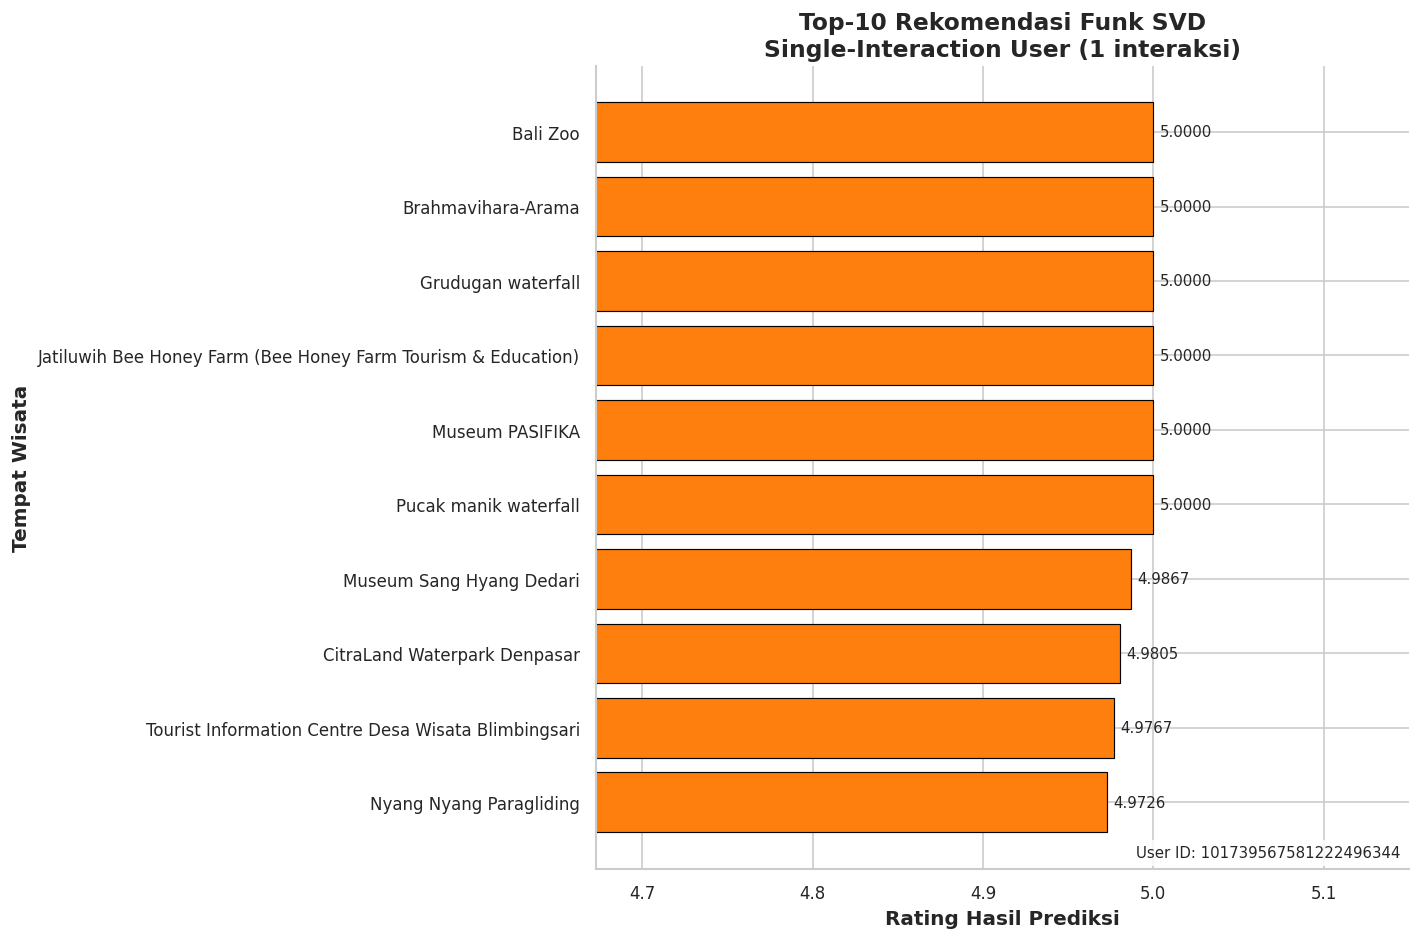

Gambar berhasil disimpan: 46_Top10_Low_History_User.png (264.78 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

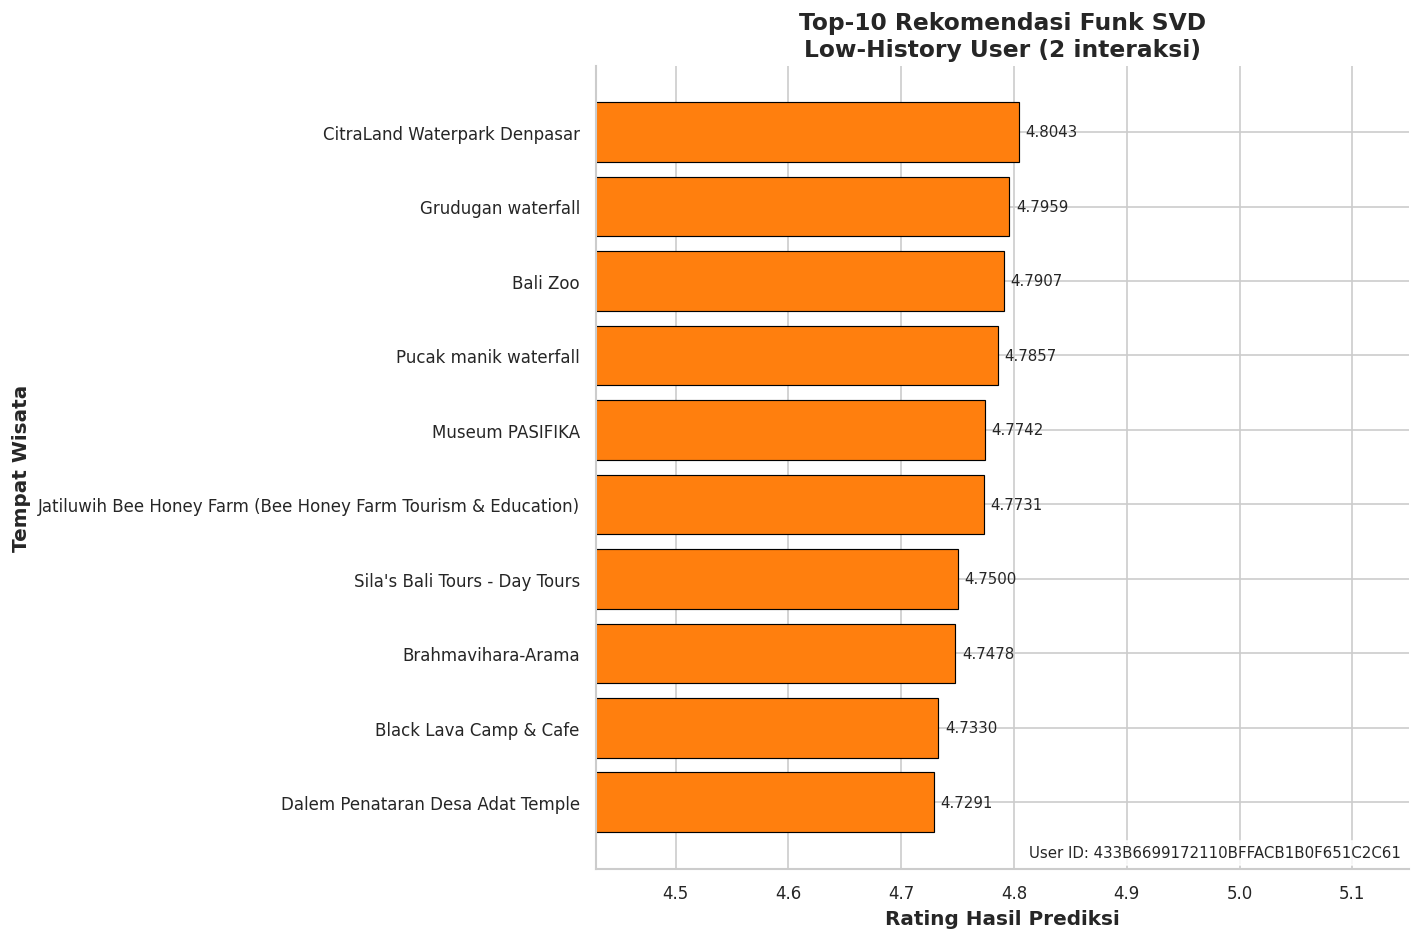

Gambar berhasil disimpan: 47_Top10_Higher_History_User.png (260.97 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

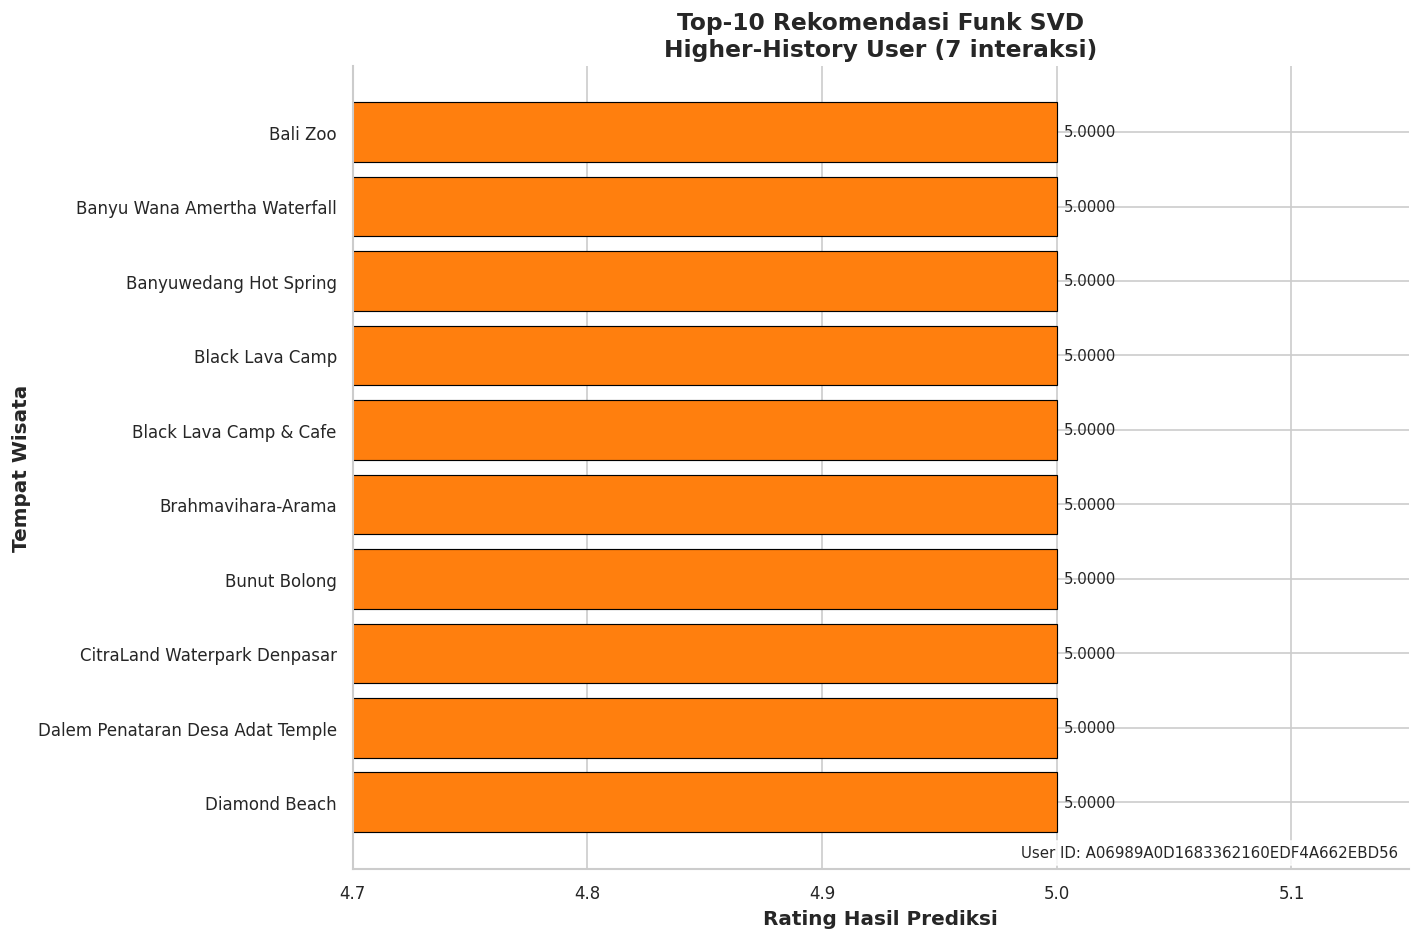

In [96]:
top_10_visualization_files = []

for category_name in (
    IMPLEMENTATION_USER_CATEGORY_ORDER
):

    category_recommendations = (
        top_20_recommendations[
            (
                top_20_recommendations[
                    "kategori_user"
                ].astype(str)
                == category_name
            )
            & (
                top_20_recommendations[
                    "ranking"
                ] <= 10
            )
        ]
        .copy()
        .sort_values(
            "ranking",
            ascending=False
        )
    )

    if category_recommendations.empty:
        print(
            f"Tidak terdapat rekomendasi untuk "
            f"kategori {category_name}."
        )
        continue

    sample_user_id = str(
        category_recommendations[
            "user_id"
        ].iloc[0]
    )

    sample_interaction_count = int(
        category_recommendations[
            "jumlah_interaksi_user"
        ].iloc[0]
    )

    fig, ax = plt.subplots(
        figsize=(12, 8)
    )

    bars = ax.barh(
        category_recommendations[
            "place_name"
        ],
        category_recommendations[
            "rating_prediction"
        ],
        color=MODEL_COLORS[
            BEST_MODEL_NAME
        ],
        edgecolor="black",
        linewidth=0.7
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:.4f}"
            for value in category_recommendations[
                "rating_prediction"
            ]
        ],
        padding=4,
        fontsize=9
    )

    ax.set_title(
        f"Top-10 Rekomendasi {BEST_MODEL_NAME}\n"
        f"{category_name} "
        f"({sample_interaction_count} interaksi)"
    )

    ax.set_xlabel(
        "Rating Hasil Prediksi"
    )

    ax.set_ylabel(
        "Tempat Wisata"
    )

    prediction_minimum = float(
        category_recommendations[
            "rating_prediction"
        ].min()
    )

    lower_axis_limit = max(
        RATING_MIN,
        prediction_minimum - 0.30
    )

    ax.set_xlim(
        lower_axis_limit,
        RATING_MAX + 0.15
    )

    ax.text(
        0.99,
        0.01,
        f"User ID: {sample_user_id}",
        transform=ax.transAxes,
        horizontalalignment="right",
        verticalalignment="bottom",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "alpha": 0.8
        }
    )

    plt.tight_layout()

    category_file_label = (
        IMPLEMENTATION_CATEGORY_FILE_LABELS[
            category_name
        ]
    )

    category_file_number = {
        "Single-Interaction User": 45,
        "Low-History User": 46,
        "Higher-History User": 47
    }[category_name]

    output_path = save_figure_output(
        figure=fig,
        filename=(
            f"{category_file_number}_"
            f"Top10_{category_file_label}.png"
        ),
        close_figure=False
    )

    top_10_visualization_files.append(
        str(output_path)
    )

    plt.show()
    plt.close(fig)

## **4.10 Ringkasan Implementasi Sistem Rekomendasi**

In [97]:
implementation_system_summary = pd.DataFrame({
    "Komponen": [
        "Model implementasi",
        "Jumlah interaksi training",
        "Jumlah user training",
        "Jumlah item training",
        "Jumlah pengguna sampel",
        "Kategori pengguna sampel",
        "Top-N yang dihasilkan",
        "Jumlah rekomendasi maksimum per user",
        "Waktu training model",
        "Waktu generate rekomendasi",
        "Total overlap item",
        "Status validasi keseluruhan",
        "Fungsi Top-N dalam penelitian"
    ],
    "Nilai": [
        BEST_MODEL_NAME,
        len(dataset),
        dataset["user_id"].nunique(),
        dataset["place_id"].nunique(),
        selected_users["user_id"].nunique(),
        ", ".join(
            IMPLEMENTATION_USER_CATEGORY_ORDER
        ),
        str(TOP_N_VALUES),
        MAX_TOP_N,
        format_execution_time(
            implementation_training_time
        ),
        format_execution_time(
            recommendation_generation_time
        ),
        recommendation_validation_summary[
            "jumlah_item_overlap"
        ].sum(),
        (
            "Sesuai"
            if (
                recommendation_validation_summary[
                    "jumlah_item_overlap"
                ].sum() == 0
            )
            else "Tidak Sesuai"
        ),
        (
            "Demonstrasi keluaran sistem; "
            "bukan metrik evaluasi akurasi"
        )
    ]
})


save_excel_output(
    data={
        "Ringkasan Implementasi": (
            implementation_system_summary
        ),
        "Konfigurasi Model": (
            implementation_configuration
        ),
        "Pengguna Sampel": (
            selected_users
        ),
        "Validasi Rekomendasi": (
            recommendation_validation_summary
        ),
        "Ringkasan Top-N": (
            top_n_descriptive_summary
        )
    },
    filename=(
        "48_Ringkasan_Implementasi_"
        "Sistem_Rekomendasi.xlsx"
    ),
    index=False
)

display(implementation_system_summary)

Excel berhasil disimpan: 48_Ringkasan_Implementasi_Sistem_Rekomendasi.xlsx (10.05 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Komponen,Nilai
0,Model implementasi,Funk SVD
1,Jumlah interaksi training,21886
2,Jumlah user training,18524
3,Jumlah item training,300
4,Jumlah pengguna sampel,3
5,Kategori pengguna sampel,"Single-Interaction User, Low-History User, Higher-History User"
6,Top-N yang dihasilkan,"[5, 10, 15, 20]"
7,Jumlah rekomendasi maksimum per user,20
8,Waktu training model,0.52 detik
9,Waktu generate rekomendasi,0.05 detik


## **4.11 Pemeriksaan Akhir Implementasi Sistem**

In [98]:
# ------------------------------------------------------------
# A. Pemeriksaan training penuh
# ------------------------------------------------------------

assert (
    implementation_model[
        "number_of_train_interactions"
    ]
    == len(dataset)
), (
    "Model implementasi belum menggunakan "
    "seluruh dataset."
)

assert (
    implementation_model[
        "number_of_train_users"
    ]
    == dataset["user_id"].nunique()
), (
    "Jumlah user model implementasi tidak sesuai."
)

assert (
    implementation_model[
        "number_of_train_items"
    ]
    == dataset["place_id"].nunique()
), (
    "Jumlah item model implementasi tidak sesuai."
)


# ------------------------------------------------------------
# B. Pemeriksaan pengguna sampel
# ------------------------------------------------------------

assert (
    selected_users["kategori_user"].nunique()
    == len(
        IMPLEMENTATION_USER_CATEGORY_ORDER
    )
), (
    "Tidak seluruh kategori memiliki pengguna sampel."
)

assert selected_users["user_id"].is_unique, (
    "Terdapat user sampel yang dipilih lebih dari sekali."
)


# ------------------------------------------------------------
# C. Pemeriksaan hasil rekomendasi
# ------------------------------------------------------------

assert (
    recommendation_validation_summary[
        "jumlah_item_overlap"
    ].sum()
    == 0
), (
    "Terdapat item yang sudah diberi rating "
    "dalam daftar rekomendasi."
)

assert (
    top_20_recommendations[
        "rating_prediction"
    ]
    .between(
        RATING_MIN,
        RATING_MAX
    )
    .all()
), (
    "Terdapat prediksi Top-N di luar skala rating."
)

assert (
    top_20_recommendations[
        "prediction_source"
    ]
    == "Model Prediction"
).all(), (
    "Terdapat rekomendasi yang tidak berasal "
    "dari model prediction."
)


# ------------------------------------------------------------
# D. Pemeriksaan jumlah dan ranking per user
# ------------------------------------------------------------

for user_id in selected_user_ids:

    user_top_recommendations = (
        top_20_recommendations[
            top_20_recommendations[
                "user_id"
            ].astype(str) == str(user_id)
        ]
        .sort_values("ranking")
    )

    expected_recommendation_count = min(
        MAX_TOP_N,
        (
            dataset["place_id"].nunique()
            - int(
                (
                    dataset["user_id"]
                    .astype(str)
                    == str(user_id)
                ).sum()
            )
        )
    )

    assert len(
        user_top_recommendations
    ) == expected_recommendation_count, (
        f"Jumlah rekomendasi user {user_id} "
        "tidak sesuai."
    )

    assert (
        user_top_recommendations[
            "place_id"
        ].is_unique
    ), (
        f"Terdapat item rekomendasi duplikat "
        f"untuk user {user_id}."
    )

    expected_ranking = np.arange(
        1,
        len(user_top_recommendations) + 1
    )

    assert np.array_equal(
        user_top_recommendations[
            "ranking"
        ].to_numpy(),
        expected_ranking
    ), (
        f"Ranking rekomendasi user {user_id} "
        "tidak berurutan."
    )

    assert (
        user_top_recommendations[
            "rating_prediction"
        ]
        .is_monotonic_decreasing
    ), (
        f"Prediksi rekomendasi user {user_id} "
        "belum diurutkan secara menurun."
    )


# ------------------------------------------------------------
# E. Pemeriksaan Top-N berjenjang
# ------------------------------------------------------------

for user_id in selected_user_ids:

    user_top_20 = set(
        top_n_recommendation_tables[
            "Top 20"
        ].loc[
            top_n_recommendation_tables[
                "Top 20"
            ]["user_id"].astype(str)
            == str(user_id),
            "place_id"
        ]
        .astype(str)
        .tolist()
    )

    user_top_15 = set(
        top_n_recommendation_tables[
            "Top 15"
        ].loc[
            top_n_recommendation_tables[
                "Top 15"
            ]["user_id"].astype(str)
            == str(user_id),
            "place_id"
        ]
        .astype(str)
        .tolist()
    )

    user_top_10 = set(
        top_n_recommendation_tables[
            "Top 10"
        ].loc[
            top_n_recommendation_tables[
                "Top 10"
            ]["user_id"].astype(str)
            == str(user_id),
            "place_id"
        ]
        .astype(str)
        .tolist()
    )

    user_top_5 = set(
        top_n_recommendation_tables[
            "Top 5"
        ].loc[
            top_n_recommendation_tables[
                "Top 5"
            ]["user_id"].astype(str)
            == str(user_id),
            "place_id"
        ]
        .astype(str)
        .tolist()
    )

    assert user_top_5.issubset(
        user_top_10
    ), (
        f"Top-5 user {user_id} bukan subset Top-10."
    )

    assert user_top_10.issubset(
        user_top_15
    ), (
        f"Top-10 user {user_id} bukan subset Top-15."
    )

    assert user_top_15.issubset(
        user_top_20
    ), (
        f"Top-15 user {user_id} bukan subset Top-20."
    )


print("=" * 80)
print("STEP 4 SELESAI")
print("=" * 80)

print(f"Model implementasi : {BEST_MODEL_NAME}")
print(
    f"Jumlah user sampel : "
    f"{selected_users['user_id'].nunique()}"
)
print(f"Top-N              : {TOP_N_VALUES}")
print(
    f"Jumlah output Top-20: "
    f"{len(top_20_recommendations):,}"
)
print(
    "Status validasi    : "
    "SELURUH PEMERIKSAAN BERHASIL"
)

print()
print(
    "Sistem rekomendasi berhasil menghasilkan "
    "daftar tempat wisata yang belum pernah "
    "diberi rating oleh pengguna."
)

STEP 4 SELESAI
Model implementasi : Funk SVD
Jumlah user sampel : 3
Top-N              : [5, 10, 15, 20]
Jumlah output Top-20: 60
Status validasi    : SELURUH PEMERIKSAAN BERHASIL

Sistem rekomendasi berhasil menghasilkan daftar tempat wisata yang belum pernah diberi rating oleh pengguna.


# **Ringkasan Output Penelitian**

## **5.1 Pemeriksaan Ketersediaan Hasil Penelitian**

In [99]:
required_step_5_objects = [
    # Dataset dan karakteristik
    "dataset",
    "development_data",
    "final_test_data",
    "dataset_summary",
    "matrix_sparsity",
    "matrix_density",

    # Hasil optimasi SVD
    "svd_grid_summary",
    "best_svd_k",
    "best_svd_result",

    # Hasil optimasi Funk SVD
    "funk_svd_grid_summary",
    "best_funk_n_factors",
    "best_funk_learning_rate",
    "best_funk_regularization",
    "best_funk_n_epochs",
    "best_funk_svd_result",

    # Hasil optimasi SVD++
    "svdpp_grid_summary",
    "best_svdpp_n_factors",
    "best_svdpp_learning_rate",
    "best_svdpp_regularization",
    "best_svdpp_n_epochs",
    "best_svdpp_result",

    # Evaluasi final
    "final_overall_results",
    "final_user_category_results",
    "final_prediction_source_results",
    "final_model_prediction_only_results",
    "BEST_MODEL_NAME",
    "best_final_result",

    # Implementasi sistem
    "implementation_configuration",
    "implementation_training_summary",
    "selected_users",
    "selected_user_history",
    "top_n_descriptive_summary",
    "top_20_recommendations",
    "recommendation_validation_summary"
]

missing_step_5_objects = [
    object_name
    for object_name in required_step_5_objects
    if object_name not in globals()
]

if missing_step_5_objects:
    raise NameError(
        "Objek berikut belum tersedia:\n"
        + "\n".join(
            f"- {object_name}"
            for object_name in missing_step_5_objects
        )
        + "\n\nPastikan Step 0 sampai Step 4 telah dijalankan."
    )

print("=" * 80)
print("PEMERIKSAAN OBJEK STEP 5")
print("=" * 80)

print(
    f"Jumlah objek wajib : "
    f"{len(required_step_5_objects)}"
)

print(
    "Status             : "
    "SELURUH OBJEK TERSEDIA"
)

print(
    f"Model terbaik      : "
    f"{BEST_MODEL_NAME}"
)

PEMERIKSAAN OBJEK STEP 5
Jumlah objek wajib : 34
Status             : SELURUH OBJEK TERSEDIA
Model terbaik      : Funk SVD


## **5.2 Ringkasan Hyperparameter Terbaik**

In [100]:
best_hyperparameter_summary = pd.DataFrame([
    {
        "model": "SVD",
        "jumlah_komponen_atau_faktor": best_svd_k,
        "learning_rate": np.nan,
        "regularization": np.nan,
        "jumlah_epoch": np.nan,
        "cv_mean_rmse": float(
            best_svd_result["mean_rmse"]
        ),
        "cv_std_rmse": float(
            best_svd_result["std_rmse"]
        ),
        "cv_mean_mae": float(
            best_svd_result["mean_mae"]
        ),
        "cv_std_mae": float(
            best_svd_result["std_mae"]
        )
    },
    {
        "model": "Funk SVD",
        "jumlah_komponen_atau_faktor": (
            best_funk_n_factors
        ),
        "learning_rate": (
            best_funk_learning_rate
        ),
        "regularization": (
            best_funk_regularization
        ),
        "jumlah_epoch": (
            best_funk_n_epochs
        ),
        "cv_mean_rmse": float(
            best_funk_svd_result["mean_rmse"]
        ),
        "cv_std_rmse": float(
            best_funk_svd_result["std_rmse"]
        ),
        "cv_mean_mae": float(
            best_funk_svd_result["mean_mae"]
        ),
        "cv_std_mae": float(
            best_funk_svd_result["std_mae"]
        )
    },
    {
        "model": "SVD++",
        "jumlah_komponen_atau_faktor": (
            best_svdpp_n_factors
        ),
        "learning_rate": (
            best_svdpp_learning_rate
        ),
        "regularization": (
            best_svdpp_regularization
        ),
        "jumlah_epoch": (
            best_svdpp_n_epochs
        ),
        "cv_mean_rmse": float(
            best_svdpp_result["mean_rmse"]
        ),
        "cv_std_rmse": float(
            best_svdpp_result["std_rmse"]
        ),
        "cv_mean_mae": float(
            best_svdpp_result["mean_mae"]
        ),
        "cv_std_mae": float(
            best_svdpp_result["std_mae"]
        )
    }
])

best_hyperparameter_summary = (
    best_hyperparameter_summary
    .sort_values(
        by=[
            "cv_mean_rmse",
            "cv_mean_mae",
            "model"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

best_hyperparameter_summary.insert(
    0,
    "ranking_cv",
    np.arange(
        1,
        len(best_hyperparameter_summary) + 1
    )
)

display(best_hyperparameter_summary)

,ranking_cv,model,jumlah_komponen_atau_faktor,learning_rate,regularization,jumlah_epoch,cv_mean_rmse,cv_std_rmse,cv_mean_mae,cv_std_mae
0,1,SVD++,50,0.010000,0.100000,100.000000,1.072643,0.013989,0.757095,0.010364
1,2,Funk SVD,50,0.010000,0.100000,100.000000,1.072684,0.013301,0.757695,0.009336
2,3,SVD,5,NaN,NaN,NaN,1.086794,0.013102,0.786913,0.011374


## **5.3 Perbandingan Hasil Cross Validation dan Final Test**

In [101]:
cv_final_comparison = (
    best_hyperparameter_summary[
        [
            "model",
            "cv_mean_rmse",
            "cv_std_rmse",
            "cv_mean_mae",
            "cv_std_mae"
        ]
    ]
    .merge(
        final_overall_results[
            [
                "model",
                "ranking",
                "rmse",
                "mae",
                "jumlah_model_prediction",
                "persentase_model_prediction",
                "jumlah_fallback_prediction",
                "persentase_fallback_prediction",
                "training_time_seconds",
                "prediction_time_seconds",
                "total_execution_time_seconds"
            ]
        ],
        on="model",
        how="inner"
    )
    .rename(columns={
        "ranking": "ranking_final",
        "rmse": "final_rmse",
        "mae": "final_mae"
    })
)

cv_final_comparison[
    "selisih_rmse_final_vs_cv"
] = (
    cv_final_comparison["final_rmse"]
    - cv_final_comparison["cv_mean_rmse"]
)

cv_final_comparison[
    "selisih_mae_final_vs_cv"
] = (
    cv_final_comparison["final_mae"]
    - cv_final_comparison["cv_mean_mae"]
)

cv_final_comparison[
    "perubahan_rmse_percent"
] = (
    cv_final_comparison[
        "selisih_rmse_final_vs_cv"
    ]
    / cv_final_comparison["cv_mean_rmse"]
    * 100
)

cv_final_comparison[
    "perubahan_mae_percent"
] = (
    cv_final_comparison[
        "selisih_mae_final_vs_cv"
    ]
    / cv_final_comparison["cv_mean_mae"]
    * 100
)

cv_final_comparison = (
    cv_final_comparison
    .sort_values(
        by=[
            "ranking_final",
            "model"
        ]
    )
    .reset_index(drop=True)
)

display(cv_final_comparison)

,model,cv_mean_rmse,cv_std_rmse,cv_mean_mae,cv_std_mae,ranking_final,final_rmse,final_mae,jumlah_model_prediction,persentase_model_prediction,jumlah_fallback_prediction,persentase_fallback_prediction,training_time_seconds,prediction_time_seconds,total_execution_time_seconds,selisih_rmse_final_vs_cv,selisih_mae_final_vs_cv,perubahan_rmse_percent,perubahan_mae_percent
0,Funk SVD,1.072684,0.013301,0.757695,0.009336,1,1.043333,0.743444,921,21.037003,3457,78.962997,0.341532,0.024690,0.366223,-0.029351,-0.014251,-2.736180,-1.880788
1,SVD++,1.072643,0.013989,0.757095,0.010364,2,1.045791,0.744687,921,21.037003,3457,78.962997,1.116357,0.024588,1.140946,-0.026852,-0.012407,-2.503310,-1.638828
2,SVD,1.086794,0.013102,0.786913,0.011374,3,1.063348,0.777104,921,21.037003,3457,78.962997,0.076777,0.029335,0.106112,-0.023446,-0.009809,-2.157344,-1.246496


## **5.4 Ringkasan Evaluasi Berdasarkan Kategori User**

In [102]:
final_user_category_ranked = (
    final_user_category_results
    .copy()
)

final_user_category_ranked[
    "kategori_user"
] = pd.Categorical(
    final_user_category_ranked[
        "kategori_user"
    ],
    categories=USER_CATEGORY_ORDER,
    ordered=True
)

final_user_category_ranked[
    "ranking_rmse_dalam_kategori"
] = (
    final_user_category_ranked
    .groupby(
        "kategori_user",
        observed=False
    )["rmse"]
    .rank(
        method="min",
        ascending=True
    )
)

final_user_category_ranked[
    "ranking_mae_dalam_kategori"
] = (
    final_user_category_ranked
    .groupby(
        "kategori_user",
        observed=False
    )["mae"]
    .rank(
        method="min",
        ascending=True
    )
)

final_user_category_ranked = (
    final_user_category_ranked
    .sort_values(
        by=[
            "kategori_user",
            "ranking_rmse_dalam_kategori",
            "ranking_mae_dalam_kategori",
            "model"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Hasil khusus model terbaik
# ------------------------------------------------------------

best_model_user_category_results = (
    final_user_category_ranked[
        final_user_category_ranked[
            "model"
        ] == BEST_MODEL_NAME
    ]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Pemeriksaan kesamaan unseen-user fallback
# ------------------------------------------------------------

unseen_user_results = (
    final_user_category_results[
        final_user_category_results[
            "kategori_user"
        ].astype(str) == "Unseen User"
    ]
    .copy()
)

if len(unseen_user_results) == 3:

    unseen_rmse_consistent = bool(
        np.allclose(
            unseen_user_results["rmse"],
            unseen_user_results["rmse"].iloc[0],
            rtol=1e-10,
            atol=1e-10,
            equal_nan=True
        )
    )

    unseen_mae_consistent = bool(
        np.allclose(
            unseen_user_results["mae"],
            unseen_user_results["mae"].iloc[0],
            rtol=1e-10,
            atol=1e-10,
            equal_nan=True
        )
    )

else:
    unseen_rmse_consistent = False
    unseen_mae_consistent = False


unseen_user_consistency_summary = pd.DataFrame({
    "Pemeriksaan": [
        "Jumlah model yang dibandingkan",
        "RMSE unseen user identik",
        "MAE unseen user identik",
        "Mekanisme prediksi unseen user"
    ],
    "Hasil": [
        len(unseen_user_results),
        unseen_rmse_consistent,
        unseen_mae_consistent,
        "Item Mean Fallback"
    ]
})


display(final_user_category_ranked)
display(unseen_user_consistency_summary)

,model,kategori_user,jumlah_prediksi,persentase_prediksi,jumlah_user_unik,jumlah_item_unik,rata_rata_rating_aktual,rata_rata_rating_prediksi,rmse,mae,deskripsi_kategori,ranking_rmse_dalam_kategori,ranking_mae_dalam_kategori
0,Funk SVD,Unseen User,3454,78.894472,3398,252,4.337869,4.365403,1.093894,0.784222,0 interaksi,1.000000,1.000000
1,SVD,Unseen User,3454,78.894472,3398,252,4.337869,4.365403,1.093894,0.784222,0 interaksi,1.000000,1.000000
2,SVD++,Unseen User,3454,78.894472,3398,252,4.337869,4.365403,1.093894,0.784222,0 interaksi,1.000000,1.000000
3,Funk SVD,Single-Interaction User,463,10.575605,427,170,4.390929,4.374826,0.860488,0.618862,1 interaksi,1.000000,1.000000
4,SVD++,Single-Interaction User,463,10.575605,427,170,4.390929,4.401839,0.875342,0.631093,1 interaksi,2.000000,2.000000
5,SVD,Single-Interaction User,463,10.575605,427,170,4.390929,4.351101,0.968394,0.773759,1 interaksi,3.000000,3.000000
6,Funk SVD,Low-History User,373,8.519872,282,139,4.418231,4.352940,0.800095,0.569899,2–5 interaksi,1.000000,1.000000
7,SVD++,Low-History User,373,8.519872,282,139,4.418231,4.395475,0.816955,0.574113,2–5 interaksi,2.000000,2.000000
8,SVD,Low-History User,373,8.519872,282,139,4.418231,4.348217,0.908134,0.737675,2–5 interaksi,3.000000,3.000000
9,Funk SVD,Higher-History User,88,2.010050,40,56,4.193182,4.262425,0.761117,0.533979,>5 interaksi,1.000000,2.000000


,Pemeriksaan,Hasil
0,Jumlah model yang dibandingkan,3
1,RMSE unseen user identik,True
2,MAE unseen user identik,True
3,Mekanisme prediksi unseen user,Item Mean Fallback


## **5.5 Ringkasan Sumber Prediksi dan Fallback**

In [103]:
best_model_prediction_data = (
    final_prediction_dictionary[
        BEST_MODEL_NAME
    ]
    .copy()
)

final_source_distribution_summary = (
    best_model_prediction_data[
        "prediction_source"
    ]
    .value_counts()
    .reindex(
        EXPECTED_PREDICTION_SOURCE_ORDER,
        fill_value=0
    )
    .rename("jumlah_prediksi")
    .reset_index()
    .rename(columns={
        "index": "prediction_source"
    })
)

final_source_distribution_summary[
    "persentase_prediksi"
] = (
    final_source_distribution_summary[
        "jumlah_prediksi"
    ]
    / len(best_model_prediction_data)
    * 100
)

final_source_distribution_summary[
    "kategori_sumber"
] = np.where(
    final_source_distribution_summary[
        "prediction_source"
    ] == "Model Prediction",
    "Prediksi Model",
    "Fallback"
)


fallback_total = int(
    final_source_distribution_summary.loc[
        final_source_distribution_summary[
            "kategori_sumber"
        ] == "Fallback",
        "jumlah_prediksi"
    ].sum()
)

model_prediction_total = int(
    final_source_distribution_summary.loc[
        final_source_distribution_summary[
            "kategori_sumber"
        ] == "Prediksi Model",
        "jumlah_prediksi"
    ].sum()
)


prediction_pipeline_summary = pd.DataFrame({
    "Komponen": [
        "Jumlah final test",
        "Jumlah model prediction",
        "Persentase model prediction",
        "Jumlah fallback",
        "Persentase fallback",
        "Model yang digunakan untuk ringkasan",
        "Aturan fallback unseen user",
        "Aturan fallback unseen item",
        "Aturan fallback user dan item unseen"
    ],
    "Nilai": [
        len(best_model_prediction_data),
        model_prediction_total,
        (
            model_prediction_total
            / len(best_model_prediction_data)
            * 100
        ),
        fallback_total,
        (
            fallback_total
            / len(best_model_prediction_data)
            * 100
        ),
        BEST_MODEL_NAME,
        "Item mean dari training",
        "User mean dari training",
        "Global mean dari training"
    ]
})

display(final_source_distribution_summary)
display(prediction_pipeline_summary)

,prediction_source,jumlah_prediksi,persentase_prediksi,kategori_sumber
0,Model Prediction,921,21.037003,Prediksi Model
1,Item Mean Fallback,3453,78.871631,Fallback
2,User Mean Fallback,3,0.068524,Fallback
3,Global Mean Fallback,1,0.022841,Fallback


,Komponen,Nilai
0,Jumlah final test,4378
1,Jumlah model prediction,921
2,Persentase model prediction,21.037003
3,Jumlah fallback,3457
4,Persentase fallback,78.962997
5,Model yang digunakan untuk ringkasan,Funk SVD
6,Aturan fallback unseen user,Item mean dari training
7,Aturan fallback unseen item,User mean dari training
8,Aturan fallback user dan item unseen,Global mean dari training


## **5.6 Ringkasan Implementasi Top-N**

In [104]:
top_n_final_summary = (
    top_n_descriptive_summary
    .merge(
        selected_users[
            [
                "user_id",
                "kategori_user",
                "jumlah_interaksi",
                "rata_rata_rating",
                "metode_pemilihan"
            ]
        ],
        on=[
            "user_id",
            "kategori_user"
        ],
        how="left"
    )
)

top_n_final_summary = (
    top_n_final_summary
    .sort_values(
        by=[
            "kategori_user",
            "top_n"
        ]
    )
    .reset_index(drop=True)
)


top_20_destination_summary = (
    top_20_recommendations
    .groupby(
        [
            "place_id",
            "place_name"
        ],
        as_index=False
    )
    .agg(
        jumlah_muncul_dalam_top_20=(
            "user_id",
            "count"
        ),
        jumlah_user_yang_menerima=(
            "user_id",
            "nunique"
        ),
        rata_rata_rating_prediksi=(
            "rating_prediction",
            "mean"
        ),
        ranking_terbaik=(
            "ranking",
            "min"
        ),
        jumlah_rating_aktual_item=(
            "jumlah_rating_item",
            "first"
        ),
        rata_rata_rating_aktual_item=(
            "rata_rata_rating_item",
            "first"
        )
    )
    .sort_values(
        by=[
            "jumlah_user_yang_menerima",
            "ranking_terbaik",
            "rata_rata_rating_prediksi"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)


display(top_n_final_summary)
display(top_20_destination_summary.head(20))

,model,user_id,kategori_user,top_n,jumlah_rekomendasi,prediksi_rating_tertinggi,prediksi_rating_terendah,rata_rata_prediksi_rating,jumlah_interaksi,rata_rata_rating,metode_pemilihan
0,Funk SVD,A06989A0D1683362160EDF4A662EBD56,Higher-History User,5,5,5.000000,5.000000,5.000000,7,4.571429,Otomatis: jumlah interaksi paling dekat dengan median kategori
1,Funk SVD,A06989A0D1683362160EDF4A662EBD56,Higher-History User,10,10,5.000000,5.000000,5.000000,7,4.571429,Otomatis: jumlah interaksi paling dekat dengan median kategori
2,Funk SVD,A06989A0D1683362160EDF4A662EBD56,Higher-History User,15,15,5.000000,5.000000,5.000000,7,4.571429,Otomatis: jumlah interaksi paling dekat dengan median kategori
3,Funk SVD,A06989A0D1683362160EDF4A662EBD56,Higher-History User,20,20,5.000000,5.000000,5.000000,7,4.571429,Otomatis: jumlah interaksi paling dekat dengan median kategori
4,Funk SVD,433B6699172110BFFACB1B0F651C2C61,Low-History User,5,5,4.804316,4.774208,4.790179,2,4.000000,Otomatis: jumlah interaksi paling dekat dengan median kategori
5,Funk SVD,433B6699172110BFFACB1B0F651C2C61,Low-History User,10,10,4.804316,4.729106,4.768394,2,4.000000,Otomatis: jumlah interaksi paling dekat dengan median kategori
6,Funk SVD,433B6699172110BFFACB1B0F651C2C61,Low-History User,15,15,4.804316,4.711078,4.752344,2,4.000000,Otomatis: jumlah interaksi paling dekat dengan median kategori
7,Funk SVD,433B6699172110BFFACB1B0F651C2C61,Low-History User,20,20,4.804316,4.697807,4.740648,2,4.000000,Otomatis: jumlah interaksi paling dekat dengan median kategori
8,Funk SVD,101739567581222496344,Single-Interaction User,5,5,5.000000,5.000000,5.000000,1,5.000000,Otomatis: jumlah interaksi paling dekat dengan median kategori
9,Funk SVD,101739567581222496344,Single-Interaction User,10,10,5.000000,4.972587,4.991647,1,5.000000,Otomatis: jumlah interaksi paling dekat dengan median kategori


,place_id,place_name,jumlah_muncul_dalam_top_20,jumlah_user_yang_menerima,rata_rata_rating_prediksi,ranking_terbaik,jumlah_rating_aktual_item,rata_rata_rating_aktual_item
0,1793975,Bali Zoo,3,3,4.930250,1,160,4.962500
1,ChIJqZ1qazQ_0i0RlSSmznZwXpE,CitraLand Waterpark Denpasar,3,3,4.928273,1,107,4.813084
2,ChIJ8WV6yfgZ0i0RLNelt6XX4d4,Grudugan waterfall,3,3,4.931958,2,100,4.970000
3,ChIJZ8hawhKD0S0RJiS_lwHbBVM,Brahmavihara-Arama,3,3,4.915948,2,100,4.910000
4,ChIJL9VpEnsn0i0RyFAndDrB71g,Jatiluwih Bee Honey Farm (Bee Honey Farm Tourism & Education),3,3,4.924373,4,32,4.968750
5,1230139,Museum PASIFIKA,3,3,4.924736,5,80,4.975000
6,ChIJ5arYDXH10S0RntXbW2X5gOo,Black Lava Camp & Cafe,3,3,4.889691,5,100,4.790000
7,ChIJz5mwhEeN0S0RKM_VRaBKrRQ,Kopi Gunung Catur,3,3,4.885396,13,24,4.916667
8,6394470,Banyuwedang Hot Spring,2,2,4.977563,3,8,5.000000
9,ChIJqZoIJwCP0S0R4K5Qe0NhZkQ,Pucak manik waterfall,2,2,4.892874,4,55,5.000000


## **5.7 Penyusunan Temuan Utama Penelitian**

In [105]:
best_final_model_row = (
    final_overall_results[
        final_overall_results[
            "model"
        ] == BEST_MODEL_NAME
    ]
    .iloc[0]
)

best_model_only_row = (
    final_model_prediction_only_results
    .iloc[0]
)

dominant_final_category = (
    best_model_prediction_data[
        "kategori_user"
    ]
    .astype(str)
    .value_counts()
    .index[0]
)

dominant_final_category_count = int(
    best_model_prediction_data[
        "kategori_user"
    ]
    .astype(str)
    .value_counts()
    .iloc[0]
)

dominant_final_category_percentage = (
    dominant_final_category_count
    / len(best_model_prediction_data)
    * 100
)

dominant_prediction_source = (
    final_source_distribution_summary
    .sort_values(
        "jumlah_prediksi",
        ascending=False
    )
    .iloc[0]
)

single_interaction_user_count = int(
    (
        implementation_user_profile[
            "jumlah_interaksi"
        ] == 1
    ).sum()
)

low_history_user_count = int(
    implementation_user_profile[
        "jumlah_interaksi"
    ].between(
        2,
        5
    ).sum()
)

higher_history_user_count = int(
    (
        implementation_user_profile[
            "jumlah_interaksi"
        ] > 5
    ).sum()
)


key_findings = pd.DataFrame([
    {
        "No": 1,
        "Temuan": "Karakteristik dataset",
        "Nilai": (
            f"{len(dataset):,} interaksi; "
            f"{dataset['user_id'].nunique():,} user; "
            f"{dataset['place_id'].nunique():,} item"
        ),
        "Interpretasi_Deskriptif": (
            "Dataset membentuk matriks user-item "
            "dengan jumlah user jauh lebih besar "
            "dibandingkan jumlah item."
        )
    },
    {
        "No": 2,
        "Temuan": "Tingkat sparsity matriks",
        "Nilai": f"{matrix_sparsity:.6f}%",
        "Interpretasi_Deskriptif": (
            "Sebagian besar kemungkinan pasangan "
            "user-item tidak memiliki rating terobservasi."
        )
    },
    {
        "No": 3,
        "Temuan": "Distribusi histori user",
        "Nilai": (
            f"{single_interaction_user_count:,} single-interaction; "
            f"{low_history_user_count:,} low-history; "
            f"{higher_history_user_count:,} higher-history"
        ),
        "Interpretasi_Deskriptif": (
            "Dataset didominasi oleh pengguna dengan "
            "histori interaksi yang sangat terbatas."
        )
    },
    {
        "No": 4,
        "Temuan": "Model terbaik evaluasi final",
        "Nilai": BEST_MODEL_NAME,
        "Interpretasi_Deskriptif": (
            f"Memperoleh RMSE "
            f"{best_final_model_row['rmse']:.6f} "
            f"dan MAE "
            f"{best_final_model_row['mae']:.6f}."
        )
    },
    {
        "No": 5,
        "Temuan": "Model terbaik pada model prediction only",
        "Nilai": str(
            best_model_only_row["model"]
        ),
        "Interpretasi_Deskriptif": (
            f"Pada interaksi yang benar-benar menggunakan "
            f"faktor laten, RMSE sebesar "
            f"{best_model_only_row['rmse_model_prediction']:.6f} "
            f"dan MAE sebesar "
            f"{best_model_only_row['mae_model_prediction']:.6f}."
        )
    },
    {
        "No": 6,
        "Temuan": "Kategori dominan pada final test",
        "Nilai": dominant_final_category,
        "Interpretasi_Deskriptif": (
            f"Mencakup {dominant_final_category_count:,} "
            f"interaksi atau "
            f"{dominant_final_category_percentage:.2f}% "
            f"dari final test."
        )
    },
    {
        "No": 7,
        "Temuan": "Sumber prediksi dominan",
        "Nilai": str(
            dominant_prediction_source[
                "prediction_source"
            ]
        ),
        "Interpretasi_Deskriptif": (
            f"Mencakup "
            f"{int(dominant_prediction_source['jumlah_prediksi']):,} "
            f"interaksi atau "
            f"{dominant_prediction_source['persentase_prediksi']:.2f}%."
        )
    },
    {
        "No": 8,
        "Temuan": "Proporsi fallback",
        "Nilai": f"{fallback_total:,} prediksi",
        "Interpretasi_Deskriptif": (
            f"Fallback digunakan pada "
            f"{fallback_total / len(best_model_prediction_data) * 100:.2f}% "
            f"final test."
        )
    },
    {
        "No": 9,
        "Temuan": "Konsistensi unseen-user fallback",
        "Nilai": (
            "Konsisten"
            if (
                unseen_rmse_consistent
                and unseen_mae_consistent
            )
            else "Perlu diperiksa"
        ),
        "Interpretasi_Deskriptif": (
            "RMSE dan MAE unseen user seharusnya "
            "identik antarmodel karena menggunakan "
            "item mean fallback yang sama."
        )
    },
    {
        "No": 10,
        "Temuan": "Implementasi Top-N",
        "Nilai": (
            f"Top-{TOP_N_VALUES} untuk "
            f"{selected_users['user_id'].nunique()} user sampel"
        ),
        "Interpretasi_Deskriptif": (
            "Top-N digunakan sebagai demonstrasi "
            "keluaran sistem rekomendasi dan bukan "
            "sebagai metrik evaluasi akurasi."
        )
    }
])

display(key_findings)

,No,Temuan,Nilai,Interpretasi_Deskriptif
0,1,Karakteristik dataset,"21,886 interaksi; 18,524 user; 300 item",Dataset membentuk matriks user-item dengan jumlah user jauh lebih besar dibandingkan jumlah item.
1,2,Tingkat sparsity matriks,99.606169%,Sebagian besar kemungkinan pasangan user-item tidak memiliki rating terobservasi.
2,3,Distribusi histori user,"16,650 single-interaction; 1,759 low-history; 115 higher-history",Dataset didominasi oleh pengguna dengan histori interaksi yang sangat terbatas.
3,4,Model terbaik evaluasi final,Funk SVD,Memperoleh RMSE 1.043333 dan MAE 0.743444.
4,5,Model terbaik pada model prediction only,Funk SVD,"Pada interaksi yang benar-benar menggunakan faktor laten, RMSE sebesar 0.828389 dan MAE sebesar ..."
5,6,Kategori dominan pada final test,Unseen User,"Mencakup 3,454 interaksi atau 78.89% dari final test."
6,7,Sumber prediksi dominan,Item Mean Fallback,"Mencakup 3,453 interaksi atau 78.87%."
7,8,Proporsi fallback,"3,457 prediksi",Fallback digunakan pada 78.96% final test.
8,9,Konsistensi unseen-user fallback,Konsisten,RMSE dan MAE unseen user seharusnya identik antarmodel karena menggunakan item mean fallback yan...
9,10,Implementasi Top-N,"Top-[5, 10, 15, 20] untuk 3 user sampel",Top-N digunakan sebagai demonstrasi keluaran sistem rekomendasi dan bukan sebagai metrik evaluas...


## **5.8 Ringkasan Naratif pada Notebook**

In [106]:
summary_markdown = f"""
# Ringkasan Hasil Penelitian

## Karakteristik Data

Dataset hasil praproses terdiri atas **{len(dataset):,} interaksi**,
**{dataset['user_id'].nunique():,} pengguna**, dan
**{dataset['place_id'].nunique():,} tempat wisata**.

Matriks user–item memiliki tingkat sparsity sebesar
**{matrix_sparsity:.6f}%** dan density sebesar
**{matrix_density:.6f}%**.

## Hasil Evaluasi Final

Model dengan performa keseluruhan terbaik adalah
**{BEST_MODEL_NAME}**, dengan:

- **RMSE final:** {best_final_model_row['rmse']:.6f}
- **MAE final:** {best_final_model_row['mae']:.6f}
- **Model prediction:** {int(best_final_model_row['jumlah_model_prediction']):,}
  interaksi ({best_final_model_row['persentase_model_prediction']:.2f}%)
- **Fallback prediction:** {int(best_final_model_row['jumlah_fallback_prediction']):,}
  interaksi ({best_final_model_row['persentase_fallback_prediction']:.2f}%)

## Evaluasi Cold-Start

Kategori yang paling dominan pada final test adalah
**{dominant_final_category}**, yang mencakup
**{dominant_final_category_percentage:.2f}%** interaksi final test.

Prediksi terhadap unseen user menggunakan **item mean fallback**.
Oleh karena itu, hasil kategori unseen user tidak sepenuhnya
merepresentasikan kemampuan personalisasi faktor laten masing-masing model.

## Implementasi Sistem

Model **{BEST_MODEL_NAME}** dilatih kembali menggunakan seluruh dataset
dan digunakan untuk menghasilkan rekomendasi
**Top-5, Top-10, Top-15, dan Top-20** terhadap
**{selected_users['user_id'].nunique()} pengguna sampel**.

Hasil Top-N merupakan demonstrasi keluaran sistem rekomendasi,
sedangkan evaluasi utama penelitian tetap menggunakan RMSE dan MAE.
"""

display(
    Markdown(summary_markdown)
)


# Ringkasan Hasil Penelitian

## Karakteristik Data

Dataset hasil praproses terdiri atas **21,886 interaksi**,
**18,524 pengguna**, dan
**300 tempat wisata**.

Matriks user–item memiliki tingkat sparsity sebesar
**99.606169%** dan density sebesar
**0.393831%**.

## Hasil Evaluasi Final

Model dengan performa keseluruhan terbaik adalah
**Funk SVD**, dengan:

- **RMSE final:** 1.043333
- **MAE final:** 0.743444
- **Model prediction:** 921
  interaksi (21.04%)
- **Fallback prediction:** 3,457
  interaksi (78.96%)

## Evaluasi Cold-Start

Kategori yang paling dominan pada final test adalah
**Unseen User**, yang mencakup
**78.89%** interaksi final test.

Prediksi terhadap unseen user menggunakan **item mean fallback**.
Oleh karena itu, hasil kategori unseen user tidak sepenuhnya
merepresentasikan kemampuan personalisasi faktor laten masing-masing model.

## Implementasi Sistem

Model **Funk SVD** dilatih kembali menggunakan seluruh dataset
dan digunakan untuk menghasilkan rekomendasi
**Top-5, Top-10, Top-15, dan Top-20** terhadap
**3 pengguna sampel**.

Hasil Top-N merupakan demonstrasi keluaran sistem rekomendasi,
sedangkan evaluasi utama penelitian tetap menggunakan RMSE dan MAE.


## **5.9 Penyimpanan Ringkasan Output Penelitian**

In [107]:
save_excel_output(
    data={
        "Temuan Utama": (
            key_findings
        ),
        "Ringkasan Dataset": (
            dataset_summary
        ),
        "Distribusi User Dataset": (
            user_category_distribution_full
        ),
        "Hyperparameter Terbaik": (
            best_hyperparameter_summary
        ),
        "CV dan Final Test": (
            cv_final_comparison
        ),
        "Evaluasi Final": (
            final_overall_results
        ),
        "Model Prediction Only": (
            final_model_prediction_only_results
        ),
        "Kategori User": (
            final_user_category_ranked
        ),
        "Kategori Model Terbaik": (
            best_model_user_category_results
        ),
        "Unseen User Consistency": (
            unseen_user_consistency_summary
        ),
        "Sumber Prediksi": (
            final_prediction_source_results
        ),
        "Distribusi Sumber": (
            final_source_distribution_summary
        ),
        "Pipeline Prediksi": (
            prediction_pipeline_summary
        ),
        "Konfigurasi Implementasi": (
            implementation_configuration
        ),
        "Pengguna Sampel": (
            selected_users
        ),
        "Ringkasan Top-N": (
            top_n_final_summary
        ),
        "Destinasi Top-20": (
            top_20_destination_summary
        ),
        "Validasi Rekomendasi": (
            recommendation_validation_summary
        )
    },
    filename="49_Ringkasan_Output_Penelitian.xlsx",
    index=False
)

Excel berhasil disimpan: 49_Ringkasan_Output_Penelitian.xlsx (28.09 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/49_Ringkasan_Output_Penelitian.xlsx')

## **5.10 Visualisasi Ringkasan Performa Model**

Gambar berhasil disimpan: 50_Ringkasan_Performa_Model.png (108.51 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

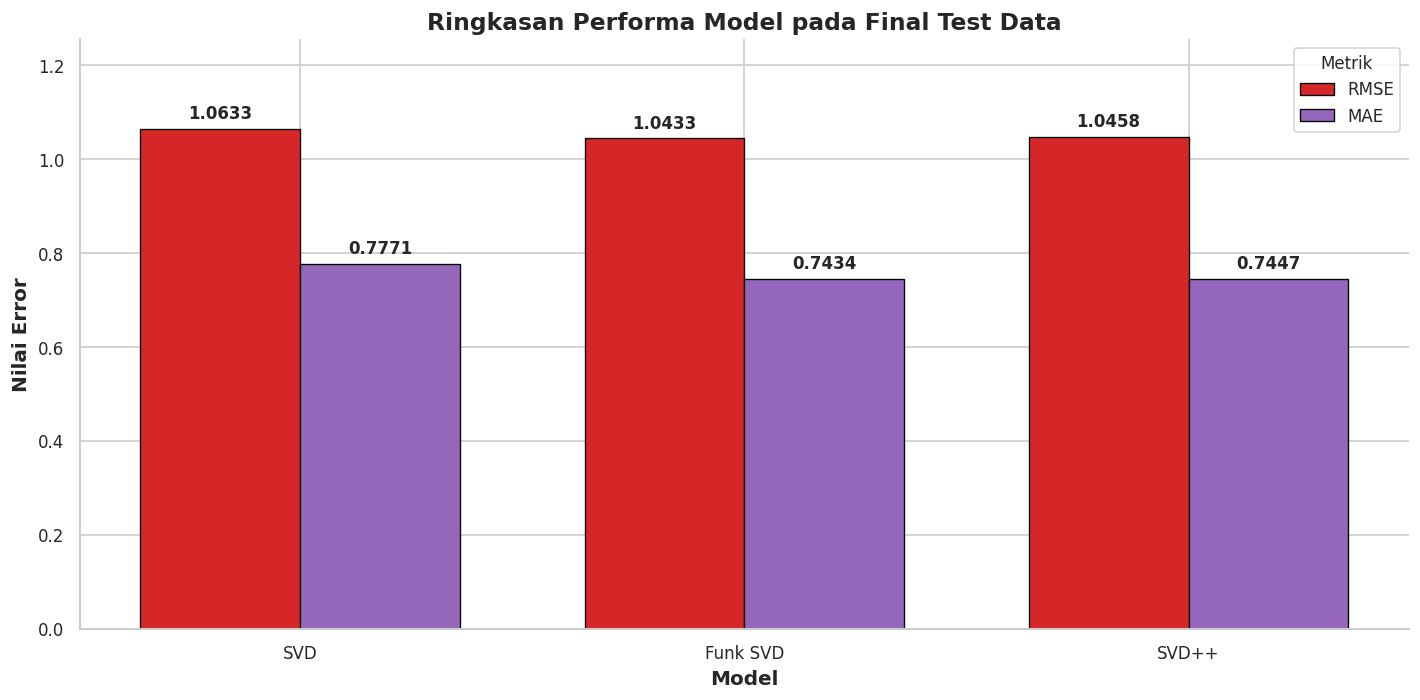

In [108]:
performance_summary_plot = (
    final_overall_results[
        [
            "model",
            "rmse",
            "mae"
        ]
    ]
    .copy()
)

model_plot_order = [
    "SVD",
    "Funk SVD",
    "SVD++"
]

performance_summary_plot[
    "model"
] = pd.Categorical(
    performance_summary_plot[
        "model"
    ],
    categories=model_plot_order,
    ordered=True
)

performance_summary_plot = (
    performance_summary_plot
    .sort_values("model")
    .reset_index(drop=True)
)

x_positions = np.arange(
    len(performance_summary_plot)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=WIDE_FIGSIZE
)

rmse_bars = ax.bar(
    x_positions - bar_width / 2,
    performance_summary_plot["rmse"],
    width=bar_width,
    label="RMSE",
    color=METRIC_COLORS["RMSE"],
    edgecolor="black",
    linewidth=0.8
)

mae_bars = ax.bar(
    x_positions + bar_width / 2,
    performance_summary_plot["mae"],
    width=bar_width,
    label="MAE",
    color=METRIC_COLORS["MAE"],
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    rmse_bars,
    labels=[
        f"{value:.4f}"
        for value in performance_summary_plot[
            "rmse"
        ]
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.bar_label(
    mae_bars,
    labels=[
        f"{value:.4f}"
        for value in performance_summary_plot[
            "mae"
        ]
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Ringkasan Performa Model pada Final Test Data"
)

ax.set_xlabel("Model")
ax.set_ylabel("Nilai Error")

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    performance_summary_plot[
        "model"
    ].astype(str)
)

maximum_metric_value = max(
    performance_summary_plot["rmse"].max(),
    performance_summary_plot["mae"].max()
)

ax.set_ylim(
    0,
    maximum_metric_value * 1.18
)

ax.legend(
    title="Metrik"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="50_Ringkasan_Performa_Model.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **5.11 Visualisasi Evaluasi Cold-Start Model Terbaik**

Gambar berhasil disimpan: 51_Ringkasan_Evaluasi_Cold_Start.png (267.91 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

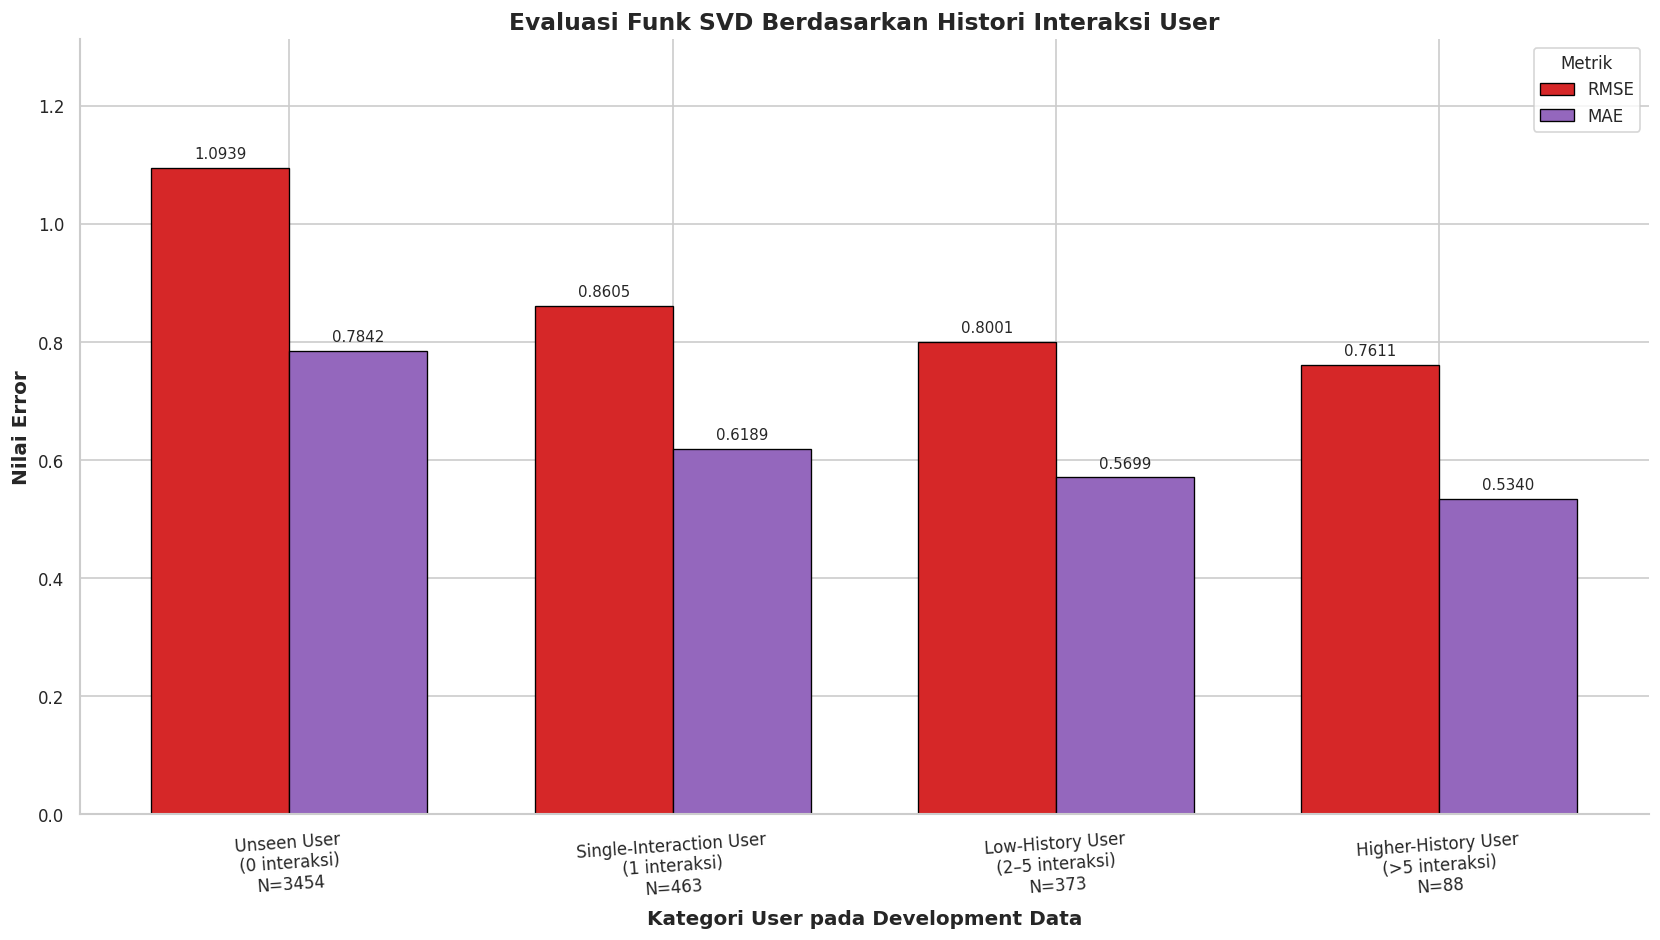

In [109]:
best_model_category_plot = (
    best_model_user_category_results[
        best_model_user_category_results[
            "jumlah_prediksi"
        ] > 0
    ]
    .copy()
)

best_model_category_plot[
    "kategori_label"
] = (
    best_model_category_plot[
        "kategori_user"
    ].astype(str)
    + "\n("
    + best_model_category_plot[
        "deskripsi_kategori"
    ].fillna("")
    + ")\nN="
    + best_model_category_plot[
        "jumlah_prediksi"
    ].astype(int).astype(str)
)

x_positions = np.arange(
    len(best_model_category_plot)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=LARGE_FIGSIZE
)

rmse_bars = ax.bar(
    x_positions - bar_width / 2,
    best_model_category_plot["rmse"],
    width=bar_width,
    color=METRIC_COLORS["RMSE"],
    label="RMSE",
    edgecolor="black",
    linewidth=0.8
)

mae_bars = ax.bar(
    x_positions + bar_width / 2,
    best_model_category_plot["mae"],
    width=bar_width,
    color=METRIC_COLORS["MAE"],
    label="MAE",
    edgecolor="black",
    linewidth=0.8
)

ax.bar_label(
    rmse_bars,
    labels=[
        f"{value:.4f}"
        for value in best_model_category_plot[
            "rmse"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.bar_label(
    mae_bars,
    labels=[
        f"{value:.4f}"
        for value in best_model_category_plot[
            "mae"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    f"Evaluasi {BEST_MODEL_NAME} Berdasarkan Histori Interaksi User"
)

ax.set_xlabel(
    "Kategori User pada Development Data"
)

ax.set_ylabel(
    "Nilai Error"
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    best_model_category_plot[
        "kategori_label"
    ],
    rotation=4,
    ha="center"
)

maximum_category_metric = max(
    best_model_category_plot["rmse"].max(),
    best_model_category_plot["mae"].max()
)

ax.set_ylim(
    0,
    maximum_category_metric * 1.20
)

ax.legend(
    title="Metrik"
)

plt.tight_layout()

save_figure_output(
    figure=fig,
    filename="51_Ringkasan_Evaluasi_Cold_Start.png",
    close_figure=False
)

plt.show()
plt.close(fig)

## **5.12 Daftar Seluruh File Output**

In [110]:
def identify_output_stage(
    filename: str
) -> str:
    """
    Menentukan tahap penelitian berdasarkan nomor awal file.
    """

    try:
        file_number = int(
            filename.split("_")[0]
        )

    except (ValueError, IndexError):
        return "Tidak Teridentifikasi"

    if 0 <= file_number <= 9:
        return "Step 1 - Persiapan Data Modeling"

    if 10 <= file_number <= 16:
        return "Step 2.1 - Optimasi SVD"

    if 17 <= file_number <= 24:
        return "Step 2.2 - Optimasi Funk SVD"

    if 25 <= file_number <= 32:
        return "Step 2.3 - Optimasi SVD++"

    if 33 <= file_number <= 41:
        return "Step 3 - Evaluasi Final Model"

    if 42 <= file_number <= 48:
        return "Step 4 - Implementasi Sistem"

    if 49 <= file_number <= 52:
        return "Step 5 - Ringkasan Penelitian"

    return "Output Lain"


# ------------------------------------------------------------
# Memindai seluruh file yang sudah tersedia
# ------------------------------------------------------------

output_file_records = []

for output_file in sorted(
    OUTPUT_DIR.iterdir()
):

    if not output_file.is_file():
        continue

    output_file_records.append({
        "nomor_output": (
            output_file.name.split("_")[0]
        ),
        "nama_file": output_file.name,
        "ekstensi": (
            output_file.suffix.lower()
        ),
        "ukuran_kb": (
            output_file.stat().st_size
            / 1024
        ),
        "tahap_penelitian": (
            identify_output_stage(
                output_file.name
            )
        ),
        "status_file": "Tersedia"
    })


output_file_inventory = pd.DataFrame(
    output_file_records
)

if not output_file_inventory.empty:

    output_file_inventory[
        "nomor_output_numerik"
    ] = pd.to_numeric(
        output_file_inventory[
            "nomor_output"
        ],
        errors="coerce"
    )

    output_file_inventory = (
        output_file_inventory
        .sort_values(
            [
                "nomor_output_numerik",
                "nama_file"
            ]
        )
        .drop(
            columns=[
                "nomor_output_numerik"
            ]
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# Ringkasan jumlah file
# ------------------------------------------------------------

output_file_summary = (
    output_file_inventory
    .groupby(
        [
            "tahap_penelitian",
            "ekstensi"
        ],
        as_index=False
    )
    .agg(
        jumlah_file=(
            "nama_file",
            "count"
        ),
        total_ukuran_kb=(
            "ukuran_kb",
            "sum"
        )
    )
)

display(output_file_inventory)
display(output_file_summary)


# ------------------------------------------------------------
# Menyimpan inventory
# ------------------------------------------------------------

save_excel_output(
    data={
        "Daftar File": (
            output_file_inventory
        ),
        "Ringkasan File": (
            output_file_summary
        )
    },
    filename="52_Daftar_Output_Penelitian.xlsx",
    index=False
)

,nomor_output,nama_file,ekstensi,ukuran_kb,tahap_penelitian,status_file
0,00,00_Ringkasan_Dataset.xlsx,.xlsx,517.959961,Step 1 - Persiapan Data Modeling,Tersedia
1,01,01_Distribusi_Interaksi_User_Dataset.png,.png,180.897461,Step 1 - Persiapan Data Modeling,Tersedia
2,02,02_Distribusi_Interaksi_Item.png,.png,127.970703,Step 1 - Persiapan Data Modeling,Tersedia
3,03,03_Distribusi_Rating.png,.png,130.763672,Step 1 - Persiapan Data Modeling,Tersedia
4,04,04_Mapping_User_Item.xlsx,.xlsx,489.159180,Step 1 - Persiapan Data Modeling,Tersedia
5,05,05_Ringkasan_Pembagian_Data.xlsx,.xlsx,8.079102,Step 1 - Persiapan Data Modeling,Tersedia
6,06,06_Distribusi_Kategori_User_Final_Test.png,.png,284.583984,Step 1 - Persiapan Data Modeling,Tersedia
7,07,07_Distribusi_Fallback_Final_Test.png,.png,205.835938,Step 1 - Persiapan Data Modeling,Tersedia
8,08,08_Data_Development.xlsx,.xlsx,1252.730469,Step 1 - Persiapan Data Modeling,Tersedia
9,09,09_Data_Final_Test.xlsx,.xlsx,522.924805,Step 1 - Persiapan Data Modeling,Tersedia


,tahap_penelitian,ekstensi,jumlah_file,total_ukuran_kb
0,Step 1 - Persiapan Data Modeling,.png,5,930.051758
1,Step 1 - Persiapan Data Modeling,.xlsx,5,2790.853516
2,Step 2.1 - Optimasi SVD,.png,4,513.490234
3,Step 2.1 - Optimasi SVD,.xlsx,3,9118.162109
4,Step 2.2 - Optimasi Funk SVD,.png,6,878.981445
5,Step 2.2 - Optimasi Funk SVD,.xlsx,2,2728.546875
6,Step 2.3 - Optimasi SVD++,.png,6,862.066406
7,Step 2.3 - Optimasi SVD++,.xlsx,2,2732.938477
8,Step 3 - Evaluasi Final Model,.png,7,1102.429688
9,Step 3 - Evaluasi Final Model,.xlsx,2,2475.629883


Excel berhasil disimpan: 52_Daftar_Output_Penelitian.xlsx (8.68 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PosixPath('/content/Hasil_Implementasi_MF/52_Daftar_Output_Penelitian.xlsx')

## **5.13 Pemeriksaan Akhir Seluruh Notebook**

In [111]:
final_required_files = [
    "00_Ringkasan_Dataset.xlsx",
    "04_Mapping_User_Item.xlsx",
    "05_Ringkasan_Pembagian_Data.xlsx",
    "08_Data_Development.xlsx",
    "09_Data_Final_Test.xlsx",

    "10_CV_Fold_Assignment.xlsx",
    "11_SVD_Hasil_Grid_Search.xlsx",
    "16_SVD_Parameter_Terbaik.xlsx",

    "17_Funk_SVD_Hasil_Grid_Search.xlsx",
    "24_Funk_SVD_Parameter_Terbaik.xlsx",

    "25_SVDpp_Hasil_Grid_Search.xlsx",
    "32_SVDpp_Parameter_Terbaik.xlsx",

    "33_Hasil_Evaluasi_Final.xlsx",
    "41_Model_Terbaik.xlsx",

    "42_Model_Implementasi_Full_Data.xlsx",
    "43_Pengguna_Sampel_Implementasi.xlsx",
    "44_Hasil_TopN_Rekomendasi.xlsx",
    "48_Ringkasan_Implementasi_Sistem_Rekomendasi.xlsx",

    "49_Ringkasan_Output_Penelitian.xlsx",
    "50_Ringkasan_Performa_Model.png",
    "51_Ringkasan_Evaluasi_Cold_Start.png",
    "52_Daftar_Output_Penelitian.xlsx"
]

missing_final_files = [
    filename
    for filename in final_required_files
    if not (
        OUTPUT_DIR / filename
    ).exists()
]

assert not missing_final_files, (
    "File berikut belum tersedia:\n"
    + "\n".join(
        f"- {filename}"
        for filename in missing_final_files
    )
)

assert BEST_MODEL_NAME in [
    "SVD",
    "Funk SVD",
    "SVD++"
], (
    "Model terbaik tidak valid."
)

assert (
    final_overall_results[
        [
            "rmse",
            "mae"
        ]
    ]
    .notna()
    .all()
    .all()
), (
    "Terdapat metrik evaluasi final yang kosong."
)

assert (
    final_prediction_results[
        "rating_prediction"
    ]
    .between(
        RATING_MIN,
        RATING_MAX
    )
    .all()
), (
    "Terdapat prediksi final di luar skala rating."
)

assert (
    top_20_recommendations[
        "rating_prediction"
    ]
    .between(
        RATING_MIN,
        RATING_MAX
    )
    .all()
), (
    "Terdapat prediksi Top-N di luar skala rating."
)

assert (
    recommendation_validation_summary[
        "jumlah_item_overlap"
    ].sum()
    == 0
), (
    "Terdapat item yang pernah diberi rating "
    "dalam hasil rekomendasi."
)

assert (
    len(best_hyperparameter_summary)
    == 3
), (
    "Ringkasan hyperparameter tidak memuat "
    "ketiga model."
)

assert (
    len(final_overall_results)
    == 3
), (
    "Evaluasi final tidak memuat ketiga model."
)


print("=" * 80)
print("SELURUH NOTEBOOK SELESAI")
print("=" * 80)

print(
    f"Nama notebook       : "
    f"{NOTEBOOK_NAME}"
)

print(
    f"Jumlah interaksi    : "
    f"{len(dataset):,}"
)

print(
    f"Jumlah user         : "
    f"{dataset['user_id'].nunique():,}"
)

print(
    f"Jumlah item         : "
    f"{dataset['place_id'].nunique():,}"
)

print(
    f"Matrix sparsity     : "
    f"{matrix_sparsity:.6f}%"
)

print(
    f"Model terbaik       : "
    f"{BEST_MODEL_NAME}"
)

print(
    f"RMSE final          : "
    f"{best_final_model_row['rmse']:.6f}"
)

print(
    f"MAE final           : "
    f"{best_final_model_row['mae']:.6f}"
)

print(
    f"Model prediction    : "
    f"{int(best_final_model_row['jumlah_model_prediction']):,} "
    f"({best_final_model_row['persentase_model_prediction']:.2f}%)"
)

print(
    f"Fallback prediction : "
    f"{int(best_final_model_row['jumlah_fallback_prediction']):,} "
    f"({best_final_model_row['persentase_fallback_prediction']:.2f}%)"
)

print(
    f"Jumlah file wajib   : "
    f"{len(final_required_files)}"
)

print(
    f"Lokasi output       : "
    f"{OUTPUT_DIR}"
)

print()
print(
    "STATUS AKHIR: SELURUH TAHAP PENELITIAN "
    "BERHASIL DIJALANKAN"
)

SELURUH NOTEBOOK SELESAI
Nama notebook       : 2026_08_05_Implementasi_CPU
Jumlah interaksi    : 21,886
Jumlah user         : 18,524
Jumlah item         : 300
Matrix sparsity     : 99.606169%
Model terbaik       : Funk SVD
RMSE final          : 1.043333
MAE final           : 0.743444
Model prediction    : 921 (21.04%)
Fallback prediction : 3,457 (78.96%)
Jumlah file wajib   : 22
Lokasi output       : /content/Hasil_Implementasi_MF

STATUS AKHIR: SELURUH TAHAP PENELITIAN BERHASIL DIJALANKAN


In [112]:
# ============================================================
# AUDIT JUMLAH EKSPERIMEN DAN KOMPILASI MODEL
# ============================================================

audit_experiment_results = pd.DataFrame([
    {
        "model": "SVD",
        "hasil_per_fold_aktual": len(
            svd_fold_results
        ),
        "hasil_per_fold_seharusnya": (
            len(SVD_K_VALUES) * N_SPLITS
        ),
        "kombinasi_aktual": len(
            svd_grid_summary
        ),
        "kombinasi_seharusnya": len(
            SVD_K_VALUES
        )
    },
    {
        "model": "Funk SVD",
        "hasil_per_fold_aktual": len(
            funk_svd_fold_results
        ),
        "hasil_per_fold_seharusnya": (
            number_of_funk_cv_evaluations
        ),
        "kombinasi_aktual": len(
            funk_svd_grid_summary
        ),
        "kombinasi_seharusnya": (
            number_of_funk_parameter_combinations
        )
    },
    {
        "model": "SVD++",
        "hasil_per_fold_aktual": len(
            svdpp_fold_results
        ),
        "hasil_per_fold_seharusnya": (
            number_of_svdpp_cv_evaluations
        ),
        "kombinasi_aktual": len(
            svdpp_grid_summary
        ),
        "kombinasi_seharusnya": (
            number_of_svdpp_parameter_combinations
        )
    }
])

audit_experiment_results["status_hasil_fold"] = np.where(
    audit_experiment_results[
        "hasil_per_fold_aktual"
    ]
    == audit_experiment_results[
        "hasil_per_fold_seharusnya"
    ],
    "SESUAI",
    "TIDAK SESUAI"
)

audit_experiment_results["status_kombinasi"] = np.where(
    audit_experiment_results[
        "kombinasi_aktual"
    ]
    == audit_experiment_results[
        "kombinasi_seharusnya"
    ],
    "SESUAI",
    "TIDAK SESUAI"
)

display(audit_experiment_results)

,model,hasil_per_fold_aktual,hasil_per_fold_seharusnya,kombinasi_aktual,kombinasi_seharusnya,status_hasil_fold,status_kombinasi
0,SVD,15,15,3,3,SESUAI,SESUAI
1,Funk SVD,405,405,81,81,SESUAI,SESUAI
2,SVD++,405,405,81,81,SESUAI,SESUAI


In [113]:
# ============================================================
# AUDIT DISTRIBUSI EPOCH DAN FOLD
# ============================================================

print("=" * 80)
print("DISTRIBUSI HASIL FUNK SVD BERDASARKAN EPOCH")
print("=" * 80)

display(
    funk_svd_fold_results[
        "n_epochs"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("n_epochs")
    .reset_index(name="jumlah_hasil")
)

print()
print("=" * 80)
print("DISTRIBUSI HASIL SVD++ BERDASARKAN EPOCH")
print("=" * 80)

display(
    svdpp_fold_results[
        "n_epochs"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("n_epochs")
    .reset_index(name="jumlah_hasil")
)

print()
print("=" * 80)
print("DISTRIBUSI HASIL FUNK SVD BERDASARKAN FOLD")
print("=" * 80)

display(
    funk_svd_fold_results[
        "fold"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("fold")
    .reset_index(name="jumlah_hasil")
)

print()
print("=" * 80)
print("DISTRIBUSI HASIL SVD++ BERDASARKAN FOLD")
print("=" * 80)

display(
    svdpp_fold_results[
        "fold"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("fold")
    .reset_index(name="jumlah_hasil")
)

DISTRIBUSI HASIL FUNK SVD BERDASARKAN EPOCH


,n_epochs,jumlah_hasil
0,25,135
1,50,135
2,100,135



DISTRIBUSI HASIL SVD++ BERDASARKAN EPOCH


,n_epochs,jumlah_hasil
0,25,135
1,50,135
2,100,135



DISTRIBUSI HASIL FUNK SVD BERDASARKAN FOLD


,fold,jumlah_hasil
0,1,81
1,2,81
2,3,81
3,4,81
4,5,81



DISTRIBUSI HASIL SVD++ BERDASARKAN FOLD


,fold,jumlah_hasil
0,1,81
1,2,81
2,3,81
3,4,81
4,5,81


In [114]:
# ============================================================
# AUDIT KOMPILASI NUMBA
# ============================================================

print("=" * 80)
print("STATUS KOMPILASI NUMBA")
print("=" * 80)

print("Funk SVD:")
print(
    _funk_svd_sgd_epoch.nopython_signatures
)

print()
print("SVD++ SGD:")
print(
    _svdpp_sgd_epoch.nopython_signatures
)

print()
print("SVD++ implicit user vector:")
print(
    _compute_svdpp_implicit_user_vectors
    .nopython_signatures
)

STATUS KOMPILASI NUMBA
Funk SVD:
[(Array(int64, 1, 'C', False, aligned=True), Array(int64, 1, 'C', False, aligned=True), Array(float64, 1, 'C', False, aligned=True), Array(int64, 1, 'C', False, aligned=True), float64, Array(float64, 1, 'C', False, aligned=True), Array(float64, 1, 'C', False, aligned=True), Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'C', False, aligned=True), float64, float64) -> UniTuple(float64 x 2)]

SVD++ SGD:
[(Array(int64, 1, 'C', False, aligned=True), Array(int64, 1, 'C', False, aligned=True), Array(float64, 1, 'C', False, aligned=True), Array(int64, 1, 'C', False, aligned=True), Array(int64, 1, 'C', False, aligned=True), Array(int64, 1, 'C', False, aligned=True), float64, Array(float64, 1, 'C', False, aligned=True), Array(float64, 1, 'C', False, aligned=True), Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'C', False, aligned=True), float64, float64) -> UniTuple(float64 x 2)]

SVD++

In [115]:
# ============================================================
# RINGKASAN WAKTU OPTIMASI
# ============================================================

optimization_time_audit = pd.DataFrame([
    {
        "model": "SVD",
        "jumlah_evaluasi": len(
            svd_fold_results
        ),
        "waktu_total_detik": (
            svd_grid_search_total_time
        ),
        "waktu_total": format_execution_time(
            svd_grid_search_total_time
        )
    },
    {
        "model": "Funk SVD",
        "jumlah_evaluasi": len(
            funk_svd_fold_results
        ),
        "waktu_total_detik": (
            funk_svd_grid_total_time
        ),
        "waktu_total": format_execution_time(
            funk_svd_grid_total_time
        )
    },
    {
        "model": "SVD++",
        "jumlah_evaluasi": len(
            svdpp_fold_results
        ),
        "waktu_total_detik": (
            svdpp_grid_total_time
        ),
        "waktu_total": format_execution_time(
            svdpp_grid_total_time
        )
    }
])

display(optimization_time_audit)

,model,jumlah_evaluasi,waktu_total_detik,waktu_total
0,SVD,15,6.190731,6.19 detik
1,Funk SVD,405,97.435189,1 menit 37.44 detik
2,SVD++,405,150.564530,2 menit 30.56 detik
